# Modeling Work-Disability Onset in Systemic Lupus Erythematosus

**30-month work-disability risk from routine clinic visits under competing risks: a LASSO-selected predictor set from a
pool of about 75 candidates, an LSTM as the main model, eight comparators and a stacking ensemble; trained,
thresholded and evaluated at every employed clinic visit (the visits the tool will score), per visit and per patient over 30-month windows; reported following
TRIPOD+AI.**

| | |
|---|---|
| **Outcome** | First work-disability (WD) onset after an employed visit: a visit at which the patient **receives disability benefits**, or a **sick-leave spell without return to employment that lasts ≥ 6 months** (including spells ending in another exit from work), dated at the **start of the spell**; onset is absorbing (no landmarks after it) |
| **Competing events** | Other exits from work (retirement, homemaking, study, unemployment, other); censoring at the **last visit with a recorded employment status** (a death included), at an **unresolved sick-leave spell shorter than 6 months**, or at **age 65** |
| **Target** | Risk of work disability by $\tau$ = 30 months (6–48 months from the same fit): cumulative incidence for the regression and boosting models; the sequence models estimate cause-specific discrete-time hazards, so every landmark contributes exactly the time it was observed for |
| **Landmarks** | **Every employed visit** (before age 65 and the first onset; never the last observed visit): the risk at the visit where the tool would be used. Training weight $1/n_i$ (every patient counts equally in the fit); visit-level metrics weight every visit equally, with a patient-weighted AUROC alongside |
| **Variables** | A **candidate pool of about 75 variables** in the five domains of Chen et al. (Lupus Sci Med 2025) — demographics, comorbidities and damage, laboratory values, vital signs, severity scores — plus treatment, symptoms, care and work (Section 5.1). An outcome-free **pre-filter** removes candidates missing at > 20 % of landmarks (treatment variables exempt: not recorded = not on the drug), with < 1 % prevalence, or with \|r\| > 0.9 with another candidate (Section 5.2). **LASSO** (L1-penalised IPCW logistic regression of onset within 30 months, patient-grouped 5-fold CV) then selects the predictors **inside every training fold**, with age and the calendar-year terms forced in, up to the **largest number of parameters that meets the Riley et al. sample-size criteria** (TRIPOD+AI item 10; Section 5.3) |
| **Missing data** | Laboratory values and vital signs carried forward for **at most 12 months**; clinic items carried forward; treatment never missing. The rest: **random-forest multiple imputation** (m = 5), fitted on the training rows and applied to the held-out rows, outcome not used, with each laboratory value's last-ever value and its age as auxiliary variables; "not measured in the last 12 months" indicators are candidates. Every model is fitted on each imputed dataset and the risks averaged (XGBoost handles missing values natively) |
| **Main model** | **LSTM-8**: a 16-unit LSTM over each landmark's **last 8 visits**, with a **skip connection** that feeds the current visit's variables to the hazard heads and **three auxiliary 12-month heads** (flare, SDI increase, EULAR treatment escalation; training only); next-visit pretraining, early stopping, 5-seed ensemble, cause-specific discrete-time hazard heads, interval-censored onsets. Its pre-specified reference is **LSTM-1**, the same network on the current visit alone |
| **Comparators** | A competing-risk LogReg on the selected variables (with its **nomogram**), an RSF and a cause-specific Cox, a GRU and a causal Transformer (whole history), **XGBoost** (cause-specific discrete-time hazards; replaces revised v14's equal-weight average) and the **stacking ensemble**: a non-negative IPCW logistic meta-learner on the cross-fitted risks of seven members (LSTM-8, LogReg, RSF, Cox, GRU, Transformer, XGBoost), fixed in advance. No SMOTE or other resampling |
| **Validation** | Repeated (5 × 5-fold) patient-grouped CV with the imputation, tuning, recalibration and thresholds learned inside each training fold (the LASSO selection is made **once, on all data, before the CV**, as in Chen et al.); competing-risk IPCW metrics. **Pre-specified hypotheses** (Section 8.1), tested in the fixed sequence **H1a → H1b → H3 → H2**: H1a LSTM-8 beats a baseline without clinical variables (pooled and era-stratified AUROC); H1b LSTM-8 is non-inferior to the LogReg (margin −0.02); **H3 the stack beats the LogReg**; H2 LSTM-8 beats LSTM-1. **Temporal validation** (development before 2012, validation from 2012) with and without **temporal recalibration**. **Sensitivity analyses** (Section 11.25): outcome definition (sick-leave threshold, onset dating, early retirement, unemployment, death, landmarks after disability), landmarks on a 6-month grid, every visit with unit training weights, LASSO penalty (λ_1se, λ_min), linear imputation, no missing-data indicators, horizons, complete-case evaluation; supplementary LSTM variants and stacks |
| **Visit level** | Alarm threshold learned per training fold: the threshold that **maximises the cost-weighted net benefit** (a missed onset costs R = 10 false alarms), among thresholds with **sensitivity ≥ specificity**, applied to the risk **relative to the calendar era**; results at R = 5–30 as a supplement |
| **Patient level** | Visit alarms over a **30-month window** per patient: TP = an alarm before onset; TN = no alarm in the window of an event-free patient. All patients, by final status and age band |
| **Reporting** | Per model and level: C-index, **era-stratified AUROC**, Brier, calibration slope / intercept, O/E, calibration curves, sensitivity, specificity, PPV, NPV, balanced accuracy (95 % patient-bootstrap CIs); net benefit; alert burden; the candidate pool and pre-filter, the LASSO path, CV curve and **selection stability** (across folds and bootstraps); sample size; missing data; participant flow; full model specification and the **nomogram**; stack weights; **SHAP** (LSTM, XGBoost); subgroups; the hypothesis tests |

The analysis follows `revised_v16 build/ANALYSIS_PLAN_revised_v16.md` (hypotheses and testing order: Section 8.1).

**Contents**

1. Motivation
2. Cohort, data and outcome
3. Competing events and censoring
4. Landmark framework and training target
5. Variables: candidate pool, pre-filter and LASSO selection
6. Models
7. Calibration
8. Validation
9. Decisions: visit alarms and patient-level evaluation
10. Known limitations and open problems
11. Code

The code runs top to bottom from the `updated data/` folder. Every cross-validated fit (and each fold's LASSO selection)
is checkpointed in `cv_state_model_revised_v16.pkl` and the temporal validation in
`temporal_validation_revised_v16.pkl`, so an interrupted run resumes where it stopped. **Runtime:** roughly 16–24 h for
the main run on a laptop CPU **plugged in and awake** (the refitted sensitivity analyses of Section 11.25 add about
14 h), most of it in the sequence models; the random-forest imputation adds a few minutes per fold; the LASSO runs once, before the CV.
Setting the environment variable `SLE_SMOKE=1` runs a quick version for testing only.

## 1. Motivation

Systemic lupus erythematosus (SLE) is a chronic, relapsing–remitting autoimmune disease that disproportionately
affects working-age adults. Over time, its cumulative effects on physical capacity, cognitive function and the
ability to manage the disease itself can erode a patient's capacity to sustain paid employment. Formal work
disability is the endpoint of this process; by the time it is recorded, the underlying functional decline has
typically been accumulating for years, during which patients are seen at routine clinic visits where disease
activity, organ damage and other clinical variables are measured.

**Hypothesis.** These routine data carry a latent signal in each patient's trajectory that identifies those at
high risk of functional decline well before work disability occurs. Functional decline, unlike its endpoint, is
often modifiable, so earlier identification widens the window for vocational support, treatment intensification
or rehabilitation. An early-warning tool built entirely from data already collected at routine visits (disease
activity, damage, treatment burden, symptoms, sick leave) could flag rising risk early enough for intervention to
matter. Its usefulness depends on the statistical model being correctly specified for the data-generating
process it is asked to predict, and on its decisions being evaluated at the level at which they are used: the
patient.

## 2. Cohort, data and outcome

### 2.1 Study population and data structure

Let $i = 1,\dots,N$ index patients. Patient $i$ contributes clinic visits at calendar times
$t_{i,0} < t_{i,1} < \dots < t_{i,n_i}$, with time-varying covariates $X_{i,j} \in \mathbb{R}^p$ (Section 5) and a
recorded employment status $r_{i,j}$, grouped into four states:
**W** employed, **S** sick leave, **D** disabled (on disability benefits), **O** other exit (retired, homemaker,
student, looking for work, other).

**Cohort entry.** A patient enters at their **first employed visit before age 65** (the index visit). Earlier visits
are kept as history for the sequence models.

### 2.2 Visit timing and calendar time

Visits are irregular: gaps range from about 2 months (active disease) to about 6 months (remission), so **the
sampling density is itself informative**. Every outcome window is defined in **calendar time**, never in visit
counts. The sequence models read the gap since the previous visit at every visit (Section 6.1).

**Calendar time.** Work-disability onsets become rarer in later calendar years (Section 11.24). A model that ignores
this averages early and recent years, so its risks run too high for recent patients, and variables whose use changed
over time (treatments, recorded symptoms, laboratory tests) pick up part of the trend. Every model is therefore
**adjusted for the calendar year of the visit** (Section 5.4). The year is clipped to the training years at
prediction, so the trend is never extrapolated: a new patient is scored at the rate of the latest training year.

### 2.3 Outcome: work-disability onset

> **Definition 1 (onset, cause 1).** Starting from an employed visit, the first of:
> (a) a visit with $r_{i,j}$ = *disabled*, i.e. the patient **receives disability benefits** — onset at that visit; or
> (b) a **sick-leave spell without return to employment that lasts ≥ 6 months** (`SICK_LEAVE_MIN_MONTHS`), including
> spells that end in another exit from work — onset at the **start of the spell** (its first sick-leave visit; the
> sequence models place it anywhere after the last visit at work).
>
> Onset is **absorbing**: a patient contributes no landmark after their first onset.

A spell lasts from its first sick-leave visit to the visit that ends it (a *disabled* visit or another exit), or to
its last recorded visit if it is still open; its length is therefore known to the nearest visit. A sick-leave spell
followed by an employed visit is **not** an event, however long it lasted, and the patient stays at risk. A spell
shorter than 6 months that ends in disability benefits is an onset by (a), dated at the *disabled* visit; one that
ends in another exit is that competing event, dated at the start of the spell; one still open at the last visit is
censored at the start of the spell (Section 3).

Rule (b) treats leaving work *through* a long sick leave as health-related work loss, whatever label the next visit
carries, and dates it where work actually stopped. The extract has no separate benefits variable: the *disabled*
employment status is the record of disability benefits.

**Returns to work.** A patient can return to work after a sick leave or another exit; every employed visit before the
first onset is a landmark (Section 4), and its event is the **next** end of follow-up after it. Landmarks after a
return to work from disability are excluded (a sensitivity analysis includes them).

**Prediction target.** For a patient employed at visit $j$, the cumulative incidence of onset by horizon $\tau$,
with other exits as competing events:
$$F_{i,j}(\tau) = \Pr\!\left(T_{i,j} \le \tau,\ \text{cause} = 1 \;\middle|\; \mathcal{H}_{i,j},\; \text{employed at } j\right),$$
where $\mathcal{H}_{i,j}$ is everything recorded up to and including visit $j$. Decisions use $\tau$ = 30 months;
the models learn $F$ for every $\tau$ up to 48 months. The sequence models estimate the **cause-specific** risk
$R_{i,j}(\tau) = 1 - \prod_{k}(1 - h_{1,i,j,k})$ instead (Section 4), the estimand for whether routine data carry a
signal for work disability itself.

## 3. Competing events and censoring

From a landmark, follow-up ends at the first of:

| End of follow-up | Treated as | Date |
|---|---|---|
| Work-disability onset (Definition 1) | **cause 1** (event of interest) | *disabled* visit, or start of a sick-leave spell of ≥ 6 months; the sequence models place it anywhere after the last employed visit (interval-censored) |
| Other exit from work (straight from work, or through a sick-leave spell of < 6 months): retired, homemaker, student, looking for work, other | **cause 2** (competing) | first non-working visit (the start of the spell) |
| Age 65 (`AGE_CAP_YEARS`) | censored | 65th birthday |
| Last visit with a recorded employment status | censored | that visit |
| Sick-leave spell still open at the last visit and shorter than 6 months | censored | start of the spell |
| Death | censored at the last recorded employment status (`DEATH_AS_COMPETING_EVENT = False`) | that visit |

Counts in this extract are printed in Section 11.2.

* **Why competing risks.** An other exit removes the possibility of work disability. The cumulative incidence is the
  real-world risk a clinician faces, and a patient who retires at 10 months is a *resolved* negative for "disability by
  30 months", not an unknown. For the question of whether routine data carry a signal for work disability itself, the
  cause-specific hazard is the estimand, so the sequence models model each cause with its own hazard (Section 4).
* **Why the age cap.** Ordinary retirement dominates exits after 60–65 and says nothing about lupus; capping at 65
  keeps cause 2 about working-age exits.
* **Censoring at the last recorded status, no trims.** After the last visit whose employment status was recorded the
  status is unknown; before it, it is known. Follow-up therefore ends there, with no fixed window added or removed, and
  later visits without a recorded status add nothing. No landmark is dropped for short follow-up: a censored landmark
  contributes the intervals it was observed for.
* **Death.** Employment status between the last recorded visit and a death is unknown, so a death is censored at the
  last recorded status like any other end of follow-up. Leaving work before dying, if it matters, belongs in the
  outcome definition or in the exit head (Section 6.1), not in a trim. `DEATH_AS_COMPETING_EVENT = True` counts a death
  within 12 months of the last at-risk visit as cause 3 instead (sensitivity analysis).
* **Event timing.** A transition is only known to lie between the last employed visit and the visit that records it
  (up to one visit gap). The sequence models use that interval in their likelihood; the tabular models and every
  evaluation date the event at the recording visit (for rule (b), the first visit of the sick-leave run).
* **Last contact (`LCDT`).** Not used to extend follow-up: employment status at `LCDT` is unknown.
* **Informative censoring.** Checked directly in Section 11.3.1: a censoring-hazard model on the fixed
  variables, cross-validated. If it carries signal (C-index ≥ 0.60), the sequence models' and the baseline's loss is
  weighted by the inverse probability of remaining uncensored from that model, fitted inside every training set, and
  the survival evaluation adds covariate-adjusted weights. The competing-risk metrics use a Kaplan–Meier fit of the
  censoring times (IPCW, Section 8), with every observed cause ending follow-up.

### 3.1 Pre-specified sensitivity analyses

Each analysis changes one element of the design; everything else is as in the main analysis.

| Analysis | Change | Run |
|---|---|---|
| Sick-leave threshold | a spell without return counts after **any duration**, **3** or **12 months** (main: 6) | refitted |
| Onset dating | onset dated at the **recording visit** (the *disabled* visit, or the first visit at which the spell has lasted the threshold), with no interval censoring | refitted |
| Early retirement | retirement before 60 counted as work disability | refitted |
| Unemployment | *looking for work* counted as work disability | refitted |
| Death | death within 12 months of the last at-risk visit as a competing event (main: censored) | refitted |
| Returns from disability | landmarks after a return to work from disability included (main: onset absorbing) | refitted |
| Landmark spacing | **6-month grid**: the last employed visit of each 6-month period from the first employed visit, each weighted 1 (main: every employed visit) | refitted |
| Landmark weighting | every employed visit with **unit training weights**, so patients seen more often weigh more in the fit (main: $1/n_i$) | refitted |
| Horizon | 12, 24, 36 and 48 months (main: 30) | evaluated on the main fits (one fit gives every horizon, each with its own recalibration) |
| Censoring handling | **complete-case** evaluation: landmarks resolved at 30 months with unit weights (main: IPCW) | evaluated on the main fits |

A refitted analysis rebuilds the outcome and landmarks from the raw extract and cross-validates the competing-risk
LogReg and the LSTM (`SENS_MODELS`, `SENS_REPEATS` repeat(s) of the same 5-fold scheme; Section 11.25).

## 4. Landmark framework and training target

> **Definition 2 (landmark).** **Every employed visit** before age 65 and before the patient's first onset (never
> the last observed visit) is a landmark: the model predicts at each clinic visit, as the tool would. The sequence
> models read every visit up to the landmark. Its follow-up time is $\tilde T_{i,j} = \min(T_{i,j}, U_{i,j})$ with cause
> $\delta_{i,j} \in \{0, 1, 2, 3\}$ (Section 3).

**Discrete-time competing-risk target.** Follow-up after a landmark is cut into $K$ = 16 intervals of 3 months up to
48 months. For interval $k$ the target is the class $y_{i,j,k} \in \{0, 1, 2, 3\}$ — no event, or the cause of the
event in that interval. Interval $k$ counts ($m_{i,j,k} = 1$) if the landmark was still under observation through it;
a censoring time in the second half of an interval counts that interval as survived. The models output per-interval
cause probabilities $h_{c,i,j,k}$, and
$$F_{i,j}(\tau) = \sum_{k \le \tau/3} S_{i,j}(k-1)\, h_{1,i,j,k}, \qquad S_{i,j}(k) = \prod_{l \le k} \Big(1 - \sum_{c=1}^{3} h_{c,i,j,l}\Big),$$
so one fit gives the cumulative incidence at every horizon, never decreasing with the horizon.

**Sequence models: cause-specific hazards.** The LSTM, GRU and Transformer give each cause its own discrete-time
(logistic) hazard over the same intervals: $h_{1,k}$ for work disability and, in a second head, $h_{2,k}$ for an other
exit (or death, when it is counted), each treating the other cause as censoring. A landmark contributes exactly the
time it was observed for:

* an event of this cause in interval $j$: survived intervals $0, \dots, j-1$, event in $j$;
* censored in interval $c$: survived intervals $0, \dots, c-1$, nothing after (a censoring time in the second half of an
  interval counts it as survived); the other cause censors the landmark at its last employed visit;
* **interval-censored** event: it happened after the last employed visit (interval $a$) and by the visit that
  records it (interval $b$), so the term is $\log[S(a-1) - S(b)]$, which is $\log S(b-1) + \log h_b$ when $a = b$.

$$\ell_{i,j} = \sum_{k \in \text{survived}} \log(1 - h_k) \;+\; \delta_{i,j} \log\Big(1 - \prod_{k=a}^{b} (1 - h_k)\Big),
\qquad R_{i,j}(\tau) = 1 - \prod_{k \le \tau/3} \big(1 - h_{1,i,j,k}\big).$$

$R(\tau)$ is the cause-specific risk: onset by $\tau$ unless the patient leaves work for another reason first. One fit
gives every horizon.

* **Why every visit.** The tool scores the patient at every clinic visit, so the landmarks are the visits it will
  see, including the more frequent visits of patients who are unwell; how often a patient is seen is itself
  information (days since the previous visit, the gap relative to the patient's usual gap and acute-care events are
  candidates, and the sequence models read the gaps). The **training weight is $1/n_i$**, so a patient with many
  visits does not dominate the fit or the LASSO; the **primary visit-level metrics weight every visit equally**,
  which is the population of predictions the tool makes; a patient-weighted AUROC ($1/n_i$) is reported alongside.
  Landmarks of one patient are **nested, dependent observations**, handled by patient-grouped CV and the
  patient-cluster bootstrap. A 6-month grid (one landmark per period, weight 1) and every visit with unit training
  weights are sensitivity analyses.
* Binary 30-month metrics use **competing-risk IPCW**. A landmark's 30-month outcome is known if it had an onset
  within 30 months (case, weight $1/\hat G(T^-)$), a competing event within 30 months (control, $1/\hat G(T^-)$), or
  was followed beyond 30 months with neither (control, $1/\hat G(30)$). Earlier-censored landmarks get weight 0.

## 5. Variables: candidate pool, pre-filter and LASSO selection

The set-up follows Chen et al. (Lupus Sci Med 2025;12:e001397): a broad candidate pool in five domains, an
outcome-free missingness filter, LASSO with 5-fold cross-validation, a regression nomogram and a stacking ensemble.
As in Chen et al., the selection is made **once, on all data**, before the cross-validation. Two steps differ: the **number of selected variables is capped by the TRIPOD+AI
sample-size criteria**, and there is **no resampling of the outcome** (SMOTE). Every variable describes the patient
**at the visit**, from that visit and earlier ones only; columns that summarise a patient's whole follow-up (`DS_*`)
are never used, except the patient-constant highest education.

### 5.1 Candidate pool

| Domain | Candidates (at the visit) |
|---|---|
| Demographics | age (forced), sex, education (higher vs not, + not recorded), current smoker, BMI, years since the first employed visit, disease duration, age at diagnosis |
| Comorbidities and damage | SDI total and its 11 domains, glucocorticoid-related damage (cataract, avascular necrosis, osteoporotic fracture, diabetes), high blood pressure (≥ 140 / 90), fibromyalgia, hypothyroidism, antiphospholipid antibodies (ever), infections in the last 12 months, eGFR < 60 |
| Laboratory | ESR, hs-CRP, eGFR (CKD-EPI 2021), C3, C4, low complement, anti-dsDNA, leukopenia, proteinuria |
| Vital signs | systolic and diastolic blood pressure, weight |
| Severity scores | SLEDAI-2K, clinical SLEDAI-2K (without serology), the 7 SLEDAI-2K domains, adjusted mean SLEDAI-2K, flare at the visit, LLDAS, clinical remission (both without the physician global) |
| Treatment (not recorded = 0) | steroid dose, IV pulse, acute visit, not on an antimalarial, azathioprine, mycophenolate, methotrexate, cyclophosphamide, biologic, EULAR treatment step (0–4), EULAR escalation |
| Symptoms | fatigue, arthralgia, dyspnoea, headache, chest pain, weight loss, alopecia |
| Care and work | days since the previous visit, visit gap relative to the patient's usual gap, acute-care events in the last 12 months, prior sick-leave episodes, sick-leave days in the last 2 years |
| Pre-onset change | SDI points gained in the last 12 months |
| Adjustment (forced) | calendar year (linear + spline term; Section 5.6) |

The extract has no blood counts, albumin, liver enzymes, lipids, glucose or LDH, so several of Chen et al.'s strongest
predictors (ALT, urine output, SAPS II) have no equivalent here. CRP is recorded at under 10 % of visits and is not a
candidate. **Race is not a candidate**; it is used to report performance by race (Section 11.23).

### 5.2 Pre-filter (no outcome used)

On the landmark rows, in this order: a non-treatment candidate **missing at > 20 % of the landmarks** after
carry-forward is excluded (Chen et al.'s rule); **treatment variables are exempt** — a drug not recorded at a visit is
a drug not given (recording is consistent: a patient recorded off a drug between two visits on it is rare, 0.6–2.6 %
of visits by class); a binary candidate with **< 1 % prevalence** is excluded; a candidate with **|r| > 0.9** with one
kept before it (the table lists the clinically primary one first) is excluded. Then, for every kept laboratory value or
vital sign missing at > 5 % of the landmarks, a **"not measured in the last 12 months" indicator** joins the pool (a
test that was not ordered can itself carry information; Sisk et al., Stat Methods Med Res 2023). Every decision is
tabulated in Section 11.5.

### 5.3 LASSO selection, capped by the sample-size criteria

**Cap (TRIPOD+AI item 10).** The largest number of model parameters that meets the three criteria of Riley et al.
(BMJ 2020; Stat Med 2019, time-to-event version) for 1,059 patients with about 150 onsets at an anticipated C of 0.72
(revised v12's C of every model): expected shrinkage ≥ 0.9 binds, at 10 parameters (10.7 rounded down; the optimism criterion
allows about 50; the overall-risk criterion needs only about 190 patients). Age and the two calendar-year terms take
3, so **the LASSO selects at most 7 variables** (the exact numbers are computed in Section 11.5). This is fewer
than revised v14's 17 parameters, which did not meet the shrinkage criterion; penalisation does not remove the need to
meet it (Riley et al., J Clin Epidemiol 2021). Every parameter counts — a missing-data indicator or an education
category as one — and the LogReg uses linear terms only (no splines).

**LASSO.** An L1-penalised logistic regression of **onset within 30 months** — the competing-risk IPCW label of every
metric in this notebook (an other exit by 30 months is a resolved non-event; landmarks censored earlier drop out) — on
the standardised candidates, weighted IPCW × landmark weight, with the 5 imputed datasets stacked at weight 1/5 each
(Wood, White & Royston, Stat Med 2008). Age and the calendar-year terms are unpenalised. The deviance curve comes from
patient-grouped 5-fold CV over a path of 40 penalties. The penalty used is
$\lambda^* = \max(\lambda_{\min}, \lambda_{\text{cap}})$: the **largest set that meets the cap, but never a weaker
penalty than the CV optimum** (Chen et al.'s $\lambda_{1\text{se}}$ and an uncapped $\lambda_{\min}$ are sensitivity
analyses).

**Once, on all data.** The LASSO runs once on all landmarks, before the cross-validation, and every model in every
fold uses that set; it also gives the published model, the nomogram and the final refits. The cross-validated
performance therefore does **not** include the selection step and may be somewhat optimistic (Section 10). Its
stability is reported over 200 patient bootstraps (Section 11.15.2). Each refitted sensitivity analysis repeats the
all-data selection under its own settings.

### 5.4 Inputs of the sequence models

The selected columns (the calendar-year terms go to the hazard heads, not the encoder; Section 5.6), plus
$\log(1 + \Delta_{i,j})$ with $\Delta_{i,j}$ the years since the previous visit, and the **employment state of the
visit** (employed / sick leave / disabled / other exit, one-hot), at every visit of the history the model reads.

### 5.5 Scaling and missing data

Skewed, zero-inflated and count variables get a **signed log1p** before standardisation; every standardised value is
**clipped at ±5 SD**; scalers are fitted on the training fold's landmarks.

**Carry-forward.** Clinic items (symptoms, comorbidities, SLEDAI-2K and its items, SDI) are carried forward from the
last visit that recorded them. **Laboratory values and vital signs are carried forward for at most 12 months**: an
older value no longer describes the landmark and counts as missing. Treatment variables are never missing.

**Multiple imputation.** What is still missing is **multiply imputed by chained equations with random-forest
conditional models** (m = 5 imputations, 5 rounds; each draw = the forest's prediction plus out-of-bag residual noise;
Shah et al., Am J Epidemiol 2014), on the signed-log1p scale. The imputation model of a laboratory value or vital sign
also reads its **last value ever recorded and the years since** (auxiliary columns, not model inputs). Imputation
models are fitted on the **training rows only** and applied to the held-out rows, and the outcome is **not** in them
(at deployment it is unknown; Sisk et al. 2023). Imputed values stay within the observed range, binary items are
rounded, and patient-constant items take one value per patient. Each tabular model is fitted on each completed dataset
and the risks are averaged (Rubin's rules for predictions); seed $s$ of the sequence models' ensemble trains on
imputation $s$; XGBoost reads the values as recorded and handles missingness itself. revised v14's Bayesian linear
imputation is a sensitivity analysis.

### 5.6 Calendar-time adjustment

The share of landmarks followed by an onset within 30 months falls from the 1990s to the late 2010s. Some of this
may reflect changes in benefits, work and treatment; some may reflect how employment status was recorded or the
shorter follow-up near the end of the extract (other exits also become rarer). Either way, the level of risk depends
on when the visit took place. Every model therefore receives the **calendar year of the visit** (decimal years) as an
**adjustment term**, a **restricted cubic spline with 3 knots** (10th, 50th and 90th percentiles of the landmark
years): a linear term and one nonlinear term. The fall is not linear: it steepens after about 2010, and in revised_v10
a linear term under-predicted 2006–11 and over-predicted from 2012. The terms are forced into every selection and are not interpreted as predictors.

* **LogReg and Cox:** the two terms (standardised, penalised with the other terms). **RSF:** two more split variables.
* **Sequence models:** the year enters the **hazard heads only**, not the encoder: it shifts the per-interval hazards
  of each cause, and the history is read by the encoder as before (Section 6.1).
* **Signal-test baseline** (Section 11.17.1): the year is one of its terms, so the LSTM is compared with a baseline
  that has the same calendar-time information.
* **Alarms:** the alarm threshold is applied to the risk relative to the era's average predicted risk (Section 9.1),
  so the level of risk in a calendar period does not decide how many of its visits alarm.
* **No extrapolation:** at prediction the year is **clipped to the range of the training rows** (the nonlinear term
  increases with the year, so clipping both terms is clipping the year). In the repeated CV
  the test visits lie within the training years, so the clip changes nothing. In the temporal validation the
  validation period is scored at the last development year (Section 11.24). The final all-data model scores a new
  patient at the latest year in the extract.

## 6. Models

**Static and longitudinal models.** In every fold all models use the same variables, that fold's LASSO selection (Section 5.3). The **static**
models (competing-risk LogReg, RSF, cause-specific Cox) predict from the current visit only. The **longitudinal**
models read the variables over earlier visits too: the main LSTM over each landmark's last 8 visits, the GRU and
Transformer over the whole history. A further model separates what the network and what the history contribute:
**LSTM-1**, the main LSTM's network on the current visit alone. The pre-specified hypotheses are in Section 8.1: the main LSTM against a
baseline without clinical variables (H1a), against the LogReg (non-inferiority, H1b) and against LSTM-1 (does the
history add to the current visit? H2).

### 6.1 Main model: LSTM-8, a residual-history LSTM with cause-specific hazard heads

**Window.** For landmark $j$ the LSTM reads that landmark's **last 8 visits** in order (all of them if the patient has
fewer), including visits before the index visit and while not employed, and predicts at the landmark. The window is
fixed in advance (about 2 years at the clinic's median visit gap of 119 days, the time scale of the 30-month horizon);
nothing is selected per fold. (In revised_v12 the window was chosen per fold and the current visit alone was chosen in
23 of 25 folds.)

**Inputs.** At visit $j$: $\tilde x_{i,j} = \big(z_{i,j},\ \log(1 + \Delta_{i,j}),\ e_{i,j}\big)$, with $z$ the
variables (scaled), $\Delta$ the years since the previous visit and $e$ the one-hot employment state. The calendar year
$c_{i,j}$ (scaled, clipped to the training years) is not an encoder input; it enters the heads.
$$h_{i,j} = \mathrm{LSTM}(\tilde x_{i,j},\, h_{i,j-1}), \qquad \text{hidden size } 16,\ \text{dropout } 0.3.$$

**Self-supervised pretraining.** Before seeing any disability label, the encoder learns to predict the next visit's
SLEDAI-2K, SDI and steroid dose (squared error) from $h_{i,j}$ and the gap to the next visit, for 10 epochs, on every
patient outside the held-out ones (the test fold, and the inner held-out part in cross-fitting), never-employed
patients included. Each seed pretrains its own encoder.

**Cause-specific hazard heads with a skip connection.** Per interval $k$, a logistic hazard for work disability and, in
a second head, for an other exit (or death, when it is counted), on the LSTM summary **and the current visit's
variables**:
$$h_{c,i,j,k} = \sigma\big(W_{c,k} \operatorname{dropout}(h_{i,j}) + V_{c,k}\, z_{i,j} + \gamma_{c,k}\, c_{i,j} + b_{c,k}\big), \qquad c \in \{1, 2\},$$
trained on the cause-specific, interval-censored likelihood of Section 4 (each head treats the other cause as censoring;
the two likelihoods add). The work-disability risk is $1 - \prod_{k \le \tau/3}(1 - h_{1,k})$.

**Warm start.** Each interval's bias starts at the training landmarks' life-table hazard of that cause; the skip weights
$V$, the calendar-year weights and the biases then start at a person-interval logistic regression of the event on the
current visit's variables, the calendar year and the interval indicators. Training therefore starts from the static
model, and the recurrent summary can only add to it: this is what makes LSTM-8 against LSTM-1 a test of what the
history adds.

**Auxiliary heads (multi-task learning; training only).** Three logistic heads on $h_{i,j}$ predict events within
12 months after the landmark: a SLEDAI-2K flare (a rise > 3 from the previous visit), an SDI increase and a **EULAR
treatment escalation** (within 12 months of a landmark: about 18 %, 9 % and 19 %, against an onset about 2 %), so they
give the encoder more supervision about the course of the disease than 150 onsets can. revised v14's fourth head, a
sick-leave spell ending back at work, is dropped (0.4 % prevalence). A landmark with less than 12 months of later
visits is masked for a head unless the event was observed. Total loss = hazard loss + 0.3 × the mean auxiliary loss
(binary cross-entropy, landmark-weighted); the auxiliary heads are not used for prediction.

**Training (visit level).** The likelihood above over landmark visits, weighted by the landmark weight $w_{i,j} = 1$ (and, with
informative censoring, each interval by $1/\hat G_k(x)$, Section 11.3.1), AdamW (learning rate $3\cdot10^{-3}$, weight
decay $10^{-2}$), gradient clipping at 1, batches of 64 patients. 20 % of the fit's patients (stratified by event status)
are held out for **early stopping** on the validation loss (up to 60 epochs, patience 8; the best weights are kept).
The outer-fold fit averages the per-interval hazards of **5 seeds** (seed $s$ trains on imputation $s$);
cross-fitting fits use 1 seed.

**Reference and supplementary variants.** **LSTM-1** is the identical network (skip connection, auxiliary heads, seeds,
folds) on the current visit alone. Supplementary variants, one CV repeat each: the last 4 and the last 16 visits; LSTM-8
without the skip connection; LSTM-8 without the auxiliary heads (Section 11.9.2). They are reported, not used to choose
the main model.

### 6.2 Comparators

All comparators use the same landmarks, targets, censoring, variables, calendar-year adjustment, landmark weights,
calibration and decision rules:

* **LSTM-1**: above.
* **Competing-risk LogReg** (Chen et al.'s regression model): pooled **multinomial** logistic regression on
  landmark × interval rows (none / disability / other exit / death), interval dummies as the baseline hazards, the
  fold's selected variables as **linear** terms (every parameter counts against the cap), L2 penalty tuned per fold
  (C in 0.001–0.3); outputs the cumulative incidence. Its readable form is the **nomogram** (Section 11.10.1): the
  same selected variables in an unpenalised IPCW logistic regression of onset within 30 months, temporally
  recalibrated.
* **Random survival forest** and **cause-specific Cox PH**: work disability with other exits and deaths censored,
  capped at 48 months. They estimate $1 - S_1(t)$, not a cumulative incidence; recalibration against the
  competing-risk label puts them on the same scale. The Cox hazard ratios have cluster-robust (patient) standard errors.
* **GRU** and **Transformer**: revised_v12's specification: 32 units, the whole history, no skip connection or
  auxiliary heads (a GRU cell, or a 1-layer causal Transformer with 2 heads, feed-forward 64, learning rate
  $10^{-3}$ and elapsed years since the first visit as an extra input).
* **XGBoost** (new in revised_v15; Chen et al.'s main learner family): two gradient-boosted discrete-time hazards on
  person-interval rows (the interval index as a feature) — work disability, and other exit or death — combined into the
  cumulative incidence of work disability. Tree depth (2 or 3) is tuned per fold; 150 trees, learning rate 0.1,
  minimum child weight 10, subsampling 0.8. It reads the variables as recorded and handles missing values natively.
* **Baseline** (for H1a): the sequence models' cause-specific discrete-time hazard model without the sequence and
  without clinical variables: a linear logistic hazard on **age, education and the calendar-year terms**, with the same
  intervals, interval-censored likelihood, weights and folds.

### 6.3 Stacking ensemble

The **Stack** combines seven members fixed in advance — LSTM-8, LogReg, RSF, Cox, GRU, Transformer and XGBoost (Chen et
al. kept the base learners that performed best on their test set; here none is chosen on performance). **Level-1
data:** in each training fold, every member's logit of its calibrated **cross-fitted** out-of-fold 30-month risk (the
3-fold cross-fitting that also feeds recalibration), so the meta-learner never sees a prediction made on the member's
own training rows. **Meta-learner:** an IPCW-weighted logistic regression of onset within 30 months with
**non-negative weights** and a ridge penalty chosen by 3-fold patient-grouped CV of the training fold,
$\operatorname{logit} p = a + \sum_m \beta_m \operatorname{logit} p_m$, $\beta_m \ge 0$. The weights learned at 30
months combine the members' logits at every horizon (non-negative weights keep the risk non-decreasing in the
horizon); the stack is then recalibrated and thresholded on the training fold like every model. Supplementary:
the MLP meta-learner of Chen et al. (one hidden layer of 8 units) and a stack of the tabular members only (LogReg, RSF,
Cox, XGBoost). The equal-weight average of revised v14 is dropped: in revised v10–v12 it never beat its best member.

## 7. Calibration

A model's raw risk at horizon $\tau$ is recalibrated by an **IPCW-weighted logistic model** on its logit (or on the
log of the score, for the RSF), against the competing-risk label "onset by $\tau$" (an other exit or death before
$\tau$ counts as a resolved negative). This also puts the cause-specific RSF and Cox on the cumulative-incidence scale and
corrects the sequence models' patient-weighted event rate:
$$\hat F(\tau) = \sigma\big(a_\tau + b_\tau \cdot z(\text{raw})\big).$$
It is fitted, one per horizon, on the **cross-fitted out-of-fold** predictions of the whole training fold
(Section 8), so every training patient trains the model *and* informs calibration and thresholds. A non-positive
slope would invert the ranking, so it is never used: the slope is then kept at 1 and only the event rate is matched.
Every risk in the shared tables is a calibrated probability. The sequence models output a cause-specific risk, like
the Cox model and the RSF, so this step also puts them on the cumulative-incidence scale of those tables. Their raw
output is a likelihood-based probability; Section 11.17.1 evaluates it as it comes, against the Kaplan–Meier observed
risk, with no recalibration.

## 8. Validation

Landmarks of one patient share an identity, a history and future onsets, so **every split is at the patient
level**, stratified by whether the patient ever has an onset.

* **Repeated K-fold:** $K = 5$ folds, repeated $R = 5$ times with independent partitions. Every model sees
  identical folds, so comparisons are paired.
* **Inside each training fold** (every fold uses the all-data LASSO selection, Section 5.3): cross-fitting:
  1. the training fold is split into 3 patient-grouped inner folds, and every candidate configuration predicts
     each inner held-out part from the other two, giving out-of-fold (OOF) risks for **every** training patient;
  2. the configuration with the highest OOF **cost-weighted net benefit** (IPCW, at its best admissible threshold;
     Section 9.1) is chosen (LogReg and Cox; the sequence models have one fixed configuration each, so for them cross-fitting only feeds
     calibration and thresholds; the stacks fit only their meta-learner and go through steps 3–4). LogReg and Cox candidates are compared on 2 of the 5 imputations; the chosen
     one's OOF risks are then recomputed on all 5, so steps 3–4 use the same pooled risks as the test fold;
  3. recalibration (Section 7) and the **visit alarm threshold** (Section 9.1) are learned on the calibrated OOF risks;
  4. the chosen configuration is refitted on the whole training fold and scores the test fold.

  Nothing is ever fitted on test patients.
* **Reporting:** the per-model tables of Section 9.3 (mean over repeats, 95 % patient-cluster bootstrap CI). Within each repeat the 5 test folds cover every landmark once. Metrics are computed on that pooled
  out-of-fold set and reported as **mean (SD) across repeats**. The SD describes split-to-split variability, not a
  standard error. Visit-level metrics use competing-risk IPCW: AUROC, the high-sensitivity partial AUROC, a
  patient-weighted AUROC, PR-AUC, Brier score, calibration slope and intercept, and time-dependent AUROC at
  6–48 months; Uno's C at 30 months is cause-specific (competing events censored), since it has no competing-risk
  form in `scikit-survival`.
* **Cause-specific survival evaluation** (Section 11.17.1, `scikit-survival`, censoring distribution from each
  training fold, competing exits censored, follow-up truncated at 48 months): time-dependent AUROC at 12, 24 and 30
  months (`cumulative_dynamic_auc`), Uno's C truncated at 30 months (`concordance_index_ipcw`), the IPCW Brier score
  and the integrated Brier score over 6–48 months, and the raw 30-month risk against the Kaplan–Meier observed risk by
  decile. **Signal test:** the LSTM against a baseline without the sequence on identical folds: ΔAUROC(t) with a 95 %
  patient-cluster bootstrap CI and a paired permutation null.
* **Static vs longitudinal** (Section 11.18.1): from the same pooled out-of-fold risks, the IPCW AUROC of every
  model at 6, 12, …, 48 months (each horizon with its own competing-risk label) and at 30 months by the number of
  prior clinic visits; ΔAUROC (sequence model − LogReg) with a 95 % patient-cluster bootstrap CI (the same resample
  in every repeat).
* A final refit on all landmarks exists only for the risk-sensitivity curves and SHAP. No reported number comes
  from it.

### 8.1 Pre-specified hypotheses and testing order

Fixed in the analysis plan before this run (`revised_v16 build/ANALYSIS_PLAN_revised_v16.md`). Every estimand is a
difference of competing-risk IPCW AUROCs at 30 months between two models on identical folds, averaged over the CV
repeats both completed, with a 95 % patient-cluster bootstrap CI (Section 11.15.1).

| | Hypothesis | Estimand | Success |
|---|---|---|---|
| **H1a** | Routine visits carry a signal the LSTM captures | AUROC(LSTM-8) − AUROC(Baseline), pooled **and** era-stratified | lower 95 % bound > 0 for both |
| **H1b** | The LSTM is non-inferior to regression | AUROC(LSTM-8) − AUROC(LogReg) | lower 95 % bound > −0.02 |
| **H3** | The stacking ensemble beats the regression (Chen et al.'s claim) | AUROC(Stack) − AUROC(LogReg) | lower 95 % bound > 0 |
| **H2** | The visit history adds to the current visit | AUROC(LSTM-8) − AUROC(LSTM-1) | lower 95 % bound > 0 |

The four are tested in the fixed sequence **H1a → H1b → H3 → H2** at two-sided α = 0.05 each (H3 before H2 because H2 is
the least likely to succeed and would stop everything after it): a hypothesis is claimed only
if it and every earlier one succeed, which controls the family-wise error rate. The **era-stratified AUROC** counts only
case–control pairs from the same calendar era (< 2000, 2000–05, 2006–11, ≥ 2012): the discrimination a clinic sees at
one point in time.

**Secondary estimands (reported with CIs, no success criterion).** H2b: within-patient rising risk -- for event patients
with landmarks both in the 30 months before onset ("near") and earlier ("far"), the concordance P(risk near > risk
far), minus the same concordance in **risk-set placebo controls** (up to 5 event-free patients per case, followed at the
case's years since the first employed visit at onset, pseudo-onset in the same calendar era, ≥ 30 months of event-free
follow-up after it; the raw concordance also reflects risk drifting with follow-up time, which the placebo removes);
H2c: the AUROC of the 12-month change in predicted log-odds; H2e: LSTM-8 − LSTM-1 by horizon
and by history length; H2f: GRU and Transformer − LogReg; XGBoost − LogReg; Stack − its best single member; the supplementary stacks. All other comparisons are descriptive.

## 9. Decisions: visit alarms and patient-level evaluation

### 9.1 Visit level: training and the alarm threshold

Every model is trained on landmark visits (Section 4), and its configuration is chosen on the visit-level
cross-fitted cost-weighted net benefit (below). The alarm threshold is also set at the visit level, inside each training fold, on the calibrated cross-fitted
risks of the training patients (IPCW-weighted):

> $c$ = the threshold that **maximises the cost-weighted net benefit**
> $$\mathrm{NB}(c) = \frac{\mathrm{TP}(c) - \mathrm{FP}(c)/R}{N},$$
> with $R$ = **10** the cost of a missed onset (a landmark with an onset within 30 months left without an alarm)
> relative to one false alarm, **subject to sensitivity ≥ specificity** (both IPCW, on the same OOF risks).

Without the constraint this is the same as minimising the expected cost $R \cdot \mathrm{FN} + \mathrm{FP}$. No
sensitivity or specificity value is targeted: both follow from the costs. The constraint only keeps the operating point
on the sensitive side of the ROC curve; it holds on the training fold's OOF risks, so on a test fold it holds
approximately. For well-calibrated risks the optimum is close to $1/(1+R) \approx 0.09$, the threshold probability
at which the decision curve is read.

**Why R = 10, and what sets the operating point.** An alarm is meant to prompt a low-cost, low-harm response: asking
about work, adjusting treatment of symptoms, or a referral to occupational therapy or vocational rehabilitation; ten
such responses for one onset caught is a plausible exchange. About 5 % of the landmark visits (IPCW) are followed by an
onset within 30 months, so at R = 10 the unconstrained optimum flags few visits and misses most onsets. The sensitivity
≥ specificity constraint then binds, and the alarm threshold sits close to the point where sensitivity equals
specificity; the net benefit there can be close to zero or slightly negative at R = 10. In practice the constraint,
not the exact value of R, sets the operating point for R up to about 15. $R$ is a value judgement, so sensitivity,
specificity and the alert rate at $R$ = 5, 10, 15, 20 and 30 are reported as a supplement. Configurations are compared
on the same quantity, the largest net benefit over the admissible thresholds of their OOF risks (a ranking criterion,
so recalibration does not change it).

A landmark **alarms** (the patient is labelled high risk at that visit) when its calibrated 30-month risk is
$\ge c$, relative to its calendar era (below). The test fold is scored with its training fold's $c$ and $f$.

**Era-standardised alarms.** The onset rate, and with it every model's calibrated risk, falls over calendar time
(Section 5.4). With one absolute threshold, the alarms follow the era rather than the patient: in revised_v10, 72–78 %
of landmark visits before 2000 alarmed against 16–19 % from 2012, and sensitivity fell from 0.97–0.99 to 0.43–0.51,
although the within-era AUROC was similar. The rule is therefore applied to the risk **relative to the era**:
$$s_{i,j} = \operatorname{logit} \hat F_{i,j}(30) - f(c_{i,j}),$$
where $f$ is the patient-weighted least-squares fit of the training patients' cross-fitted $\operatorname{logit}
\hat F(30)$ on the calendar year (the linear + spline terms of Section 5.4), clipped to the training years; $c$ is
chosen on $s$ by the rule above. Equivalently, a visit alarms when its calibrated risk is
$\ge \operatorname{expit}(c + f(c_{i,j}))$: the risk threshold follows the era's average risk, and every calendar
period alarms at roughly the same rate for patients at the same relative risk. The calibrated risks themselves, and
every calibration metric, are unchanged. A new patient is scored at the latest training year. Section 11.18 compares
the alarm rate, sensitivity and specificity by calendar era under this rule and under the single absolute threshold of
revised_v11 (`ERA_STANDARDISED_ALARMS = False` restores it). The same rule, with its own $f$, sets the threshold at
every horizon from 6 to 48 months (Section 11.9.2).

### 9.2 Patient level: accumulating the visits

Nothing is fitted or tuned at the patient level. Each held-out patient's visit alarms are collected over **one
30-month window**, the horizon the models predict, so every patient gets the same chance of a false alarm, whatever
the length of their follow-up:

| Patient | Window | Correct | Wrong |
|---|---|---|---|
| **Work-disability onset** | the 30 months before onset | **TP**: ≥ 1 alarm | **FN**: no alarm |
| **Event-free, retired / homemaker at the last visit, left work for it at ≥ 60** | the 30 months before that exit | **TN**: no alarm | **FP**: ≥ 1 alarm |
| **Event-free, employed at the last visit** | the latest 30 months of landmarks each followed by ≥ 30 months with no onset and no exit | **TN** | **FP** |
| **Event-free, other final status** (other exits, retirement before 60, deaths) | as for the employed | **TN** | **FP** |

A still-employed patient's eventual outcome is unknown, but the model's claim is about **30 months**, and that claim is
verified for every visit followed by 30 months of observed employment without onset. Patients whose window has no
landmark are not evaluated (event patients with no landmark in the 30 months before onset; event-free patients never
followed ≥ 30 months after a landmark; retirees last seen employed more than 30 months before retiring).

**Reported:** all evaluable patients; then each **final-status stratum** separately (all event patients vs that
stratum's event-free patients); and sensitivity, specificity and C-index **by age band** at the end of the window
(< 40, 40–49, 50–59, ≥ 60), which shows whether the models separate patients beyond ranking them by age.

**Patient probability** (for the C-index, Brier score and calibration): the patient's highest calibrated 30-month risk
in the window, mapped to the probability of being an event patient by a logistic recalibration fitted in each training
fold on the training patients' cross-fitted risks.

**PPV and NPV at the cohort's event share.** The evaluated sample's share of event patients is not the clinic's, so
PPV and NPV are also computed from sensitivity and specificity at the cohort's share of patients with an onset
(Bayes' rule). Small strata also get an exact (Clopper–Pearson) CI for specificity.

### 9.3 The tables

For each model, first at the visit level and then at the patient level:

| Metric | Visit level | Patient level |
|---|---|---|
| Concordance index | IPCW AUROC of the 30-month risk (the 30-month C-index for the competing-risk label) | AUROC of the patient probability |
| Brier score, calibration slope and intercept | calibrated 30-month risk vs onset within 30 months (IPCW) | patient probability vs event patient |
| Observed / expected (O/E) ratio | IPCW onsets within 30 months / sum of predicted 30-month risks | event patients / sum of patient probabilities |
| Alert burden (supplement) | alerts per 100 landmark visits and per patient-year of employed follow-up; among patients who **stayed employed** throughout follow-up (no onset, no other exit, employed at the last recorded status), the share **never alerted at any landmark** and their alerts per patient-year | — |
| Sensitivity, specificity, PPV, NPV, balanced accuracy | landmark alarms (IPCW) | the rules of 9.2 (+ PPV / NPV at the cohort's event share) |

Values are the mean over the CV repeats of the pooled test folds. **95 % CIs** come from a **patient-cluster
bootstrap** (1,000 resamples of patients, all their landmarks together, the same resample in every repeat). Each level
also gets a **calibration plot** (deciles of risk at the visit level, quintiles at the patient level). The plot shows the **central 95 % of the predictions** (2.5th–97.5th percentile), where most of the data lie and the curve can be read; the smoothed curve is drawn and the bins are formed within that range. The calibration slope and intercept use all predictions.

## 10. Known limitations and open problems

* **Development and internal validation in one cohort.** Exploratory analyses of this cohort (revised v1–v14)
  informed the outcome definition, the candidate pool, the model architecture, the alarm cost ratio and the
  patient-level evaluation. Neither those earlier choices nor the LASSO selection (made once, on all
  data, before the CV) is nested in the cross-validation, so the estimates may be somewhat optimistic; with the
  selection capped at a few variables from about 70 candidates, its optimism is expected to be small but is not measured. The temporal validation (Section 11.24) is a partial check; external
  validation in another cohort is needed.
* **Sample size.** The cap (10 parameters) is what the Riley et al. criteria allow for about 150 patients with
  an onset at an anticipated C of 0.72; a lower true C would allow fewer. The neural networks, the forests and XGBoost
  have far more parameters than the regression criteria assume; shrinkage (penalisation, early stopping) and
  recalibration mitigate this, and the cap keeps their inputs few.
* **Data-driven selection.** LASSO picks among correlated candidates somewhat arbitrarily (one of two similar markers),
  so the selected set would vary between samples; the bootstrap stability table (Section 11.15.2) shows how much. An earlier nested
  screen of 98 derived variables (revised v14) found no out-of-sample gain from data-driven selection over a
  hand-picked set, so the selection is expected to match, not beat, revised v14's discrimination.
* **Patient-level negatives.** Only a few event-free retirees (≥ 60) have a landmark in the 30 months before
  retiring, so that stratum's specificity has a wide interval (an exact CI is given). The employed and other strata are
  larger, but a still-employed patient's window is the latest fully observed one, which ends 30 months before their last
  visit. Several retirees were last seen employed long before their recorded retirement, so their exit date is
  approximate.
* **Weak per-visit signal bounds patient-level accuracy.** At a visit-level AUROC in the low 0.70s, a sensitivity of
  about 75 % comes with a specificity of about 65 %, and 85 % sensitivity with about 50 %. Patient-reported function, depression, anxiety and work productivity, which predict work
  disability strongly in other cohorts, are not in this extract.
* **Laboratory values and imputation.** Labs are carried forward for at most 12 months and then imputed with
  their last value and its age as auxiliaries; a "not measured" indicator can be selected. Missingness in this extract
  is partly informative (tests ordered for sicker patients) and changes with calendar time (hs-CRP is not measured
  before 2000), which no imputation model fully removes.
* **Symptoms and education.** Fatigue, fibromyalgia, arthralgia and dyspnoea are clinician-recorded yes / no items,
  not graded patient-reported scales, and recorded fatigue falls over calendar time (about a quarter of visits in the
  late 1990s vs under a tenth after 2015), which may affect the temporal validation. Dyspnoea is rare at any one visit
  and does not say whether its cause is pulmonary, cardiac, anaemia or deconditioning. Education is not recorded for
  about 15 % of patients.
* **Calendar-time adjustment.** The calendar-year term captures a falling onset rate whatever its cause, including
  changes in how employment status was recorded and shorter follow-up near the end of the extract. It is linear and
  clipped to the training years, so risks for new patients assume that the rate of the latest training year persists.
  A clinic that adopts the model would need to recalibrate its baseline risk periodically. The era-standardised alarm keeps
  the alarm rate from collapsing in the recent years with fewer onsets, at the price of alarming at a lower absolute risk
  there, so PPV is lower in those years.
* **The cost ratio and the constraint.** R = 10 is a judgement about the response an alarm triggers, not an estimate.
  With about 5 % of landmark visits followed by an onset, the sensitivity ≥ specificity constraint rather than R sets
  the operating point, where the cost-weighted net benefit at R = 10 is close to zero; the supplementary table shows
  the operating point at R = 5–30.
* **Days since the previous visit and the acute-visit flag** reflect how the clinic schedules follow-up and treats
  flares, not only the patient's state; they would behave differently where visit schedules or treatment practice
  differ. Steroid pulses are not recorded at about half of the visits and are then counted as none, and hospital
  admissions are not in the extract.
* **Static vs longitudinal by design.** The static models see only the current visit, so a longitudinal model's
  advantage measures what the history adds beyond the current state, not what hand-built history summaries (running
  averages, slopes, counts over the last year) would add to a regression; Section 11.18.2 estimates the latter. The
  main LSTM's window (8 visits) is fixed in advance; the 4- and 16-visit windows and the architecture variants are
  supplementary, on one CV repeat each.
* **Years since the first employed visit** partly reflects when the patient entered the clinic while employed; in a
  clinic with a different referral pattern its effect may differ.
* **Race is not a predictor**, but the models may still serve racial groups differently through the variables they
  use; subgroup performance (Section 11.23) shows whether they do. Small groups have wide intervals.
* **Outcome definition.** A sick-leave spell of ≥ 6 months without return to employment counts as work disability even
  when it ends in "homemaker" or "retired", and a long spell still open at the last visit also counts; a spell's length
  is known only to the nearest visit. The 6-month threshold is a judgement and is varied in the sensitivity analyses
  (Section 11.25). *Disabled* is taken as the record of disability benefits.
* **Censoring assumptions.** The competing-risk metrics' IPCW uses a marginal Kaplan–Meier censoring model.
  Section 11.3.1 tests whether censoring depends on the variables; if it does, the sequence models' and the baseline's
  loss and the cause-specific AUROC use covariate-adjusted weights, while the other models and tables keep the marginal
  ones.
* **Event timing.** Only the sequence models' likelihood uses the interval between the last employed visit and the
  recording visit; the tabular models and every evaluation date the event at the recording visit.
* **Death** is censored at the last recorded employment status, so stopping work shortly before death is not an
  event. `DEATH_AS_COMPETING_EVENT = True` counts deaths within 12 months of the last at-risk visit as a competing event
  instead (about 20 deaths).
* **Mixed estimands among comparators.** The RSF, the cause-specific Cox and the sequence models estimate
  $1 - S_1(t)$; recalibration maps
  them onto the cumulative-incidence scale, but their ranking ignores competing exits.
* **Bootstrap intervals** reflect which patients were evaluated, not the variability from refitting the models
  (the SD over CV repeats in the per-repeat CSV shows the latter).
* **The stack is not a single model.** It needs all seven members to score a patient, so it is the most expensive
  to deploy, and it is explained through its weights and its members (SHAP for the LSTM and XGBoost; the nomogram for
  the regression). Its weights are learned on cross-fitted risks of about 150 onsets per training fold and vary
  across folds.
* **Calibration of the ensemble.** Recalibration is fitted on single-seed cross-fitted risks and applied to the 5-seed
  ensemble, whose risks are slightly less extreme.
* **Within-patient dependence and informative visit timing.** Grouped CV and the patient bootstrap address evaluation,
  not the dependence in the training likelihood. Every-visit landmarks over-represent periods of
  poor health, when patients are seen more often. That matches how the tool would be used, but within a patient the
  $1/n_i$ weight does not correct it; the 6-month grid (Section 11.25) shows how much the results depend on it.
* **Predictive, not causal.** Risks describe outcomes under the treatment patterns in the data, not the effect of
  changing treatment.
* **The EULAR treatment step and escalation** are harmonised across eras and are candidates; EULAR escalation is also
  an auxiliary training target. Treatment
  reflects both disease severity and the clinic's practice, so its association with the outcome is not causal.
* **Auxiliary heads** add supervision from outcomes other than work disability; they change what the encoder learns,
  not what it predicts, and their contribution is shown by the variant without them (Section 11.9.2).

---
# 11. Code

## 11.1 Configuration and shared utilities

Every tunable constant (outcome definition, horizons, the visit alarm threshold rule, the patient-level definition, CV and
model settings), the censoring-aware (IPCW) metrics, the recalibration model, the cost-weighted threshold rule,
training-fold preprocessing and the plotting helpers.

In [17]:
"""Configuration and shared utilities.

The first block holds every tunable constant of the pipeline. The rest of the cell holds the competing-risk,
censoring-aware (IPCW) metrics, the recalibration model, the cost-weighted threshold rule, training-fold
preprocessing (skew transform + multiple imputation + standardisation + clipping) and the plotting helpers used by every model section."""
import os, io, copy, time, pickle, random, warnings, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import brentq
import hashlib
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from lifelines import KaplanMeierFitter

sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)   # column-by-column derivations
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")   # forests inside the imputer
try:
    from IPython.display import display
except ImportError:
    display = print
OUT_DIR = "figs"
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================================ CONFIGURATION
# ---------------------------------------------------------------------------- data
SMOKE = os.environ.get("SLE_SMOKE") == "1"   # quick end-to-end test (not for results)
RAW_PATH = "lupus_merged_visit_level.csv"   # visit-level extract (one row per clinic visit)
MONTH_DAYS = 365.25 / 12

# ---------------------------------------------------------------------------- outcome / censoring (Sections 2-3)
# Competing-risk outcome (Section 2.3). From an employed visit, follow-up ends at the first of three causes:
#   cause 1 = work disability : a 'disabled' visit (disability benefits), or a sick-leave spell WITHOUT return to
#                               employment lasting >= SICK_LEAVE_MIN_MONTHS (spells ending in another exit included),
#                               dated at the start of the spell (ONSET_DATING). Absorbing: no landmarks after a first
#                               onset (unless LANDMARKS_AFTER_DISABILITY). A spell that ends back at work is not an event.
#   cause 2 = other exit      : retired / homemaker / student / looking for work / other, straight from employment or
#                               through a sick-leave spell shorter than the threshold (dated at the start of the spell)
#   cause 3 = death           : only if DEATH_AS_COMPETING_EVENT -- death within DEATH_LINK_DAYS of the last (employed) visit
# and is censored (cause 0) at the LAST VISIT WITH A RECORDED EMPLOYMENT STATUS, at an UNRESOLVED sick-leave spell
# shorter than the threshold (at its start), or at AGE_CAP_YEARS, whichever comes first.
SICK_LEAVE_MIN_MONTHS = 6          # a sick-leave spell without return to employment is an onset once it lasts this long
ONSET_DATING = "spell_start"       # 'spell_start' (main) | 'recording_visit' (sensitivity analysis)
EXTRA_EVENT_EXITS = ()             # sensitivity analyses: ('early_retirement',) and / or ('unemployment',) as onsets
EARLY_RETIREMENT_AGE = 60          # 'retired' before this age counts as an onset in the early-retirement analysis
UNEMPLOYED_STATES = {"looking for work"}
LANDMARKS_AFTER_DISABILITY = False # False: onset is absorbing (no landmark at or after a patient's first onset)
LANDMARK_SPACING_MONTHS = None     # None: every employed visit is a landmark (the tool scores every visit); a number:
LANDMARK_PICK = "last"             # one landmark per period of that many months, the LAST employed visit of the period
LANDMARK_WEIGHTING = "patient"     # 'patient': training weight 1 / landmarks of the patient (every patient counts equally);
                                   # 'landmark': every landmark weight 1
DEATH_AS_COMPETING_EVENT = False   # False: a death is censored at the last recorded status, like any end of follow-up;
DEATH_LINK_DAYS = 365              # True: a death <= DEATH_LINK_DAYS after the last (at-risk) visit is cause 3
INTERVAL_CENSORED_ONSET = True     # sequence models: an onset / exit lies between the last employed visit and the visit
                                   # that records it (interval-censored likelihood); False = dated at the recording visit
AGE_CAP_YEARS = 65                 # administrative censoring at age 65 (ordinary retirement); no landmarks at >= 65
WORKING_STATES = {"employed"}      # EMP is lower-case in this extract
SICK_STATES = {"sick leave"}
DISABLED_STATES = {"disabled"}
OTHER_EXIT_STATES = {"retired", "homemaker", "student", "looking for work", "other"}   # cause 2
CAUSE_NAMES = {0: "censored", 1: "work disability", 2: "other exit", 3: "death"}
N_CAUSES = 3
N_CLASSES = N_CAUSES + 1           # per-interval outcome classes of the competing-risk LogReg: none + 3 causes
HAZARD_CAUSES = [(1,), (2, 3)]     # the sequence models' cause-specific hazard heads: work disability; other exit or
                                   # death (the second head is optional: SEQ_CONFIG["exit_head"])

# ---------------------------------------------------------------------------- discrete-time survival target (Section 4)
INTERVAL_MONTHS = 3                 # width of one discrete-time interval
MAX_HORIZON_MONTHS = 48             # the models learn the hazard up to 48 months ...
PRIMARY_HORIZON_MONTHS = 30         # ... decisions and headline metrics use 30 months
EVAL_HORIZONS_MONTHS = [6, 12, 18, 24, 30, 36, 42, 48]
N_INTERVALS = MAX_HORIZON_MONTHS // INTERVAL_MONTHS
INTERVAL_EDGES_DAYS = np.array([round(k * INTERVAL_MONTHS * MONTH_DAYS) for k in range(N_INTERVALS + 1)])
HORIZON_DAYS = round(PRIMARY_HORIZON_MONTHS * MONTH_DAYS)
MAX_HORIZON_DAYS = int(INTERVAL_EDGES_DAYS[-1])
HORIZON_DAYS_GRID = [round(h * MONTH_DAYS) for h in EVAL_HORIZONS_MONTHS]
HORIZON_INTERVALS = [h // INTERVAL_MONTHS for h in EVAL_HORIZONS_MONTHS]
PRIMARY_COL = EVAL_HORIZONS_MONTHS.index(PRIMARY_HORIZON_MONTHS)   # column of the 30-month risk in risk matrices

# ---------------------------------------------------------------------------- variables (Section 5)
# Candidate pool -> outcome-free pre-filter (Section 11.2) -> LASSO once on all data (Section 11.5), capped at
# the largest number of parameters that meets Riley et al.'s sample-size criteria; age and the calendar-year terms are
# forced (unpenalised). The imputation method is set here so that a sensitivity analysis can change it.
SELECTION_RULE = "cap"              # 'cap' (main): lambda* = max(lambda_min, lambda_cap); 'min' / '1se': sensitivity
ANTICIPATED_C = 0.72                # anticipated C of the sample-size cap (revised v12: every model 0.71-0.73)
FORCED_COLS = ["age_at_record", "CAL_YEAR", "CAL_YEAR_NL"]
PREFILTER_MAX_MISSING = 0.20        # a non-treatment candidate missing at > 20% of landmarks is excluded (Chen et al.)
PREFILTER_MIN_PREV = 0.01           # binary candidates with < 1% (or > 99%) prevalence are excluded
PREFILTER_MAX_CORR = 0.90           # |r| > 0.9 with a candidate kept earlier in the list -> excluded
STALE_MONTHS = 12                   # laboratory values and vital signs are carried forward for at most 12 months
MISSING_INDICATORS = True           # 'not measured in the last 12 months' indicators as candidates ...
MISSING_INDICATOR_MIN = 0.05        # ... for kept laboratory values / vital signs missing at > 5% of landmarks
IMPUTATION = "rf"                   # 'rf': random-forest MICE (revised_v15); 'linear': Bayesian linear MICE (revised v14)
LASSO_N_LAMBDA = 15 if SMOKE else 40   # penalties on the path
LASSO_C_DECADES = 2.5               # the path runs from the null model to a 10^2.5 times weaker penalty
LASSO_CV_SPLITS = 5                 # patient-grouped CV folds of the deviance curve (Chen et al.: 5-fold)
LASSO_M_IMPUTATIONS = 5             # imputations stacked in the LASSO design (weight 1/m each)
LASSO_BOOT = 20 if SMOKE else 200   # patient-bootstrap resamples for the all-data selection's stability
SPLINE_COLS = []                    # linear terms only: every parameter counts against the cap (v14: steroid / SDI splines)
# Calendar-time adjustment (Section 5.4): the onset rate falls over calendar time, and the fall steepens after about
# 2010, so every model receives the visit's calendar year (decimal years) as a restricted cubic spline with 3 knots
# (CAL_YEAR_KNOT_PCTS percentiles of the landmark years): a linear term CAL_YEAR and a nonlinear term CAL_YEAR_NL. They
# are adjustment terms, not clinical predictors. The sequence models feed them to the hazard heads only (a shift of the
# baseline hazards); at prediction both are clipped to the training rows' range (CAL_YEAR_NL increases with the year,
# so this is clipping the year), so no model extrapolates the trend beyond its training years.
ADJUST_COLS = ["CAL_YEAR", "CAL_YEAR_NL"]
CLAMP_TO_TRAINING_RANGE = {"CAL_YEAR", "CAL_YEAR_NL"}
CAL_YEAR_KNOT_PCTS = (10, 50, 90)

# ---------------------------------------------------------------------------- decisions (Section 9)
# Models are trained and thresholded at the VISIT level. A landmark alarms when its calibrated 30-month risk is >= the
# threshold that MAXIMISES the cost-weighted net benefit on the training fold's cross-fitted risks (IPCW-weighted):
#     NB(t) = [TP(t) - FP(t) / COST_FN_TO_FP] / N   <=>   minimises COST_FN_TO_FP x missed onsets + false alarms.
# Only thresholds with sensitivity >= specificity (IPCW, the same OOF risks) are admissible. The same criterion (at each
# candidate's best admissible threshold) picks configurations.
COST_FN_TO_FP = 10.0                # a missed onset within 30 months costs as much as 10 false alarms (~1/(1+R) = 0.09)
SENS_GE_SPEC = True                 # constraint: the chosen threshold keeps sensitivity >= specificity
# Era-standardised alarms (Section 9.1): the rule above is applied to logit(risk) - f(year), f = the patient-weighted
# least-squares fit of the training fold's cross-fitted logit risks on the calendar-year spline (clipped to the training
# years). A visit alarms when risk >= expit(c + f(year)), so the era with fewer onsets (from 2012) is not left with few
# alarms. False: one absolute risk threshold (revised_v11). The absolute threshold is always stored too ('absolute').
ERA_STANDARDISED_ALARMS = True
ERA_BANDS = [(1900, 2000, "< 2000"), (2000, 2006, "2000-05"), (2006, 2012, "2006-11"),
             (2012, 2100, ">= 2012")]          # calendar eras of the landmark visit (reporting only, Section 11.18)
COST_RATIO_GRID = [5, 10, 15, 20, 30]   # cost ratios reported in the supplementary sensitivity / specificity table
# Patient level (Section 11.6): the visit alarms accumulated over each patient's visits; nothing is tuned there.
NEG_EXIT_STATES = {"retired", "homemaker"}   # final-status stratum: event-free, retired / homemaker at the last visit,
NEG_MIN_AGE = 60                    # having left work for it at >= 60 (window: the 30 months before that exit)
BUDGET_GRID = [0.05, 0.10, 0.15, 0.20, 0.30]   # visit alert budgets reported in the sensitivity-vs-alert-rate table
SENS_PAUC_MIN_TPR = 0.80            # IPCW partial AUROC over sensitivity >= 80% (reported only; not used for tuning)
IPCW_MIN_G = 0.05                   # floor on the censoring survival probability in IPCW weights
CENSORING_IPCW = "auto"             # covariate IPCW in the sequence models' and the baseline's loss (and the survival
                                    # evaluation): True / False, or "auto" = on if the censoring diagnostic (11.3.1) ...
CENSORING_SIGNAL_C = 0.60           # ... finds a cross-validated C-index of the censoring model >= this

# ---------------------------------------------------------------------------- cross-validation (Section 8)
CV_N_SPLITS = 3 if SMOKE else 5
CV_N_REPEATS = 1 if SMOKE else 5
CV_INNER_SPLITS = 3                 # cross-fitting folds inside each training fold (calibration, thresholds, tuning)
CV_SEED = 240
BOOT_N = 100 if SMOKE else 1000     # patient-cluster bootstrap resamples for the 95% CIs of the metric tables
# The main model (LSTM = LSTM-8), its pre-specified reference (LSTM1 = the same network on the current visit alone),
# one LogReg (revised_v16 1.3 dropped LogReg-H), revised v12's comparators, XGBoost (replaces revised v14's equal-weight average) and
# the stacking ensemble (Section 6.3: formed per fold from its members' stored fold results, so it must come last).
CV_MODELS = ["LSTM", "LSTM1", "LogReg", "RSF", "CoxPH", "GRU", "Transformer", "XGBoost", "Stack"]
STACK_MEMBERS = ["LSTM", "LogReg", "RSF", "CoxPH", "GRU", "Transformer", "XGBoost"]   # fixed in advance
# model -> (members, meta-learner); StackMLP and StackTab are supplementary (Section 11.14.2)
STACK_SPECS = {"Stack": (STACK_MEMBERS, "logistic"), "StackMLP": (STACK_MEMBERS, "mlp"),
               "StackTab": (["LogReg", "RSF", "CoxPH", "XGBoost"], "logistic")}
SUPP_STACK_MODELS = ["StackMLP", "StackTab"]
STACK_RIDGE_GRID = [0.001, 0.01, 0.1]   # ridge penalty of the non-negative logistic meta-learner (inner CV)
STACK_MLP = dict(hidden=8, weight_decay=1e-2, epochs=60 if SMOKE else 300)
# Supplementary LSTM variants (Section 11.9.2): run in their own section with MODEL_REPEATS CV repeat(s); they are not
# part of the model tables.
SUPP_LSTM_MODELS = ["LSTM_w4", "LSTM_w16", "LSTM_noskip", "LSTM_noaux"]
MODEL_REPEATS = {m: 1 for m in SUPP_LSTM_MODELS}   # CV repeats per model (default: CV_N_REPEATS)
MODEL_LABELS = {"LSTM": "LSTM-8 (main)", "LSTM1": "LSTM-1 (current visit)", "LogRegH": "LogReg-H",
                "LSTM_w4": "LSTM, last 4 visits", "LSTM_w16": "LSTM, last 16 visits",
                "LSTM_noskip": "LSTM-8 without skip connection", "LSTM_noaux": "LSTM-8 without auxiliary heads",
                "Stack": "Stack (logistic meta-learner)", "StackMLP": "Stack (MLP meta-learner)",
                "StackTab": "Stack (tabular members only)"}
CV_STATE_PATH = "cv_state_model_revised_v16_smoke.pkl" if SMOKE else "cv_state_model_revised_v16.pkl"
CV_COLORS = {"LogReg": "#2c7da0", "RSF": "#e67e22", "CoxPH": "#2ecc71", "GRU": "#d95f02", "LSTM": "#6b2d5c",
             "Transformer": "#8e44ad", "Baseline": "#7f8c8d", "Stack": "#111111", "XGBoost": "#b8860b",
             "StackMLP": "#555555", "StackTab": "#999999", "LSTM1": "#c39bd3",
             "LogRegH": "#76b7d6", "LSTM_w4": "#9b59b6", "LSTM_w16": "#4a235a", "LSTM_noskip": "#e84393",
             "LSTM_noaux": "#a29bfe"}
# Signal test (Section 11.17.1): a baseline discrete-time hazard model without the sequence, on the same folds
BASELINE_COLS = ["age_at_record", "EDU_HIGHER", "EDU_MISSING", "CAL_YEAR", "CAL_YEAR_NL"]   # no clinical variable (H1a)
BASELINE_L2 = 1e-4                  # small ridge on the baseline's coefficients
SURV_EVAL_TIMES_MONTHS = [12, 24, 30]   # time-dependent AUROC / Brier score horizons of the survival evaluation
PERM_N = 200 if SMOKE else 1000     # paired permutations for the Delta AUROC null

LOGREG_C_GRID = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3]   # v12's top (0.01) was chosen in 22 of 25 folds
COX_PENALIZER_GRID = [0.1, 1.0, 10.0]
RSF_PARAMS = dict(n_estimators=50 if SMOKE else 300, min_samples_leaf=5, min_samples_split=10,
                  max_features="sqrt", max_samples=0.5, low_memory=True, n_jobs=-1)
RSF_TIME_BIN_DAYS = 30
# XGBoost (Section 6.2): cause-specific discrete-time hazards; tree depth tuned per fold (36 -> 12 boosters per fold)
XGB_CONFIGS = {f"d{d}": dict(max_depth=d, min_child_weight=10) for d in (2, 3)}
XGB_PARAMS = dict(n_estimators=40 if SMOKE else 150, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
                  reg_lambda=1.0, tree_method="hist", max_bin=128, n_jobs=max(1, (os.cpu_count() or 2) - 1),
                  verbosity=0)
TEMPORAL_RECAL_YEARS = 8            # temporal recalibration: intercepts re-estimated on the last 8 calendar years

# Sequence models (Section 6.1): a light 1-layer, 32-unit encoder over the whole visit history of the fixed
# variables + visit gap + employment state, next-visit pretraining, early stopping on 20% of the fit's patients, 5-seed
# ensemble, with cause-specific discrete-time (logistic) hazard heads trained on an interval-censored likelihood.
SEQ_CONFIG = dict(
    hidden=32, layers=1, drop=0.3, n_heads=2, ff_dim=64,
    lr=3e-3, weight_decay=1e-2, grad_clip=1.0, batch_patients=64,
    max_epochs=3 if SMOKE else 60,      # early stopping on the validation loss ...
    patience=1 if SMOKE else 8,         # ... after this many epochs without improvement (best weights kept)
    val_frac=0.20,                      # share of the fit's patients held out for early stopping
    pretrain=True, pretrain_epochs=1 if SMOKE else 10,   # self-supervised next-visit pretraining (per seed)
    n_seeds=1 if SMOKE else 5,          # seeds averaged in the outer-fold fit
    n_seeds_inner=1,                    # seeds per cross-fitting fit (calibration / thresholds only)
    max_visits=None,                    # None = whole history (GRU, Transformer); k = each landmark's last k visits
    exit_head=True,                     # second hazard head for other exits (and death, if counted)
    warm_start=True,                    # skip-connection weights from a person-interval logistic regression
    aux=False, aux_weight=0.3,          # auxiliary 12-month heads (AUX_TARGETS, Section 11.2) and their loss weight
)
# LSTM (the main model, LSTM-8): a FIXED window of the landmark's last LSTM_MAIN_WINDOW visits (about 2 years at the
# clinic's median visit gap), 16 units, a skip connection that feeds the current visit's variables to the hazard heads
# (warm-started from a person-interval logistic regression, so the history can only add to the static model) and the
# auxiliary 12-month heads. LSTM1 = the identical network on the current visit alone (the reference of H2). Nothing is
# selected per fold. GRU and Transformer: revised_v12's configuration, over the whole history.
LSTM_MAIN_WINDOW = 8
_LSTM_BASE = dict(hidden=16, max_visits=LSTM_MAIN_WINDOW, skip=True, aux=True)
SEQ_GRIDS = {
    "LSTM": {"w8": dict(_LSTM_BASE)},
    "LSTM1": {"w1": dict(_LSTM_BASE, max_visits=1)},
    "LSTM_w4": {"w4": dict(_LSTM_BASE, max_visits=4)},
    "LSTM_w16": {"w16": dict(_LSTM_BASE, max_visits=16)},
    "LSTM_noskip": {"w8_noskip": dict(_LSTM_BASE, skip=False)},
    "LSTM_noaux": {"w8_noaux": dict(_LSTM_BASE, aux=False)},
    "GRU": {"h32_pretrain": dict(hidden=32)},
    "Transformer": {"d32_pretrain": dict(hidden=32, lr=1e-3)},
}
WINDOW_TUNED_MODELS = set()         # revised_v12 chose the LSTM's window per fold; revised_v15 fixes it in advance
WINDOW_SELECTION_METRIC = "none"
LSTM_REFIT_ALL_WINDOWS = False
LSTM_COMPARE_REPEATS = 0
NONINFERIORITY_MARGIN = -0.02       # H1b: the lower 95% bound of AUROC(LSTM) - AUROC(LogReg) must exceed this

# ---------------------------------------------------------------------------- pre-specified sensitivity analyses
# Each refitted analysis runs the configuration, data, censoring, patient-level, sequence-model and CV cells in its own
# process with SLE_VARIANT = <key> (Section 11.25), so the outcome and landmarks are rebuilt from the raw extract.
SENSITIVITY_VARIANTS = {
    "sick_any": ("Sick-leave threshold: any duration", dict(SICK_LEAVE_MIN_MONTHS=0)),
    "sick_3mo": ("Sick-leave threshold: 3 months", dict(SICK_LEAVE_MIN_MONTHS=3)),
    "sick_12mo": ("Sick-leave threshold: 12 months", dict(SICK_LEAVE_MIN_MONTHS=12)),
    "recording_visit": ("Onset dated at the recording visit", dict(ONSET_DATING="recording_visit",
                                                                   INTERVAL_CENSORED_ONSET=False)),
    "early_retirement": ("Early retirement (< 60) counted as an onset", dict(EXTRA_EVENT_EXITS=("early_retirement",))),
    "unemployment": ("Unemployment counted as an onset", dict(EXTRA_EVENT_EXITS=("unemployment",))),
    "death_competing": ("Death as a competing event", dict(DEATH_AS_COMPETING_EVENT=True)),
    "after_disability": ("Landmarks after a return to work from disability", dict(LANDMARKS_AFTER_DISABILITY=True)),
    "grid_6mo": ("Landmarks on a 6-month grid (last employed visit per period), each weighted 1",
                 dict(LANDMARK_SPACING_MONTHS=6, LANDMARK_WEIGHTING="landmark")),
    "every_visit_unweighted": ("Every employed visit, unit training weights (frequent visitors weigh more)",
                               dict(LANDMARK_WEIGHTING="landmark")),
    "lasso_1se": ("LASSO penalty lambda_1se (Chen et al.; no cap)", dict(SELECTION_RULE="1se")),
    "lasso_min": ("LASSO penalty lambda_min (no cap)", dict(SELECTION_RULE="min")),
    "imputation_linear": ("Bayesian linear MICE (revised v14) instead of random-forest MICE", dict(IMPUTATION="linear")),
    "no_missing_indicators": ("No 'not measured' indicators among the candidates", dict(MISSING_INDICATORS=False)),
}
SENS_MODELS = ["LogReg", "LSTM", "LSTM1"]   # models refitted in every refitted sensitivity analysis
SENS_REPEATS = 1                    # CV repeats per refitted analysis (~15 min per analysis for LogReg + LSTM)
SENS_BOOT = 100 if SMOKE else 300   # bootstrap resamples for the sensitivity tables' CIs
SLE_VARIANT = os.environ.get("SLE_VARIANT", "main")
if SLE_VARIANT != "main":
    globals().update(SENSITIVITY_VARIANTS[SLE_VARIANT][1])
    CV_MODELS = list(SENS_MODELS)
    CV_N_REPEATS = 1 if SMOKE else SENS_REPEATS
    BOOT_N = SENS_BOOT
    CV_STATE_PATH = f"cv_state_model_revised_v16_{SLE_VARIANT}{'_smoke' if SMOKE else ''}.pkl"
SENS_RESULT_PATH = f"sensitivity_{SLE_VARIANT}_revised_v16{'_smoke' if SMOKE else ''}.pkl"

SEED = 240
random.seed(SEED); np.random.seed(SEED)
print(f"config | primary horizon {PRIMARY_HORIZON_MONTHS} mo ({HORIZON_DAYS} d), hazard learned to "
      f"{MAX_HORIZON_MONTHS} mo in {N_INTERVALS} x {INTERVAL_MONTHS}-mo intervals | CV {CV_N_REPEATS} x "
      f"{CV_N_SPLITS}-fold (inner {CV_INNER_SPLITS}) | visit alarm threshold: max cost-weighted net benefit "
      f"(missed onset = {COST_FN_TO_FP:g} false alarms{', sensitivity >= specificity' if SENS_GE_SPEC else ''}) | "
      f"{'era-standardised' if ERA_STANDARDISED_ALARMS else 'absolute'} | patient windows: 30 months | main LSTM: last "
      f"{LSTM_MAIN_WINDOW} visits (fixed), reference LSTM1 | variables: LASSO ({SELECTION_RULE}), imputation "
      f"{IMPUTATION} | landmarks: "
      f"{f'{LANDMARK_SPACING_MONTHS}-month grid' if LANDMARK_SPACING_MONTHS else 'every employed visit'} | "
      f"sequence models: "
      f"cause-specific hazard heads (interval-censored onsets: "
      f"{INTERVAL_CENSORED_ONSET}; death as a cause: {DEATH_AS_COMPETING_EVENT})" + (" | SMOKE TEST MODE" if SMOKE else ""))


# ============================================================================ IPCW METRICS
class CensoringKM:
    """G(t) = P(censoring time > t), estimated by Kaplan-Meier with the event indicator flipped. `cause` is the
    competing-risk code (0 = censored, 1-3 = an observed cause): every observed cause ends follow-up, so only cause 0
    is censoring."""

    def __init__(self, time_days, cause):
        kmf = KaplanMeierFitter().fit(np.asarray(time_days, float), (np.asarray(cause, int) == 0).astype(int))
        self.t = kmf.survival_function_.index.values.astype(float)
        self.s = kmf.survival_function_.values.ravel()

    def before(self, t):          # G(t-)
        i = np.searchsorted(self.t, np.asarray(t, float), side="left") - 1
        return self.s[np.clip(i, 0, None)]

    def at(self, t):              # G(t)
        i = np.searchsorted(self.t, np.asarray(t, float), side="right") - 1
        return self.s[np.clip(i, 0, None)]


def ipcw_label_weight(time_days, cause, horizon_days, G):
    """(label, weight) for 'work-disability onset within horizon' under competing risks (the cumulative-incidence
    target). Cases (cause 1 by the horizon) get 1 / G(T-). Controls are of two kinds: followed past the horizon with no
    event, 1 / G(horizon); or a COMPETING event (other exit, death) by the horizon -- they can no longer have the
    outcome -- 1 / G(T-). Rows censored before the horizon are unresolved: label 0, weight 0."""
    t = np.asarray(time_days, float)
    c = np.asarray(cause, int)
    case = (c == 1) & (t <= horizon_days)
    comp = (c >= 2) & (t <= horizon_days)
    ctrl = t > horizon_days
    w = np.zeros(len(t))
    w[case | comp] = 1.0 / np.maximum(G.before(t[case | comp]), IPCW_MIN_G)
    w[ctrl] = 1.0 / np.maximum(G.at(np.full(ctrl.sum(), horizon_days)), IPCW_MIN_G)
    return case.astype(int), w


def _logit(p):
    p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def w_auroc(y, p, w, max_fpr=None):
    k = w > 0
    if len(np.unique(y[k])) < 2:
        return np.nan
    return roc_auc_score(y[k], p[k], sample_weight=w[k], max_fpr=max_fpr)


def w_pauc_high_sens(y, p, w, min_tpr=SENS_PAUC_MIN_TPR):
    """Standardised (McClish) partial AUROC over the HIGH-SENSITIVITY part of the ROC curve (TPR >= min_tpr): the
    region a sensitivity-first alert rule operates in. Swapping the classes and negating the score turns
    'TPR >= a' into 'FPR <= 1 - a', which roc_auc_score's max_fpr handles."""
    k = w > 0
    if len(np.unique(y[k])) < 2:
        return np.nan
    return roc_auc_score(1 - y[k], -p[k], sample_weight=w[k], max_fpr=1 - min_tpr)


def w_calibration(y, p, w):
    """(slope, intercept): slope of logit(p) in a weighted logistic recalibration; calibration-in-the-large intercept
    with the slope fixed at 1."""
    k = w > 0
    y, lp, w = y[k], _logit(p[k]), w[k]
    if len(np.unique(y)) < 2:
        return np.nan, np.nan
    slope = LogisticRegression(C=1e6, max_iter=2000).fit(lp[:, None], y, sample_weight=w).coef_[0, 0]
    f = lambda a: np.average(1 / (1 + np.exp(-(a + lp))), weights=w) - np.average(y, weights=w)
    try:
        icpt = brentq(f, -20, 20)
    except ValueError:
        icpt = np.nan
    return float(slope), float(icpt)


def w_confusion(y, y_pred, w):
    """IPCW-weighted (tp, fp, fn, tn)."""
    y_pred = np.asarray(y_pred, bool)
    return (float(w[(y == 1) & y_pred].sum()), float(w[(y == 0) & y_pred].sum()),
            float(w[(y == 1) & ~y_pred].sum()), float(w[(y == 0) & ~y_pred].sum()))


def binary_metrics(y, p, w, y_pred, w_patient=None):
    """Discrimination / calibration of probability p and classification metrics of decisions y_pred, all IPCW."""
    tp, fp, fn, tn = w_confusion(y, y_pred, w)
    div = lambda a, b: a / b if b > 0 else np.nan
    slope, icpt = w_calibration(y, p, w)
    k = w > 0
    out = {
        "auroc": w_auroc(y, p, w),
        "pauc_sens": w_pauc_high_sens(y, p, w),
        "auprc": average_precision_score(y[k], p[k], sample_weight=w[k]) if len(np.unique(y[k])) > 1 else np.nan,
        "brier": float(np.average((p[k] - y[k]) ** 2, weights=w[k])),
        "cal_slope": slope, "cal_intercept": icpt,
        "sensitivity": div(tp, tp + fn), "specificity": div(tn, tn + fp),
        "ppv": div(tp, tp + fp), "npv": div(tn, tn + fn),
        "alerts_per_100": 100.0 * float(np.mean(y_pred)),
        "prevalence_ipcw": float(np.average(y[k], weights=w[k])),
    }
    if w_patient is not None:                 # every patient counts equally (IPCW x 1/landmarks)
        out["auroc_pt_weighted"] = w_auroc(y, p, w * w_patient)
    return out


def uno_c_index(time_days, event, risk, horizon_days):
    """Uno's IPCW C-index truncated at the horizon (censoring distribution from the same rows)."""
    from sksurv.metrics import concordance_index_ipcw
    s = np.array(list(zip(np.asarray(event).astype(bool), np.asarray(time_days, float))),
                 dtype=[("event", "bool"), ("time", "float")])
    try:
        return float(concordance_index_ipcw(s, s, np.asarray(risk, float), tau=horizon_days)[0])
    except Exception:
        return np.nan


def ipcw_net_benefit(y, p, w, thresholds):
    n = w.sum()
    nb, nb_all = [], []
    prev = np.sum(w * y) / n
    for t in thresholds:
        a = p >= t
        tp, fp = np.sum(w * (a & (y == 1))), np.sum(w * (a & (y == 0)))
        nb.append(tp / n - fp / n * t / (1 - t))
        nb_all.append(prev - (1 - prev) * t / (1 - t))
    return np.array(nb), np.array(nb_all)


# ============================================================================ THRESHOLD RULES
def _weighted_quantile(x, w, q):
    """Smallest x whose weighted CDF reaches q."""
    o = np.argsort(x)
    x, w = np.asarray(x, float)[o], np.asarray(w, float)[o]
    c = np.cumsum(w) / w.sum()
    return float(x[min(np.searchsorted(c, q, side="left"), len(x) - 1)])


def cost_threshold(y, p, w, cost_ratio=COST_FN_TO_FP, sens_ge_spec=SENS_GE_SPEC):
    """(threshold, net benefit) for 'alert if p >= threshold' that MAXIMISES the IPCW cost-weighted net benefit
        NB(t) = [TP(t) - FP(t) / cost_ratio] / N,
    i.e. minimises cost_ratio x FN + FP (cost_ratio = cost of a missed onset / cost of a false alarm). Candidates are
    the observed scores and 'alert no one' (threshold inf, NB 0); among ties the higher threshold (fewer alarms) wins.
    With sens_ge_spec, only thresholds whose weighted sensitivity >= specificity are admissible ('alert everyone' always
    is, so a threshold always exists). Only resolved rows (w > 0) count. For calibrated risks the optimum is near
    1 / (1 + cost_ratio). The maximum is a ranking quantity, so it also compares uncalibrated scores (tuning)."""
    k = w > 0
    if not k.any():
        return np.inf, np.nan
    o = np.argsort(-p[k], kind="stable")
    p, y, w = p[k][o], y[k][o], w[k][o]
    tp, fp = np.cumsum(w * (y == 1)), np.cumsum(w * (y == 0))               # when alerting rows 0..i
    last = np.r_[p[1:] != p[:-1], True]                                     # a cut must not split tied scores
    cand, nb = np.r_[np.inf, p[last]], np.r_[0.0, (tp - fp / cost_ratio)[last]]
    if sens_ge_spec and tp[-1] > 0 and fp[-1] > 0:
        sens, spec = np.r_[0.0, tp[last] / tp[-1]], np.r_[1.0, 1 - fp[last] / fp[-1]]
        nb = np.where(sens >= spec - 1e-12, nb, -np.inf)                    # inadmissible thresholds
    i = int(np.argmax(nb))                                                  # first maximum = highest threshold
    return float(cand[i]), float(nb[i] / w.sum())


def max_net_benefit(y, p, w, cost_ratio=COST_FN_TO_FP):
    """Largest cost-weighted net benefit over the admissible thresholds (configuration tuning)."""
    return cost_threshold(y, p, w, cost_ratio)[1]


def _expit(z):
    return 1.0 / (1.0 + np.exp(-np.asarray(z, float)))


def cal_year_nl(year, knots):
    """Nonlinear term of a 3-knot restricted cubic spline of the calendar year (Harrell's parametrisation, divided by
    (k3 - k1)^2): 0 before the first knot, increasing in the year, linear after the last knot."""
    k1, k2, k3 = knots
    p3 = lambda u: np.maximum(u, 0.0) ** 3
    x = np.asarray(year, float)
    return (p3(x - k1) - p3(x - k2) * (k3 - k1) / (k3 - k2) + p3(x - k3) * (k2 - k1) / (k3 - k2)) / (k3 - k1) ** 2


class EraOffset:
    """f(year) of the era-standardised alarm (Section 9.1): the patient-weighted least-squares fit of logit(risk) on the
    calendar year (intercept, linear and spline terms; CAL_YEAR_KNOTS from the data cell), on a training fold's
    cross-fitted calibrated risks, with the year clipped to the training years. score(year, p) = logit(p) - f(year);
    risk_threshold(c, year) = the calibrated risk at which the score equals c, per row. With ERA_STANDARDISED_ALARMS =
    False, f = 0 and the rule is one absolute risk threshold."""

    def _X(self, year):
        x = np.clip(np.asarray(year, float), self.lo, self.hi)
        return np.column_stack([np.ones_like(x), x - self.lo, cal_year_nl(x, CAL_YEAR_KNOTS)])

    def fit(self, year, p, w):
        self.lo, self.hi = float(np.min(year)), float(np.max(year))
        self.beta = np.zeros(3)
        if ERA_STANDARDISED_ALARMS:
            sw = np.sqrt(norm_weights(w))
            self.beta = np.linalg.lstsq(self._X(year) * sw[:, None], _logit(p) * sw, rcond=None)[0]
        return self

    def f(self, year):
        return self._X(year) @ self.beta

    def score(self, year, p):
        return _logit(p) - self.f(year)

    def risk_threshold(self, c, year):
        n = len(np.atleast_1d(year))
        if not np.isfinite(c):
            return np.full(n, np.inf if c > 0 else -np.inf)
        return _expit(c + self.f(year)) * (1 - 1e-9)       # the row that set c alarms despite rounding


def visit_thresholds(y, p, w):
    """All visit thresholds of a training fold from its calibrated OOF 30-month risks: 'target' = the cost-weighted
    rule at COST_FN_TO_FP (the alarm threshold), 'cost<R>' = the same rule at each supplementary cost ratio, and one
    quantile threshold per alert budget."""
    return {"target": cost_threshold(y, p, w)[0],
            **{f"cost{r:g}": cost_threshold(y, p, w, r)[0] for r in COST_RATIO_GRID},
            **{b: float(np.quantile(p, 1 - b)) for b in BUDGET_GRID}}


# ============================================================================ PREPROCESSING / RECALIBRATION
# Skewed, zero-inflated or count features: signed log1p before standardising, so a few extreme visits (steroid pulses,
# long sick leaves, high cumulative doses) do not dominate the linear models or the recurrent gates.
LOG1P_FEATURES = {
    "STERAVER_0", "STPULSE_0", "AMDOSE_0", "IS_IMURAN_DOSE_0", "IS_MYCOPHENOLATE_DOSE_0", "IS_METHOTREXATE_DOSE_0",
    "CUM_STEROID_G", "STEROID_DELTA", "SICK_DAYS_2Y", "PRIOR_SICK_LEAVE_VISITS", "N_SICK_EPISODES", "STEROID_MEAN_SINCE_ENTRY", "VISITS_1Y", "VISIT_RATE_1Y", "ACUTE_CARE_1Y",
    "DAYS_SINCE_LAST_VISIT", "score_n", "SDI_ACCRUAL_2Y", "SDI_MSK", "SDI_NEUROPSYCH", "SDI_CARDIOVASC", "SDI_RENAL",
    "SDI_PULM", "SDI_PVASC", "SDI_GI", "SDI_SKIN", "SDI_OCULAR", "SDI_MALIG", "FLARE_MILD_MOD_1Y", "FLARE_SEVERE_1Y",
    "disease_duration_yrs", "YRS_IN_WORK_RUN", "SLEDAI2_I", "SLEDAI_AMS", "SLEDAI_MAX_1Y", "SLEDAI_SLOPE_1Y",
    "STEROID_CHANGE_1Y", "FLARES_1Y", "SICK_EPISODES_2Y", "YRS_SINCE_INDEX",
    "CLIN_SLEDAI", "INFECTIONS_12M", "GC_DAMAGE_N", "SDI_ACCRUAL_1Y", "GAP_RATIO",   # + their 8-visit means (11.2)
}
CLIP_Z = 5.0                        # standardised values are clipped at +-5 SD
# Multiple imputation by chained equations (Section 5.3), fitted on training rows only, outcome not used. revised_v15:
# random-forest conditional models (IMPUTATION = 'rf'; 'linear' = revised v14's Bayesian linear regression, a
# sensitivity analysis; IMPUTATION is set with the variables above), and the imputation model of a laboratory value /
# vital sign also reads its uncapped last value and the years since it was measured (IMPUTE_AUX, filled in Section
# 11.2; dropped after imputation).
M_IMPUTATIONS = 5                   # completed datasets; models are fitted on each and their risks averaged
MI_MAX_ITER = {"rf": 5, "linear": 10}   # chained-equation rounds
RF_IMPUTE = dict(n_estimators=10, min_samples_leaf=20, max_features=0.33, max_rows=8000)
M_IMPUTATIONS_TUNE = 2              # imputations used only to CHOOSE a tabular model's penalty; the chosen
                                    # penalty's OOF risks (calibration, thresholds) and the test risks use all M
MI_N_JOBS = M_IMPUTATIONS           # parallel workers for the per-imputation LogReg and Cox fits (1 = sequential)
PATIENT_CONSTANT_COLS = {"EDU_HIGHER", "SEX_FEMALE"}   # one imputed value per patient (and imputation)
IMPUTE_AUX = {}                     # column -> its auxiliary imputation columns (Section 11.2)
_MI_CACHE = {}                      # identical training matrices reuse their imputers (imputer k is the same for any m)


def impute_aux_cols(cols):
    """The auxiliary imputation columns of `cols` (not already among them), in a fixed order."""
    return [a for a in dict.fromkeys(a for c in cols for a in IMPUTE_AUX.get(c, [])) if a not in cols]


def _signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))


class BayesLinear(BaseEstimator, RegressorMixin):
    """The conditional model of each chained equation (IMPUTATION = 'linear'): Bayesian linear regression with a flat
    prior (tiny ridge for stability), closed form from the p x p normal equations. predict(return_std=True) gives the
    posterior predictive SD, sigma * sqrt(1 + 1/n + x' (X'X)^-1 x), so IterativeImputer's posterior draws carry both
    residual and parameter uncertainty."""

    def __init__(self, ridge=1e-6):
        self.ridge = ridge

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        self.n_, p = X.shape
        self.x_mean_, self.y_mean_ = X.mean(0), y.mean()
        Xc, yc = X - self.x_mean_, y - self.y_mean_
        A = Xc.T @ Xc
        self.A_inv_ = np.linalg.pinv(A + self.ridge * np.trace(A) / max(p, 1) * np.eye(p))
        self.coef_ = self.A_inv_ @ (Xc.T @ yc)
        r = yc - Xc @ self.coef_
        self.sigma2_ = max(float(r @ r) / max(self.n_ - p - 1, 1), 1e-12)
        return self

    def predict(self, X, return_std=False):
        Xc = np.asarray(X, float) - self.x_mean_
        mu = self.y_mean_ + Xc @ self.coef_
        if not return_std:
            return mu
        lev = np.einsum("ij,jk,ik->i", Xc, self.A_inv_, Xc)
        return mu, np.sqrt(self.sigma2_ * (1.0 + 1.0 / self.n_ + lev))


class ForestDraw(BaseEstimator, RegressorMixin):
    """The conditional model of each chained equation (IMPUTATION = 'rf'): a random forest. predict(return_std=True)
    returns the forest mean and the out-of-bag residual SD, so IterativeImputer draws each imputation around a
    non-linear, interaction-aware mean (random-forest MICE: Shah et al., Am J Epidemiol 2014; Doove et al., Comput
    Stat Data Anal 2014). Each tree sees at most max_rows bootstrap rows."""

    def __init__(self, n_estimators=10, min_samples_leaf=20, max_features=0.33, max_rows=8000, random_state=0):
        self.n_estimators, self.min_samples_leaf = n_estimators, min_samples_leaf
        self.max_features, self.max_rows, self.random_state = max_features, max_rows, random_state

    def fit(self, X, y):
        from sklearn.ensemble import RandomForestRegressor
        X, y = np.asarray(X, float), np.asarray(y, float)
        n = len(y)
        self.rf_ = RandomForestRegressor(n_estimators=self.n_estimators, min_samples_leaf=self.min_samples_leaf,
                                         max_features=self.max_features, bootstrap=True, oob_score=True,
                                         max_samples=min(1.0, self.max_rows / max(n, 1)), n_jobs=-1,
                                         random_state=self.random_state)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")                                # rows without an out-of-bag tree
            self.rf_.fit(X, y)
        oob = np.asarray(self.rf_.oob_prediction_, float)
        ok = np.isfinite(oob)
        self.sd_ = float(np.std(y[ok] - oob[ok])) if ok.sum() > 20 else float(np.std(y))
        return self

    def predict(self, X, return_std=False):
        mu = self.rf_.predict(np.asarray(X, float))
        return (mu, np.full(len(mu), max(self.sd_, 1e-6))) if return_std else mu


def _imputer_estimator(method, k):
    if method == "rf":
        return ForestDraw(**RF_IMPUTE, random_state=SEED + 101 * k)
    return BayesLinear()


class TabularPrep:
    """Signed log1p of the skewed columns (LOG1P_FEATURES), MULTIPLE IMPUTATION by chained equations of anything still
    missing after the carry-forward in the data cell (M_IMPUTATIONS posterior draws), standardisation and clipping at
    +-CLIP_Z -- all fitted on training rows only. `cols` names the model columns; the input X has the columns
    `in_cols` = cols + their auxiliary imputation columns (X_for(rows, cols) builds it), which the imputation reads and
    the output drops. Columns in CLAMP_TO_TRAINING_RANGE (the calendar year) are first clipped, in original units, to
    their range in the training rows.

    transform(X, groups) returns a LIST of M_IMPUTATIONS scaled matrices of the model columns (one per completed
    dataset); the scaler is shared, fitted on the stacked training imputations. `groups` (patient ids of the rows)
    keeps patient-constant columns constant within a patient. Draws are seeded, so the same X always gives the same
    imputations."""

    def __init__(self, cols, m=None, method=None):
        self.cols = list(cols)
        self.aux = impute_aux_cols(self.cols)
        self.in_cols = self.cols + self.aux
        self.p = len(self.cols)
        self.m = M_IMPUTATIONS if m is None else m
        self.method = method or IMPUTATION
        self.log_idx = [j for j, c in enumerate(self.in_cols) if c in LOG1P_FEATURES]
        self.const_idx = [j for j, c in enumerate(self.in_cols) if c in PATIENT_CONSTANT_COLS]
        self.clamp_idx = [j for j, c in enumerate(self.in_cols) if c in CLAMP_TO_TRAINING_RANGE]
        self.clamp_lo = self.clamp_hi = None

    def fit(self, X, groups=None):
        self.fit_transform(X, groups)
        return self

    def fit_transform(self, X, groups=None):
        """fit(X, groups) and return transform(X, groups), imputing X once instead of twice (same matrices)."""
        X = np.asarray(X, float)
        assert X.shape[1] == len(self.in_cols), (X.shape, len(self.in_cols))
        if self.clamp_idx:                                                 # training range of the clipped columns
            Xc = X[:, self.clamp_idx]
            self.clamp_lo, self.clamp_hi = np.nanmin(Xc, axis=0), np.nanmax(Xc, axis=0)
        X = self._log(X)
        key = (tuple(self.in_cols), self.method, X.shape, hashlib.sha1(np.ascontiguousarray(X).tobytes()).hexdigest())
        if key not in _MI_CACHE:
            if len(_MI_CACHE) > 64:
                _MI_CACHE.pop(next(iter(_MI_CACHE)))
            _MI_CACHE[key] = {}
        imps = _MI_CACHE[key]                                              # imputation index -> fitted imputer
        need = [k for k in range(self.m) if k not in imps]
        if need or "binary" not in imps:
            obs = [X[~np.isnan(X[:, j]), j] for j in range(X.shape[1])]
            lo = np.array([o.min() if len(o) else -np.inf for o in obs])
            hi = np.array([o.max() if len(o) else np.inf for o in obs])
            hi = np.where(hi > lo, hi, lo + 1e-9)                         # a column constant in these rows (rare items)
            imps["binary"] = [j for j, o in enumerate(obs) if len(o) and set(np.unique(o)) <= {0.0, 1.0}]
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")                            # convergence chatter of the chained rounds
                for k in need:
                    imps[k] = IterativeImputer(estimator=_imputer_estimator(self.method, k), sample_posterior=True,
                                               max_iter=MI_MAX_ITER[self.method], min_value=lo, max_value=hi,
                                               keep_empty_features=True, skip_complete=True,
                                               random_state=SEED + 101 * k).fit(X)
        self.imputers, self.binary_idx = [imps[k] for k in range(self.m)], imps["binary"]
        Xi = self._impute(X, groups)
        self.sc = StandardScaler().fit(np.vstack(Xi))
        return [np.clip(self.sc.transform(Xk), -CLIP_Z, CLIP_Z) for Xk in Xi]

    def _log(self, X):
        X = np.array(X, float, copy=True)
        if self.clamp_idx and self.clamp_lo is not None:
            X[:, self.clamp_idx] = np.clip(X[:, self.clamp_idx], self.clamp_lo, self.clamp_hi)
        X[:, self.log_idx] = _signed_log1p(X[:, self.log_idx])
        return X

    def _impute(self, X, groups=None):
        """The M completed copies of the model columns of X (already on the log scale)."""
        miss = np.isnan(X)
        if not miss[:, :self.p].any():
            return [X[:, :self.p].copy() for _ in range(self.m)]
        out = []
        for k, imp in enumerate(self.imputers):
            imp.random_state_ = np.random.RandomState(SEED + 101 * k)     # reproducible draws for the same X
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                Xk = imp.transform(X)
            Xk[:, self.binary_idx] = np.where(miss[:, self.binary_idx], np.round(Xk[:, self.binary_idx]),
                                              Xk[:, self.binary_idx])
            if groups is not None and self.const_idx:                      # one value per patient
                first = pd.DataFrame(Xk[:, self.const_idx]).groupby(np.asarray(groups)).transform("first").values
                Xk[:, self.const_idx] = np.where(miss[:, self.const_idx], first, Xk[:, self.const_idx])
            out.append(Xk[:, :self.p])
        return out

    def transform(self, X, groups=None):
        X = np.asarray(X, float)
        assert X.shape[1] == len(self.in_cols), (X.shape, len(self.in_cols))
        return [np.clip(self.sc.transform(Xk), -CLIP_Z, CLIP_Z) for Xk in self._impute(self._log(X), groups)]

    def transform_value(self, j, value):
        """Model column j of a single value in original units -> the model scale (risk-sensitivity curves)."""
        if j in self.clamp_idx and self.clamp_lo is not None:
            k = self.clamp_idx.index(j)
            value = float(np.clip(value, self.clamp_lo[k], self.clamp_hi[k]))
        v = _signed_log1p(value) if j in self.log_idx else value
        return float(np.clip((v - self.sc.mean_[j]) / self.sc.scale_[j], -CLIP_Z, CLIP_Z))


def norm_weights(w):
    w = np.asarray(w, float)
    return w / w.mean()


class Calibrator:
    """IPCW-weighted logistic recalibration of a raw risk (the logit of a probability, or the log of a score), fitted
    on cross-fitted out-of-fold predictions. A non-positive slope is never used: it would invert the ranking, so the
    slope is then kept at 1 and only the event rate is matched."""

    def fit(self, raw, y, w, is_prob):
        self.is_prob = is_prob
        z = self._z(raw)
        self.mu, self.sd = float(z.mean()), float(z.std()) or 1.0
        zs = (z - self.mu) / self.sd
        k = w > 0
        self.a, self.b = 0.0, 1.0
        if len(np.unique(y[k])) == 2:
            lr = LogisticRegression(C=100.0, max_iter=2000).fit(zs[k, None], y[k], sample_weight=w[k])
            self.a, self.b = float(lr.intercept_[0]), float(lr.coef_[0, 0])
            if self.b <= 0:
                self.b = 1.0
                target = np.average(y[k], weights=w[k])
                self.a = brentq(lambda a: np.average(1 / (1 + np.exp(-(a + zs[k]))), weights=w[k]) - target, -30, 30)
        return self

    def _z(self, raw):
        raw = np.asarray(raw, float)
        return _logit(raw) if self.is_prob else np.log(np.clip(raw, 1e-9, None))

    def transform(self, raw):
        zs = (self._z(raw) - self.mu) / self.sd
        return np.clip(1 / (1 + np.exp(-(self.a + self.b * zs))), 1e-6, 1 - 1e-6)


# ============================================================================ PLOTS (all IPCW-weighted)
def _weighted_rates(y, p, w, thresholds):
    """Weighted sensitivity, specificity, PPV and NPV of 'p >= t' at every threshold t."""
    k = w > 0
    y, p, w = y[k], p[k], w[k]
    out = {n: [] for n in ("sens", "spec", "ppv", "npv")}
    for t in thresholds:
        tp, fp, fn, tn = w_confusion(y, p >= t, w)
        out["sens"].append(tp / (tp + fn) if tp + fn > 0 else np.nan)
        out["spec"].append(tn / (tn + fp) if tn + fp > 0 else np.nan)
        out["ppv"].append(tp / (tp + fp) if tp + fp > 0 else np.nan)
        out["npv"].append(tn / (tn + fn) if tn + fn > 0 else np.nan)
    return {n: np.array(v) for n, v in out.items()}


def plot_decision_curve(name, y, p, w, color="#2c7da0", thr=None, save=None, max_pt=0.3):
    pts = np.linspace(0.005, max_pt, 80)
    nb, nb_all = ipcw_net_benefit(y, p, w, pts)
    prev = float(np.average(y[w > 0], weights=w[w > 0]))
    plt.figure(figsize=(8, 5))
    plt.plot(pts, nb, color=color, lw=2, label=name)
    plt.plot(pts, nb_all, color="gray", ls="--", alpha=0.7, label="Alert everyone")
    plt.axhline(0, color="black", lw=1, label="Alert no one")
    if thr is not None and np.isfinite(thr):
        plt.axvline(thr, color="#c0392b", ls=":", lw=1.5, label=f"Cost-weighted threshold, mean over folds ({thr:.3f})")
    if 1 / (1 + COST_FN_TO_FP) <= max_pt:
        plt.axvline(1 / (1 + COST_FN_TO_FP), color="#444444", ls="--", lw=1,
                    label=f"1 / (1 + R), R = {COST_FN_TO_FP:g} ({1 / (1 + COST_FN_TO_FP):.3f})")
    plt.ylim(-0.5 * prev, prev * 1.3)
    plt.xlabel("Threshold probability (30-month risk)"); plt.ylabel("Net benefit (IPCW)")
    plt.title(f"Decision curve -- {name}"); plt.legend(fontsize=9); plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_risk_distribution_and_calibration(name, p, y, w, thr, save=None):
    k = w > 0
    fig, ax1 = plt.subplots(figsize=(10, 6))
    lo, hi = (float(q) for q in np.quantile(p[k], [0.025, 0.975]))   # central 95% of the predictions
    bins = np.linspace(lo, hi, 40)
    ax1.hist(p[k & (y == 1)], bins=bins, weights=w[k & (y == 1)], density=True, alpha=0.5, color="#e74c3c",
             label="Onset within 30 mo")
    ax1.hist(p[k & (y == 0)], bins=bins, weights=w[k & (y == 0)], density=True, alpha=0.35, color="#3498db",
             label="No onset by 30 mo")
    if np.isfinite(thr):
        ax1.axvline(thr, color="black", ls="--", label=f"Visit cost-weighted threshold {thr:.3f}")
    ax1.set_xlabel("Calibrated 30-month risk (central 95% of predictions)"); ax1.set_ylabel("Density (IPCW-weighted)")
    ax2 = ax1.twinx()
    k = k & (p >= lo) & (p <= hi)
    b = pd.qcut(p[k], 10, labels=False, duplicates="drop")
    cd = pd.DataFrame({"pw": p[k] * w[k], "yw": y[k] * w[k], "w": w[k], "b": b}).groupby("b").sum()
    ax2.plot(cd["pw"] / cd["w"], cd["yw"] / cd["w"], "s-", color="green", label="Observed (IPCW)")
    ax2.plot([lo, hi], [lo, hi], "k:", alpha=0.3)
    ax1.set_xlim(lo, hi)
    ax2.set_ylabel("Observed 30-month onset rate")
    ax1.legend(loc="upper right"); ax2.legend(loc="center right")
    plt.title(f"30-month risk: distribution and calibration -- {name}")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_performance_grid(name, y, p, w, thr, save=None):
    k = w > 0
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fpr, tpr, _ = roc_curve(y[k], p[k], sample_weight=w[k])
    axes[0].plot(fpr, tpr, color="#444444", lw=2, label=f"AUROC = {w_auroc(y, p, w):.3f}")
    axes[0].plot([0, 1], [0, 1], color="gray", ls="--", alpha=0.6)
    axes[0].set_title("(a) ROC (IPCW)"); axes[0].set_xlabel("1 - specificity"); axes[0].set_ylabel("Sensitivity")
    axes[0].legend(loc="lower right", fontsize=8)
    prec, rec, _ = precision_recall_curve(y[k], p[k], sample_weight=w[k])
    prev = float(np.average(y[k], weights=w[k]))
    axes[1].plot(rec, prec, color="#6b2d5c", lw=2,
                 label=f"PR-AUC = {average_precision_score(y[k], p[k], sample_weight=w[k]):.3f}")
    axes[1].axhline(prev, color="gray", ls="--", alpha=0.6, label=f"Prevalence ({prev:.3f})")
    axes[1].set_title("(b) Precision-recall"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].legend(fontsize=8)
    ts = np.linspace(0, float(np.quantile(p[k], 0.99)), 120)
    r = _weighted_rates(y, p, w, ts)
    axes[2].plot(ts, r["sens"], color="#2d6b6b", lw=2, label="Sensitivity")
    axes[2].plot(ts, r["spec"], color="#8c564b", lw=2, label="Specificity")
    if np.isfinite(thr):
        axes[2].axvline(thr, color="#444444", ls="--", label=f"Cost-weighted threshold {thr:.3f}")
    axes[2].set_title("(c) Sensitivity-specificity trade-off"); axes[2].set_xlabel("Threshold"); axes[2].legend(fontsize=8)
    axes[3].plot(ts, r["ppv"], color="#546e7a", lw=2, label="PPV")
    axes[3].plot(ts, r["npv"], color="#7e57c2", lw=2, label="NPV")
    if np.isfinite(thr):
        axes[3].axvline(thr, color="#444444", ls="--")
    axes[3].set_title("(d) PPV-NPV trade-off"); axes[3].set_xlabel("Threshold"); axes[3].legend(fontsize=8)
    plt.suptitle(f"{name} -- visit-level performance, pooled test folds (IPCW, 30-month onset)", y=1.03, fontsize=14)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_confusion(name, y, alert, w, n_repeats=1, save=None):
    tp, fp, fn, tn = [v / max(n_repeats, 1) for v in w_confusion(y, alert, w)]
    cm = np.array([[tn, fp], [fn, tp]])
    pct = cm / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(5.5, 4.6))
    sns.heatmap(pct, annot=np.array([[f"{cm[i, j]:,.0f}\n({pct[i, j]:.0%})" for j in range(2)] for i in range(2)]),
                fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False, linewidths=1, linecolor="white",
                xticklabels=["No alert", "Alert"], yticklabels=["No onset", "Onset <= 30 mo"],
                annot_kws={"fontsize": 12, "fontweight": "bold"})
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"{name} -- visit decisions at the cost-weighted threshold\n(IPCW-weighted landmark counts per repeat)")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_risk_sensitivity(name, curves, save=None, ncols=4):
    """Small-multiples risk-sensitivity plot (one panel per feature) + ranked table of the risk swing."""
    names = list(curves)
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.4 * nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, names):
        c = curves[col]
        if c["binary"]:
            x = np.arange(len(c["grid"]))
            ax.bar(x, c["mean"], color="#9ecae1", edgecolor="#444444", width=0.55)
            ax.errorbar(x, c["mean"], yerr=[np.clip(c["mean"] - c["q25"], 0, None),
                                            np.clip(c["q75"] - c["mean"], 0, None)],
                        fmt="none", ecolor="black", capsize=5)
            ax.set_xticks(x); ax.set_xticklabels([f"{g:g}" for g in c["grid"]])
        else:
            ax.fill_between(c["grid"], c["q25"], c["q75"], color="#9ecae1", alpha=0.45, label="IQR across landmarks")
            ax.plot(c["grid"], c["mean"], color="#08519c", lw=2.5, label="Mean predicted risk")
            ax.axvline(c["median"], color="gray", ls=":", alpha=0.8, label="Observed median")
        ax.set_title(DISPLAY_NAMES.get(col, col), fontsize=10, fontweight="bold")
    for ax in axes[len(names):]:
        ax.set_visible(False)
    for r in range(nrows):
        axes[r * ncols].set_ylabel("30-month risk")
    plt.suptitle(f"Risk sensitivity -- {name} (feature varied over its 5th-95th percentile, others as observed)",
                 y=1.01, fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    summary = pd.DataFrame([{"Feature": DISPLAY_NAMES.get(col, col), "Risk @ low": c["mean"][0],
                             "Risk @ high": c["mean"][-1], "Risk swing (max-min)": np.ptp(c["mean"])}
                            for col, c in curves.items()]).sort_values("Risk swing (max-min)", ascending=False)
    print(f"\nRisk-sensitivity summary -- {name} (mean 30-month risk; ranked by swing)")
    print(summary.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    return summary

config | primary horizon 30 mo (913 d), hazard learned to 48 mo in 16 x 3-mo intervals | CV 5 x 5-fold (inner 3) | visit alarm threshold: max cost-weighted net benefit (missed onset = 10 false alarms, sensitivity >= specificity) | era-standardised | patient windows: 30 months | main LSTM: last 8 visits (fixed), reference LSTM1 | variables: LASSO (cap), imputation rf | landmarks: every employed visit | sequence models: cause-specific hazard heads (interval-censored onsets: True; death as a cause: False)


## 11.2 Data, landmark set and competing-risk outcomes

Derives the 12 current-visit variables (13 columns) and the calendar-year adjustment, work-disability onsets (Definition 1), competing exits and
deaths, the age-65 cap, and the landmark set with its competing-risk discrete-time targets and $1/n_i$ weights
(Sections 2–5). Prints the patient funnel and how landmark follow-up ends, by cause.

In [18]:
"""Visit-level variables, competing-risk outcomes, censoring, the landmark set and the candidate pre-filter.

CANDIDATES (Section 5.1). Every candidate is causal: it uses the current and EARLIER visits of the patient only. Clinic
items (scores, symptoms, damage, comorbidities) are carried forward from the last recorded value; laboratory values and
vital signs for at most STALE_MONTHS (older = missing, with the uncapped last value and its age kept as imputation
auxiliaries); a drug not recorded at a visit is a drug not given. Anything still missing is multiply imputed inside
each training fold (Section 5.5). DS_* columns summarise a patient's whole follow-up (including the future) and are
never used (except the patient-constant highest education). The pre-filter at the end of the cell (no outcome) gives
the pool offered to the LASSO (Section 11.5). Race is derived for the subgroup analysis only.

OUTCOME (Sections 2.3 and 3). Per-visit employment state:  W = employed, S = sick leave, D = disabled, O = other exit.
From an employed visit, the FIRST of these ends follow-up:
  cause 1  work disability -- a 'disabled' visit (disability benefits; dated there); or a sick-leave spell WITHOUT return
           to employment lasting >= SICK_LEAVE_MIN_MONTHS (from its first sick-leave visit to the visit that ends it, or
           to its last visit if still open), whatever ends it; dated at the START of the spell (or, with
           ONSET_DATING = 'recording_visit', at the first visit at which the spell has lasted the threshold). A shorter
           spell ending in 'disabled' is an onset at the disabled visit. A spell followed by employment is never an event.
  cause 2  other exit      -- retired / homemaker / student / looking for work / other, straight from employment, or
           through a spell shorter than the threshold (dated at the start of the spell)
  cause 3  death           -- only if DEATH_AS_COMPETING_EVENT: died <= 12 months after the last (employed) visit
  cause 0  censored        -- the last visit with a RECORDED employment status, an unresolved spell shorter than the
                              threshold (at its start), or age 65 (AGE_CAP_YEARS); by default a death is censored too.
Sensitivity analyses (EXTRA_EVENT_EXITS) can count early retirement (< EARLY_RETIREMENT_AGE) or unemployment as cause 1.

EVENT TIMING. A transition is recorded at the visit that shows it; it happened after the last employed visit before it
(`left_days`, days from the landmark). The sequence models use that interval (interval-censored likelihood,
cause_specific_targets); everything else dates the event at the recording visit.

LANDMARKS (Section 4). Every employed visit (before age 65 and the first onset; never the patient's last visit) is a
landmark; with LANDMARK_SPACING_MONTHS set (sensitivity analysis), only the last employed visit of each period from the
first employed visit. Censored landmarks are KEPT whatever their follow-up. pt_weight = 1 / (landmarks of the patient);
the training weight is pt_weight (LANDMARK_WEIGHTING = 'patient') or 1 ('landmark').
"""

# The candidate pool (Section 5.1): the variables offered to the LASSO, by domain (Chen et al.'s five domains -- demographics,
# comorbidities, laboratory, vital signs, severity scores -- plus lupus-specific treatment, symptoms, care and work).
# Every one describes the patient AT THE VISIT from this and earlier visits only. The pre-filter (Section 5.2, no
# outcome) runs on the landmark rows below; the LASSO (Section 11.5) then selects once, on all data.
CANDIDATE_GROUPS = {
    "Demographics": ["age_at_record", "SEX_FEMALE", "EDU_HIGHER", "EDU_MISSING", "SMOKER", "BMI", "YRS_SINCE_INDEX",
                     "disease_duration_yrs", "AGE_AT_DX"],
    "Comorbidities and damage": ["score_n", "SDI_MSK", "SDI_NEUROPSYCH", "SDI_CARDIOVASC", "SDI_RENAL", "SDI_PULM",
                                 "SDI_PVASC", "SDI_GI", "SDI_SKIN", "SDI_OCULAR", "SDI_DIABETES", "SDI_MALIG",
                                 "GC_DAMAGE_N", "HIGH_BP", "FIBROMYALGIA", "HYPOTHYROID", "APL_POS_EVER",
                                 "INFECTIONS_12M", "EGFR_LT60"],
    "Laboratory": ["LOG_ESR", "LOG_HS_CRP", "EGFR", "C3", "C4", "LOW_COMPLEMENT", "DSDNA_POS", "LEUKOPENIA",
                   "PROTEINURIA"],
    "Vital signs": ["BP_SYSTOLIC", "BP_DIASTOLIC", "WEIGHT_KG"],
    "Severity scores": ["SLEDAI2_I", "CLIN_SLEDAI", "SLEDAI_MSK", "SLEDAI_MUCO", "SLEDAI_RENAL", "SLEDAI_HEME",
                        "SLEDAI_SERO", "SLEDAI_CNS", "SLEDAI_VASC", "SLEDAI_AMS", "FLARE_AT_VISIT", "LLDAS", "REMISSION"],
    "Treatment": ["STERAVER_0", "STEROID_PULSE", "ACUTE_VISIT", "NOT_ON_ANTIMALARIAL", "ON_AZA", "ON_MMF", "ON_MTX",
                  "ON_CYC", "ON_BIOLOGIC", "TREAT_STEP", "EULAR_ESCALATION"],
    "Symptoms": ["FATIGUE", "ARTHRALGIA", "DYSPNOEA", "HEADACHE", "CHEST_PAIN", "WEIGHT_LOSS", "ALOPECIA"],
    "Care and work": ["DAYS_SINCE_LAST_VISIT", "GAP_RATIO", "ACUTE_CARE_1Y", "N_SICK_EPISODES", "SICK_DAYS_2Y"],
    "Pre-onset change": ["SDI_ACCRUAL_1Y"],
    "Calendar-time adjustment": ADJUST_COLS,                              # forced, not a clinical predictor (Section 5.4)
}
TREATMENT_COLS = list(CANDIDATE_GROUPS["Treatment"])   # not recorded = not on the drug (0): never missing, never imputed
# Laboratory values and vital signs are carried forward for at most STALE_MONTHS; older values count as missing. Each
# keeps its uncapped last value ('__LAST') and the years since it was measured ('__AGE', 5 if never) as auxiliary
# variables of the imputation model (not model inputs), and a 'not measured in the last 12 months' indicator ('_NA')
# becomes a candidate when > MISSING_INDICATOR_MIN of the landmarks lack the value.
STALE_CONT = ["LOG_ESR", "LOG_HS_CRP", "C3", "C4", "BP_SYSTOLIC", "BP_DIASTOLIC", "WEIGHT_KG", "EGFR", "BMI"]
IMPUTE_AUX.update({c: [f"{c}__LAST", f"{c}__AGE"] for c in STALE_CONT})
IMPUTE_AUX["HIGH_BP"] = ["BP_SYSTOLIC__LAST", "BP_DIASTOLIC__LAST", "BP_SYSTOLIC__AGE"]
IMPUTE_AUX["EGFR_LT60"] = ["EGFR__LAST", "EGFR__AGE"]
AUX_ALL = list(dict.fromkeys(a for v in IMPUTE_AUX.values() for a in v))
ALL_CANDIDATES = list(dict.fromkeys(c for cols in CANDIDATE_GROUPS.values() for c in cols))
NA_CANDIDATES = [f"{c}_NA" for c in STALE_CONT]
CANDIDATE_GROUP_OF = {c: g for g, cols in CANDIDATE_GROUPS.items() for c in cols}
CANDIDATE_GROUP_OF.update({c: "Missing-data indicators" for c in NA_CANDIDATES})
# LogReg-H (Section 6.2): the model variables plus each time-varying selected variable's mean over the landmark's last
# LSTM_MAIN_WINDOW visits (this one included) -- the history the main LSTM reads, as a Mundlak-type summary
TIME_CONSTANT = set(FORCED_COLS) | {"SEX_FEMALE", "EDU_HIGHER", "EDU_MISSING", "AGE_AT_DX", "disease_duration_yrs",
                                    "YRS_SINCE_INDEX"} | set(ADJUST_COLS)
HIST_BASE_ALL = [c for c in ALL_CANDIDATES if c not in TIME_CONSTANT]


def model_features(model, feats):
    """The columns of `model` given a fold's selected variables: LogReg-H adds the 8-visit means of the selected
    time-varying variables; every other model uses the selection as it is."""
    feats = list(feats)
    if model == "LogRegH":
        return feats + [f"H8_{c}" for c in feats if c in HIST_BASE_ALL]
    return feats


DESCRIPTIVE_LAND_COLS = ["RACE_BLACK", "RACE_ASIAN", "RACE_OTHER_UNKNOWN"]
# The censoring model (Section 11.3.1) uses a fixed, nearly complete set (linear imputation): censoring here is mostly
# administrative (calendar year), and it is refitted inside every training set
CENSORING_COLS = ["age_at_record", "SLEDAI2_I", "score_n", "STERAVER_0", "YRS_SINCE_INDEX", "DAYS_SINCE_LAST_VISIT",
                  "EDU_HIGHER", "EDU_MISSING", "CAL_YEAR", "CAL_YEAR_NL"]
LAND_COPY_COLS = list(dict.fromkeys(ALL_CANDIDATES + NA_CANDIDATES + [f"H8_{c}" for c in HIST_BASE_ALL] + AUX_ALL
                                    + BASELINE_COLS + DESCRIPTIVE_LAND_COLS + CENSORING_COLS))

FLARE_MILD_INCREASE = 3              # SLEDAI-2K increase vs previous visit: > 3  -> mild/moderate flare
FLARE_SEVERE_INCREASE = 10           #                                         > 10 -> severe flare
ACUTE_STEROID_INCREASE = 5           # steroid dose increase (mg/day) vs the previous visit counted as acute care

TREATMENT_DOSE_MAP = {"STERAVER": "STERAVER_0", "STPULSE": "STPULSE_0", "AMDOSE": "AMDOSE_0",
                      "IS_IMURAN_DOSE": "IS_IMURAN_DOSE_0", "IS_MYCOPHENOLATE_DOSE": "IS_MYCOPHENOLATE_DOSE_0",
                      "IS_METHOTREXATE_DOSE": "IS_METHOTREXATE_DOSE_0"}
# SLEDAI-2K activity domains and SDI damage domains (source column -> feature)
SLEDAI_DOMAIN_MAP = {"SLEDAI_DOM_CONSTITUTIONAL_ANY": "SLEDAI_CONST_ANY", "SLEDAI_DOM_HEMATOLOGIC_ANY": "SLEDAI_HEME_ANY",
                     "SLEDAI_DOM_RENAL_ANY": "SLEDAI_RENAL_ANY", "SLEDAI_DOM_MUCOCUTANEOUS_ANY": "SLEDAI_MUCO_ANY",
                     "SLEDAI_LOW_COMPLEMENT": "LOW_COMPLEMENT", "SLEDAI_INCREASED_DNA_BINDING": "DSDNA_POS"}
SDI_DOMAIN_MAP = {"SDI_DOM_RENAL": "SDI_RENAL", "SDI_DOM_PULMONARY": "SDI_PULM",
                  "SDI_DOM_PERIPHERAL_VASCULAR": "SDI_PVASC", "SDI_DOM_GASTROINTESTINAL": "SDI_GI",
                  "SDI_DOM_SKIN": "SDI_SKIN", "SDI_DOM_OCULAR": "SDI_OCULAR", "SDI_DOM_DIABETES": "SDI_DIABETES",
                  "SDI_DOM_MALIGNANCY": "SDI_MALIG"}

DISPLAY_NAMES = {
    "SLEDAI2_I": "SLEDAI-2K", "SLEDAI_AMS": "Adjusted mean SLEDAI-2K", "score_n": "SDI damage score", "age_at_record": "Age",
    "disease_duration_yrs": "Time since diagnosis (yrs)", "FATIGUE": "Fatigue", "DAYS_SINCE_LAST_VISIT": "Days since last visit",
    "STERAVER_0": "Steroid dose (mg/day)", "ON_STEROID": "On steroids", "STPULSE_0": "Pulse steroids",
    "AMDOSE_0": "Antimalarial dose", "ON_ANTIMALARIAL": "On antimalarial", "IS_IMURAN_DOSE_0": "Azathioprine dose",
    "ON_AZA": "On azathioprine", "IS_MYCOPHENOLATE_DOSE_0": "Mycophenolate dose", "ON_MMF": "On mycophenolate",
    "IS_METHOTREXATE_DOSE_0": "Methotrexate dose", "ON_MTX": "On methotrexate", "ON_BIOLOGIC": "On a biologic",
    "SEX_FEMALE": "Sex: female", "EDU_HIGHER": "Education: higher", "EDU_MISSING": "Education: not recorded",
    "RACE_BLACK": "Race: Black", "RACE_CHINESE": "Race: Chinese", "RACE_FILIPINO": "Race: Filipino",
    "RACE_OTHER": "Race: other/mixed/Indigenous",
    "SLEDAI_MAX_1Y": "SLEDAI-2K peak, last 12 mo", "SLEDAI_SLOPE_1Y": "SLEDAI-2K slope, last 12 mo (pts/yr)",
    "PROP_ON_STEROID_1Y": "Share of last-12-mo visits on steroids",
    "CUM_STEROID_G": "Cumulative steroid exposure (g)",
    "STEROID_MEAN_SINCE_ENTRY": "Mean steroid dose since clinic entry (mg/day)",
    "MAJOR_IS": "Major immunosuppressant (MMF, AZA or CYC)", "ON_CYC": "On cyclophosphamide", "SDI_ACCRUAL_2Y": "SDI points gained, last 2 yrs",
    "STEROID_DELTA": "Steroid dose change since last visit", "VISITS_1Y": "Clinic visits, last 12 mo",
    "VISIT_RATE_1Y": "Clinic-visit rate, last 12 mo (per observed year)",
    "ACUTE_CARE_1Y": "Acute-care events, last 12 mo",
    "ACUTE_VISIT": "Acute visit (pulse, steroid increase or new immunosuppressant)",
    "FLARE_MILD_MOD": "Mild/moderate flare (SLEDAI-2K +4 to +10)", "FLARE_SEVERE": "Severe flare (SLEDAI-2K > +10)",
    "FLARE_MILD_MOD_1Y": "Mild/moderate flares, last 12 mo", "FLARE_SEVERE_1Y": "Severe flares, last 12 mo",
    "PRIOR_SICK_LEAVE_VISITS": "Prior sick-leave visits", "N_SICK_EPISODES": "Prior sick-leave episodes",
    "YRS_SINCE_SICK_LEAVE": "Years since last sick leave", "SICK_DAYS_2Y": "Sick-leave days, last 2 yrs",
    "PRIOR_NOT_EMPLOYED_FRAC": "Share of prior visits not employed", "PRIOR_DISABILITY": "Prior work disability",
    "YRS_IN_WORK_RUN": "Years in current employment run",
    "SLEDAI_ARTHRITIS": "SLEDAI: arthritis", "SLEDAI_CNS_ANY": "SLEDAI: any CNS item",
    "SLEDAI_CONST_ANY": "SLEDAI: constitutional (fever)", "SLEDAI_HEME_ANY": "SLEDAI: haematologic",
    "SLEDAI_RENAL_ANY": "SLEDAI: renal", "SLEDAI_MUCO_ANY": "SLEDAI: mucocutaneous",
    "SDI_MSK": "SDI musculoskeletal damage", "SDI_NEUROPSYCH": "SDI neuropsychiatric damage",
    "SDI_CARDIOVASC": "SDI cardiovascular damage", "SDI_RENAL": "SDI renal damage", "SDI_PULM": "SDI pulmonary damage",
    "SDI_PVASC": "SDI peripheral vascular damage", "SDI_GI": "SDI gastrointestinal damage",
    "SDI_SKIN": "SDI skin damage", "SDI_OCULAR": "SDI ocular damage", "SDI_DIABETES": "SDI: diabetes",
    "SDI_MALIG": "SDI: malignancy",
    "SDI_COGNIMP": "Cognitive impairment (SDI)", "SDI_AVASCNEC": "SDI: avascular necrosis",
    "SDI_DEARTHRIT": "SDI: deforming arthritis", "SDI_OSTEOPOR": "SDI: osteoporotic fracture",
    "SDI_RUPTEND": "SDI: tendon rupture", "SDI_CVA": "SDI: cerebrovascular accident",
    "LOG_ESR": "ESR (log, last value)", "LOG_HS_CRP": "hs-CRP (log, last value)",
    "LOG_SCR": "Serum creatinine (log, last value)", "ESR_MISSING": "ESR never measured",
    "HS_CRP_MISSING": "hs-CRP never measured", "ESR_AGE_YRS": "Years since last ESR",
    "HS_CRP_AGE_YRS": "Years since last hs-CRP", "C3": "C3 (last value)", "C4": "C4 (last value)",
    "LOW_COMPLEMENT": "SLEDAI: low complement", "DSDNA_POS": "SLEDAI: increased anti-dsDNA",
    "APL_POS_EVER": "Antiphospholipid antibody ever positive",
    "EMP_WORKING": "Visit state: employed", "EMP_SICK": "Visit state: sick leave",
    "EMP_DISABLED": "Visit state: disabled", "EMP_OTHER": "Visit state: other exit",
    "FLARES_1Y": "SLEDAI-2K flares (rise > 3), last 12 mo", "STEROID_CHANGE_1Y": "Steroid dose change, last 12 mo",
    "RITUXIMAB_1Y": "Rituximab, last 12 mo", "BELIMUMAB_1Y": "Belimumab, last 12 mo",
    "PRIOR_SICK_RETURN": "Prior sick leave with return to work",
    "RACE_ASIAN": "Race: Asian (Chinese, Filipino)", "RACE_OTHER_UNKNOWN": "Race: other / mixed / not recorded",
    "FIBROMYALGIA": "Fibromyalgia", "SMOKER": "Current smoker", "ARTHRALGIA": "Arthralgia", "DYSPNOEA": "Dyspnoea",
    "CAL_YEAR": "Calendar year (adjustment)", "CAL_YEAR_NL": "Calendar year, spline term (adjustment)",
    "FIBRO_NEW_1Y": "New fibromyalgia, last 12 mo",
    "SICK_EPISODES_2Y": "Sick-leave episodes, last 2 yrs", "YRS_SINCE_INDEX": "Years since first employed visit",
    "NOT_ON_ANTIMALARIAL": "Not on an antimalarial", "GC_BAND": "Glucocorticoid band (EULAR 2023)",
    "TREAT_STEP": "EULAR treatment step (0-4)", "EULAR_ESCALATION": "EULAR treatment escalation at the visit",
}
DISPLAY_NAMES.update({
    "SEX_FEMALE": "Sex: female", "BMI": "BMI (kg/m2)", "disease_duration_yrs": "Disease duration (yrs)",
    "AGE_AT_DX": "Age at diagnosis", "GC_DAMAGE_N": "Glucocorticoid-related damage items", "HIGH_BP": "BP >= 140 / 90",
    "HYPOTHYROID": "Hypothyroidism", "INFECTIONS_12M": "Infections, last 12 mo", "EGFR_LT60": "eGFR < 60",
    "LOG_ESR": "ESR (log)", "LOG_HS_CRP": "hs-CRP (log)", "EGFR": "eGFR (CKD-EPI 2021)", "C3": "C3", "C4": "C4",
    "LEUKOPENIA": "Leukopenia (SLEDAI-2K item)", "PROTEINURIA": "Proteinuria (SLEDAI-2K item)",
    "BP_SYSTOLIC": "Systolic BP", "BP_DIASTOLIC": "Diastolic BP", "WEIGHT_KG": "Weight (kg)",
    "CLIN_SLEDAI": "Clinical SLEDAI-2K (no serology)", "SLEDAI_MSK": "SLEDAI-2K: musculoskeletal",
    "SLEDAI_MUCO": "SLEDAI-2K: mucocutaneous", "SLEDAI_RENAL": "SLEDAI-2K: renal", "SLEDAI_HEME": "SLEDAI-2K: haematologic",
    "SLEDAI_SERO": "SLEDAI-2K: serositis", "SLEDAI_CNS": "SLEDAI-2K: CNS", "SLEDAI_VASC": "SLEDAI-2K: vasculitis",
    "FLARE_AT_VISIT": "Flare at the visit (SLEDAI-2K +4)", "LLDAS": "LLDAS (no physician global)",
    "REMISSION": "Clinical remission on treatment", "STEROID_PULSE": "IV steroid pulse",
    "ON_AZA": "Azathioprine", "ON_MMF": "Mycophenolate", "ON_MTX": "Methotrexate", "ON_CYC": "Cyclophosphamide",
    "ON_BIOLOGIC": "Biologic", "HEADACHE": "Headache", "CHEST_PAIN": "Chest pain", "WEIGHT_LOSS": "Weight loss",
    "ALOPECIA": "Alopecia", "GAP_RATIO": "Visit gap / usual gap", "SDI_ACCRUAL_1Y": "SDI points gained, last 12 mo",
})
DISPLAY_NAMES.update({f"{c}_NA": f"{DISPLAY_NAMES[c]}: not measured in 12 mo" for c in STALE_CONT})
DISPLAY_NAMES.update({f"H8_{c}": f"{n}, mean of last 8 visits" for c, n in list(DISPLAY_NAMES.items())})


def _rolling_by_patient(df, col, window, how):
    """Per-patient, time-based rolling statistic over `window` ending at and INCLUDING each visit."""
    s = df.set_index("ASSDT").groupby("PTNO", sort=False)[col].rolling(window, min_periods=1)
    return pd.Series(getattr(s, how)().values, index=df.index)


def _years_since_last_true(df, flag, cap):
    """Years since the most recent visit (at or before this one) where `flag` is True; `cap` if never."""
    last = df["ASSDT"].where(flag).groupby(df["PTNO"]).ffill()
    return ((df["ASSDT"] - last).dt.days / 365.25).fillna(cap).clip(upper=cap)


def _locf_stale(df, raw):
    """(value carried forward for at most STALE_MONTHS, uncapped last value, years since it was measured -- 5 if
    never, capped at 5) of a per-visit measurement `raw` (NaN = not measured at that visit)."""
    g = df["PTNO"]
    last = raw.groupby(g).ffill()
    when = df["ASSDT"].where(raw.notna()).groupby(g).ffill()
    age = (df["ASSDT"] - when).dt.days / 365.25
    return last.where(age <= STALE_MONTHS / 12.0), last, age.fillna(5.0).clip(upper=5.0)


def derive_v15(df):
    """The revised_v15 candidate variables not derived above (Section 5.1); this and earlier visits only (adult height
    is patient-constant). Laboratory values and vital signs: staleness-limited carry-forward (_locf_stale)."""
    P = df["PTNO"]
    num = lambda c: pd.to_numeric(df[c], errors="coerce")
    new = {}
    # ---- laboratory values and vital signs
    raw = {"LOG_ESR": np.log1p(num("ESR").clip(lower=0)), "LOG_HS_CRP": np.log1p(num("HS_CRP").clip(lower=0)),
           "C3": df["_RAW_C3"], "C4": df["_RAW_C4"],
           "BP_SYSTOLIC": num("BPSYST").where(lambda s: s.between(60, 260)),
           "BP_DIASTOLIC": num("BPDIAST").where(lambda s: s.between(30, 160)),
           "WEIGHT_KG": num("WEIGHT").where(lambda s: s.between(30, 250))}
    scr = num("SCR").where(lambda s: s > 0) / 88.4                           # umol/L -> mg/dL
    female = df["SEX_FEMALE"].fillna(1) == 1
    kk, aa = np.where(female, 0.7, 0.9), np.where(female, -0.241, -0.302)
    raw["EGFR"] = (142 * np.minimum(scr / kk, 1) ** aa * np.maximum(scr / kk, 1) ** -1.2
                   * 0.9938 ** df["age_at_record"] * np.where(female, 1.012, 1.0)).clip(upper=150)   # CKD-EPI 2021
    height = num("HEIGHT").where(lambda s: s.between(130, 210)).groupby(P).transform("median")      # adult height
    raw["BMI"] = (raw["WEIGHT_KG"] / (height / 100) ** 2).where(lambda s: s.between(12, 70))
    for c in STALE_CONT:
        new[c], new[f"{c}__LAST"], new[f"{c}__AGE"] = _locf_stale(df, raw[c])
        new[f"{c}_NA"] = new[c].isna().astype(float)
    new["HIGH_BP"] = ((new["BP_SYSTOLIC"] >= 140) | (new["BP_DIASTOLIC"] >= 90)).astype(float) \
        .where(new["BP_SYSTOLIC"].notna())
    new["EGFR_LT60"] = (new["EGFR"] < 60).astype(float).where(new["EGFR"].notna())

    # ---- clinic items, carried forward from the last visit that recorded them
    def locf01(c):
        s = num(c).groupby(P).ffill()
        return (s > 0).astype(float).where(s.notna())
    new["LEUKOPENIA"], new["PROTEINURIA"] = locf01("SLEDAI_LEUKOPENIA"), locf01("SLEDAI_PROTEINURIA")
    new["HEADACHE"], new["CHEST_PAIN"] = locf01("HEADACHE"), locf01("CHEST_PAIN")
    new["WEIGHT_LOSS"], new["ALOPECIA"], new["HYPOTHYROID"] = locf01("WTLOSS"), locf01("ALOPECN"), locf01("HYPOTHYR")
    new["STEROID_PULSE"] = (df["STPULSE_0"] > 0).astype(float)
    new["FLARE_AT_VISIT"] = ((df["FLARE_MILD_MOD"] + df["FLARE_SEVERE"]) > 0).astype(float)
    tmp = pd.DataFrame({"PTNO": df["PTNO"], "ASSDT": df["ASSDT"],
                        "inf": (num("INFECT").fillna(0) > 0).astype(float), "sdi": df["SDI_TOTAL"].fillna(0.0)})
    new["INFECTIONS_12M"] = _rolling_by_patient(tmp, "inf", "365D", "sum")
    sdi = df["SDI_TOTAL"].astype(float)
    new["SDI_ACCRUAL_1Y"] = sdi - _rolling_by_patient(tmp, "sdi", "365D", "min")

    # ---- disease state: clinical SLEDAI-2K, SLEDAI-2K domains, LLDAS, remission
    sled = df["SLEDAI2_I"].astype(float)
    serol = (2 * num("SLEDAI_LOW_COMPLEMENT").fillna(0) + 2 * num("SLEDAI_INCREASED_DNA_BINDING").fillna(0))
    new["CLIN_SLEDAI"] = (sled - serol.groupby(P).ffill()).clip(lower=0)
    dom = {k: num(c).groupby(P).ffill().fillna(0) for k, c in [
        ("RENAL", "SLEDAI_DOM_RENAL_ANY"), ("CNS", "SLEDAI_DOM_CNS_ANY"), ("VASC", "SLEDAI_DOM_VASCULAR_ANY"),
        ("SERO", "SLEDAI_DOM_SEROSITIS_ANY"), ("FEVER", "SLEDAI_FEVER"), ("MSK", "SLEDAI_DOM_MUSCULOSKELETAL_ANY"),
        ("MUCO", "SLEDAI_DOM_MUCOCUTANEOUS_ANY"), ("HEME", "SLEDAI_DOM_HEMATOLOGIC_ANY")]}
    for k in ["MSK", "MUCO", "RENAL", "HEME", "SERO", "CNS", "VASC"]:
        new[f"SLEDAI_{k}"] = (dom[k] > 0).astype(float)
    gc = df["STERAVER_0"].astype(float)
    major = (dom["RENAL"] + dom["CNS"] + dom["VASC"] + dom["SERO"] + dom["FEVER"]) > 0
    sled_up = (sled > sled.groupby(P).shift(1))
    # LLDAS (Franklyn et al. 2016) and clinical remission on treatment (DORIS 2021), both without the physician global
    new["LLDAS"] = ((sled <= 4) & ~major & ~sled_up & (gc <= 7.5)).astype(float).where(sled.notna())
    new["REMISSION"] = ((new["CLIN_SLEDAI"] == 0) & (gc <= 5)).astype(float).where(sled.notna())
    # glucocorticoid-related damage: cataract, avascular necrosis, osteoporotic fracture, diabetes
    gcd = ((num("ACATARACT").fillna(0) > 0).astype(int) + df["SDI_AVASCNEC"].fillna(0) + df["SDI_OSTEOPOR"].fillna(0)
           + (num("DIABETES").fillna(0) > 0).astype(int))
    new["GC_DAMAGE_N"] = gcd.groupby(P).cummax().astype(float)

    # ---- care pattern and demography
    gap = df["DAYS_SINCE_LAST_VISIT"].astype(float)
    usual = gap.groupby(P).transform(lambda s: s.shift(1).expanding().median())
    new["GAP_RATIO"] = (gap / usual).clip(upper=5.0)
    new["AGE_AT_DX"] = df["age_at_record"] - df["disease_duration_yrs"]
    new = pd.DataFrame(new, index=df.index)
    df = pd.concat([df.drop(columns=[c for c in new.columns if c in df.columns]), new], axis=1)

    # ---- LogReg-H: the mean over the last LSTM_MAIN_WINDOW visits of every time-varying candidate
    h8 = (df.groupby("PTNO", sort=False)[HIST_BASE_ALL].rolling(LSTM_MAIN_WINDOW, min_periods=1).mean()
          .reset_index(level=0, drop=True).reindex(df.index))
    h8.columns = [f"H8_{c}" for c in HIST_BASE_ALL]
    return pd.concat([df, h8], axis=1)


def load_visits(path=RAW_PATH):
    df = pd.read_csv(path, low_memory=False)
    audit = {"raw_rows": len(df), "raw_patients": df["PTNO"].nunique(dropna=True)}
    for c in ["ASSDT", "DATEOFDX", "DEATHDT", "BIRTHDT"]:
        df[c] = pd.to_datetime(df[c], errors="coerce")
    df = df.dropna(subset=["PTNO", "ASSDT"]).drop_duplicates(["PTNO", "ASSDT"], keep="first")
    df = df.sort_values(["PTNO", "ASSDT"]).reset_index(drop=True)
    df["EMP"] = df["EMP"].astype(str).str.strip().str.lower()
    audit["usable_rows"], audit["usable_patients"] = len(df), df["PTNO"].nunique()
    g = df.groupby("PTNO", sort=False)

    # ---- simple derivations -----------------------------------------------------------------------------
    df["age_at_record"] = df["AGE_AT_VISIT_YEARS"]
    df["score_n"] = df["SDI_TOTAL"]
    df["disease_duration_yrs"] = (df["ASSDT"] - df["DATEOFDX"]).dt.days / 365.25
    df["CAL_YEAR"] = df["ASSDT"].dt.year + (df["ASSDT"].dt.dayofyear - 1) / 365.25   # calendar-time adjustment
    for src, dst in TREATMENT_DOSE_MAP.items():            # empty dose = not on the drug
        df[dst] = pd.to_numeric(df[src], errors="coerce").fillna(0.0)
    df["ON_STEROID"] = (df["STERAVER_0"] > 0).astype(float)
    df["ON_ANTIMALARIAL"] = (df["AMDOSE_0"] > 0).astype(float)
    df["ON_AZA"] = (df["IS_IMURAN_DOSE_0"] > 0).astype(float)
    df["ON_MMF"] = (df["IS_MYCOPHENOLATE_DOSE_0"] > 0).astype(float)
    # cyclophosphamide: any record of the drug at the visit (its dose fields are sparse and mix IV and oral courses)
    df["ON_CYC"] = df[["IS_CYCLOPHOSPHAMIDE_METH", "IS_CYCLOPHOSPHAMIDE_DATE", "IS_CYCLOPHOSPHAMIDE_DOSE",
                       "IS_CYCLOPHOSPHAMIDE_AVER"]].notna().any(axis=1).astype(float)
    # major immunosuppressant: mycophenolate (current standard), azathioprine (maintenance standard before it) or
    # cyclophosphamide (induction for severe / renal disease)
    df["MAJOR_IS"] = df[["ON_MMF", "ON_AZA", "ON_CYC"]].max(axis=1)
    df["ON_MTX"] = (df["IS_METHOTREXATE_DOSE_0"] > 0).astype(float)
    df["ON_BIOLOGIC"] = pd.to_numeric(df["HAS_BIOLOGIC_REC"], errors="coerce").fillna(0.0).clip(0, 1)
    # rituximab / belimumab: a record of the drug at this visit. Their dose fields are sparse and mix routes and units
    # (IV mg, mg/kg, SC mg), so exposure is used (summarised over the last 12 months below), not dose.
    for name, cols in [("RIT_NOW", ["RIT", "BIOG_RIT"]), ("BEL_NOW", ["BEL", "BIOG_BEL"])]:
        df[name] = np.column_stack([pd.to_numeric(df[c], errors="coerce").eq(1) for c in cols]).any(axis=1).astype(float)

    # ---- employment state of the visit (encoder input; at landmarks it is always 'employed') ------------------
    df["EMP_WORKING"] = df["EMP"].isin(WORKING_STATES).astype(float)
    df["EMP_SICK"] = df["EMP"].isin(SICK_STATES).astype(float)
    df["EMP_DISABLED"] = df["EMP"].isin(DISABLED_STATES).astype(float)
    df["EMP_OTHER"] = df["EMP"].isin(OTHER_EXIT_STATES).astype(float)

    # ---- sociodemographics (patient-constant: propagate any recorded value to every visit) ---------------
    race = df["RACE_LABEL"]
    df["SEX_FEMALE"] = np.where(df["SEX"].isna(), np.nan, (df["SEX"] == "F").astype(float))
    for col, lab in [("RACE_BLACK", ["Black"]), ("RACE_CHINESE", ["Chinese"]), ("RACE_FILIPINO", ["Filipino"]),
                     ("RACE_OTHER", ["Other", "Mixed", "Native North American"])]:
        df[col] = np.where(race.isna(), np.nan, race.isin(lab).astype(float))
    df["EDU_HIGHER"] = df["DS_MAX_EDU"].astype(float)
    demo = ["SEX_FEMALE", "RACE_BLACK", "RACE_CHINESE", "RACE_FILIPINO", "RACE_OTHER", "EDU_HIGHER"]
    df[demo] = g[demo].transform(lambda s: s.ffill().bfill())
    df["EDU_MISSING"] = df["EDU_HIGHER"].isna().astype(float)   # ~1/3 of patients: missingness kept as a signal
    # race as 3 indicators (reference White). Chinese and Filipino are combined (Asian; 16 onsets between them);
    # race not recorded (33 patients, none with an onset) goes with other / mixed / Indigenous -- a separate indicator
    # would learn 'not recorded = low risk', which is an artefact of the extract, not a clinical signal
    known = df["RACE_BLACK"].notna()
    df["RACE_BLACK"] = df["RACE_BLACK"].fillna(0.0)
    df["RACE_ASIAN"] = (df["RACE_CHINESE"].fillna(0.0) + df["RACE_FILIPINO"].fillna(0.0)).clip(0, 1)
    df["RACE_OTHER_UNKNOWN"] = np.where(known, df["RACE_OTHER"], 1.0)

    # ---- clinical scores, activity / damage domains: last observation carried forward ---------------------
    sledai_recorded = df["SLEDAI2_I"].notna()
    locf = ["SLEDAI2_I", "SLEDAI_ARTHRITIS", "FATIGUE", "FIBROMYA", "ARTHRALG", "DYSPNEA", "CIGSMOK", "COGNIMP", "AVASCNEC", "DEARTHRIT", "OSTEOPOR", "RUPTEND", "CERVASAC",
            "SDI_DOM_MUSCULOSKELETAL", "SDI_DOM_NEUROPSYCHIATRIC", "SDI_DOM_CARDIOVASCULAR", "SLEDAI_DOM_CNS_ANY",
            *SLEDAI_DOMAIN_MAP, *SDI_DOMAIN_MAP]
    for c in locf:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df[locf] = g[locf].ffill()
    df["SDI_COGNIMP"] = (df["COGNIMP"] > 0).astype(float).where(df["COGNIMP"].notna())
    # symptom and smoking recorded at the visit (yes / no), carried forward
    df["FIBROMYALGIA"] = (df["FIBROMYA"] > 0).astype(float).where(df["FIBROMYA"].notna())
    df["ARTHRALGIA"] = (df["ARTHRALG"] > 0).astype(float).where(df["ARTHRALG"].notna())
    df["DYSPNOEA"] = (df["DYSPNEA"] > 0).astype(float).where(df["DYSPNEA"].notna())
    df["SMOKER"] = (df["CIGSMOK"] > 0).astype(float).where(df["CIGSMOK"].notna())
    df["SDI_AVASCNEC"] = (df["AVASCNEC"] > 0).astype(float)
    df["SDI_DEARTHRIT"] = (df["DEARTHRIT"] > 0).astype(float)
    df["SDI_OSTEOPOR"] = (df["OSTEOPOR"] > 0).astype(float)
    df["SDI_RUPTEND"] = (df["RUPTEND"] > 0).astype(float).where(df["RUPTEND"].notna())
    df["SDI_CVA"] = (df["CERVASAC"] > 0).astype(float).where(df["CERVASAC"].notna())
    df["SDI_MSK"] = df["SDI_DOM_MUSCULOSKELETAL"]
    df["SDI_NEUROPSYCH"] = df["SDI_DOM_NEUROPSYCHIATRIC"]
    df["SDI_CARDIOVASC"] = df["SDI_DOM_CARDIOVASCULAR"]
    df["SLEDAI_CNS_ANY"] = df["SLEDAI_DOM_CNS_ANY"].astype(float)
    for src, dst in {**SLEDAI_DOMAIN_MAP, **SDI_DOMAIN_MAP}.items():
        df[dst] = df[src].astype(float)

    # ---- adjusted mean SLEDAI-2K (AMS; Ibanez, Urowitz & Gladman 2003) ------------------------------------------
    # Area under the SLEDAI-2K curve (trapezoids between consecutive RECORDED values) from the patient's first
    # recorded visit to this one, divided by the time elapsed; = SLEDAI-2K at the first recorded visit (no elapsed
    # time); carried forward to visits without a recorded SLEDAI-2K. Uses this and earlier visits only.
    rec = df.loc[sledai_recorded, ["PTNO", "ASSDT", "SLEDAI2_I"]]
    grec = rec.groupby("PTNO", sort=False)
    area = ((rec["SLEDAI2_I"] + grec["SLEDAI2_I"].shift(1)) / 2.0 * grec["ASSDT"].diff().dt.days).fillna(0.0)
    span = (rec["ASSDT"] - grec["ASSDT"].transform("min")).dt.days
    ams = (area.groupby(rec["PTNO"]).cumsum() / span.where(span > 0)).fillna(rec["SLEDAI2_I"])
    df["SLEDAI_AMS"] = ams.reindex(df.index)
    df["SLEDAI_AMS"] = df.groupby("PTNO", sort=False)["SLEDAI_AMS"].ffill()

    # ---- disease-activity, damage and treatment history ---------------------------------------------------------
    sled = df["SLEDAI2_I"].fillna(0.0)
    sdi = df["SDI_TOTAL"].fillna(0.0)
    t_yrs = (df["ASSDT"] - g["ASSDT"].transform("min")).dt.days / 365.25
    tmp = pd.DataFrame({"PTNO": df["PTNO"], "ASSDT": df["ASSDT"], "y": sled, "sdi": sdi,
                        "on_ster": df["ON_STEROID"], "t": t_yrs, "ty": t_yrs * sled, "tt": t_yrs ** 2, "one": 1.0})
    df["SLEDAI_MAX_1Y"] = _rolling_by_patient(tmp, "y", "365D", "max")
    df["SDI_ACCRUAL_2Y"] = sdi - _rolling_by_patient(tmp, "sdi", "730D", "min")
    gap_days = g["ASSDT"].diff().dt.days.fillna(0.0)
    # time between visits = days since the previous visit (descriptive; the sequence models read the gap directly)
    df["DAYS_SINCE_LAST_VISIT"] = g["ASSDT"].diff().dt.days
    prev_dose = g["STERAVER_0"].shift(1).fillna(0.0)
    df["CUM_STEROID_G"] = (prev_dose * gap_days / 1000.0).groupby(df["PTNO"]).cumsum()
    # mean daily dose since the first clinic visit (mg/day; floor 90 days): the cumulative total grows with follow-up
    days_in_clinic = (df["ASSDT"] - g["ASSDT"].transform("min")).dt.days.clip(lower=90)
    df["STEROID_MEAN_SINCE_ENTRY"] = df["CUM_STEROID_G"] * 1000.0 / days_in_clinic
    df["PROP_ON_STEROID_1Y"] = _rolling_by_patient(tmp, "on_ster", "365D", "mean")
    df["STEROID_DELTA"] = df["STERAVER_0"] - prev_dose
    n1y = _rolling_by_patient(tmp, "one", "365D", "sum")
    st, sy, sty, stt = (_rolling_by_patient(tmp, c, "365D", "sum") for c in ("t", "y", "ty", "tt"))
    den = n1y * stt - st ** 2
    slope = np.where((n1y >= 2) & (den > 1e-9), (n1y * sty - st * sy) / np.where(den > 1e-9, den, 1.0), 0.0)
    df["SLEDAI_SLOPE_1Y"] = np.clip(slope, -20.0, 20.0)     # points / year; 2 close visits can give huge slopes
    df["VISITS_1Y"] = n1y
    # visit rate per 12 months of OBSERVED time: the 365-day window is cut at the first clinic visit (floor 90 days)
    obs_days = (df["ASSDT"] - g["ASSDT"].transform("min")).dt.days.clip(lower=90, upper=365)
    df["VISIT_RATE_1Y"] = n1y * 365.0 / obs_days
    # biologic exposure in the last 12 months; steroid dose now minus the dose at the earliest visit in that window
    tmp["rit"], tmp["bel"], tmp["ster"] = df["RIT_NOW"], df["BEL_NOW"], df["STERAVER_0"]
    df["RITUXIMAB_1Y"] = _rolling_by_patient(tmp, "rit", "365D", "max")
    df["BELIMUMAB_1Y"] = _rolling_by_patient(tmp, "bel", "365D", "max")
    first_1y = (tmp.set_index("ASSDT").groupby("PTNO", sort=False)["ster"]
                .rolling("365D", min_periods=1).apply(lambda x: x[0], raw=True))
    df["STEROID_CHANGE_1Y"] = df["STERAVER_0"].values - first_1y.values

    # ---- SLEDAI-2K flares vs the previous visit: mild/moderate = increase > 3 (<= 10), severe = increase > 10 ----
    # Only a visit where SLEDAI-2K was actually recorded can flare (a carried-forward value cannot rise).
    delta = sled - sled.groupby(df["PTNO"]).shift(1)
    df["FLARE_SEVERE"] = (sledai_recorded & (delta > FLARE_SEVERE_INCREASE)).astype(float)
    df["FLARE_MILD_MOD"] = (sledai_recorded & (delta > FLARE_MILD_INCREASE)
                            & (delta <= FLARE_SEVERE_INCREASE)).astype(float)
    tmp["fl_mild"], tmp["fl_sev"] = df["FLARE_MILD_MOD"], df["FLARE_SEVERE"]
    df["FLARE_MILD_MOD_1Y"] = _rolling_by_patient(tmp, "fl_mild", "365D", "sum")
    df["FLARE_SEVERE_1Y"] = _rolling_by_patient(tmp, "fl_sev", "365D", "sum")
    df["FLARES_1Y"] = df["FLARE_MILD_MOD_1Y"] + df["FLARE_SEVERE_1Y"]

    # ---- labs: carried forward, + "never measured" flag + years since last measurement ----------------------
    for raw, name in [("ESR", "ESR"), ("HS_CRP", "HS_CRP"), ("SCR", "SCR")]:
        v = np.log1p(pd.to_numeric(df[raw], errors="coerce").clip(lower=0))
        df[f"{name}_OBS"] = v.notna().astype(float)
        df[f"LOG_{name}"] = v.groupby(df["PTNO"]).ffill()
    for name in ["ESR", "HS_CRP"]:
        df[f"{name}_MISSING"] = df[f"LOG_{name}"].isna().astype(float)
        df[f"{name}_AGE_YRS"] = _years_since_last_true(df, df[f"{name}_OBS"] > 0, cap=5.0)
    for c in ["C3", "C4"]:                                  # measured at ~97% of visits (staleness: derive_v15)
        df[f"_RAW_{c}"] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[f"_RAW_{c}"].groupby(df["PTNO"]).ffill()
    # antiphospholipid antibodies (lupus anticoagulant, anticardiolipin): positive at this or any earlier visit
    apl = ((pd.to_numeric(df["LA"], errors="coerce") == 1) | (pd.to_numeric(df["ACL_N"], errors="coerce") == 1)
           | (pd.to_numeric(df["ACA"], errors="coerce") >= 1)).astype(float)
    df["APL_POS_EVER"] = apl.groupby(df["PTNO"]).cummax()

    df = df.copy()                                          # de-fragment after the many column inserts above
    g = df.groupby("PTNO", sort=False)

    # ---- employment history, strictly BEFORE this visit ----------------------------------------------------
    sick = df["EMP"].isin(SICK_STATES).astype(float)
    notemp = (~df["EMP"].isin(WORKING_STATES)).astype(float)
    df["PRIOR_SICK_LEAVE_VISITS"] = sick.groupby(df["PTNO"]).cumsum() - sick
    k = g.cumcount()
    df["PRIOR_NOT_EMPLOYED_FRAC"] = ((notemp.groupby(df["PTNO"]).cumsum() - notemp) / k.where(k > 0)).fillna(0.0)
    prev_sick = sick.groupby(df["PTNO"]).shift(1).fillna(0.0)
    sick_start = ((sick == 1) & (prev_sick == 0)).astype(float)
    df["N_SICK_EPISODES"] = sick_start.groupby(df["PTNO"]).cumsum() - sick_start
    last_sick_before = (df["ASSDT"].where(sick == 1).groupby(df["PTNO"]).ffill().groupby(df["PTNO"]).shift(1))
    df["YRS_SINCE_SICK_LEAVE"] = ((df["ASSDT"] - last_sick_before).dt.days / 365.25).fillna(10.0).clip(upper=10.0)
    # sick-leave days in the last 2 years: the gap after a sick-leave visit is credited at the NEXT visit, i.e. only
    # once it is known (capped at 1 year per gap)
    tmp["sick_gap"] = prev_sick * gap_days.clip(upper=365)
    df["SICK_DAYS_2Y"] = _rolling_by_patient(tmp, "sick_gap", "730D", "sum")
    # sick-leave episodes (runs) that STARTED in the last 2 years, up to and including this visit (0 at an employed
    # visit that follows no recent sick leave)
    tmp["sick_start"] = sick_start
    df["SICK_EPISODES_2Y"] = _rolling_by_patient(tmp, "sick_start", "730D", "sum")
    # years since the first employed visit before AGE_CAP_YEARS (the index visit); 0 before it
    at_work = df["EMP"].isin(WORKING_STATES) & ~(df["age_at_record"] >= AGE_CAP_YEARS)
    index_date = df["ASSDT"].where(at_work).groupby(df["PTNO"]).transform("min")
    df["YRS_SINCE_INDEX"] = ((df["ASSDT"] - index_date).dt.days / 365.25).clip(lower=0).fillna(0.0)
    # new symptom in the last 12 months: present at a visit in the last 365 days while absent at the previous visit
    prev = df.groupby("PTNO", sort=False)["FIBROMYALGIA"].shift(1)
    tmp["FIBRO_NEW_1Y"] = ((df["FIBROMYALGIA"] == 1) & (prev == 0)).astype(float)
    df["FIBRO_NEW_1Y"] = _rolling_by_patient(tmp, "FIBRO_NEW_1Y", "365D", "max")
    # acute-care events in the last 12 months: steroid pulse at the visit (not recorded = none), steroid dose up
    # >= ACUTE_STEROID_INCREASE mg/day vs the previous visit, start of azathioprine / mycophenolate / methotrexate /
    # a biologic (off it at the previous visit); summed over the visits of the 365 days up to this one
    acute = (df["STPULSE_0"] > 0).astype(float) + (df["STEROID_DELTA"] >= ACUTE_STEROID_INCREASE).astype(float)
    for c in ["ON_AZA", "ON_MMF", "ON_MTX", "ON_BIOLOGIC"]:
        acute += ((df[c] == 1) & (g[c].shift(1) == 0)).astype(float)
    tmp["acute"] = acute
    df["ACUTE_CARE_1Y"] = _rolling_by_patient(tmp, "acute", "365D", "sum")
    df["ACUTE_VISIT"] = (acute > 0).astype(float)            # the model variable: treatment escalated AT this visit
    df["NOT_ON_ANTIMALARIAL"] = 1.0 - df["ON_ANTIMALARIAL"]  # EULAR 2023: an antimalarial for every patient

    # ---- EULAR 2023 treatment representation (Section 5.5; the escalation auxiliary target and a sensitivity
    # analysis). Glucocorticoid band: 0 none, 1 <= 5 mg/day (maintenance target), 2 > 5-7.5 (LLDAS limit), 3 > 7.5-30,
    # 4 > 30 or an IV pulse. Treatment step: 0 none; 1 antimalarial and / or glucocorticoid <= 5; 2 a conventional
    # immunosuppressant (AZA, MMF / MPA, MTX, ciclosporin, other) or glucocorticoid > 5-7.5; 3 glucocorticoid > 7.5-30;
    # 4 a biologic, cyclophosphamide, glucocorticoid > 30 or a pulse. Escalation at a visit: the step rises, a new
    # immunosuppressant / biologic / cyclophosphamide, the glucocorticoid band rises into > 7.5 mg/day, or a pulse.
    gc = df["STERAVER_0"].astype(float)
    pulse = df["STPULSE_0"] > 0
    band = np.where(pulse, 4, np.select([gc <= 0, gc <= 5, gc <= 7.5, gc <= 30], [0, 1, 2, 3], 4))
    df["GC_BAND"] = band.astype(float)
    agents = pd.DataFrame({"aza": df["ON_AZA"] > 0, "mmf": df["ON_MMF"] > 0, "mtx": df["ON_MTX"] > 0,
                           "csa": pd.to_numeric(df["IS_CYCLOSPORIN_DOSE"], errors="coerce").fillna(0.0) > 0,
                           "other": df["IS_OTHER_DATE"].notna(), "cyc": df["ON_CYC"] > 0,
                           "bio": (df["ON_BIOLOGIC"] > 0) | (df["RIT_NOW"] > 0) | (df["BEL_NOW"] > 0)})
    conv = agents[["aza", "mmf", "mtx", "csa", "other"]].any(axis=1)
    step = np.select([agents["cyc"] | agents["bio"] | (gc > 30) | pulse, gc > 7.5, conv | (gc > 5),
                      (df["ON_ANTIMALARIAL"] > 0) | (gc > 0)], [4, 3, 2, 1], 0)
    df["TREAT_STEP"] = step.astype(float)
    prev_agents = agents.groupby(df["PTNO"]).shift(1, fill_value=False).astype(bool)
    new_agent = (agents & ~prev_agents).any(axis=1)
    band_s, step_s = df["GC_BAND"], df["TREAT_STEP"]
    esc = ((step_s > step_s.groupby(df["PTNO"]).shift(1)) | new_agent
           | ((band_s >= 3) & (band_s > band_s.groupby(df["PTNO"]).shift(1))) | pulse) & (g.cumcount() > 0)
    df["EULAR_ESCALATION"] = esc.astype(float)
    # a sick-leave visit of a spell that ends back at work (auxiliary target)
    st = df["EMP"].map(lambda e: "S" if e in SICK_STATES else ("W" if e in WORKING_STATES else "O"))
    nxt = st.where(st != "S").groupby(df["PTNO"]).bfill()
    df["SICK_WITH_RETURN"] = ((st == "S") & (nxt == "W")).astype(float)
    df = derive_v15(df.copy())                             # the revised_v15 candidates
    return df.copy(), audit


# ============================================================================ OUTCOME / LANDMARKS
def _exit_kind(emp, age):
    """Cause of a move from work to a non-working, non-sick state: 'disability' for disability benefits (and, in the
    sensitivity analyses, early retirement or unemployment), otherwise 'other_exit'."""
    if emp in DISABLED_STATES:
        return "disability"
    if "early_retirement" in EXTRA_EVENT_EXITS and emp == "retired" and age < EARLY_RETIREMENT_AGE:
        return "disability"
    if "unemployment" in EXTRA_EVENT_EXITS and emp in UNEMPLOYED_STATES:
        return "disability"
    return "other_exit"


SICK_MIN_DAYS = SICK_LEAVE_MIN_MONTHS * MONTH_DAYS


def _resolve_nonworking(states, emps, ages, dates, j, n):
    """Outcome of the non-working spell starting at visit j. Returns (kind, date, next_index), kind in
    {'disability', 'other_exit', 'censored_sick' (unresolved short spell), None (returned to work), 'skip'}."""
    s = states[j]
    if s in ("D", "O"):
        return _exit_kind(emps[j], ages[j]), dates[j], None
    if s != "S":
        return "skip", None, j + 1
    r = j
    while r + 1 < n and states[r + 1] == "S":
        r += 1
    nxt = r + 1 if r + 1 < n else None
    if nxt is not None and states[nxt] in ("W", "U"):
        return None, None, nxt                        # back to work (or unknown): still at risk
    start = dates[j]
    spell = list(range(j, r + 1)) + ([nxt] if nxt is not None else [])
    long_enough = [q for q in spell if (dates[q] - start).days >= SICK_MIN_DAYS]
    if long_enough:                                   # (b): a spell without return lasting >= the threshold
        return "disability", (start if ONSET_DATING == "spell_start" else dates[long_enough[0]]), None
    if nxt is None:                                   # still open and shorter than the threshold: censored
        return "censored_sick", (start if ONSET_DATING == "spell_start" else dates[r]), None
    if emps[nxt] in DISABLED_STATES:                  # (a): benefits after a short spell, dated at the disabled visit
        return "disability", dates[nxt], None
    kind = _exit_kind(emps[nxt], ages[nxt])           # another exit after a short spell (or an extra-event exit)
    return kind, (start if ONSET_DATING == "spell_start" else dates[nxt]), None


def _follow_up_from(i, states, emps, ages, dates, last_date, cap_date, death_date):
    """(end date, cause, exit type) for follow-up starting at visit i. Causes: 1 work disability, 2 other exit,
    3 death, 0 censored (last visit, unresolved short sick-leave spell, or age cap)."""
    n = len(states)
    j = i + 1
    while j < n:
        if states[j] == "W":
            j += 1
            continue
        kind, d, nxt = _resolve_nonworking(states, emps, ages, dates, j, n)
        if kind in ("disability", "other_exit", "censored_sick"):
            if d > cap_date:
                return cap_date, 0, "age_cap"
            return d, {"disability": 1, "other_exit": 2}.get(kind, 0), \
                {"censored_sick": "unresolved_sick_leave"}.get(kind, kind)
        j = nxt
    if death_date is not None:                        # still at risk at the last visit, died soon after
        return (death_date, 3, "death") if death_date <= cap_date else (cap_date, 0, "age_cap")
    if cap_date < last_date:
        return cap_date, 0, "age_cap"
    return last_date, 0, "end_of_follow_up"


def _state_of(emp):
    if emp in WORKING_STATES:
        return "W"
    if emp in SICK_STATES:
        return "S"
    if emp in DISABLED_STATES:
        return "D"
    if emp in OTHER_EXIT_STATES:
        return "O"
    return "U"


def build_landmarks(visits):
    rows, patients = [], []
    for pid, idx in visits.groupby("PTNO", sort=False).indices.items():
        p = visits.iloc[idx]
        states_all = [_state_of(e) for e in p["EMP"].values]
        known = [j for j, s in enumerate(states_all) if s != "U"]
        n_known = known[-1] + 1 if known else 0              # follow-up ends at the last recorded employment status
        states, dates = states_all[:n_known], list(p["ASSDT"])[:n_known]
        emps = list(p["EMP"].values)[:n_known]
        ages = p["age_at_record"].values
        dead = (p["STATUS"].iloc[-1] == "D")
        birth = p["BIRTHDT"].dropna()
        cap_date = birth.iloc[0] + pd.DateOffset(years=AGE_CAP_YEARS) if len(birth) else pd.Timestamp.max
        ddt = p["DEATHDT"].dropna()
        death_date = None
        if DEATH_AS_COMPETING_EVENT and dead and dates and len(ddt) and (ddt.iloc[0] - dates[-1]).days <= DEATH_LINK_DAYS:
            death_date = max(ddt.iloc[0], dates[-1])         # a death date before the last visit is a data error
        work = [i for i, s in enumerate(states) if s == "W" and (np.isnan(ages[i]) or ages[i] < AGE_CAP_YEARS)]
        rec = {"pid": pid, "ever_employed": bool(work), "dead": dead, "n_landmarks": 0,
               "trailing_unrecorded": len(states_all) - n_known}
        if work:                                              # patient-level follow-up from the index visit (for KM)
            d_end, cause, typ = _follow_up_from(work[0], states, emps, ages, dates, dates[-1], cap_date, death_date)
            rec.update(index_date=dates[work[0]], km_time_days=(d_end - dates[work[0]]).days,
                       km_event=int(cause == 1), km_cause=cause, km_exit=typ)
        for i in work:
            if i == len(states) - 1:
                continue                                      # last visit: no forward information
            d_end, cause, typ = _follow_up_from(i, states, emps, ages, dates, dates[-1], cap_date, death_date)
            t = (d_end - dates[i]).days
            if t <= 0:
                continue
            left = t                                          # censoring / death: known at risk until the end
            if cause in (1, 2):                               # onset / exit: after the last employed visit before it
                left = max((dates[j] - dates[i]).days for j in range(i, len(states))
                           if states[j] == "W" and dates[j] < d_end)
            rows.append({"pid": pid, "visit_row": int(idx[i]), "visit_date": dates[i], "time_days": t, "left_days": left,
                         "event": int(cause == 1), "cause": cause, "exit_type": typ,
                         "event_date": d_end if cause == 1 else pd.NaT})
            rec["n_landmarks"] += 1
        patients.append(rec)
    land = pd.DataFrame(rows)
    pts = pd.DataFrame(patients).set_index("pid")
    if not LANDMARKS_AFTER_DISABILITY:                # onset is absorbing: no landmark at or after the first onset
        first_onset = land.loc[land["cause"] == 1].groupby("pid")["event_date"].min()
        land = land[~(land["visit_date"] >= land["pid"].map(first_onset))]
    if LANDMARK_SPACING_MONTHS:                       # landmarks on a time grid: one employed visit per period from entry
        t0 = land.groupby("pid")["visit_date"].transform("min")
        period = (land["visit_date"] - t0).dt.days // round(LANDMARK_SPACING_MONTHS * MONTH_DAYS)
        dup = pd.DataFrame({"pid": land["pid"].values, "k": period.values}).duplicated(
            keep="first" if LANDMARK_PICK == "first" else "last")
        land = land[~dup.values]
    land = land.reset_index(drop=True)
    pts["n_landmarks"] = land.groupby("pid").size().reindex(pts.index).fillna(0).astype(int)
    land["pt_weight"] = 1.0 / land.groupby("pid")["pid"].transform("size")    # every patient counts equally
    land["weight"] = land["pt_weight"] if LANDMARK_WEIGHTING == "patient" else 1.0   # training / tuning weight
    # binary 30-month label (cumulative-incidence target): 1 = onset within 30 mo; 0 = followed > 30 mo without onset
    # or a competing event (other exit / death) within 30 mo; NaN = censored earlier
    h = land["time_days"] <= HORIZON_DAYS
    land["label30"] = np.where((land["cause"] == 1) & h, 1.0,
                               np.where(~h | (land["cause"] >= 2), 0.0, np.nan))
    cc = [c for c in dict.fromkeys(LAND_COPY_COLS + ["FLARE_MILD_MOD", "FLARE_SEVERE"]) if c not in land.columns]
    land = pd.concat([land.reset_index(drop=True),                   # + the flare flags, for description
                      visits[cc].iloc[land["visit_row"].values].reset_index(drop=True)], axis=1)
    return land, pts


def discrete_time_targets(time_days, cause):
    """(Y, M) arrays of shape (n, N_INTERVALS). Interval k covers (edge_k, edge_k+1] days after the landmark.
    Y[i, k] = the cause (1-3) of the event in interval k, else 0. M = 1 for the intervals landmark i was observed for:
    every interval survived, the interval containing an event of ANY cause, and a censoring interval when censoring
    falls in its second half (counted as survived); everything after: M = 0."""
    t = np.asarray(time_days, float)[:, None]
    c = np.asarray(cause, int)[:, None]
    lo, hi = INTERVAL_EDGES_DAYS[:-1][None, :], INTERVAL_EDGES_DAYS[1:][None, :]
    mid = (lo + hi) / 2
    survived = t > hi
    in_k = (t > lo) & (t <= hi)
    ev_here = (c > 0) & in_k
    cens_here = (c == 0) & in_k & (t >= mid)
    Y = np.where(ev_here, c, 0).astype(np.int64)
    M = (survived | ev_here | cens_here).astype(np.float32)
    return Y, M


def cause_specific_targets(time_days, left_days, cause, event_causes, interval=True):
    """Discrete-time targets of ONE cause-specific (logistic) hazard over the N_INTERVALS intervals. Returns (S, E),
    each (n, N_INTERVALS): S = 1 for the intervals landmark i is known to have survived (at risk, no event of this
    cause), E = 1 for the intervals that may contain its event of this cause -- one interval when dated exactly, or
    from the interval after the last employed visit (a) to the recording visit's interval (b) when interval-censored.
    Ordinary censoring ends the landmark at its censoring time; ANOTHER cause censors it at its last employed visit
    (at the event date if not interval-censored). A censoring time in the second half of an interval counts that
    interval as survived. An event beyond the last interval is censored at its last employed visit."""
    t = np.asarray(time_days, float)
    L = np.asarray(left_days, float) if interval else t
    c = np.asarray(cause, int)
    is_ev = np.isin(c, list(event_causes))[:, None]
    lo, hi = INTERVAL_EDGES_DAYS[:-1][None, :], INTERVAL_EDGES_DAYS[1:][None, :]
    c_t = np.where(c == 0, t, L)[:, None]                                  # censoring time for this cause
    cens = (c_t > hi) | ((c_t > lo) & (c_t >= (lo + hi) / 2))
    a = np.searchsorted(INTERVAL_EDGES_DAYS[1:], L, side="right")[:, None]    # first interval ending after L
    b = np.searchsorted(INTERVAL_EDGES_DAYS[1:], t, side="left")[:, None]     # interval containing t
    k = np.arange(N_INTERVALS)[None, :]
    E = is_ev & (b < N_INTERVALS) & (k >= a) & (k <= b)
    S = np.where(is_ev, k < np.minimum(a, N_INTERVALS), cens)
    return S.astype(np.float32), E.astype(np.float32)


def cs_targets(time_days, left_days, cause):
    """(S, E) of every hazard head, stacked: (n, len(HAZARD_CAUSES), N_INTERVALS) each."""
    parts = [cause_specific_targets(time_days, left_days, cause, cs, INTERVAL_CENSORED_ONSET) for cs in HAZARD_CAUSES]
    return np.stack([p[0] for p in parts], 1), np.stack([p[1] for p in parts], 1)


def add_segments(df):
    """Consecutive landmarks of a patient belong to one follow-up segment unless the earlier one's follow-up ended
    (onset or exit) before the later one -- e.g. a return to work after disability or retirement. `py` is the
    person-time each landmark stands for (gap to the next landmark of the segment)."""
    assert (df.groupby("pid", sort=False)["visit_date"].diff().dropna().dt.days > 0).all(), "land must be date-sorted"
    end = df["visit_date"] + pd.to_timedelta(df["time_days"], unit="D")
    new = (df["pid"] != df["pid"].shift()) | (end.shift() < df["visit_date"])
    df["segment"] = new.cumsum().values
    nxt = df.groupby("segment")["visit_date"].shift(-1)
    gap = (nxt - df["visit_date"]).dt.days
    df["py"] = np.where(gap.notna(), gap, np.minimum(df["time_days"], 120)) / 365.25
    return df


visits, load_audit = load_visits()
visits["CAL_YEAR_NL"] = np.nan          # the calendar-year spline term, filled below once the landmark years give the knots
land, patients_df = build_landmarks(visits)
land = add_segments(land)
Y_CR, M_CR = discrete_time_targets(land["time_days"].values, land["cause"].values)
land["pt_event"] = land.groupby("pid")["event"].transform("max").astype(int)   # CV stratification (patient level)
land["in_window"] = ((land["event"] == 1) & (land["time_days"] <= HORIZON_DAYS)).astype(int)   # <= 30 mo pre-onset

# Auxiliary targets of the LSTM (Section 6.1; training only): an event within 12 months after the landmark -- a
# SLEDAI-2K flare, an SDI increase, a EULAR treatment escalation (revised v14's 'sick leave with return' head, 0.4%
# prevalence, is dropped). Masked when neither the event nor 12 months of later visits were observed.
AUX_TARGETS = ["flare", "sdi_increase", "eular_escalation"]


def aux_targets(visits, land, days=365):
    flag = np.column_stack([(visits["FLARE_MILD_MOD"] + visits["FLARE_SEVERE"]).values > 0,
                            np.zeros(len(visits), bool),
                            visits["EULAR_ESCALATION"].values > 0])
    sdi = visits["score_n"].values.astype(float)
    dates = visits["ASSDT"].values
    rows_of = visits.groupby("PTNO", sort=False).indices
    Y = np.zeros((len(land), len(AUX_TARGETS)), np.float32)
    Mk = np.zeros_like(Y)
    for i, vr in enumerate(land["visit_row"].values):
        r = rows_of[visits["PTNO"].iat[vr]]
        pos = int(np.searchsorted(r, vr))
        later = r[pos + 1:]
        within = later[dates[later] <= dates[vr] + np.timedelta64(days, "D")]
        y = flag[within].any(axis=0) if len(within) else np.zeros(len(AUX_TARGETS), bool)
        y[1] = bool(len(within)) and np.nanmax(np.r_[sdi[within], -np.inf]) > sdi[vr]
        observed = len(later) > 0 and dates[r[-1]] >= dates[vr] + np.timedelta64(days, "D")
        Y[i], Mk[i] = y, (y | observed)
    return Y, Mk


AUX_Y, AUX_M = aux_targets(visits, land)
print("Auxiliary 12-month targets of the LSTM (share positive among landmarks with the target observed): "
      + ", ".join(f"{n} {AUX_Y[AUX_M[:, j] > 0, j].mean():.1%}" for j, n in enumerate(AUX_TARGETS)))
# calendar-year spline (Section 5.4): knots at percentiles of the landmark visit dates (no outcome used)
CAL_YEAR_KNOTS = np.percentile(land["CAL_YEAR"].values, CAL_YEAR_KNOT_PCTS)
visits["CAL_YEAR_NL"] = cal_year_nl(visits["CAL_YEAR"].values, CAL_YEAR_KNOTS)
land["CAL_YEAR_NL"] = cal_year_nl(land["CAL_YEAR"].values, CAL_YEAR_KNOTS)
CAL_YEAR_ALL = land["CAL_YEAR"].values.astype(float)
LOG1P_FEATURES.update({f"H8_{c}" for c in list(LOG1P_FEATURES)})   # LogReg-H's history means of skewed variables


# ============================================================================ PRE-FILTER (Section 5.2; no outcome used)
def prefilter_candidates(land):
    """The candidate pool after the pre-filter, in CANDIDATE_GROUPS order, and a table of every decision. Rules, in
    order: forced terms are kept; a non-treatment candidate missing at > PREFILTER_MAX_MISSING of the landmarks (after
    carry-forward) is excluded (treatment variables are exempt: not recorded = not on the drug); a binary candidate
    with prevalence < PREFILTER_MIN_PREV (or its complement), or a constant one, is excluded; a candidate with
    |r| > PREFILTER_MAX_CORR with a candidate kept before it (the list order puts the clinically primary one first) is
    excluded. Then a 'not measured in the last 12 months' indicator is added for every kept laboratory value / vital
    sign missing at > MISSING_INDICATOR_MIN of the landmarks (if MISSING_INDICATORS)."""
    rows, keep = [], []
    for c in ALL_CANDIDATES:
        g = CANDIDATE_GROUP_OF[c]
        x = land[c].astype(float)
        miss = float(x.isna().mean())
        vals = np.unique(x.dropna())
        binary = len(vals) <= 2 and set(vals) <= {0.0, 1.0}
        prev = float(x.mean()) if binary else np.nan
        if c in FORCED_COLS:
            dec = "forced (unpenalised)"
        elif c not in TREATMENT_COLS and miss > PREFILTER_MAX_MISSING:
            dec = f"excluded: missing at {miss:.0%} of landmarks (> {PREFILTER_MAX_MISSING:.0%})"
        elif len(vals) < 2:
            dec = "excluded: constant"
        elif binary and min(prev, 1 - prev) < PREFILTER_MIN_PREV:
            dec = f"excluded: prevalence {prev:.2%} (< {PREFILTER_MIN_PREV:.0%})"
        else:
            with np.errstate(divide="ignore", invalid="ignore"):
                r = land[[k for k in keep if k not in FORCED_COLS]].corrwith(x).abs()
            hit = r[r > PREFILTER_MAX_CORR]
            dec = (f"excluded: |r| = {hit.iloc[0]:.2f} with {DISPLAY_NAMES.get(hit.index[0], hit.index[0])}"
                   if len(hit) else "candidate")
        if dec.startswith(("candidate", "forced")):
            keep.append(c)
        rows.append({"Group": g, "Variable": DISPLAY_NAMES.get(c, c), "Column": c, "Missing at landmarks": miss,
                     "Prevalence (binary)": prev, "Decision": dec})
    if MISSING_INDICATORS:
        for c in [c for c in STALE_CONT if c in keep]:
            miss = float(land[c].isna().mean())
            if miss > MISSING_INDICATOR_MIN:
                keep.append(f"{c}_NA")
                rows.append({"Group": "Missing-data indicators", "Variable": DISPLAY_NAMES.get(f"{c}_NA", f"{c}_NA"),
                             "Column": f"{c}_NA", "Missing at landmarks": 0.0, "Prevalence (binary)": miss,
                             "Decision": "candidate"})
    order = {c: i for i, c in enumerate(ALL_CANDIDATES + NA_CANDIDATES)}
    return sorted(keep, key=order.get), pd.DataFrame(rows).set_index("Column")


CANDIDATE_POOL, PREFILTER_TABLE = prefilter_candidates(land)
FEATURE_CANDIDATES = list(CANDIDATE_POOL)            # every column any model can use; each fold uses its LASSO subset
PENALISED_COLS = [c for c in FEATURE_CANDIDATES if c not in FORCED_COLS]
HIST_COLS = [f"H8_{c}" for c in FEATURE_CANDIDATES if c in HIST_BASE_ALL]
# Columns of the landmark matrix X_ALL: the candidate pool first, then LogReg-H's history means, the imputation
# auxiliaries, and the columns of the signal-test baseline, the censoring model and the descriptive tables
X_COLS = list(dict.fromkeys(FEATURE_CANDIDATES + HIST_COLS + AUX_ALL + BASELINE_COLS + DESCRIPTIVE_LAND_COLS
                            + CENSORING_COLS))
X_COLS_IDX = {c: j for j, c in enumerate(X_COLS)}
FEATURE_GROUP_OF = dict(CANDIDATE_GROUP_OF)
print(f"\nCandidate pool (Section 5.2): {len(ALL_CANDIDATES)} candidates -> {len(FEATURE_CANDIDATES)} after the "
      f"pre-filter ({len(FORCED_COLS)} forced, {len(PENALISED_COLS)} offered to the LASSO, of which "
      f"{sum(c.endswith('_NA') for c in FEATURE_CANDIDATES)} missing-data indicators)")
print(PREFILTER_TABLE["Decision"].map(lambda d: d.split(":")[0]).value_counts().to_string())

X_ALL = land[X_COLS].values.astype(float)       # the candidate pool first, then the other columns of X_COLS


def X_for(rows, cols):
    """Landmark rows x (cols + their imputation auxiliaries) of X_ALL: the input of TabularPrep(cols)."""
    c = list(cols) + impute_aux_cols(cols)
    return X_ALL[np.asarray(rows)][:, [X_COLS_IDX[x] for x in c]]


T_ALL = land["time_days"].values.astype(float)
C_ALL = land["cause"].values.astype(int)         # competing-risk cause (0 censored, 1 disability, 2 other exit, 3 death)
E_ALL = (C_ALL == 1).astype(int)                 # work disability (cause-specific models, stratification, lead times)
PID_ALL = land["pid"].values
LEFT_ALL = land["left_days"].values.astype(float)   # days to the last employed visit before the recorded event
S_CS, E_CS = cs_targets(T_ALL, LEFT_ALL, C_ALL)    # sequence models: cause-specific survived / event intervals


def print_cohort_funnel(audit, pts, land):
    n_emp = int(pts["ever_employed"].sum())
    n_land = int((pts["n_landmarks"] > 0).sum())
    W = 92
    print("=" * W)
    print("PATIENT FUNNEL")
    print("-" * W)
    for lab, n in [("Patients in raw file", audit["raw_patients"]),
                   ("With usable visit rows (PTNO + ASSDT)", audit["usable_patients"]),
                   (f"Ever employed before age {AGE_CAP_YEARS} (index = first employed visit)", n_emp),
                   ("Contribute >= 1 landmark (employed visit with follow-up)", n_land)]:
        print(f"{lab:<66}{n:>8}{n / audit['raw_patients']:>12.1%}")
    print("=" * W)
    lab = land["label30"]
    print(f"Landmark rows: {len(land):,} from {land['pid'].nunique():,} patients "
          f"(median {land.groupby('pid').size().median():.0f} per patient); {len(FEATURE_CANDIDATES)} candidate "
          f"columns after the pre-filter ({len(FEATURE_CANDIDATES) - len(ADJUST_COLS)} variable columns + "
          f"{len(ADJUST_COLS)} calendar-year terms)")
    print("How landmark follow-up ends (rows | patients | distinct events):")
    for c in range(N_CAUSES + 1):
        d = land[land["cause"] == c]
        n_ev = d.groupby("pid")["time_days"].size().size if c == 0 else \
            int((d["visit_date"] + pd.to_timedelta(d["time_days"], unit="D")).groupby(d["pid"]).nunique().sum())
        print(f"  cause {c} {CAUSE_NAMES[c]:<16}: {len(d):>6,} rows | {d['pid'].nunique():>5} patients"
              + ("" if c == 0 else f" | {n_ev:>4} distinct events"))
    print("  exit types:", land["exit_type"].value_counts().to_dict())
    print(f"  patient first follow-up (from index): {pts['km_exit'].value_counts().to_dict()}")
    print(f"  30-month label: positive {int((lab == 1).sum()):,} | negative {int((lab == 0).sum()):,} (of which "
          f"competing event by 30 mo {int(((lab == 0) & (land['cause'] >= 2) & (land['time_days'] <= HORIZON_DAYS)).sum()):,}) "
          f"| censored before 30 mo {int(lab.isna().sum()):,}")
    print(f"  observed interval-steps: {int(M_CR.sum()):,} (disability {int((Y_CR == 1).sum()):,}, other exit "
          f"{int((Y_CR == 2).sum()):,}, death {int((Y_CR == 3).sum()):,})")
    ev = land.drop_duplicates(["pid", "event_date"])
    ev = ev[ev["cause"] == 1]
    gap_mo = (ev["time_days"] - ev["left_days"]).values / MONTH_DAYS
    print(f"  onset timing: between the last employed visit and the recording visit, a median {np.median(gap_mo):.1f} "
          f"months apart (IQR {np.percentile(gap_mo, 25):.1f}-{np.percentile(gap_mo, 75):.1f}); "
          + ("interval-censored in the sequence models' likelihood" if INTERVAL_CENSORED_ONSET else "dated at the recording visit"))
    tu = pts["trailing_unrecorded"]
    print(f"  follow-up ends at the last visit with a recorded employment status: {int((tu > 0).sum())} patients have "
          f"{int(tu.sum())} later visits without one; deaths "
          + ("within 12 months of the last at-risk visit are cause 3" if DEATH_AS_COMPETING_EVENT
             else "are censored at the last recorded status"))
    print(f"  SLEDAI-2K flares at landmark visits: mild/moderate {int(land['FLARE_MILD_MOD'].sum()):,}, "
          f"severe {int(land['FLARE_SEVERE'].sum()):,} "
          f"(all visits: {int(visits['FLARE_MILD_MOD'].sum()):,} / {int(visits['FLARE_SEVERE'].sum()):,})")


print_cohort_funnel(load_audit, patients_df, land)


def onset_routes(visits, land):
    """How each distinct work-disability onset happened: a 'disabled' visit straight from work, or a sick-leave run
    followed by disabled / another exit / no further visit."""
    ev = land[land["cause"] == 1].drop_duplicates(["pid", "event_date"])
    out = []
    for pid, d in ev[["pid", "event_date"]].itertuples(index=False):
        p = visits.iloc[visits.groupby("PTNO", sort=False).indices[pid]]
        j = int(np.flatnonzero(p["ASSDT"].values == np.datetime64(d))[0])
        st = _state_of(p["EMP"].iat[j])
        if st == "D":
            short = j > 0 and _state_of(p["EMP"].iat[j - 1]) == "S"
            out.append(f"sick leave < {SICK_LEAVE_MIN_MONTHS} mo -> disabled (dated at the disabled visit)" if short
                       else "disabled visit straight from work")
            continue
        if st == "O":                                   # sensitivity analyses: an exit counted as an onset
            out.append(f"{p['EMP'].iat[j]} straight from work (counted as an onset)")
            continue
        while j > 0 and _state_of(p["EMP"].iat[j - 1]) == "S":   # recording-visit dating: back to the spell start
            j -= 1
        r = j
        while r + 1 < len(p) and _state_of(p["EMP"].iat[r + 1]) == "S":
            r += 1
        nxt = "no further visit" if r + 1 >= len(p) else p["EMP"].iat[r + 1]
        out.append(f"sick leave (spell >= {SICK_LEAVE_MIN_MONTHS} mo or open) -> {nxt}")
    return pd.Series(out).value_counts()


print(f"\nOutcome variant: {SLE_VARIANT} | sick-leave threshold {SICK_LEAVE_MIN_MONTHS} months | onset dated at "
      f"{ONSET_DATING.replace('_', ' ')} | extra events: {', '.join(EXTRA_EVENT_EXITS) or 'none'} | landmarks after a "
      f"return from disability: {LANDMARKS_AFTER_DISABILITY} | landmark spacing: "
      f"{f'{LANDMARK_SPACING_MONTHS} months' if LANDMARK_SPACING_MONTHS else 'every employed visit'}")
print("\nHow each distinct onset happened (Definition 1):")
print(onset_routes(visits, land).to_string())
miss = land[FEATURE_CANDIDATES].isna().mean().sort_values(ascending=False)
print("\nCandidates still missing at landmark visits after carry-forward (multiply imputed inside each fold; "
      "treatment variables are never missing):")
print(miss[miss > 0].map(lambda v: f"{v:.1%}").to_string())

Auxiliary 12-month targets of the LSTM (share positive among landmarks with the target observed): flare 17.9%, sdi_increase 9.3%, eular_escalation 18.8%

Candidate pool (Section 5.2): 79 candidates -> 74 after the pre-filter (3 forced, 71 offered to the LASSO, of which 2 missing-data indicators)
Decision
candidate               71
excluded                 7
forced (unpenalised)     3
PATIENT FUNNEL
--------------------------------------------------------------------------------------------
Patients in raw file                                                  1898      100.0%
With usable visit rows (PTNO + ASSDT)                                 1898      100.0%
Ever employed before age 65 (index = first employed visit)            1112       58.6%
Contribute >= 1 landmark (employed visit with follow-up)              1059       55.8%
Landmark rows: 16,851 from 1,059 patients (median 11 per patient); 74 candidate columns after the pre-filter (72 variable columns + 2 calendar-year terms)
Ho

## 11.3 Follow-up diagnostics and Kaplan–Meier decay

How follow-up ends and how long it lasts. The **Kaplan–Meier curve of work-disability-free survival** from the
first employed visit shows the cohort's decay over time: 95 % CI, numbers at risk, survival marked at 12 / 30 / 48
months, and the Aalen–Johansen curve that treats other exits as competing. It sits next to the **life-table hazard
of onset**, which shows whether risk is front-loaded or constant. The section ends with how many landmarks are
censored before 30 months (all kept).

1. FOLLOW-UP FROM THE FIRST EMPLOYED VISIT, BY HOW IT ENDS (months)
----------------------------------------------------------------------------------------------------
                         N  median    q1    q3   max    %
km_exit                                                  
end_of_follow_up       662    73.9  32.9 129.8 390.3 62.5
other_exit             202    42.4  11.7  91.6 302.6 19.1
disability             137    36.8  12.9  89.8 311.9 12.9
age_cap                 57   177.0  65.8 259.3 348.2  5.4
unresolved_sick_leave    1   109.2 109.2 109.2 109.2  0.1

Median potential follow-up (reverse Kaplan-Meier): 77.5 months
Patients followed < 30 months without an onset: 252 (kept through the censoring-aware target)


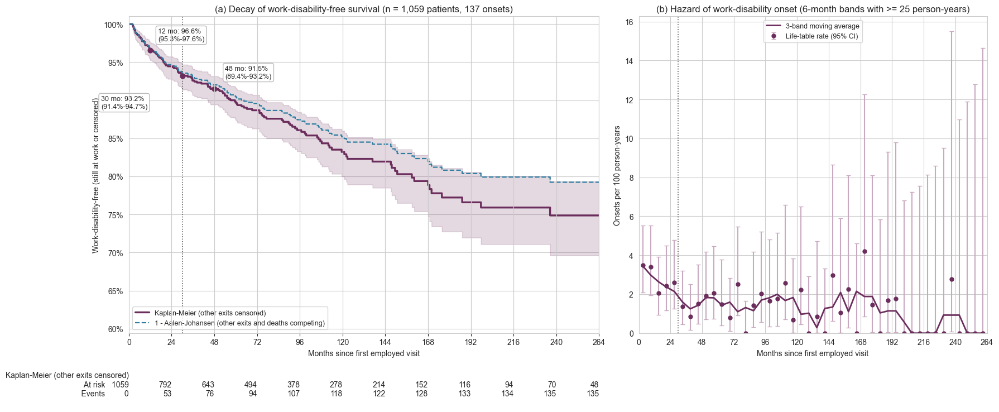

Work-disability-free at 30 months: KM 93.2% (cumulative incidence 6.8%); with other exits and deaths as competing events, cumulative incidence 6.4%
Onset rate per 100 person-years by band:
   band  events     py  rate   lo    hi
    0-6      18 515.01  3.50 2.07  5.52
   6-12      16 469.86  3.41 1.95  5.53
  12-18       9 437.34  2.06 0.94  3.91
  18-24      10 409.38  2.44 1.17  4.49
  24-30      10 384.42  2.60 1.25  4.78
  30-36       5 364.82  1.37 0.45  3.20
  36-42       3 348.14  0.86 0.18  2.52
  42-48       5 331.23  1.51 0.49  3.52
  48-54       6 312.40  1.92 0.70  4.18
  54-60       6 292.99  2.05 0.75  4.46
  60-66       4 271.80  1.47 0.40  3.77
  66-72       2 254.12  0.79 0.10  2.84
  72-78       6 238.59  2.51 0.92  5.47
  78-84       0 222.70  0.00 0.00  1.66
  84-90       3 210.56  1.42 0.29  4.16
  90-96       4 196.90  2.03 0.55  5.20
 96-102       3 182.31  1.65 0.34  4.81
102-108       3 169.82  1.77 0.36  5.16
108-114       4 155.57  2.57 0.70  6.58
114-120    

In [19]:
"""
Follow-up diagnostics and Kaplan-Meier decay of work-disability-free survival.

Time zero = first employed visit; event = first work-disability onset (dated as in the landmark builder). The
Kaplan-Meier curve censors the competing causes (other exit, death) as well as the last visit and age 65; the
Aalen-Johansen curve treats other exits and deaths as competing events (the cumulative incidence the models target).

1. How index follow-up ends, and for how long patients are followed.
2. Kaplan-Meier figure:
   (a) work-disability-free survival S(t) with its 95% CI, the number at risk underneath, and S(t) marked at 12,
       30 and 48 months -- the decay of the employed cohort. 1 - Aalen-Johansen is overlaid: it treats other exits
       and deaths as competing events instead of censoring them (the lower, 'real-world' cumulative incidence).
   (b) the hazard behind that decay: life-table onset rate per 100 person-years in 6-month bands, with exact
       Poisson 95% CIs, i.e. whether the risk of onset is front-loaded or constant over follow-up.
3. Landmark-level follow-up: how it ends, and how many landmarks are censored before 30 months (kept via IPCW).
"""
from lifelines import KaplanMeierFitter, AalenJohansenFitter
from lifelines.plotting import add_at_risk_counts

km_df = patients_df[patients_df["ever_employed"] & (patients_df["km_time_days"] > 0)].copy()
km_df["t_months"] = km_df["km_time_days"] / MONTH_DAYS
W = 100

# ------------------------------------------------------------------ 1. follow-up by how it ends
print("=" * W)
print("1. FOLLOW-UP FROM THE FIRST EMPLOYED VISIT, BY HOW IT ENDS (months)")
print("-" * W)
fu = km_df.groupby("km_exit")["t_months"].agg(N="size", median="median", q1=lambda s: s.quantile(.25),
                                             q3=lambda s: s.quantile(.75), max="max")
fu["%"] = 100 * fu["N"] / len(km_df)
print(fu.sort_values("N", ascending=False).to_string(float_format=lambda v: f"{v:.1f}"))
rkm = KaplanMeierFitter().fit(km_df["t_months"], 1 - km_df["km_event"])
print(f"\nMedian potential follow-up (reverse Kaplan-Meier): {rkm.median_survival_time_:.1f} months")
print(f"Patients followed < {PRIMARY_HORIZON_MONTHS} months without an onset: "
      f"{int(((km_df['t_months'] < PRIMARY_HORIZON_MONTHS) & (km_df['km_event'] == 0)).sum())} "
      f"(kept through the censoring-aware target)")

# ------------------------------------------------------------------ 2. Kaplan-Meier decay + hazard
kmf = KaplanMeierFitter(label="Kaplan-Meier (other exits censored)").fit(km_df["t_months"], km_df["km_event"])
ev_code = km_df["km_cause"].astype(int).values          # 1 disability, 2 other exit, 3 death, 0 censored
with warnings.catch_warnings():                      # tied times are jittered by lifelines (seeded)
    warnings.simplefilter("ignore")
    ajf = AalenJohansenFitter(calculate_variance=False, seed=SEED).fit(
        pd.Series(km_df["t_months"].values), pd.Series(ev_code), event_of_interest=1)

x_max = float(np.ceil(km_df["t_months"].quantile(0.95) / 12) * 12)
ticks = list(np.arange(0, x_max + 1, 24))
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]
kmf.plot_survival_function(ax=ax, color="#6b2d5c", lw=2.4, ci_show=True, ci_alpha=0.18)
aj_s = 1 - ajf.cumulative_density_.iloc[:, 0]
ax.step(aj_s.index, aj_s.values, where="post", color="#2c7da0", lw=1.6, ls="--",
        label="1 - Aalen-Johansen (other exits and deaths competing)")
for m, off in [(12, (10, 12)), (PRIMARY_HORIZON_MONTHS, (-105, -42)), (48, (14, 14))]:
    s = float(kmf.survival_function_at_times(m).iloc[0])
    lo, hi = kmf.confidence_interval_survival_function_.asof(m).values
    ax.scatter([m], [s], color="#6b2d5c", zorder=5, s=40)
    ax.annotate(f"{m} mo: {s:.1%}\n({lo:.1%}-{hi:.1%})", (m, s), textcoords="offset points",
                xytext=off, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#bbbbbb"))
ax.axvline(PRIMARY_HORIZON_MONTHS, color="#555555", ls=":", lw=1.2)
med = kmf.median_survival_time_
if np.isfinite(med):
    ax.axhline(0.5, color="gray", ls=":", lw=1)
    ax.text(med, 0.51, f"median {med:.0f} mo", fontsize=9, color="gray")
ax.set_xlim(0, x_max); ax.set_xticks(ticks)
ax.set_ylim(max(0.0, float(kmf.survival_function_.values.min()) - 0.1), 1.01)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Months since first employed visit")
ax.set_ylabel("Work-disability-free (still at work or censored)")
ax.set_title(f"(a) Decay of work-disability-free survival (n = {len(km_df):,} patients, "
             f"{int(km_df['km_event'].sum())} onsets)")
ax.legend(loc="lower left", fontsize=9)
add_at_risk_counts(kmf, ax=ax, rows_to_show=["At risk", "Events"], xticks=ticks)

# (b) life-table hazard in 6-month bands
band = 6.0
edges = np.arange(0, x_max + band, band)
T, E = km_df["t_months"].values, km_df["km_event"].values
rows = []
for lo, hi in zip(edges[:-1], edges[1:]):
    exposure_py = np.clip(np.minimum(T, hi) - lo, 0, None).sum() / 12.0
    d = int(((E == 1) & (T > lo) & (T <= hi)).sum())
    if exposure_py < 25:                             # too little person-time for a readable rate
        continue
    ci_lo = stats.chi2.ppf(0.025, 2 * d) / 2 if d > 0 else 0.0
    ci_hi = stats.chi2.ppf(0.975, 2 * d + 2) / 2
    rows.append({"band_mid": (lo + hi) / 2, "events": d, "py": exposure_py, "rate": 100 * d / exposure_py,
                 "lo": 100 * ci_lo / exposure_py, "hi": 100 * ci_hi / exposure_py})
hz = pd.DataFrame(rows)
ax = axes[1]
ax.errorbar(hz["band_mid"], hz["rate"], yerr=[hz["rate"] - hz["lo"], hz["hi"] - hz["rate"]], fmt="o",
            color="#6b2d5c", ecolor="#c9a9c0", capsize=3, ms=5, label="Life-table rate (95% CI)")
if len(hz) >= 3:
    sm = hz["rate"].rolling(3, center=True, min_periods=1).mean()
    ax.plot(hz["band_mid"], sm, color="#6b2d5c", lw=2, label="3-band moving average")
ax.axvline(PRIMARY_HORIZON_MONTHS, color="#555555", ls=":", lw=1.2)
ax.set_xlim(0, x_max); ax.set_xticks(ticks); ax.set_ylim(0, None)
ax.set_xlabel("Months since first employed visit")
ax.set_ylabel("Onsets per 100 person-years")
ax.set_title("(b) Hazard of work-disability onset (6-month bands with >= 25 person-years)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/revised_v16_km_work_disability_decay.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

s30 = float(kmf.survival_function_at_times(PRIMARY_HORIZON_MONTHS).iloc[0])
aj30 = float(ajf.cumulative_density_.asof(PRIMARY_HORIZON_MONTHS).iloc[0])
print(f"Work-disability-free at {PRIMARY_HORIZON_MONTHS} months: KM {s30:.1%} (cumulative incidence {1 - s30:.1%}); "
      f"with other exits and deaths as competing events, cumulative incidence {aj30:.1%}")
print("Onset rate per 100 person-years by band:")
print(hz.assign(band=lambda d: [f"{m - band / 2:.0f}-{m + band / 2:.0f}" for m in d["band_mid"]])
      [["band", "events", "py", "rate", "lo", "hi"]].to_string(index=False, float_format=lambda v: f"{v:.2f}"))

# ------------------------------------------------------------------ 3. landmark-level censoring
print("\n" + "=" * W)
print(f"3. LANDMARKS BY HOW FOLLOW-UP ENDS, and share censored before {PRIMARY_HORIZON_MONTHS} months")
print("-" * W)
lt = land.assign(before_h=(land["cause"] == 0) & (land["time_days"] <= HORIZON_DAYS))
tab = lt.groupby("exit_type").agg(landmarks=("pid", "size"), patients=("pid", "nunique"),
                                  median_fu_mo=("time_days", lambda s: s.median() / MONTH_DAYS),
                                  censored_before_30mo=("before_h", "sum"))
print(tab.to_string(float_format=lambda v: f"{v:.1f}"))
G_diag = CensoringKM(T_ALL, C_ALL)
print(f"Censoring survival G(30 mo) = {float(G_diag.at([HORIZON_DAYS])[0]):.2f}: controls are up-weighted by about "
      f"{1 / max(float(G_diag.at([HORIZON_DAYS])[0]), IPCW_MIN_G):.1f}x in every IPCW metric.")
print("=" * W)

## 11.3.1 Is censoring informative?

Censoring is harmless only if who is censored does not depend on disability risk. A **discrete-time hazard of
censoring** (the end of follow-up at the last recorded employment status or at age 65, before any onset or exit) is
fitted on the 12 variables and the calendar year in 5 patient-grouped folds and scored on the held-out patients with Uno's C for
"censored by 30 months". The interval indicators alone give C = 0.5, so the C-index measures how much the variables say
about who is censored. The rule is fixed in advance (`CENSORING_SIGNAL_C`): **C ≥ 0.60** means censoring carries
information. The sequence models' and the baseline's loss are then weighted by $1/\hat G_k(x)$ from a censoring model
fitted inside every training set, and Section 11.17.1 adds covariate-adjusted AUROC(t). Otherwise simple censoring is
kept.

In [20]:
"""
Censoring diagnostic and the censoring model used for covariate IPCW.

CensoringModel: a person-interval logistic regression of CENSORING (cause 0) on CENSORING_COLS
(training-fold skew transform + one imputation + standardisation, as the tabular models), with interval indicators as
the baseline hazard, landmark-weighted. A landmark is at risk of censoring in every interval up to the
end of its follow-up; an onset, exit or death ends that risk without being censoring (censor_causes=(0,)). With
censor_causes=(0, 2, 3) it models 'censored or a competing event', the censoring of the cause-specific evaluation.
G_before(idx)[:, k] = P(not censored before interval k | x), the weight 1 / G of interval k.
"""
from sklearn.model_selection import StratifiedGroupKFold as _SGKF


class CensoringModel:
    def __init__(self, censor_causes=(0,), C=1.0):
        self.censor_causes, self.C = tuple(censor_causes), C

    def fit(self, idx):
        idx = np.asarray(idx)
        self.prep = TabularPrep(CENSORING_COLS, m=1, method="linear")
        X = self.prep.fit_transform(X_for(idx, CENSORING_COLS), PID_ALL[idx])[0]
        b = np.searchsorted(INTERVAL_EDGES_DAYS[1:], T_ALL[idx], side="left")[:, None]
        k = np.arange(N_INTERVALS)[None, :]
        cens = np.isin(C_ALL[idx], self.censor_causes)[:, None]
        R = (k < b) | ((k == b) & cens)                                     # at risk of censoring in interval k
        r, kk = np.nonzero(R)
        y = (cens & (k == b))[r, kk].astype(int)
        Z = np.hstack([X[r], np.eye(N_INTERVALS)[kk]])
        self.lr = LogisticRegression(C=self.C, fit_intercept=False, max_iter=3000).fit(
            Z, y, sample_weight=norm_weights(land["weight"].values[idx])[r])
        return self

    def hazards(self, idx):
        idx = np.asarray(idx)
        X = self.prep.transform(X_for(idx, CENSORING_COLS), PID_ALL[idx])[0]
        Z = np.hstack([np.repeat(X, N_INTERVALS, axis=0), np.tile(np.eye(N_INTERVALS), (len(idx), 1))])
        return self.lr.predict_proba(Z)[:, 1].reshape(len(idx), N_INTERVALS)

    def G_before(self, idx):
        h = self.hazards(idx)
        return np.cumprod(np.hstack([np.ones((len(h), 1)), 1 - h[:, :-1]]), axis=1)

    def G_at_days(self, idx, days, before=False):
        """P(not censored by `days` | x) (through the interval containing `days`; before=True: before it)."""
        G = np.cumprod(1 - self.hazards(idx), axis=1)
        G0 = np.hstack([np.ones((len(G), 1)), G[:, :-1]])
        b = np.minimum(np.searchsorted(INTERVAL_EDGES_DAYS[1:], np.broadcast_to(days, (len(G),)), side="left"),
                       N_INTERVALS - 1)
        return (G0 if before else G)[np.arange(len(G)), b]


_CW_CACHE = {}


def censoring_weights(idx):
    """(len(idx), N_INTERVALS) weights 1 / G_k(x) for landmark rows idx, from a CensoringModel fitted on idx only
    (cached: every configuration of a fit shares them)."""
    idx = np.asarray(idx)
    key = hashlib.sha1(idx.tobytes()).hexdigest()
    if key not in _CW_CACHE:
        if len(_CW_CACHE) >= 8:
            _CW_CACHE.pop(next(iter(_CW_CACHE)))
        G = CensoringModel().fit(idx).G_before(idx)
        _CW_CACHE[key] = (1.0 / np.maximum(G, IPCW_MIN_G)).astype(np.float32)
    return _CW_CACHE[key]


def censoring_diagnostic(n_splits=5):
    """Out-of-fold risk of censoring by 30 months and Uno's C per held-out fold."""
    oof, cs = np.full(len(land), np.nan), []
    for a, b in _SGKF(n_splits, shuffle=True, random_state=CV_SEED).split(np.zeros(len(land)), land["pt_event"].values,
                                                                          PID_ALL):
        oof[b] = 1 - CensoringModel().fit(a).G_at_days(b, HORIZON_DAYS)
        cs.append(uno_c_index(T_ALL[b], (C_ALL[b] == 0).astype(int), oof[b], HORIZON_DAYS))
    return np.array(cs), oof


cens_c, cens_oof = censoring_diagnostic()
CENSORING_C_CV = float(np.nanmean(cens_c))
print(f"Censoring model, 5-fold patient-grouped CV: Uno's C for 'censored by {PRIMARY_HORIZON_MONTHS} months' = "
      f"{CENSORING_C_CV:.3f} (folds {', '.join(f'{c:.3f}' for c in cens_c)}); 0.5 = no information")
q = pd.qcut(cens_oof, 5, labels=False, duplicates="drop")
rows = []
for g in range(int(q.max()) + 1):
    k = q == g
    km = KaplanMeierFitter().fit(T_ALL[k], (C_ALL[k] == 0).astype(int))
    rows.append({"Quintile of predicted censoring risk": g + 1, "Landmarks": int(k.sum()),
                 "Predicted, by 30 mo": float(cens_oof[k].mean()),
                 "Observed (Kaplan-Meier), by 30 mo": float(1 - km.survival_function_at_times(HORIZON_DAYS).iloc[0]),
                 "Onset within 30 mo (share of resolved)": float(np.nanmean(land["label30"].values[k]))})
display(pd.DataFrame(rows).set_index("Quintile of predicted censoring risk").round(3))
cm_all = CensoringModel().fit(np.arange(len(land)))
coef = pd.Series(cm_all.lr.coef_[0][:len(CENSORING_COLS)], index=[DISPLAY_NAMES.get(c, c) for c in CENSORING_COLS])
print("Strongest predictors of censoring (log-odds per SD, all landmarks; for description):")
print(coef.reindex(coef.abs().sort_values(ascending=False).index)[:10].round(3).to_string())
if CENSORING_IPCW == "auto":
    CENSORING_IPCW_ON = CENSORING_C_CV >= CENSORING_SIGNAL_C
else:
    CENSORING_IPCW_ON = bool(CENSORING_IPCW)
print(f"\nDecision (C >= {CENSORING_SIGNAL_C:.2f}, CENSORING_IPCW = {CENSORING_IPCW!r}): "
      + ("censoring carries information -> covariate IPCW (1 / G_k(x), fitted inside every training set) in the "
         "sequence models' and the baseline's loss and in the cause-specific AUROC(t)" if CENSORING_IPCW_ON
         else "no real signal -> simple censoring; no covariate IPCW"))

Censoring model, 5-fold patient-grouped CV: Uno's C for 'censored by 30 months' = 0.804 (folds 0.844, 0.819, 0.810, 0.801, 0.748); 0.5 = no information


,Landmarks,"Predicted, by 30 mo","Observed (Kaplan-Meier), by 30 mo",Onset within 30 mo (share of resolved)
Quintile of predicted censoring risk,,,,
1,3371,0.066,0.049,0.050
2,3370,0.099,0.053,0.044
3,3370,0.147,0.072,0.052
4,3370,0.255,0.087,0.040
5,3370,0.596,0.492,0.032


Strongest predictors of censoring (log-odds per SD, all landmarks; for description):
Calendar year, spline term (adjustment)    1.592
Calendar year (adjustment)                -0.858
Years since first employed visit          -0.290
Days since last visit                      0.185
Education: not recorded                   -0.176
Age                                        0.079
Steroid dose (mg/day)                      0.051
SLEDAI-2K                                 -0.035
SDI damage score                           0.027
Education: higher                         -0.014

Decision (C >= 0.60, CENSORING_IPCW = 'auto'): censoring carries information -> covariate IPCW (1 / G_k(x), fitted inside every training set) in the sequence models' and the baseline's loss and in the cause-specific AUROC(t)


## 11.4 Table 1 — baseline characteristics by outcome group

In [21]:
"""
Table 1 -- baseline characteristics by outcome group.

Groups (patient level, mutually exclusive, first match wins):
  Became Disabled   : a work-disability onset after some landmark
  Other Exits       : follow-up of some landmark ended in retirement / homemaker / student / job-seeking / other
  Deceased          : died
  Remained Employed : none of the above (censored at last visit)
Plus an 'Overall' column across every patient who contributes a landmark.

Baseline = the INDEX (first employed) visit row, so every baseline value comes from the same visit. Follow-up, disease course and treatment are
aggregated over each patient's full visit record. Continuous -> mean (SD) | median [IQR], Kruskal-Wallis;
categorical -> n (%), chi-square.
"""


def _patient_outcome_group(land, pts):
    g = land.groupby("pid")
    ev = g["event"].max()
    other = g["exit_type"].apply(lambda s: (s == "other_exit").any())
    out = pd.Series("Remained Employed", index=ev.index)
    out[pts.loc[ev.index, "dead"].values] = "Deceased"
    out[other] = "Other Exits"
    out[ev == 1] = "Became Disabled"
    return out.rename("outcome_group")


def _first_nonnull(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan


def build_table1_baseline(land, pts, visits):
    outcome = _patient_outcome_group(land, pts)
    v = visits[visits["PTNO"].isin(outcome.index)]
    g = v.groupby("PTNO")
    idx_rows = v[v["ASSDT"] == v["PTNO"].map(pts["index_date"])].set_index("PTNO")
    last_rows = g.last()
    ever = lambda col: g[col].apply(lambda s: int((pd.to_numeric(s, errors="coerce").fillna(0) > 0).any()))
    b = pd.DataFrame(index=outcome.index)
    # ---- sociodemographics (patient-constant: first recorded value across all visits)
    b["sex"] = g["SEX"].apply(_first_nonnull)
    b["race"] = g["RACE_LABEL"].apply(_first_nonnull)
    b["ethnicity"] = g["DS_ETHNICITY"].apply(_first_nonnull)
    b["education"] = g["DS_MAX_EDU"].apply(_first_nonnull)
    b["age_index"] = idx_rows["age_at_record"]
    b["disease_duration_yrs"] = idx_rows["disease_duration_yrs"]
    # ---- follow-up
    b["n_visits"] = g.size()
    b["followup_years"] = (last_rows["ASSDT"] - idx_rows["ASSDT"]).dt.days / 365.25
    b["mean_gap_days"] = g["DAYS_SINCE_LAST_VISIT"].mean()
    b["n_landmarks"] = land.groupby("pid").size()
    # ---- disease activity, flares and damage
    b["sledai_baseline"] = idx_rows["SLEDAI2_I"]
    b["sledai_mean"] = g["SLEDAI2_I"].mean()
    b["sledai_ams_index"] = idx_rows["SLEDAI_AMS"]
    b["ever_flare_mild"] = g["FLARE_MILD_MOD"].max().astype(int)
    b["ever_flare_severe"] = g["FLARE_SEVERE"].max().astype(int)
    b["sdi_baseline"] = idx_rows["score_n"]
    b["sdi_last"] = last_rows["score_n"]
    # ---- employment history at index / during follow-up
    b["prior_sick_leave"] = (idx_rows["PRIOR_SICK_LEAVE_VISITS"] > 0).astype(int)
    b["ever_sick_leave"] = g["EMP"].apply(lambda s: int(s.isin(SICK_STATES).any()))
    # ---- treatment, ever during follow-up
    b["ever_steroid"] = g["ON_STEROID"].max().astype(int)
    b["steroid_dose_mean"] = g["STERAVER"].mean()
    b["ever_steroid_pulse"] = ever("STPDOSE")
    b["ever_antimalarial"] = g["ON_ANTIMALARIAL"].max().astype(int)
    b["ever_immunosuppressive"] = g["HAS_IMMUNOSUPPRESSIVE_REC"].max()
    b["ever_cyclophosphamide"] = ever("IS_CYCLOPHOSPHAMIDE_DOSE")
    b["ever_mycophenolate"] = ever("IS_MYCOPHENOLATE_DOSE")
    b["ever_methotrexate"] = ever("IS_METHOTREXATE_DOSE")
    b["ever_biologic"] = g["HAS_BIOLOGIC_REC"].max()
    b["ever_rituximab"] = ever("BIOG_RIT")
    b["ever_belimumab"] = ever("BIOG_BEL")
    return b.join(outcome, how="inner")


def _fmt_cont(s):
    s = s.dropna().astype(float)
    if not len(s):
        return "n=0"
    return f"{s.mean():.1f} ({s.std():.1f}) | {s.median():.1f} [{s.quantile(.25):.1f}-{s.quantile(.75):.1f}]"


def _fmt_cat(s, level):
    s = s.dropna()
    n = int((s == level).sum())
    return f"{n} ({100 * n / len(s):.1f}%)" if len(s) else "0"


def _pval(test):
    try:
        return f"{test():.3f}"
    except ValueError:
        return "n/a"


def make_table1(b, groups=("Remained Employed", "Became Disabled", "Deceased", "Other Exits")):
    groups = [x for x in groups if x in set(b["outcome_group"])]
    rows = [{"Variable": "N", "Overall": str(len(b)), **{x: str((b.outcome_group == x).sum()) for x in groups},
             "p": ""}]
    section = lambda t: rows.append({"Variable": f"**{t}**", "Overall": "", **{x: "" for x in groups}, "p": ""})

    def cont(col, label):
        arrs = [a for a in (b.loc[b.outcome_group == x, col].dropna().astype(float) for x in groups) if len(a)]
        rows.append({"Variable": f"{label}, mean (SD) | median [IQR]", "Overall": _fmt_cont(b[col]),
                     **{x: _fmt_cont(b.loc[b.outcome_group == x, col]) for x in groups},
                     "p": _pval(lambda: stats.kruskal(*arrs).pvalue)})

    def cat(col, label, levels=None, names=None):
        p = _pval(lambda: stats.chi2_contingency(pd.crosstab(b[col], b["outcome_group"]))[1])
        levels = levels or sorted(b[col].dropna().unique().tolist(), key=str)
        if len(levels) > 1:
            rows.append({"Variable": f"{label}, n (%)", "Overall": "", **{x: "" for x in groups}, "p": p})
        for lv in levels:
            nm = (names or {}).get(lv, lv)
            rows.append({"Variable": f"    {nm}" if len(levels) > 1 else f"{label}, n (%)",
                         "Overall": _fmt_cat(b[col], lv),
                         **{x: _fmt_cat(b.loc[b.outcome_group == x, col], lv) for x in groups},
                         "p": "" if len(levels) > 1 else p})

    section("Sociodemographics")
    cont("age_index", "Age at index (years)")
    cat("sex", "Sex")
    cat("race", "Race")
    cat("ethnicity", "Ethnicity")
    cat("education", "Education (DS_MAX_EDU)", names={0.0: "Lower", 1.0: "Higher"})
    cont("disease_duration_yrs", "Disease duration at index (years)")
    section("Follow-up")
    cont("n_visits", "Number of visits")
    cont("followup_years", "Follow-up from index (years)")
    cont("mean_gap_days", "Mean time between visits (days)")
    cont("n_landmarks", "Landmark visits")
    section("Disease activity, flares and damage")
    cont("sledai_baseline", "SLEDAI-2K at index")
    cont("sledai_ams_index", "Adjusted mean SLEDAI-2K at index")
    cont("sledai_mean", "SLEDAI-2K, mean across follow-up")
    cat("ever_flare_mild", "Any mild/moderate flare (SLEDAI-2K +4 to +10)", levels=[1])
    cat("ever_flare_severe", "Any severe flare (SLEDAI-2K > +10)", levels=[1])
    cont("sdi_baseline", "SDI at index")
    cont("sdi_last", "SDI at last visit")
    section("Employment history")
    cat("prior_sick_leave", "Sick leave before index", levels=[1])
    cat("ever_sick_leave", "Any sick leave during follow-up", levels=[1])
    section("Treatment (ever during follow-up)")
    cat("ever_steroid", "Ever on steroids", levels=[1])
    cont("steroid_dose_mean", "Average daily steroid dose, mg (visits with a value)")
    cat("ever_steroid_pulse", "Ever received steroid pulse", levels=[1])
    cat("ever_antimalarial", "Ever on antimalarial", levels=[1])
    cat("ever_immunosuppressive", "Ever on immunosuppressive therapy", levels=[1])
    cat("ever_cyclophosphamide", "    Ever cyclophosphamide", levels=[1])
    cat("ever_mycophenolate", "    Ever mycophenolate", levels=[1])
    cat("ever_methotrexate", "    Ever methotrexate", levels=[1])
    cat("ever_biologic", "Ever on biologic therapy", levels=[1])
    cat("ever_rituximab", "    Ever rituximab", levels=[1])
    cat("ever_belimumab", "    Ever belimumab", levels=[1])
    return pd.DataFrame(rows)[["Variable", "Overall"] + groups + ["p"]]


table1_base = build_table1_baseline(land, patients_df, visits)
table1 = make_table1(table1_base)
pd.set_option("display.max_rows", None)
display(table1)
table1.to_csv("table1_baseline_characteristics_model_revised_v16.csv", index=False)

,Variable,Overall,Remained Employed,Became Disabled,Deceased,Other Exits,p
0,N,1059,687,150,33,189,
1,**Sociodemographics**,,,,,,
2,"Age at index (years), mean (SD) | median [IQR]",36.1 (10.9) | 34.5 [27.3-43.8],35.5 (10.6) | 33.7 [27.6-42.4],38.4 (11.1) | 38.8 [29.3-47.0],42.3 (12.1) | 42.4 [31.9-53.5],35.0 (11.4) | 33.9 [25.7-43.3],0.000
3,"Sex, n (%)",,,,,,0.020
4,F,933 (88.2%),603 (87.9%),138 (92.0%),24 (72.7%),168 (88.9%),
5,M,125 (11.8%),83 (12.1%),12 (8.0%),9 (27.3%),21 (11.1%),
6,"Race, n (%)",,,,,,0.000
7,Black,151 (14.7%),94 (14.4%),29 (19.3%),7 (21.2%),21 (11.2%),
8,Caucasian,611 (59.6%),355 (54.2%),99 (66.0%),20 (60.6%),137 (72.9%),
9,Chinese,111 (10.8%),86 (13.1%),10 (6.7%),3 (9.1%),12 (6.4%),


## 11.5 Variables

Section 5. The fixed variable set used by every model in every fold (no selection), with a descriptive table at the
landmark visits.

Sample-size cap (Riley et al.; time-to-event; anticipated C = 0.72):


,value
Patients (n),1059
Patients with an onset,150
Anticipated C,0.72
Anticipated R2_CS,0.0916
Max R2_CS,0.9295
P allowed: shrinkage >= 0.9,11.4
P allowed: optimism <= 0.05,53.0
n needed: overall risk +-0.05,187
Criterion (iii) met,True
P_MAX,11


-> at most 11 parameters: 3 forced (Age, Calendar year (adjustment), Calendar year, spline term (adjustment)) + up to 8 selected by the LASSO.

All-data LASSO (cap rule; 466s): 8 selected (the CV-optimal penalty would select 35; binding: cap):


,Group,"Coefficient (log-odds per SD, penalised)"
Dyspnoea,Symptoms,0.1461
Steroid dose (mg/day),Treatment,0.1016
Years since first employed visit,Demographics,-0.0983
"Acute visit (pulse, steroid increase or new immunosuppressant)",Treatment,0.0617
EULAR treatment step (0-4),Treatment,0.0576
Education: not recorded,Demographics,-0.0317
Adjusted mean SLEDAI-2K,Severity scores,0.0112
LLDAS (no physician global),Severity scores,-0.0020



Pre-filter decisions for every candidate (no outcome used):


,Group,Missing at landmarks,Prevalence (binary),Decision
Variable,,,,
Age,Demographics,0.0%,NaN,forced (unpenalised)
Sex: female,Demographics,0.0%,0.893709,candidate
Education: higher,Demographics,12.4%,0.473748,candidate
Education: not recorded,Demographics,0.0%,0.124028,candidate
Current smoker,Demographics,0.5%,0.093974,candidate
BMI (kg/m2),Demographics,17.3%,NaN,candidate
Years since first employed visit,Demographics,0.0%,NaN,candidate
Disease duration (yrs),Demographics,0.0%,NaN,candidate
Age at diagnosis,Demographics,0.0%,NaN,candidate


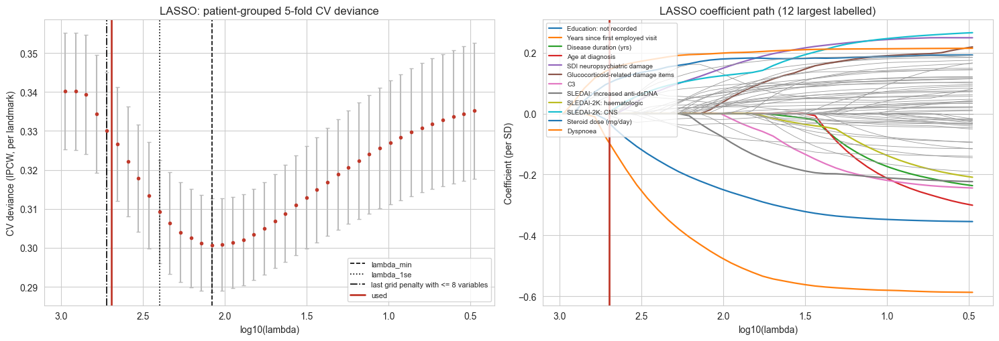

Bootstrap stability (200 patient resamples, penalty fixed): candidates selected in >= 20% of resamples


,Selected on all data,Bootstrap frequency
Dyspnoea,True,0.925
Years since first employed visit,True,0.705
"Acute visit (pulse, steroid increase or new immunosuppressant)",True,0.700
Steroid dose (mg/day),True,0.685
Education: not recorded,True,0.670
EULAR treatment step (0-4),True,0.575
SLEDAI-2K: CNS,False,0.415
Proteinuria (SLEDAI-2K item),False,0.360
Adjusted mean SLEDAI-2K,True,0.335
"Acute-care events, last 12 mo",False,0.335


(array([[ 118.4459563 , -152.74120723,  -97.1370394 , ...,   -0.29911467,
           -0.41187347,   -0.45697213],
        [ 123.44347369, -145.97082989,  -97.13701128, ...,   -0.29911467,
           -0.41187347,   -0.45697213],
        [ 126.32795944, -142.06718889,  -97.13495622, ...,   -0.29911467,
           -0.41187347,   -0.45697213],
        ...,
        [  49.7507898 ,  137.26969261,  181.17675008, ...,   -0.29911467,
           -0.41187347,    2.18831725],
        [ -22.34536038,  -94.97951943,  -94.932536  , ...,   -0.29911467,
            2.42793009,    2.18831725],
        [-133.9531324 ,  163.49728052,  232.06203869, ...,   -0.29911467,
           -0.41187347,   -0.45697213]], shape=(71920, 74)),
 array([0, 0, 0, ..., 0, 0, 1], shape=(71920,)),
 array([0.24472806, 0.24472806, 0.24472806, ..., 0.48945611, 1.95782446,
        3.354651  ], shape=(71920,)),
 array([  17,   17,   17, ..., 2271, 2294, 2298], shape=(71920,)))

In [22]:
"""
Variables: candidate pool, pre-filter and LASSO selection (Sections 5.1-5.3; TRIPOD+AI items 9 and 10).

CAP. The largest number of parameters P_MAX that meets the three criteria of Riley et al. (BMJ 2020; Stat Med 2019,
time-to-event version) for the cohort -- n = patients with a landmark, phi = share with an onset -- at an anticipated
C of ANTICIPATED_C (revised_v12's visit-level C of every model): (i) expected uniform shrinkage >= 0.9, (ii) optimism
in Nagelkerke R2 <= 0.05, (iii) the overall risk within +-0.05. The anticipated Cox-Snell R2 comes from a simulated
time-to-event cohort with this event share whose Harrell C equals ANTICIPATED_C. The forced terms (age, the two
calendar-year terms) take len(FORCED_COLS) of the P_MAX parameters; the LASSO may select up to LASSO_MAX_SELECTED.

LASSO (lasso_select). L1-penalised logistic regression of 'onset within 30 months' -- the competing-risk IPCW label of
every metric in this notebook (an other exit by 30 months is a resolved non-event; landmarks censored earlier drop out)
-- on the standardised candidates, weighted IPCW x landmark weight, the M imputations stacked with weight 1/M (Wood,
White & Royston, Stat Med 2008). Forced terms are unpenalised (their columns are scaled up by FORCE_SCALE, which
makes their L1 penalty negligible). The penalty path has LASSO_N_LAMBDA values; the CV deviance comes from
LASSO_CV_SPLITS patient-grouped folds of the same rows (as Chen et al., 5-fold). The penalty used:
  'cap'  (main)        : lambda* = max(lambda_min, lambda_cap): the largest set with <= LASSO_MAX_SELECTED variables, but
                         never weaker than the CV-optimal penalty;
  '1se' / 'min'        : the sensitivity analyses (Chen et al.'s rule; no cap).
The selection is made ONCE, here, on all landmarks, and every model of every CV fold uses it (Section 11.8, part 3),
so the cross-validated performance does not include the selection step. It is also the published model, the nomogram
and the final refits; shown with its CV curve, coefficient path and bootstrap stability.
"""
from sklearn.model_selection import StratifiedGroupKFold
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

FORCE_SCALE = 100.0
LASSO_REFINE_STEPS = 8              # bisection steps between two grid penalties when the cap falls between them


def _sim_survival(sigma, phi, n, seed):
    """A time-to-event cohort: exponential event times with log-hazard ~ N(0, sigma^2), uniform censoring scaled so
    that a share phi has the event."""
    rng = np.random.default_rng(seed)
    lp = rng.normal(0.0, sigma, n)
    t, u = rng.exponential(np.exp(-lp)), rng.random(n)
    m = brentq(lambda mm: (t < u * mm).mean() - phi, 1e-6, 1e6)
    c = u * m
    return lp, np.minimum(t, c), (t < c).astype(int)


def riley_pmax(n, events, c_stat, S=0.9, n_sim=None, seed=SEED):
    """P_MAX of Riley et al.'s criteria (time-to-event version) for n patients with `events` onsets at anticipated
    Harrell C `c_stat`."""
    n_sim = n_sim or (5000 if SMOKE else 20000)
    phi = events / n
    c_of = lambda s: concordance_index(*(lambda lp, t, e: (t, -lp, e))(*_sim_survival(s, phi, n_sim, seed)))
    sigma = brentq(lambda s: c_of(s) - c_stat, 0.05, 3.0, xtol=1e-3)
    lp, t, e = _sim_survival(sigma, phi, n_sim, seed)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cph = CoxPHFitter().fit(pd.DataFrame({"t": t, "e": e, "lp": lp}), "t", "e")
    lr = float(cph.log_likelihood_ratio_test().test_statistic)
    r2 = 1 - np.exp(-lr / n_sim)
    r2max = 1 - np.exp(2 * (cph.log_likelihood_ - lr / 2) / n_sim)
    p_of = lambda s: n * (s - 1) * np.log(1 - r2 / s)
    s2 = r2 / (r2 + 0.05 * r2max)
    p1, p2 = p_of(S), p_of(s2)
    n3 = (1.96 / 0.05) ** 2 * phi * (1 - phi)
    return {"Patients (n)": n, "Patients with an onset": events, "Anticipated C": c_stat,
            "Anticipated R2_CS": round(r2, 4), "Max R2_CS": round(r2max, 4),
            "P allowed: shrinkage >= 0.9": round(p1, 1), "P allowed: optimism <= 0.05": round(p2, 1),
            "n needed: overall risk +-0.05": int(np.ceil(n3)), "Criterion (iii) met": bool(n >= n3),
            "P_MAX": int(np.floor(min(p1, p2)))}


RILEY = riley_pmax(int(land["pid"].nunique()), int(land.groupby("pid")["event"].max().sum()), ANTICIPATED_C)
P_MAX = RILEY["P_MAX"]
LASSO_MAX_SELECTED = max(1, P_MAX - len(FORCED_COLS))


def _lasso_data(rows, m=None):
    """Stacked LASSO design of landmark rows: (X, y, w, patient, columns). Forced columns first (scaled by
    FORCE_SCALE), then PENALISED_COLS; rows resolved at 30 months only."""
    rows = np.asarray(rows)
    cols = FORCED_COLS + PENALISED_COLS
    prep = TabularPrep(cols, m=m)
    Xs = prep.fit_transform(X_for(rows, cols), PID_ALL[rows])
    y, w = ipcw_label_weight(T_ALL[rows], C_ALL[rows], HORIZON_DAYS, CensoringKM(T_ALL[rows], C_ALL[rows]))
    w = w * land["weight"].values[rows]
    k = w > 0
    nf = len(FORCED_COLS)
    X = np.vstack([np.hstack([Xk[k][:, :nf] * FORCE_SCALE, Xk[k][:, nf:]]) for Xk in Xs])
    mm = len(Xs)
    return X, np.tile(y[k], mm), np.tile(w[k] / w[k].mean(), mm) / mm, np.tile(PID_ALL[rows][k], mm), cols


def _l1_fit(X, y, w, C):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return LogisticRegression(l1_ratio=1.0, solver="liblinear", C=C, intercept_scaling=FORCE_SCALE, tol=1e-4,
                                  max_iter=500).fit(X, y, sample_weight=w)


def _wdev(model, X, y, w):
    p = np.clip(model.predict_proba(X)[:, 1], 1e-9, 1 - 1e-9)
    return -np.sum(w * (y * np.log(p) + (1 - y) * np.log(1 - p))) / w.sum()


def lasso_select(rows, seed=SEED, rule=None, keep_path=False):
    """The LASSO selection on landmark rows `rows` (Section 5.3). Returns the selected model columns (forced terms
    first), the 0/1 selection of every penalised candidate ('freq'), the penalty and its coefficients; with keep_path,
    also the path and the CV curve."""
    rule = rule or SELECTION_RULE
    t0 = time.time()
    X, y, w, g, cols = _lasso_data(rows, m=LASSO_M_IMPUTATIONS)
    nf = len(FORCED_COLS)
    r = w * (y - np.average(y, weights=w))
    c0 = 1.0 / max(np.max(np.abs(X[:, nf:].T @ r)), 1e-12)               # the weakest penalty with no variable in
    Cs = c0 * np.logspace(0, LASSO_C_DECADES, LASSO_N_LAMBDA)
    path = np.array([_l1_fit(X, y, w, C).coef_[0, nf:] for C in Cs])
    nsel = (path != 0).sum(1)
    folds = list(StratifiedGroupKFold(LASSO_CV_SPLITS, shuffle=True, random_state=seed).split(X, y, g))
    dev = np.array([[_wdev(_l1_fit(X[a], y[a], w[a], C), X[b], y[b], w[b]) for C in Cs] for a, b in folds])
    mean, se = dev.mean(0), dev.std(0, ddof=1) / np.sqrt(len(folds))
    i_min = int(np.argmin(mean))
    i_1se = int(np.min(np.flatnonzero(mean <= mean[i_min] + se[i_min])))
    over = np.flatnonzero(nsel > LASSO_MAX_SELECTED)
    i_cap = int(over[0] - 1) if len(over) else len(Cs) - 1
    i_cap = max(i_cap, 0)
    i_star = {"cap": min(i_min, i_cap), "min": i_min, "1se": i_1se}[rule]
    C_star, b_star = Cs[i_star], path[i_star]
    if rule == "cap" and i_cap < i_min and i_cap + 1 < len(Cs):
        # the count can jump past the cap between two penalties of the grid: bisect (log scale) for the weakest penalty
        # in between that still selects <= LASSO_MAX_SELECTED (never weaker than lambda_min, since i_cap < i_min)
        lo, hi = np.log(Cs[i_cap]), np.log(Cs[i_cap + 1])
        for _ in range(LASSO_REFINE_STEPS):
            mid = 0.5 * (lo + hi)
            b = _l1_fit(X, y, w, np.exp(mid)).coef_[0, nf:]
            if (b != 0).sum() <= LASSO_MAX_SELECTED:
                lo, C_star, b_star = mid, np.exp(mid), b
            else:
                hi = mid
    chosen = {c for c, b in zip(PENALISED_COLS, b_star) if b != 0}
    out = {"features": [c for c in FEATURE_CANDIDATES if c in FORCED_COLS or c in chosen],
           "freq": pd.Series([float(c in chosen) for c in PENALISED_COLS], index=PENALISED_COLS),
           "coef": pd.Series(b_star, index=PENALISED_COLS), "rule": rule, "C": float(C_star),
           "index": {"min": i_min, "1se": i_1se, "cap": i_cap, "chosen": i_star}, "n_selected": len(chosen),
           "n_at_min": int(nsel[i_min]),
           "binding": ("cap" if i_cap < i_min else "lambda_min") if rule == "cap" else rule,
           "seconds": time.time() - t0}
    if keep_path:
        out.update(Cs=Cs, path=path, nsel=nsel, cv_mean=mean, cv_se=se, data=(X, y, w, g))
    return out


SELECTION_ALL = lasso_select(np.arange(len(land)), keep_path=True)
print(f"Sample-size cap (Riley et al.; time-to-event; anticipated C = {ANTICIPATED_C}):")
display(pd.Series(RILEY).to_frame("value"))
print(f"-> at most {P_MAX} parameters: {len(FORCED_COLS)} forced ({', '.join(DISPLAY_NAMES.get(c, c) for c in FORCED_COLS)}) "
      f"+ up to {LASSO_MAX_SELECTED} selected by the LASSO.")
print(f"\nAll-data LASSO ({SELECTION_ALL['rule']} rule; {SELECTION_ALL['seconds']:.0f}s): {SELECTION_ALL['n_selected']} "
      f"selected (the CV-optimal penalty would select {SELECTION_ALL['n_at_min']}; binding: {SELECTION_ALL['binding']}):")
_sel = SELECTION_ALL["coef"][SELECTION_ALL["coef"] != 0]
display(pd.DataFrame({"Group": [FEATURE_GROUP_OF.get(c, "") for c in _sel.index],
                      "Coefficient (log-odds per SD, penalised)": _sel.values},
                     index=[DISPLAY_NAMES.get(c, c) for c in _sel.index]).sort_values(
    "Coefficient (log-odds per SD, penalised)", key=np.abs, ascending=False).round(4))

if SLE_VARIANT == "main":
    print("\nPre-filter decisions for every candidate (no outcome used):")
    display(PREFILTER_TABLE.assign(**{"Missing at landmarks": PREFILTER_TABLE["Missing at landmarks"].map("{:.1%}".format)})
            .set_index("Variable"))
    PREFILTER_TABLE.to_csv("candidate_prefilter_revised_v16.csv")
    # ---- CV curve and coefficient path (Chen et al. Figure 2)
    s = SELECTION_ALL
    ll = np.log10(1.0 / s["Cs"])                                           # log10 lambda (liblinear: lambda = 1 / C)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
    ax = axes[0]
    ax.errorbar(ll, s["cv_mean"], yerr=s["cv_se"], fmt="o", ms=3, color="#c0392b", ecolor="#bbbbbb", capsize=2)
    for key, ls, lab in [("min", "--", "lambda_min"), ("1se", ":", "lambda_1se"),
                         ("cap", "-.", f"last grid penalty with <= {LASSO_MAX_SELECTED} variables")]:
        ax.axvline(ll[s["index"][key]], color="black", ls=ls, lw=1.2, label=lab)
    ax.axvline(np.log10(1.0 / s["C"]), color="#c0392b", lw=2, label="used")
    ax.set_xlabel("log10(lambda)"); ax.set_ylabel("CV deviance (IPCW, per landmark)")
    ax.set_title("LASSO: patient-grouped 5-fold CV deviance"); ax.legend(fontsize=8)
    top = np.argsort(-np.abs(s["path"][-1]))[:12]
    ax = axes[1]
    for j in range(s["path"].shape[1]):
        ax.plot(ll, s["path"][:, j], color="#999999" if j not in top else None, lw=0.6 if j not in top else 1.6,
                label=DISPLAY_NAMES.get(PENALISED_COLS[j], PENALISED_COLS[j]) if j in top else None)
    ax.axvline(np.log10(1.0 / s["C"]), color="#c0392b", lw=2)
    ax.set_xlabel("log10(lambda)"); ax.set_ylabel("Coefficient (per SD)")
    ax.set_title("LASSO coefficient path (12 largest labelled)"); ax.legend(fontsize=7, loc="upper left")
    for a in axes:
        a.invert_xaxis()                                                   # weaker penalty to the right
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_lasso_path.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    # ---- bootstrap stability of the all-data selection (the penalty fixed at the all-data one)
    X_, y_, w_, g_ = s["data"]
    codes, inv = np.unique(g_, return_inverse=True)
    rng_ = np.random.default_rng(2033)
    hits = np.zeros(len(PENALISED_COLS))
    for _ in range(LASSO_BOOT):
        cnt = np.bincount(rng_.integers(0, len(codes), len(codes)), minlength=len(codes))[inv].astype(float)
        k = cnt > 0
        hits += _l1_fit(X_[k], y_[k], (w_ * cnt)[k], s["C"]).coef_[0, len(FORCED_COLS):] != 0
    SEL_BOOT_FREQ = pd.Series(hits / LASSO_BOOT, index=PENALISED_COLS)
    print(f"Bootstrap stability ({LASSO_BOOT} patient resamples, penalty fixed): candidates selected in >= 20% of resamples")
    _b = SEL_BOOT_FREQ[SEL_BOOT_FREQ >= 0.2].sort_values(ascending=False)
    display(pd.DataFrame({"Selected on all data": [bool(SELECTION_ALL["freq"][c]) for c in _b.index],
                          "Bootstrap frequency": _b.values}, index=[DISPLAY_NAMES.get(c, c) for c in _b.index]).round(3))
else:
    SEL_BOOT_FREQ = None
SELECTION_ALL.pop("data", None)

## 11.6 Patient-level evaluation

Section 9.2: every patient's 30-month window (before onset; before retirement / homemaker at ≥ 60; or the latest fully
observed 30 months), the final-status strata and age bands, and the functions that turn visit alarms into
TP / FN / TN / FP and a patient probability. Printed: the evaluation funnel.

In [23]:
"""
Patient-level evaluation: visit alarms accumulated over each patient's visits.

Nothing is trained or tuned at the patient level. Every model is trained on landmark visits and its alarm threshold is
learned at visit level inside each training fold (Section 9). A landmark ALARMS (the patient is labelled high risk at
that visit) when its calibrated 30-month risk is >= that threshold. Patients are scored while held out, from their
test-fold visit alarms, over a 30-MONTH WINDOW of landmarks -- the horizon the models predict -- for everyone:

  Event patients (a work-disability onset):
    window  the landmarks in the 30 months before an onset (any onset, if the patient has several)
    TP / FN an alarm / no alarm in that window. No landmark in it: not assessable.
  Event-free patients, stratified by FINAL STATUS (state at their last visit):
    "Retired / homemaker >= 60"  final visit retired or homemaker, having left employment for it at age >= 60:
                                 window = the landmarks in the 30 months before that exit
    "Employed at final visit"    window = the latest 30 months of landmarks that were each followed by >= 30 months
                                 of observed follow-up with no onset and no other exit (a fully observed negative
                                 window; how their employment eventually ends does not matter for a 30-month claim)
    "Other final status"         everyone else (other exits, retirement before 60, deaths): the same fully observed
                                 window as the employed
    TN / FP no alarm / an alarm in that window. No landmark in it: not assessable.
The primary table uses every evaluable patient; each final-status stratum also gets its own table (all event patients
vs that stratum's negatives), and specificity and the C-index are reported by age band (age at the end of the window).

Patient probability, for the C-index, Brier score and calibration: the patient's highest calibrated 30-month risk over
the window, mapped to the probability of being an event patient by a logistic recalibration fitted in each training
fold on the training patients' cross-fitted (OOF) risks. PPV and NPV are also given at the cohort's share of patients
with an onset (Bayes' rule on sensitivity and specificity), since the evaluated sample's event share is not the
clinic's. Everything here is computed from the stored fold predictions, so the definition can change without re-running
the cross-validation.
"""
STRATA = ["Employed at final visit", f"Retired / homemaker >= {NEG_MIN_AGE}", "Other final status"]
AGE_BANDS = [(0, 40, "< 40"), (40, 50, "40-49"), (50, 60, "50-59"), (60, 200, ">= 60")]


def _exit_to_final_state(p):
    """(date, age) of the first visit of the patient's final non-working run if it was entered straight from
    employment, else (None, None)."""
    states = [_state_of(e) for e in p["EMP"].values]
    j = len(states) - 1
    while j >= 0 and states[j] != "W":
        j -= 1
    if j < 0 or j == len(states) - 1:
        return None, None
    k = j + 1
    while k < len(states) and states[k] == "U":
        k += 1
    if k >= len(states):
        return None, None
    return p["ASSDT"].iat[k], float(p["age_at_record"].iat[k])


def build_patient_truth(visits, land):
    """One row per patient with landmarks: group ('event' / 'negative' / 'excluded'), final-status stratum, the reason
    for exclusion, and the window end (onset, exit, or the end of the fully observed negative window)."""
    lg = land.groupby("pid", sort=False)
    ev, has_win = lg["event"].max(), lg["in_window"].max()
    rows = []
    for pid, idx in visits.groupby("PTNO", sort=False).indices.items():
        if pid not in ev.index:
            continue
        p = visits.iloc[idx]
        final = p["EMP"].iat[-1]
        rec = {"pid": pid, "group": "excluded", "stratum": None, "reason": None, "final_status": final,
               "exit_date": pd.NaT}
        if ev[pid] == 1:
            rec["stratum"] = "Event"
            if has_win[pid]:
                rec["group"] = "event"
            else:
                rec["reason"] = "onset with no landmark in the 30 months before"
            rows.append(rec)
            continue
        d_exit, a_exit = _exit_to_final_state(p)
        if final in NEG_EXIT_STATES and d_exit is not None and a_exit >= NEG_MIN_AGE:
            rec.update(stratum=STRATA[1], exit_date=d_exit)
        elif final in WORKING_STATES:
            rec["stratum"] = STRATA[0]
        else:
            rec["stratum"] = STRATA[2]
        rec["group"] = "negative"                        # confirmed below: needs a landmark in its window
        rows.append(rec)
    return pd.DataFrame(rows).set_index("pid")


PT_TRUTH = build_patient_truth(visits, land)
_stratum = PT_TRUTH["stratum"].reindex(PID_ALL).values
_exit = pd.to_datetime(PT_TRUTH["exit_date"].reindex(PID_ALL).values)
_vdate = pd.to_datetime(land["visit_date"].values)
_days_to_exit = np.asarray((_exit - _vdate).days, float)          # NaN if no retirement exit
# retirees: the 30 months before the exit
_win_retired = (_stratum == STRATA[1]) & (_days_to_exit > 0) & (_days_to_exit <= HORIZON_DAYS)
# everyone else event-free: the latest 30 months of landmarks each followed >= 30 months with no onset or exit
_resolved = (land["time_days"].values > HORIZON_DAYS) & (land["event"].values == 0)
_neg_other = np.isin(_stratum, [STRATA[0], STRATA[2]]) & _resolved
_last_resolved = pd.Series(np.where(_neg_other, _vdate.values, np.datetime64("NaT")),
                           dtype="datetime64[ns]").groupby(PID_ALL).transform("max").values
_win_observed = _neg_other & ((_last_resolved - _vdate.values) / np.timedelta64(1, "D") <= HORIZON_DAYS)
LAND_PT_WIN = np.where(_stratum == "Event", land["in_window"].values == 1, _win_retired | _win_observed)

_has_window = pd.Series(LAND_PT_WIN).groupby(PID_ALL).max()
_no_win = (PT_TRUTH["group"] == "negative") & ~_has_window.reindex(PT_TRUTH.index).fillna(False).astype(bool)
PT_TRUTH.loc[_no_win, "reason"] = np.where(PT_TRUTH.loc[_no_win, "stratum"] == STRATA[1],
                                          "retired >= 60: no landmark in the 30 months before the exit",
                                          "event-free: never followed >= 30 months after a landmark")
PT_TRUTH.loc[_no_win, "group"] = "excluded"
PT_Y = (PT_TRUTH["group"] == "event").astype(int)
# age at the end of each evaluable patient's window (its last deciding landmark)
PT_AGE = pd.Series(land["age_at_record"].values[LAND_PT_WIN]).groupby(PID_ALL[LAND_PT_WIN]).max()
PT_AGE_BAND = pd.cut(PT_AGE, [a for a, _, _ in AGE_BANDS] + [AGE_BANDS[-1][1]], right=False,
                     labels=[lab for _, _, lab in AGE_BANDS]).astype(str)
COHORT_EVENT_SHARE = float(land.groupby("pid")["event"].max().mean())   # share of landmark patients with an onset


def print_patient_funnel():
    t = PT_TRUTH
    ev = t[t.group == "event"]
    print(f"Patient-level evaluation set ({len(t)} patients with landmarks; cohort share with an onset "
          f"{COHORT_EVENT_SHARE:.1%}):")
    print(f"  event patients with a landmark in the 30 months before onset (TP / FN): {len(ev)}")
    print("  event-free patients with a 30-month window (TN / FP), by final status:")
    for s in STRATA:
        n = int(((t.group == "negative") & (t.stratum == s)).sum())
        print(f"    {s:<40}{n:>6}")
    print("  not evaluated:")
    for reason, n in t[t.group == "excluded"]["reason"].value_counts().items():
        print(f"    {reason:<62}{n:>6}")
    ages = pd.DataFrame({"age band": PT_AGE_BAND, "y": PT_Y.reindex(PT_AGE_BAND.index)})
    print("  evaluable patients by age at the end of their window (events / event-free): "
          + ", ".join(f"{b}: {int((g.y == 1).sum())} / {int((g.y == 0).sum())}"
                      for b, g in ages.groupby("age band", sort=False)))
    print(f"  landmarks that decide a patient's outcome: {int(LAND_PT_WIN.sum()):,}")


print_patient_funnel()


def patient_frame(rows, p, thr):
    """Collapses landmark `rows` (calibrated 30-month risks p and visit thresholds thr, aligned with rows) to one row
    per evaluable patient: y (1 = event patient), score (highest risk in the window), flag (any alarm in it), n_win,
    lead_mo (event patients: months from the earliest alarm in the window to onset), stratum and age band."""
    rows, p = np.asarray(rows), np.asarray(p, float)
    thr = np.broadcast_to(np.asarray(thr, float), p.shape)
    k = LAND_PT_WIN[rows]
    r = rows[k]
    d = pd.DataFrame({"pid": PID_ALL[r], "s": p[k], "a": p[k] >= thr[k], "t": T_ALL[r]})
    g = d.groupby("pid", sort=False)
    f = pd.DataFrame({"score": g["s"].max(), "flag": g["a"].max().astype(int), "n_win": g.size()})
    f["lead_mo"] = d[d["a"]].groupby("pid")["t"].max().reindex(f.index) / MONTH_DAYS
    f["y"] = PT_Y.loc[f.index].values
    f["stratum"] = PT_TRUTH.loc[f.index, "stratum"].values
    f["age_band"] = PT_AGE_BAND.loc[f.index].values
    return f


def fit_patient_calibrator(tr, p_oof):
    """Logistic recalibration of the patient score to 'event patient', on the training patients' OOF risks."""
    f = patient_frame(tr, p_oof, np.inf)
    return Calibrator().fit(f["score"].values, f["y"].values, np.ones(len(f)), True)


def patient_counts(f):
    y, a = f["y"].values, f["flag"].values
    return {"TP": int(((y == 1) & (a == 1)).sum()), "FN": int(((y == 1) & (a == 0)).sum()),
            "TN": int(((y == 0) & (a == 0)).sum()), "FP": int(((y == 0) & (a == 1)).sum())}


# subgroup attributes (fairness, Section 11.23): sex and race per patient; age band per landmark (visit level) and at
# the end of the window (patient level)
_first = lambda s: s.dropna().iloc[0] if s.notna().any() else None
_pv = visits.groupby("PTNO")[["SEX", "RACE_LABEL"]].agg(_first)
RACE_GROUPS = {"Caucasian": "White", "Black": "Black", "Chinese": "Asian (Chinese, Filipino)",
               "Filipino": "Asian (Chinese, Filipino)"}
PT_ATTR = pd.DataFrame({"sex": _pv["SEX"].map({"F": "Female", "M": "Male"}).fillna("Not recorded"),
                        "race": _pv["RACE_LABEL"].map(RACE_GROUPS).fillna("Other / not recorded")}).reindex(PT_TRUTH.index)
LAND_ATTR = {"sex": PT_ATTR["sex"].reindex(PID_ALL).values, "race": PT_ATTR["race"].reindex(PID_ALL).values,
             "age": pd.cut(land["age_at_record"], [a for a, _, _ in AGE_BANDS] + [AGE_BANDS[-1][1]], right=False,
                           labels=[lab for _, _, lab in AGE_BANDS]).astype(str).values}


Patient-level evaluation set (1059 patients with landmarks; cohort share with an onset 14.2%):
  event patients with a landmark in the 30 months before onset (TP / FN): 141
  event-free patients with a 30-month window (TN / FP), by final status:
    Employed at final visit                    597
    Retired / homemaker >= 60                   17
    Other final status                          78
  not evaluated:
    event-free: never followed >= 30 months after a landmark         206
    retired >= 60: no landmark in the 30 months before the exit       11
    onset with no landmark in the 30 months before                     9
  evaluable patients by age at the end of their window (events / event-free): >= 60: 8 / 69, 50-59: 44 / 152, 40-49: 30 / 162, < 40: 59 / 309
  landmarks that decide a patient's outcome: 4,251


1. FOLLOW-UP FROM THE INDEX VISIT BY GROUP (months; horizon 30 mo; data cut 2024-04-08)
----------------------------------------------------------------------------------------------------
GROUP                                                         N  MEDIAN             IQR    MIN    MAX
A. Employed only at the last recorded status (excluded)      53     0.0       0.0 - 0.0    0.0    0.0
B. Work-disability onset (kept)                             150    35.6     12.2 - 84.3    2.1  311.9
C. Onset-free, resolved at horizon (kept)                   744    90.0    51.5 - 147.1    1.2  390.3
D. Onset-free, censored before horizon (kept, IPCW)         165    14.0      7.0 - 21.6    1.9   30.0

Group D: how far short of 30 months?
  0-6 mo                         33   20.0%  cumulative  20.0%
  6-12 mo                        37   22.4%  cumulative  42.4%
  12-18 mo                       31   18.8%  cumulative  61.2%
  18-24 mo                       38   23.0%  cumulative  84.2%
  24-30 mo 

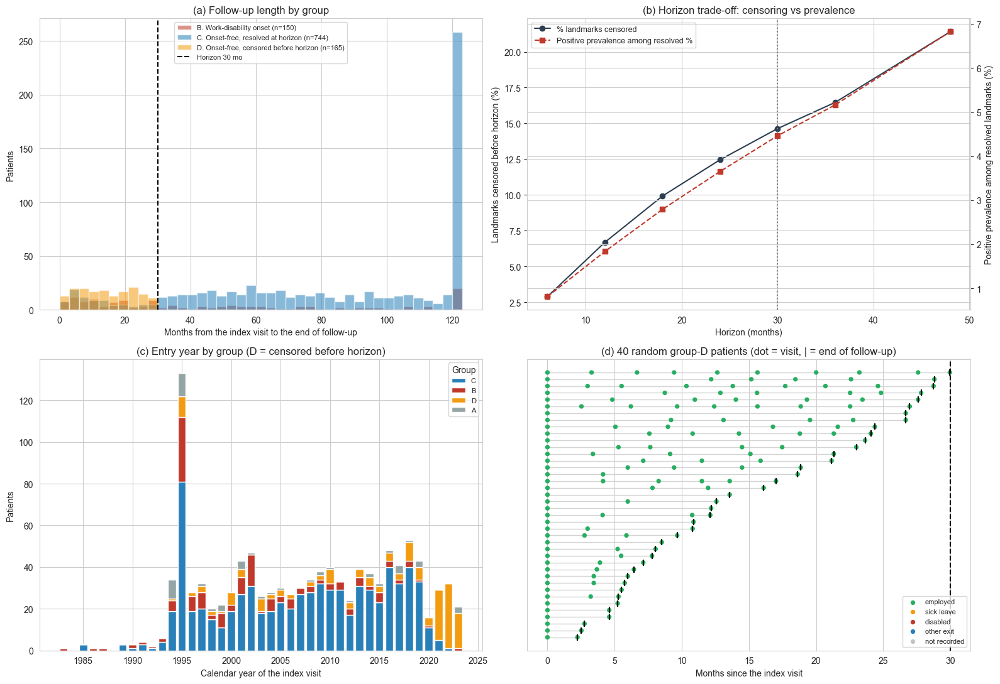

In [24]:
"""
Follow-up diagnostics for the landmark cohort. Run AFTER 11.2 (uses visits, land, patients_df, _state_of,
FEATURE_CANDIDATES, DISPLAY_NAMES, HORIZON_DAYS, MONTH_DAYS, AGE_CAP_YEARS, DEATH_AS_COMPETING_EVENT, CensoringKM).

No patient is dropped for short follow-up here: censored landmarks are kept and handled by IPCW. So the question is
not 'who is lost?' but 'who is censored before 30 months, why, and do they differ from the rest?'. Patient groups
(index = first employed visit before age 65; follow-up from it as in patients_df, i.e. cell 11.3):
  A  ever employed, no landmark (the only employed visit is the last recorded status)        -> excluded
  B  a work-disability onset at some landmark                                                 -> kept
  C  onset-free, resolved at the horizon: followed >= horizon, or other exit / death before it -> kept, label 0
  D  onset-free, censored before the horizon                                                  -> kept, IPCW-weighted
"""
GROUP_LABELS = {
    "A": "A. Employed only at the last recorded status (excluded)",
    "B": "B. Work-disability onset (kept)",
    "C": "C. Onset-free, resolved at horizon (kept)",
    "D": "D. Onset-free, censored before horizon (kept, IPCW)",
}
STATE_COLORS = {"W": "#27ae60", "S": "#f39c12", "D": "#c0392b", "O": "#2980b9", "U": "#bdc3c7"}


def followup_diagnostics(horizon_days=HORIZON_DAYS, horizon_grid_months=(6, 12, 18, 24, 30, 36, 48),
                         ltfu_window_days=365, n_swim=40, seed=CV_SEED, plot=True):
    H_m = horizon_days / MONTH_DAYS
    data_cut = visits["ASSDT"].max()
    gidx = visits.groupby("PTNO", sort=False).indices
    first_onset = land.loc[land["event"] == 1].groupby("pid")["event_date"].min()

    recs = []
    for pid, r in patients_df[patients_df["ever_employed"]].iterrows():
        p = visits.iloc[gidx[pid]]
        idx_date, fu_d = r["index_date"], r["km_time_days"]
        post = p[p["ASSDT"] >= idx_date]
        gaps = post["ASSDT"].diff().dt.days.dropna()
        last_visit = p["ASSDT"].max()                          # any visit (attendance)
        end_date = idx_date + pd.Timedelta(days=fu_d)          # end of index follow-up (last recorded status / cap)
        has_event = pid in first_onset.index
        if r["n_landmarks"] == 0:
            grp = "A"
        elif has_event:
            grp = "B"
        elif fu_d >= horizon_days or r["km_cause"] >= 2:
            grp = "C"
        else:
            grp = "D"
        reason = ""
        if grp == "D":
            if r["km_exit"] == "age_cap":
                reason = f"Reached age {AGE_CAP_YEARS}"
            elif r["dead"]:
                reason = "Died (censored at last recorded status)"
            elif r["trailing_unrecorded"] > 0:
                reason = "Later visits, employment status not recorded"
            elif (data_cut - last_visit).days <= ltfu_window_days:
                reason = "Still attending at data cut (late entry)"
            else:
                reason = "Stopped attending > 1 yr before data cut (probable LTFU)"
        lcdt = pd.to_datetime(p["LCDT"], errors="coerce").max()
        row = p.loc[p["ASSDT"] == idx_date].iloc[0]
        rec = {"pid": pid, "group": grp, "reason": reason, "has_event": has_event, "km_exit": r["km_exit"],
               "index_date": idx_date, "index_year": idx_date.year, "fu_m": fu_d / MONTH_DAYS,
               "time_to_event_m": (first_onset[pid] - idx_date).days / MONTH_DAYS if has_event else np.nan,
               "n_visits": len(post), "n_landmarks": r["n_landmarks"],
               "median_gap_d": gaps.median() if len(gaps) else np.nan,
               "max_gap_d": gaps.max() if len(gaps) else np.nan,
               "days_last_visit_to_cut": (data_cut - last_visit).days,
               "lcdt_minus_end_d": (lcdt - end_date).days if pd.notna(lcdt) else np.nan,
               "_visits": list(zip((post["ASSDT"] - idx_date).dt.days / MONTH_DAYS, post["EMP"].map(_state_of)))}
        rec.update({f"base_{c}": row[c] for c in FEATURE_CANDIDATES})
        recs.append(rec)
    d = pd.DataFrame(recs)
    W = 100

    # ------------------------------------------------------------------ 1. follow-up length by group
    print("=" * W)
    print(f"1. FOLLOW-UP FROM THE INDEX VISIT BY GROUP (months; horizon {H_m:.0f} mo; data cut {data_cut.date()})")
    print("-" * W)
    print(f"{'GROUP':<58}{'N':>5}{'MEDIAN':>8}{'IQR':>16}{'MIN':>7}{'MAX':>7}")
    for g, lab in GROUP_LABELS.items():
        x = d.loc[d.group == g, "fu_m"]
        if len(x):
            print(f"{lab:<58}{len(x):>5}{x.median():>8.1f}{f'{x.quantile(.25):.1f} - {x.quantile(.75):.1f}':>16}"
                  f"{x.min():>7.1f}{x.max():>7.1f}")
    D = d[d.group == "D"]
    if len(D):
        edges = [0, 6, 12, 18, H_m - 6, H_m]
        labels = ["0-6 mo", "6-12 mo", "12-18 mo", f"18-{H_m - 6:.0f} mo", f"{H_m - 6:.0f}-{H_m:.0f} mo (near miss)"]
        t = pd.cut(D["fu_m"], bins=edges, labels=labels, include_lowest=True).value_counts().reindex(labels)
        print(f"\nGroup D: how far short of {H_m:.0f} months?")
        for lab, n in t.items():
            print(f"  {lab:<28}{n:>5}  {n / len(D):>6.1%}  cumulative {t.loc[:lab].sum() / len(D):>6.1%}")

        # ------------------------------------------------------------ 2. why is it short
        print("\n" + "=" * W)
        print("2. WHY IS FOLLOW-UP SHORT? (group D)")
        print("-" * W)
        r = D.groupby("reason").agg(N=("pid", "size"), median_fu_mo=("fu_m", "median"),
                                    median_last_visit_to_cut_d=("days_last_visit_to_cut", "median"))
        r["%"] = r["N"] / len(D) * 100
        print(r.sort_values("N", ascending=False).to_string(float_format=lambda v: f"{v:.1f}"))
        lc = D["lcdt_minus_end_d"].dropna()
        if len(lc):
            print(f"\nLCDT (last contact) minus end of follow-up, group D: median {lc.median():.0f} d; "
                  f"{(lc > 180).mean():.1%} have contact > 6 mo later (alive and in contact, status unknown)")

    # ------------------------------------------------------------------ 3. visit pattern
    print("\n" + "=" * W)
    print("3. VISIT PATTERN (from the index visit)")
    print("-" * W)
    vp = d.groupby("group").agg(N=("pid", "size"), visits_med=("n_visits", "median"),
                                landmarks_med=("n_landmarks", "median"), gap_med_d=("median_gap_d", "median"),
                                max_gap_med_d=("max_gap_d", "median"),
                                last_visit_to_cut_med_d=("days_last_visit_to_cut", "median"))
    print(vp.to_string(float_format=lambda v: f"{v:.1f}"))
    print("\nBy calendar year of the index visit (are recent entrants the censored ones?):")
    ct = pd.crosstab(d["index_year"], d["group"]).reindex(columns=list("ABCD"), fill_value=0)
    ct["% censored (D)"] = ct["D"] / ct.sum(axis=1) * 100
    print(ct.to_string(float_format=lambda v: f"{v:.0f}"))

    # ------------------------------------------------------------------ 4. horizon: how many landmark labels resolve
    print("\n" + "=" * W)
    print("4. HORIZON SENSITIVITY (landmark set is fixed; only which labels resolve changes)")
    print("-" * W)
    G = CensoringKM(T_ALL, C_ALL)
    rows = []
    for m in horizon_grid_months:
        H = round(m * MONTH_DAYS)
        h = land["time_days"] <= H
        pos = (land["cause"] == 1) & h
        neg = ~h | (land["cause"] >= 2)
        cens = ~pos & ~neg
        rows.append({"Horizon (mo)": m, "Positive rows": int(pos.sum()), "Negative rows": int(neg.sum()),
                     "Censored rows": int(cens.sum()), "% censored": 100 * cens.mean(),
                     "Prevalence among resolved %": 100 * pos.sum() / max((pos | neg).sum(), 1),
                     "Patients w/ positive row": land.loc[pos, "pid"].nunique(),
                     "G(h)": float(G.at([H])[0])})
    sens = pd.DataFrame(rows)
    print(sens.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

    # ------------------------------------------------------------------ 5. what dropping D would do
    print("\n" + "=" * W)
    print("5. WOULD DROPPING THE CENSORED PATIENTS BIAS THE COHORT?")
    print("-" * W)
    e = d[d.group != "A"]
    kept = e[e.group.isin(["B", "C"])]
    within = lambda x: (x["has_event"] & (x["time_to_event_m"] <= H_m))
    print(f"Onset within {H_m:.0f} mo of the index visit:")
    print(f"  crude, all patients with a landmark (censored = onset-free) : {within(e).mean():.1%}  (n={len(e)})")
    print(f"  crude, resolved patients only (B+C; drops D)                : {within(kept).mean():.1%}  (n={len(kept)})")
    km_in = patients_df.loc[e["pid"]]
    kmf = KaplanMeierFitter().fit(km_in["km_time_days"] / MONTH_DAYS, km_in["km_event"])
    print(f"  Kaplan-Meier (censoring-aware; other exits censored)        : {1 - kmf.predict(H_m):.1%}")
    print("  -> the gap between 'resolved only' and KM is the bias IPCW avoids by keeping group D.")

    if len(D):
        print(f"\nIndex-visit variables, resolved (B+C) vs censored (D) -- standardised mean difference:")
        out = []
        for c in [c for c in FEATURE_CANDIDATES if c != "YRS_SINCE_INDEX"]:   # 0 at every index visit
            a, b = kept[f"base_{c}"].astype(float), D[f"base_{c}"].astype(float)
            sd = np.sqrt((a.var() + b.var()) / 2)
            out.append({"Variable": DISPLAY_NAMES.get(c, c), "Resolved mean": a.mean(), "Censored mean": b.mean(),
                        "SMD": (a.mean() - b.mean()) / sd if sd > 0 else np.nan})
        smd = pd.DataFrame(out).sort_values("SMD", key=np.abs, ascending=False)
        smd["Flag"] = np.where(smd["SMD"].abs() > 0.1, "<-- imbalance (>0.1)", "")
        print(smd.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
        print("(Calendar year is expected to differ: late entrants are censored. Cell 11.3.1 tests whether censoring "
              "is predictable from the variables.)")
    print("=" * W)

    # ------------------------------------------------------------------ plots
    if plot:
        fig, ax = plt.subplots(2, 2, figsize=(16, 11))
        a = ax[0, 0]
        bins = np.arange(0, min(d["fu_m"].max(), 120) + 6, 3)
        for g, col in [("B", "#c0392b"), ("C", "#2980b9"), ("D", "#f39c12")]:
            x = d.loc[d.group == g, "fu_m"].clip(upper=bins[-1] - 0.01)
            a.hist(x, bins=bins, alpha=0.55, color=col, label=GROUP_LABELS[g].split(" (")[0] + f" (n={len(x)})")
        a.axvline(H_m, color="black", ls="--", label=f"Horizon {H_m:.0f} mo")
        a.set_xlabel("Months from the index visit to the end of follow-up"); a.set_ylabel("Patients")
        a.set_title("(a) Follow-up length by group"); a.legend(fontsize=8)

        a = ax[0, 1]
        a.plot(sens["Horizon (mo)"], sens["% censored"], "o-", color="#2c3e50", label="% landmarks censored")
        a.set_xlabel("Horizon (months)"); a.set_ylabel("Landmarks censored before horizon (%)")
        a2 = a.twinx()
        a2.plot(sens["Horizon (mo)"], sens["Prevalence among resolved %"], "s--", color="#c0392b",
                label="Positive prevalence among resolved %")
        a2.set_ylabel("Positive prevalence among resolved landmarks (%)")
        a.axvline(H_m, color="gray", ls=":"); a.set_title("(b) Horizon trade-off: censoring vs prevalence")
        h1, l1 = a.get_legend_handles_labels(); h2, l2 = a2.get_legend_handles_labels()
        a.legend(h1 + h2, l1 + l2, loc="best", fontsize=9)

        a = ax[1, 0]
        bottom = np.zeros(len(ct))
        for g, col in [("C", "#2980b9"), ("B", "#c0392b"), ("D", "#f39c12"), ("A", "#95a5a6")]:
            a.bar(ct.index, ct[g], bottom=bottom, color=col, label=g); bottom += ct[g].values
        a.set_xlabel("Calendar year of the index visit"); a.set_ylabel("Patients")
        a.set_title("(c) Entry year by group (D = censored before horizon)"); a.legend(title="Group", fontsize=8)

        a = ax[1, 1]
        sw = D.sample(min(n_swim, len(D)), random_state=seed).sort_values("fu_m") if len(D) else D
        for k, (_, r) in enumerate(sw.iterrows()):
            xs = [x for x, _ in r["_visits"]]
            a.plot([0, max(xs)], [k, k], color="lightgray", lw=1, zorder=1)
            a.scatter(xs, [k] * len(xs), c=[STATE_COLORS[s] for _, s in r["_visits"]], s=18, zorder=2)
            a.scatter([r["fu_m"]], [k], marker="|", color="black", s=60, zorder=3)
        a.axvline(H_m, color="black", ls="--"); a.set_yticks([])
        for s, lab in [("W", "employed"), ("S", "sick leave"), ("D", "disabled"), ("O", "other exit"), ("U", "not recorded")]:
            a.scatter([], [], c=STATE_COLORS[s], s=18, label=lab)
        a.legend(fontsize=8, loc="lower right")
        a.set_xlabel("Months since the index visit")
        a.set_title(f"(d) {len(sw)} random group-D patients (dot = visit, | = end of follow-up)")
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/revised_v16_followup_diagnostics.png", dpi=150, bbox_inches="tight")
        plt.show(); plt.close()
    return d, sens


fu_df, horizon_table = followup_diagnostics()

## 11.6.1 Sample size and missing data

TRIPOD+AI items 10 and 11: the Riley et al. minimum sample size for the number of candidate parameters, at anticipated
C-statistics of 0.65, 0.70 and 0.75; and, for every variable, how often it was recorded at the landmark visits, how
much is still missing after carry-forward, and how the rest is handled.

In [25]:
"""
Sample size and missing data (TRIPOD+AI items 10 and 11).

SAMPLE SIZE. Minimum sample size for developing a prediction model of a binary outcome (Riley et al., BMJ 2020): the
largest n that meets
  (1) expected uniform shrinkage >= 0.9:          n = P / ((S - 1) ln(1 - R2_CS / S)), S = 0.9
  (2) optimism in Nagelkerke R2 <= 0.05:          as (1) with S = R2_CS / (R2_CS + 0.05 R2_CS,max)
  (3) overall risk estimated within +-0.05:       n = (1.96 / 0.05)^2 phi (1 - phi)
P = candidate predictor parameters, phi = outcome proportion, R2_CS = the anticipated Cox-Snell R2, derived from an
anticipated C-statistic (Riley et al. 2021: a logistic model with a normal linear predictor whose C-statistic and
outcome proportion match). The unit is the PATIENT (landmarks of one patient are not independent), with phi = the
share of patients with an onset. P is given for the cap of Section 11.5 (set by the time-to-event version of these criteria) and for the whole
candidate pool.
These criteria are for regression models; flexible models (RSF, LSTM, GRU, Transformer) typically need more data.

MISSING DATA. For each variable: how often its source was recorded AT the landmark visit, how often it is still
missing after carry-forward, and how the remainder is handled (multiple imputation, fitted inside each training fold).
"""
PRED_UNIT_N = int(land["pid"].nunique())
PRED_UNIT_EVENTS = int(land.groupby("pid")["event"].max().sum())
P_LINEAR = P_MAX                                       # the cap (Section 11.5): forced terms + the LASSO's selection
P_LOGREG = len(FEATURE_CANDIDATES)                     # every candidate after the pre-filter, if nothing were selected


def r2cs_from_c(c, phi, n=400_000, seed=SEED):
    """Cox-Snell R2 of a logistic model with a normal linear predictor whose C-statistic is c and mean risk phi."""
    z = np.random.RandomState(seed).standard_normal(n)
    expit = lambda v: 1.0 / (1.0 + np.exp(-v))

    def model(sigma):
        mu = brentq(lambda m: expit(m + sigma * z).mean() - phi, -30, 30)
        return mu + sigma * z, expit(mu + sigma * z)

    def c_of(sigma):
        lp, p = model(sigma)
        return roc_auc_score(np.r_[np.ones(n), np.zeros(n)], np.r_[lp, lp], sample_weight=np.r_[p, 1 - p])

    sigma = brentq(lambda s: c_of(s) - c, 0.01, 6.0)
    _, p = model(sigma)
    ll_model = np.mean(p * np.log(p) + (1 - p) * np.log(1 - p))
    ll_null = phi * np.log(phi) + (1 - phi) * np.log(1 - phi)
    return 1 - np.exp(-2 * (ll_model - ll_null)), 1 - np.exp(2 * ll_null)


def riley_sample_size(P, phi, c):
    r2, r2max = r2cs_from_c(c, phi)
    n_of = lambda S: P / ((S - 1) * np.log(1 - r2 / S))
    s2 = r2 / (r2 + 0.05 * r2max)
    n1, n2, n3 = n_of(0.9), n_of(s2), (1.96 / 0.05) ** 2 * phi * (1 - phi)
    n = int(np.ceil(max(n1, n2, n3)))
    return {"Anticipated C": c, "Predictor parameters (P)": P, "Anticipated R2_CS": round(r2, 3),
            "n: shrinkage >= 0.9": int(np.ceil(n1)), "n: optimism <= 0.05": int(np.ceil(n2)),
            "n: overall risk +-0.05": int(np.ceil(n3)), "Minimum n (patients)": n,
            "Minimum events": int(np.ceil(n * phi)), "Events per parameter needed": round(n * phi / P, 1)}


phi_pt = PRED_UNIT_EVENTS / PRED_UNIT_N
sample_size = pd.DataFrame([riley_sample_size(P, phi_pt, c) for P in (P_LINEAR, P_LOGREG) for c in (0.65, 0.70, ANTICIPATED_C, 0.75)])
print(f"Available: {PRED_UNIT_N} patients, {PRED_UNIT_EVENTS} with a work-disability onset (phi = {phi_pt:.3f}); "
      f"{PRED_UNIT_EVENTS / P_LINEAR:.1f} events per parameter at the cap of {P_LINEAR} parameters, "
      f"{PRED_UNIT_EVENTS / P_LOGREG:.1f} for all {P_LOGREG} candidates (binary approximation below; the cap itself "
      f"comes from the time-to-event version, Section 11.5).")
display(sample_size.set_index(["Predictor parameters (P)", "Anticipated C"]))
print("Minimum sample size met for:", ", ".join(f"P = {r['Predictor parameters (P)']}, C = {r['Anticipated C']}"
                                                for _, r in sample_size.iterrows()
                                                if r["Minimum n (patients)"] <= PRED_UNIT_N) or "none")

# ---------------------------------------------------------------------------------------------------- missing data


def _handling(c):
    if c in TREATMENT_COLS:
        return "not recorded at the visit = not on the drug (0); never imputed"
    if c.endswith("_NA"):
        return f"indicator: not measured in the last {STALE_MONTHS} months (complete)"
    if c in STALE_CONT or c in ("HIGH_BP", "EGFR_LT60"):
        return (f"carried forward for at most {STALE_MONTHS} months; then multiply imputed (auxiliaries: the last value "
                f"ever recorded and its age)")
    if c in ADJUST_COLS:
        return "visit date (never missing); clipped to the training years at prediction"
    if c in PATIENT_CONSTANT_COLS:
        return "patient-level; multiply imputed (one value per patient)" + ("; + 'not recorded' indicator"
                                                                           if c == "EDU_HIGHER" else "")
    return "carried forward (or derived from carried-forward items); the remainder multiply imputed"


missing_table = pd.DataFrame([{"Group": FEATURE_GROUP_OF.get(c, ""), "Variable": DISPLAY_NAMES.get(c, c),
                               "Missing after carry-forward / derivation": f"{land[c].isna().mean():.1%}",
                               "Handling": _handling(c)} for c in FEATURE_CANDIDATES]).set_index("Variable")
print("\nMissing data at the landmark visits (TRIPOD+AI item 11), every candidate after the pre-filter. Carry-forward, "
      f"then multiple imputation by chained equations (m = {M_IMPUTATIONS}, "
      f"{'random-forest' if IMPUTATION == 'rf' else 'Bayesian linear'} conditionals with draws, fitted on each training "
      "fold without the outcome and applied to its held-out rows); every model is fitted on each completed dataset and "
      "the predicted risks are averaged (XGBoost handles missing values natively).")
display(missing_table)

Available: 1059 patients, 150 with a work-disability onset (phi = 0.142); 13.6 events per parameter at the cap of 11 parameters, 2.0 for all 74 candidates (binary approximation below; the cap itself comes from the time-to-event version, Section 11.5).


Anticipated R2_CS  \
Predictor parameters (P) Anticipated C                      
11                       0.65                       0.035   
                         0.70                       0.062   
                         0.72                       0.076   
                         0.75                       0.099   
74                       0.65                       0.035   
                         0.70                       0.062   
                         0.72                       0.076   
                         0.75                       0.099   

                                        n: shrinkage >= 0.9  \
Predictor parameters (P) Anticipated C                        
11                       0.65                          2790   
                         0.70                          1531   
                         0.72                          1251   
                         0.75                           949   
74                       0.65                         18766   
                         0.70                         10300   
                         0.72                          8411   
                         0.75                          6382   

                                        n: optimism <= 0.05  \
Predictor parameters (P) Anticipated C                        
11                       0.65                           382   
                         0.70                           377   
                         0.72                           374   
                         0.75                           369   
74                       0.65                          2570   
                         0.70                          2532   
                         0.72                          2514   
                         0.75                          2483   

                                        n: overall risk +-0.05  \
Predictor parameters (P) Anticipated C                           
11                       0.65                              187   
                         0.70                              187   
                         0.72                              187   
                         0.75                              187   
74                       0.65                              187   
                         0.70                              187   
                         0.72                              187   
                         0.75                              187   

                                        Minimum n (patients)  Minimum events  \
Predictor parameters (P) Anticipated C                                         
11                       0.65                           2790             396   
                         0.70                           1531             217   
                         0.72                           1251             178   
                         0.75                            949             135   
74                       0.65                          18766            2659   
                         0.70                          10300            1459   
                         0.72                           8411            1192   
                         0.75                           6382             904   

                                        Events per parameter needed  
Predictor parameters (P) Anticipated C                               
11                       0.65                                  35.9  
                         0.70                                  19.7  
                         0.72                                  16.1  
                         0.75                                  12.2  
74                       0.65                                  35.9  
                         0.70                                  19.7  
                         0.72                                  16.1  
                         0.75                                  12.2

Minimum sample size met for: P = 11.0, C = 0.75

Missing data at the landmark visits (TRIPOD+AI item 11), every candidate after the pre-filter. Carry-forward, then multiple imputation by chained equations (m = 5, random-forest conditionals with draws, fitted on each training fold without the outcome and applied to its held-out rows); every model is fitted on each completed dataset and the predicted risks are averaged (XGBoost handles missing values natively).


,Group,Missing after carry-forward / derivation,Handling
Variable,,,
Age,Demographics,0.0%,carried forward (or derived from carried-forwa...
Sex: female,Demographics,0.0%,patient-level; multiply imputed (one value per...
Education: higher,Demographics,12.4%,patient-level; multiply imputed (one value per...
Education: not recorded,Demographics,0.0%,carried forward (or derived from carried-forwa...
Current smoker,Demographics,0.5%,carried forward (or derived from carried-forwa...
BMI (kg/m2),Demographics,17.3%,carried forward for at most 12 months; then mu...
Years since first employed visit,Demographics,0.0%,carried forward (or derived from carried-forwa...
Disease duration (yrs),Demographics,0.0%,carried forward (or derived from carried-forwa...
Age at diagnosis,Demographics,0.0%,carried forward (or derived from carried-forwa...


## 11.6.2 Participant flow

TRIPOD+AI item 20a: patients and landmark visits at every step, with events, for the visit-level analysis and the
patient-level evaluation.

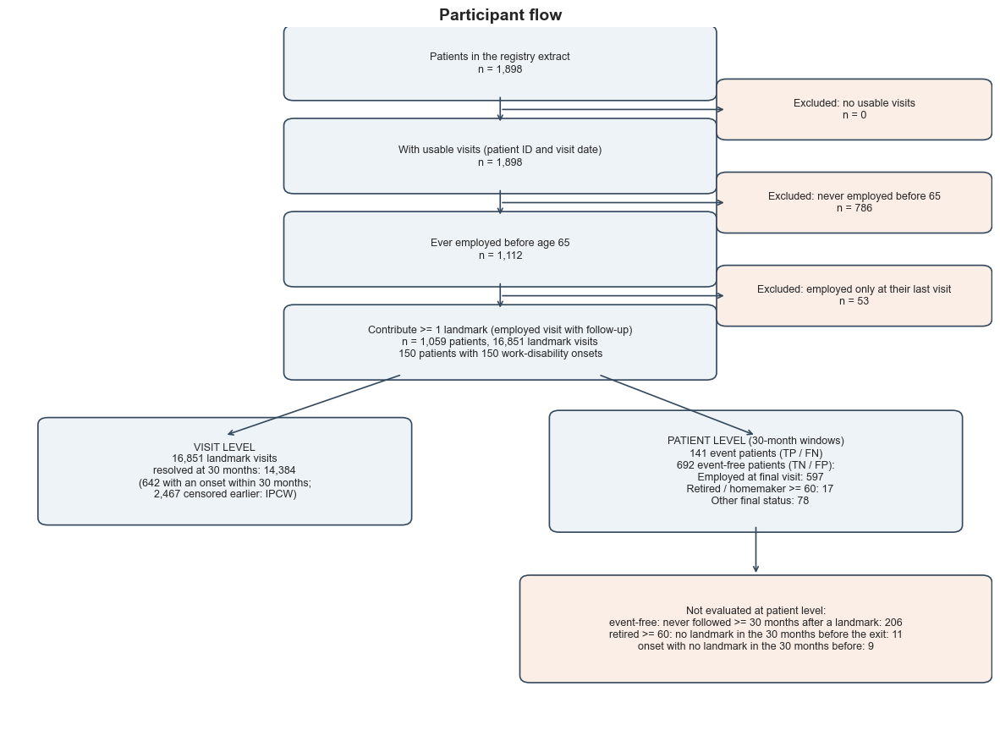

In [26]:
"""Participant flow diagram (TRIPOD+AI item 20a): patients and landmark visits at every step, with events, for the
visit-level analysis (left) and the patient-level evaluation (right)."""
from matplotlib.patches import FancyBboxPatch


def _box(ax, x, y, text, w=0.3, h=0.085, fc="#eef3f8"):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0.01", fc=fc, ec="#34495e", lw=1.2))
    ax.text(x, y, text, ha="center", va="center", fontsize=9)


def _arrow(ax, x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="->", color="#34495e", lw=1.2))


def plot_flow():
    a, pts, t = load_audit, patients_df, PT_TRUTH
    y30, w30 = ipcw_label_weight(T_ALL, C_ALL, HORIZON_DAYS, CensoringKM(T_ALL, C_ALL))
    n_onsets = int((land.loc[land["event"] == 1, "visit_date"] + pd.to_timedelta(
        land.loc[land["event"] == 1, "time_days"], unit="D")).groupby(land.loc[land["event"] == 1, "pid"]).nunique().sum())
    fig, ax = plt.subplots(figsize=(15, 11))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    steps = [(0.95, f"Patients in the registry extract\nn = {a['raw_patients']:,}"),
             (0.82, f"With usable visits (patient ID and visit date)\nn = {a['usable_patients']:,}"),
             (0.69, f"Ever employed before age {AGE_CAP_YEARS}\nn = {int(pts['ever_employed'].sum()):,}"),
             (0.56, f"Contribute >= 1 landmark (employed visit with follow-up)\nn = {land['pid'].nunique():,} patients, "
                    f"{len(land):,} landmark visits\n{int(t.stratum.eq('Event').sum())} patients with "
                    f"{n_onsets} work-disability onsets")]
    for (y, txt), (y2, _) in zip(steps, steps[1:] + [(None, None)]):
        _box(ax, 0.5, y, txt, w=0.42)
        if y2 is not None:
            _arrow(ax, 0.5, y - 0.045, 0.5, y2 + 0.045)
    excl = [(0.885, f"Excluded: no usable visits\nn = {a['raw_patients'] - a['usable_patients']:,}"),
            (0.755, f"Excluded: never employed before {AGE_CAP_YEARS}\n"
                    f"n = {a['usable_patients'] - int(pts['ever_employed'].sum()):,}"),
            (0.625, f"Excluded: employed only at their last visit\n"
                    f"n = {int(pts['ever_employed'].sum()) - land['pid'].nunique():,}")]
    for y, txt in excl:
        _box(ax, 0.86, y, txt, w=0.26, h=0.065, fc="#fbeee6")
        _arrow(ax, 0.5, y, 0.73, y)
    # visit level
    _arrow(ax, 0.4, 0.515, 0.22, 0.43)
    _box(ax, 0.22, 0.38, f"VISIT LEVEL\n{len(land):,} landmark visits\nresolved at 30 months: {int((w30 > 0).sum()):,}\n"
                         f"({int(((y30 == 1) & (w30 > 0)).sum()):,} with an onset within 30 months;\n"
                         f"{int((w30 == 0).sum()):,} censored earlier: IPCW)", w=0.36, h=0.13)
    # patient level
    _arrow(ax, 0.6, 0.515, 0.76, 0.43)
    neg = t[t.group == "negative"]
    _box(ax, 0.76, 0.38, f"PATIENT LEVEL (30-month windows)\n{int(t.group.eq('event').sum())} event patients "
                         f"(TP / FN)\n{len(neg)} event-free patients (TN / FP):\n"
                         + "\n".join(f"   {s}: {int(neg.stratum.eq(s).sum())}" for s in STRATA), w=0.4, h=0.15)
    ex = t[t.group == "excluded"]["reason"].value_counts()
    _arrow(ax, 0.76, 0.305, 0.76, 0.235)
    _box(ax, 0.76, 0.16, "Not evaluated at patient level:\n" + "\n".join(f"{r}: {n}" for r, n in ex.items()),
         w=0.46, h=0.13, fc="#fbeee6")
    ax.set_title("Participant flow", fontsize=14, fontweight="bold")
    plt.savefig(f"{OUT_DIR}/revised_v16_flow_diagram.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


plot_flow()

## 11.7 Sequential models (time-aware LSTM / GRU / Transformer)

Section 6.1. The main model is the LSTM; GRU and Transformer use the same recipe. A smoke test on 40 real
patients (half with an onset) runs at the end of the cell. It checks whole-history and windowed batching, pretraining,
the cause-specific hazard heads (with the interval-censored likelihood and the warm start), early stopping and the seed ensemble in a few seconds.

In [27]:
"""Sequence models: the main LSTM, plus GRU and Transformer on the same recipe.

  * Encoder: a 1-layer LSTM with 16 hidden units (the main LSTM and its variants; GRU / Transformer 32), dropout 0.3 on
    its output. GRU and Transformer: one pass per patient over the WHOLE visit history (visits before the index visit and
    while not employed included), with a prediction at every landmark. The LSTM reads each landmark's last 8 visits
    (LSTM1: the current visit alone).
  * Skip connection (the LSTMs): the heads also receive the current visit's variables, warm-started from a
    person-interval logistic regression. Auxiliary heads (the LSTMs; aux): three logistic heads on the hidden state
    predict AUX_TARGETS within 12 months (masked binary cross-entropy, patient-weighted, x aux_weight), training only.
  * Inputs per visit: the fold's LASSO-selected columns (Section 11.5), log(1 + years since the previous visit), and the
    visit's employment state (employed / sick leave / disabled / other exit, one-hot). The calendar year (ADJUST_COLS,
    clipped to the training years) is NOT an encoder input: it feeds the hazard heads only. Scaled with the training
    fold's landmark rows (skew transform + multiple imputation + standardisation + clipping); seed s of the ensemble
    trains on imputation s (mod M_IMPUTATIONS).
  * Self-supervised pretraining: before seeing any disability label, the encoder learns to predict the next visit's
    SLEDAI-2K, SDI and steroid dose (squared error) from the history and the gap to that visit, for 10 epochs, on every
    patient outside the held-out ones. Pretraining is redone for every seed.
  * Heads: one linear layer from the hidden state to a logistic hazard per 3-month interval (16 intervals) for work
    disability and, with exit_head, a second one for other exits (and death, if counted): discrete-time
    cause-specific hazards, each head treating the other cause as censoring. Output: the cause-specific risk of work
    disability, R(k) = 1 - prod_{j <= k} (1 - h_1(j)).
  * Loss: the cause-specific likelihood (cs_hazard_nll) -- survived intervals log(1 - h); an event log h_b, or
    log[S(a - 1) - S(b)] when interval-censored between the last employed visit and the recording visit -- weighted by
    the landmark weight (and 1 / G_k(x) with covariate IPCW). No class weights or balanced batches.
  * Warm start: interval biases at the training life-table (Kaplan-Meier) hazards; then the calendar-year weights
    and the biases (with the skip connection, also the skip weights) from a person-interval logistic regression.
  * Training: AdamW (lr 3e-3, weight decay 1e-2),
    gradient clipping, batches of 64 patients, up to 60 epochs with EARLY STOPPING (patience 8) on 20% of the fit's
    patients held out as a validation set; the best-validation weights are kept.
  * Ensemble: 5 seeds (each with its own pretraining, initialisation and validation split) in the outer-fold fit; their
    per-interval hazards are averaged.
  * LSTM history window: fixed (SEQ_GRIDS; the main LSTM k = 8, LSTM1 k = 1, supplementary k = 4, 16).

GRU and Transformer: the identical recipe (inputs, pretraining, head, early stopping, 5 seeds) with a GRU cell or a
1-layer causal Transformer (2 heads, feed-forward 64, lr 1e-3, plus elapsed years since the first visit as an input).

History window (max_visits; None = whole history for GRU and Transformer): each landmark sees only its last k
visits (Section 11.9.1).
"""
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

torch.set_num_threads(max(1, os.cpu_count() or 1))

VIS_COLS = list(dict.fromkeys(FEATURE_CANDIDATES + AUX_ALL))               # every candidate + imputation auxiliaries
VX_RAW = visits[VIS_COLS].values.astype(float)                             # encoder features, every visit
VIS_IDX = {c: j for j, c in enumerate(VIS_COLS)}
V_GAP = np.log1p(visits.groupby("PTNO")["ASSDT"].diff().dt.days.fillna(0.0).values / 365.25).astype(np.float32)
V_STATE = visits[["EMP_WORKING", "EMP_SICK", "EMP_DISABLED", "EMP_OTHER"]].values.astype(np.float32)
V_ELAPSED = ((visits["ASSDT"] - visits.groupby("PTNO")["ASSDT"].transform("min")).dt.days.values
             / 365.25 / 10.0).astype(np.float32)                           # decades since the first visit (Transformer)
PRETRAIN_COLS = ["SLEDAI2_I", "score_n", "STERAVER_0"]                   # next-visit targets of the pretraining
_tg = visits[PRETRAIN_COLS].values.astype(float)                          # label-free: standardised over all visits
_tg = np.where(np.isnan(_tg), np.nanmedian(_tg, 0), _tg)
V_PRETRAIN_TGT = ((_tg - _tg.mean(0)) / (_tg.std(0) + 1e-8)).astype(np.float32)
PATIENT_ROWS = visits.groupby("PTNO", sort=False).indices                 # pid -> visit row indices (date order)
_VROW_TO_POS = np.empty(len(visits), dtype=np.int64)
for _pid, _rows in PATIENT_ROWS.items():
    _VROW_TO_POS[_rows] = np.arange(len(_rows))
LAND_POS = _VROW_TO_POS[land["visit_row"].values]                         # landmark -> position in its patient
SEQ_KIND = {**{m: "lstm" for m in SEQ_GRIDS if m.startswith("LSTM")}, "GRU": "gru", "Transformer": "transformer"}
N_STATE = V_STATE.shape[1]


def seq_cfg(model, cfg_name):
    return {**SEQ_CONFIG, **SEQ_GRIDS[model][cfg_name]}


def cif_from_probs(P):
    """(n, K, N_CLASSES) per-interval class probabilities -> (n, K) cumulative incidence of work disability."""
    S = np.cumprod(P[..., 0], axis=-1)
    S_prev = np.concatenate([np.ones_like(S[..., :1]), S[..., :-1]], axis=-1)
    return np.cumsum(S_prev * P[..., 1], axis=-1)


def cif_to_risk(cif):
    """(n, K) cumulative incidence -> (n, n_horizons) risk of onset by each evaluation horizon."""
    return cif[:, np.array(HORIZON_INTERVALS) - 1]


def hazard_risk(Hz, head=0):
    """(n, H, K) per-interval hazards -> (n, n_horizons) cause-specific risk 1 - prod(1 - h) of head `head` by each
    evaluation horizon (head 0 = work disability, 1 = other exit)."""
    return cif_to_risk(1.0 - np.cumprod(1.0 - Hz[:, head], axis=-1))


def composite_risk(Hz):
    """Risk of leaving work for any reason by each horizon, 1 - prod_k (1 - h_1k)(1 - h_2k)."""
    return cif_to_risk(1.0 - np.cumprod((1.0 - Hz[:, 0]) * (1.0 - Hz[:, 1]), axis=-1))


def cs_hazard_nll(z, S, E, W, w):
    """Weighted negative log-likelihood of cause-specific discrete-time (logistic) hazards.
    z: (n, H, K) hazard logits; S, E: (n, H, K) survived / event intervals (cause_specific_targets); W: (n, K) interval
    weights (1 / G_k(x), or ones); w: (n,) patient weights. Per landmark and cause:
        sum_{k survived} W_k log(1 - h_k)  +  W_a log(1 - prod_{k=a..b} (1 - h_k))   (if an event in [a, b]),
    i.e. log h_b for an exactly dated event (a = b) and log[S(a-1) - S(b)] - log S(a-1) for an interval-censored one.
    Normalised by the sum of the patient weights."""
    log_s = F.logsigmoid(-z)                                               # log(1 - h)
    ll = (S * W.unsqueeze(1) * log_s).sum(-1)                              # (n, H)
    has = E.sum(-1) > 0
    s_ev = (E * log_s).sum(-1).clamp(max=-1e-7)                            # log P(no event over [a, b])
    w_ev = W.unsqueeze(1).expand_as(E).gather(-1, E.argmax(-1, keepdim=True)).squeeze(-1)   # weight of interval a
    ll = ll + torch.where(has, w_ev * torch.log(-torch.expm1(s_ev)), torch.zeros_like(s_ev))
    return -(ll.sum(-1) * w).sum() / w.sum().clamp(min=1e-8)


class SeqNet(nn.Module):
    """Encoder over [variables, log(1 + gap), employment state] at every visit; per-visit hazard head with
    n_hazards x N_INTERVALS logits (work disability, + other exit with exit_head) on [hidden state, (current variables
    with skip), calendar year]; pretraining head for the next visit's PRETRAIN_COLS. adj_idx: the columns of x that
    feed the head only (the calendar year)."""

    def __init__(self, n_feat, kind="lstm", hidden=32, layers=1, drop=0.3, n_heads=2, ff_dim=64, skip=False,
                 time_decay=False, state_pretrain=False, exit_head=True, adj_idx=(), aux=False, aux_weight=0.0, **_):
        super().__init__()
        self.n_aux, self.aux_weight = (len(AUX_TARGETS) if aux else 0), float(aux_weight)
        self.kind, self.hidden, self.skip, self.state_pretrain = kind, hidden, skip, state_pretrain
        self.n_hazards = 2 if exit_head else 1
        self.time_decay = time_decay and kind in ("lstm", "gru") and layers == 1
        self.adj_idx = list(adj_idx)                                        # columns of x that feed the head only
        self.enc_idx = [j for j in range(n_feat) if j not in self.adj_idx]  # columns of x read by the encoder
        self.head_idx = (self.enc_idx if skip else []) + self.adj_idx       # columns of x fed to the head
        n_in = len(self.enc_idx) + 1 + N_STATE
        if self.time_decay:                                                 # GRU-D style decay of the memory
            self.cell = nn.LSTMCell(n_in, hidden) if kind == "lstm" else nn.GRUCell(n_in, hidden)
            self.h_decay = nn.Linear(1, hidden)
        elif kind == "lstm":
            self.rnn = nn.LSTM(n_in, hidden, num_layers=layers, batch_first=True, dropout=drop if layers > 1 else 0.0)
        elif kind == "gru":
            self.rnn = nn.GRU(n_in, hidden, num_layers=layers, batch_first=True, dropout=drop if layers > 1 else 0.0)
        else:
            self.proj = nn.Linear(n_in + 1, hidden)                         # + elapsed time since the first visit
            layer = nn.TransformerEncoderLayer(hidden, n_heads, dim_feedforward=ff_dim, dropout=drop,
                                               batch_first=True, norm_first=True)
            self.encoder = nn.TransformerEncoder(layer, layers, enable_nested_tensor=False)
            self.norm = nn.LayerNorm(hidden)
        self.drop = nn.Dropout(drop)
        self.head = nn.Linear(hidden + len(self.head_idx), self.n_hazards * N_INTERVALS)
        self.pre_head = nn.Linear(hidden + 1, len(PRETRAIN_COLS) + (N_STATE if state_pretrain else 0))
        self.aux_head = nn.Linear(hidden, self.n_aux) if self.n_aux else None
        self.max_visits = None                                              # set by the fitter (history window)

    def encode(self, b):
        inp = torch.cat([b["x"][..., self.enc_idx], b["gap"].unsqueeze(-1), b["state"]], dim=-1)
        T = inp.shape[1]
        if self.kind == "transformer":
            h = self.proj(torch.cat([inp, b["elapsed"].unsqueeze(-1)], dim=-1))
            causal = torch.triu(torch.full((T, T), float("-inf")), diagonal=1)
            # padding sits AFTER every real visit, so the causal mask keeps it out of every real visit's context
            return self.norm(self.encoder(h, mask=causal))
        if self.time_decay:
            B = inp.shape[0]
            h, c = inp.new_zeros(B, self.hidden), inp.new_zeros(B, self.hidden)
            outs = []
            for t in range(T):
                g = torch.exp(-torch.relu(self.h_decay(b["gap"][:, t:t + 1])))   # memory fades with the visit gap
                if self.kind == "lstm":
                    h, c = self.cell(inp[:, t], (h * g, c * g))
                else:
                    h = self.cell(inp[:, t], h * g)
                outs.append(h)
            return torch.stack(outs, dim=1)                                 # padding comes after every real visit
        packed = pack_padded_sequence(inp, b["lengths"], batch_first=True, enforce_sorted=False)
        out, _ = self.rnn(packed)
        return pad_packed_sequence(out, batch_first=True, total_length=T)[0]

    def forward_with_aux(self, b):
        """Per-interval hazard logits (B, T, n_hazards, N_INTERVALS) and auxiliary logits (B, T, n_aux) or None."""
        H = self.drop(self.encode(b))
        out = self.head(torch.cat([H, b["x"][..., self.head_idx]], dim=-1) if self.head_idx else H)
        return out.view(*out.shape[:2], self.n_hazards, N_INTERVALS), (self.aux_head(H) if self.n_aux else None)

    def forward(self, b):
        """Per-interval hazard logits (B, T, n_hazards, N_INTERVALS) at every visit."""
        return self.forward_with_aux(b)[0]

    def pretrain_out(self, b):
        H = self.drop(self.encode(b))
        gap_next = torch.cat([b["gap"][:, 1:], b["gap"].new_zeros(b["gap"].shape[0], 1)], dim=1).unsqueeze(-1)
        return self.pre_head(torch.cat([H, gap_next], dim=-1))


def make_seq_net(model, n_feat, cfg, adj_idx=()):
    return SeqNet(n_feat, kind=SEQ_KIND[model], adj_idx=adj_idx, **cfg)


class SeqData:
    """Scaled encoder features for every visit, plus the landmark targets placed at their visits."""

    def __init__(self, prep, cols):
        self.cols = list(cols)
        self.VXs = [V.astype(np.float32) for V in
                    prep.transform(VX_RAW[:, [VIS_IDX[c] for c in prep.in_cols]], visits["PTNO"].values)]
        self.VX = self.VXs[0]
        self.cw = None                                                       # (len(land), K) interval IPCW weights

    def view(self, k):
        """The same data with imputation k as the encoder features."""
        d = copy.copy(self)
        d.VX = self.VXs[k]
        return d

    def batch(self, pids, lbp=None, max_visits=None):
        """Padded tensors for patients `pids`. Without lbp: whole visit histories (pretraining). With lbp (dict
        pid -> landmark rows): sequences stop at each patient's last landmark and the landmark targets come along
        (land_b / land_t give each landmark's position in the batch). With max_visits, every landmark becomes its own
        sequence of its last max_visits visits."""
        if lbp is None:
            seqs = [PATIENT_ROWS[p] for p in pids]
        elif max_visits is None:
            seqs = [PATIENT_ROWS[p][: LAND_POS[lbp[p]].max() + 1] for p in pids]
            li = np.concatenate([lbp[p] for p in pids])
            land_b = np.concatenate([np.full(len(lbp[p]), b) for b, p in enumerate(pids)])
            land_t = LAND_POS[li]
        else:
            li = np.concatenate([lbp[p] for p in pids])
            seqs = [PATIENT_ROWS[PID_ALL[l]][max(0, LAND_POS[l] - max_visits + 1): LAND_POS[l] + 1] for l in li]
            land_b = np.arange(len(li))
            land_t = np.array([len(r) - 1 for r in seqs])
        L = np.array([len(r) for r in seqs])
        T, B = L.max(), len(seqs)
        x = np.zeros((B, T, self.VX.shape[1]), np.float32); st = np.zeros((B, T, N_STATE), np.float32)
        gap = np.zeros((B, T), np.float32); el = np.zeros((B, T), np.float32)
        tg = np.zeros((B, T, len(PRETRAIN_COLS)), np.float32)
        for b, r in enumerate(seqs):
            n = len(r)
            x[b, :n], st[b, :n], gap[b, :n], el[b, :n], tg[b, :n] = \
                self.VX[r], V_STATE[r], V_GAP[r], V_ELAPSED[r] - V_ELAPSED[r[0]], V_PRETRAIN_TGT[r]
        out = dict(x=torch.from_numpy(x), state=torch.from_numpy(st), gap=torch.from_numpy(gap),
                   elapsed=torch.from_numpy(el), lengths=torch.from_numpy(L), tgt=torch.from_numpy(tg))
        if lbp is not None:
            cw = np.ones((len(li), N_INTERVALS), np.float32) if self.cw is None else self.cw[li]
            out.update(s=torch.from_numpy(S_CS[li]), e=torch.from_numpy(E_CS[li]), cw=torch.from_numpy(cw),
                       w=torch.from_numpy(land["weight"].values[li].astype(np.float32)),
                       aux_y=torch.from_numpy(AUX_Y[li]), aux_m=torch.from_numpy(AUX_M[li]),
                       land_rows=li, land_b=land_b, land_t=land_t)
        return out


def land_by_pid(idx):
    idx = np.asarray(idx)
    return {p: np.asarray(r) for p, r in pd.Series(idx).groupby(PID_ALL[idx])}


def _batches(pids, size, rng):
    """Length-bucketed batches: sort by sequence length, chunk, shuffle the chunks (rng None: keep the order)."""
    order = sorted(pids, key=lambda p: len(PATIENT_ROWS[p]))
    chunks = [order[i:i + size] for i in range(0, len(order), size)]
    if rng is not None:
        rng.shuffle(chunks)
    return chunks


def pretrain(net, data, pids, cfg, seed):
    """Next-visit SLEDAI-2K / SDI / steroid dose (squared error), plus the next employment state (cross-entropy) if
    state_pretrain, over every visit of patients `pids`."""
    rng = np.random.RandomState(seed)
    opt = torch.optim.AdamW(net.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    for _ in range(cfg["pretrain_epochs"]):
        net.train()
        for chunk in _batches(pids, cfg["batch_patients"], rng):
            b = data.batch(chunk)
            out = net.pretrain_out(b)[:, :-1]
            nc = len(PRETRAIN_COLS)
            valid = (torch.arange(out.shape[1]).unsqueeze(0) < (b["lengths"] - 1).unsqueeze(1)).float()
            loss = (((out[..., :nc] - b["tgt"][:, 1:]) ** 2).mean(-1) * valid).sum() / valid.sum().clamp(min=1)
            if net.state_pretrain:                                          # + next visit's employment state
                nxt = b["state"][:, 1:].argmax(-1)
                ce = F.cross_entropy(out[..., nc:].reshape(-1, N_STATE), nxt.reshape(-1), reduction="none")
                loss = loss + (ce.view_as(valid) * valid).sum() / valid.sum().clamp(min=1)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), cfg["grad_clip"]); opt.step()


def _landmark_loss(net, data, b):
    z, a = net.forward_with_aux(b)
    z = z[b["land_b"], b["land_t"]]                                        # (nL, n_hazards, K) hazard logits
    H = net.n_hazards
    loss = cs_hazard_nll(z, b["s"][:, :H], b["e"][:, :H], b["cw"], b["w"])
    if net.n_aux:                                                          # auxiliary 12-month heads (training only)
        a = a[b["land_b"], b["land_t"]]
        bce = F.binary_cross_entropy_with_logits(a, b["aux_y"], reduction="none") * b["aux_m"]
        per = bce.sum(-1) / b["aux_m"].sum(-1).clamp(min=1.0)
        loss = loss + net.aux_weight * (per * b["w"]).sum() / b["w"].sum().clamp(min=1e-8)
    return loss


def _warm_start_head(net, data, tr_idx, warm_start):
    """Head initialisation from the training landmarks. Every interval's bias starts at the life-table (Kaplan-Meier)
    hazard of its cause, sum(w * events) / sum(w * at risk); interval-censored events count in their last possible
    interval here. With warm_start, the weights of the head's direct inputs (the calendar year; with a skip connection
    also the current visit's variables) and the biases come from a person-interval logistic regression of the event on
    those inputs and interval indicators (the discrete-time equivalent of a logistic-regression warm start)."""
    H, K = net.n_hazards, N_INTERVALS
    S, E = S_CS[tr_idx, :H], E_CS[tr_idx, :H]
    w = norm_weights(land["weight"].values[tr_idx])
    ev = E.sum(-1) > 0                                                      # (n, H)
    last = (E * np.arange(1, K + 1)).argmax(-1)                            # last possible interval of the event
    D = np.zeros_like(E)
    r, h = np.nonzero(ev)
    D[r, h, last[r, h]] = 1.0
    R = np.maximum(S, E)                                                    # at risk in the interval
    Wt = net.head.weight.data.view(H, K, -1)
    bt = net.head.bias.data.view(H, K)
    X = data.VX[land["visit_row"].values[tr_idx]][:, net.head_idx] if (net.head_idx and warm_start) else None
    for c in range(H):
        d, n = (w[:, None] * D[:, c]).sum(0), (w[:, None] * R[:, c]).sum(0)
        haz = np.clip(np.where(n > 0, d / np.maximum(n, 1e-12), 0.0), 1e-4, 0.5)
        bt[c] = torch.as_tensor(np.log(haz / (1 - haz)), dtype=torch.float32)
        if X is not None and ev[:, c].any():
            rr, kk = np.nonzero(R[:, c])
            lr = LogisticRegression(C=1.0, fit_intercept=False, max_iter=2000).fit(
                np.hstack([X[rr], np.eye(K)[kk]]), D[rr, c, kk], sample_weight=w[rr])
            p = X.shape[1]
            Wt[c, :, net.hidden:] = torch.as_tensor(lr.coef_[0][:p], dtype=torch.float32).expand(K, -1)
            bt[c] = torch.as_tensor(lr.coef_[0][p:], dtype=torch.float32)


def _validation_split(fit_idx, seed, frac):
    """Patients of fit_idx split into training / early-stopping validation, stratified by patient event status."""
    pts = pd.Series(land["pt_event"].values[fit_idx], index=PID_ALL[fit_idx]).groupby(level=0).max()
    rng = np.random.RandomState(seed)
    val = set()
    for _, g in pts.groupby(pts):
        val |= set(rng.choice(g.index.values, int(round(frac * len(g))), replace=False))
    is_val = np.isin(PID_ALL[fit_idx], list(val))
    return fit_idx[~is_val], fit_idx[is_val]


def train_one(data, fit_idx, model, cfg, seed, pre_pids):
    """One seed: (pretraining) -> warm-started hazard head -> early-stopped fine-tuning."""
    torch.manual_seed(seed); rng = np.random.RandomState(seed)
    net = make_seq_net(model, data.VX.shape[1], cfg,
                       adj_idx=[data.cols.index(c) for c in ADJUST_COLS if c in data.cols])
    net.max_visits = cfg["max_visits"]
    if cfg["pretrain"]:
        pretrain(net, data, pre_pids, cfg, seed)
    tr_idx, va_idx = _validation_split(fit_idx, seed, cfg["val_frac"])
    with torch.no_grad():
        _warm_start_head(net, data, tr_idx, cfg["warm_start"])
    opt = torch.optim.AdamW(net.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    lb_tr, lb_va = land_by_pid(tr_idx), land_by_pid(va_idx)
    best, best_state, bad, n_ep = np.inf, None, 0, 0
    for ep in range(cfg["max_epochs"]):
        net.train()
        for chunk in _batches(list(lb_tr), cfg["batch_patients"], rng):
            loss = _landmark_loss(net, data, data.batch(chunk, lb_tr, net.max_visits))
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), cfg["grad_clip"]); opt.step()
        net.eval()
        with torch.no_grad():
            vl = float(np.mean([_landmark_loss(net, data, data.batch(ch, lb_va, net.max_visits)).item()
                                for ch in _batches(list(lb_va), 256, None)]))
        n_ep = ep + 1
        if vl < best - 1e-5:
            best, bad, best_state = vl, 0, {k: v.clone() for k, v in net.state_dict().items()}
        else:
            bad += 1
            if bad >= cfg["patience"]:
                break
    net.load_state_dict(best_state)
    net.eval()
    net.n_epochs = n_ep
    return net


def predict_hazards_seq(nets, data, idx):
    """Per-interval hazards (len(idx), n_hazards, N_INTERVALS) for landmark rows idx, averaged over the seed
    ensemble."""
    idx = np.asarray(idx)
    lbp = land_by_pid(idx)
    out = np.zeros((len(idx), nets[0].n_hazards, N_INTERVALS))
    row_of = {r: i for i, r in enumerate(idx)}
    with torch.no_grad():
        for chunk in _batches(list(lbp), 128, None):
            for k in sorted({getattr(net, "imp", 0) for net in nets}):         # each net reads its own imputation
                b = data.view(k).batch(chunk, lbp, nets[0].max_visits)
                pos = np.array([row_of[r] for r in b["land_rows"]])
                for net in nets:
                    if getattr(net, "imp", 0) == k:
                        net.eval()
                        out[pos] += torch.sigmoid(net(b))[b["land_b"], b["land_t"]].numpy() / len(nets)
    return out


def make_seq_fitter(model):
    def fit(fit_idx, pred_idx, cfg_name, ctx):
        """The encoder scaler uses no labels and is shared by every fit inside one outer fold (fitted on the outer
        training fold's landmark visits). Pretraining excludes the held-out patients of every fit (the test fold, and
        the inner held-out part in cross-fitting); everything that sees disability labels uses fit_idx only (with
        covariate IPCW, the censoring model too). The outer-fold fit also leaves the exit head's risk and the
        any-exit risk in ctx["aux"] (Section 11.17.2)."""
        cfg = seq_cfg(model, cfg_name)
        cols = seq_input_columns(cfg, ctx)
        if ctx.get("seq_cols") != cols:                                     # one scaler per input set and outer fold
            ctx["seq_cols"] = cols
            ctx["seq_prep"] = TabularPrep(cols).fit(X_for(ctx["outer_train"], cols), PID_ALL[ctx["outer_train"]])
            ctx["seq_data"] = SeqData(ctx["seq_prep"], cols)
        data = ctx["seq_data"]
        fit_idx = np.asarray(fit_idx)
        if CENSORING_IPCW_ON:                                               # 1 / G_k(x), fitted on fit_idx only
            data = copy.copy(data)
            data.cw = np.ones((len(land), N_INTERVALS), np.float32)
            data.cw[fit_idx] = censoring_weights(fit_idx)
        held_out = set(ctx["exclude_pids"]) | (set(PID_ALL[pred_idx]) if ctx.get("inner") else set())
        pre_pids = [p for p in PATIENT_ROWS if p not in held_out]
        n_seeds = cfg["n_seeds_inner"] if ctx.get("inner") else cfg["n_seeds"]
        nets = []
        for s in range(n_seeds):                                            # seed s <-> imputation s (Rubin pooling)
            k = s % len(data.VXs)
            net = train_one(data.view(k), fit_idx, model, cfg, ctx["seed"] + 17 * s, pre_pids)
            net.imp = k
            nets.append(net)
        ctx.setdefault("epochs", []).append([net.n_epochs for net in nets])
        Hz = predict_hazards_seq(nets, data, pred_idx)
        if not ctx.get("inner") and Hz.shape[1] > 1:
            ctx["aux"] = {"exit_raw": hazard_risk(Hz, 1).astype(np.float32),
                          "composite_raw": composite_risk(Hz).astype(np.float32)}
        return hazard_risk(Hz), nets, data
    return fit


def seq_input_columns(cfg, ctx):
    """Model columns shared with every model: the variables and the calendar year (SeqNet sends ADJUST_COLS to the
    hazard heads only)."""
    return list(ctx["features"])


SEQ_FITTERS = {m: (make_seq_fitter(m), list(SEQ_GRIDS[m])) for m in SEQ_GRIDS}


def smoke_test_seq(n_patients=40, seed=0):
    """A few seconds: one tiny fit per sequence model on real patients -- checks batching (whole history and history
    window), pretraining, the cause-specific hazard heads and their warm start, early stopping and the LSTM's optional variants (skip connection,
    memory decay, employment-state pretraining) before the multi-hour CV."""
    rng = np.random.RandomState(seed)
    pids = rng.choice(np.unique(PID_ALL[E_ALL == 1]), n_patients // 2, replace=False)
    pids = np.r_[pids, rng.choice(np.unique(PID_ALL[E_ALL == 0]), n_patients // 2, replace=False)]
    idx = np.flatnonzero(np.isin(PID_ALL, pids))
    tiny = dict(max_epochs=2, patience=1, pretrain_epochs=1, n_seeds_inner=1, n_seeds=2)
    for m in ["LSTM", "LSTM1", "GRU", "Transformer"]:
        for mv in (None, 3):
            cfg_name = list(SEQ_GRIDS[m])[0]
            saved = SEQ_GRIDS[m][cfg_name]
            opts = dict(skip=True, state_pretrain=True, time_decay=mv is not None) \
                if m == "LSTM" else {}                                      # the LSTM's optional variants too
            SEQ_GRIDS[m][cfg_name] = {**saved, **tiny, **opts, "max_visits": mv}
            try:
                ctx = {"outer_train": idx, "exclude_pids": set(np.unique(PID_ALL)) - set(pids), "seed": seed,
                       "inner": False, "features": SELECTION_ALL["features"], "sel_freq": SELECTION_ALL["freq"]}
                P = SEQ_FITTERS[m][0](idx, idx, cfg_name, ctx)[0]
            finally:
                SEQ_GRIDS[m][cfg_name] = saved
            assert P.shape == (len(idx), len(EVAL_HORIZONS_MONTHS)) and np.isfinite(P).all(), m
            assert (np.diff(P, axis=1) >= -1e-9).all() and (P >= 0).all() and (P <= 1).all(), \
                f"{m}: risk must be in [0, 1] and non-decreasing in the horizon"
    # the likelihood: exact event = log h_b + log S(b-1); interval [a, b] = log[S(a-1) - S(b)]
    z = torch.tensor([[[-1.0, -2.0, -0.5]]]); Wt = torch.ones(1, 3); w1 = torch.ones(1)
    h = torch.sigmoid(z[0, 0])
    ex = cs_hazard_nll(z, torch.tensor([[[1., 1., 0.]]]), torch.tensor([[[0., 0., 1.]]]), Wt, w1)
    iv = cs_hazard_nll(z, torch.tensor([[[1., 0., 0.]]]), torch.tensor([[[0., 1., 1.]]]), Wt, w1)
    S_ = torch.cumprod(1 - h, 0)
    assert torch.isclose(ex, -(torch.log(1 - h[:2]).sum() + torch.log(h[2]))), "exact-event likelihood"
    assert torch.isclose(iv, -torch.log(S_[0] - S_[2])), "interval-censored likelihood"
    print("smoke_test_seq: OK (LSTM, GRU and Transformer; whole-history and windowed batches, next-visit pretraining, "
          "cause-specific hazard heads with warm start, interval-censored likelihood, early stopping, seed ensemble; "
          "risk in [0, 1] and non-decreasing)")


smoke_test_seq()

smoke_test_seq: OK (LSTM, GRU and Transformer; whole-history and windowed batches, next-visit pretraining, cause-specific hazard heads with warm start, interval-censored likelihood, early stopping, seed ensemble; risk in [0, 1] and non-decreasing)


## 11.8 Repeated cross-validation

Section 8. Part 1 builds the folds; part 2 holds the tabular fitters; part 3 the cross-fitted, checkpointed runner
(tuning, calibration and the visit threshold learned inside each training fold); part 4 pooling, the
metric tables and calibration plots, and the final refits. `run_analysis(model)` is what each model section calls.

**Reporting order.** Every model is trained and thresholded on **landmark visits**, so the results come in two parts:

* **Part A — visit level (Sections 11.9–11.19; XGBoost and the stacking ensemble in 11.14.1–11.14.2).** Each model section starts with its **visit-level table** (C-index,
  Brier, calibration slope / intercept, sensitivity, specificity, PPV, NPV, balanced accuracy, 95 % CIs) and its
  **visit-level calibration plot**, followed by supplementary results (pAUROC, cost-weighted net benefit, cost ratios, alert budgets, horizons, decision curve,
  ROC / PR, confusion matrix) and the risk-sensitivity curves of the final refit. Cross-model summary and calibration,
  horizons, alarms by calendar era, static vs longitudinal models by horizon and history length, the trajectory-signal
  screen and SHAP follow. The LSTM (main model) comes first (Section 11.9), with its history-window comparison (11.9.1)
  and its visit- and patient-level performance from 6 to 48 months (11.9.2); the other models follow and all
  are compared at 30 months in 11.15 (visit level) and 11.21 (patient level).
* **Part B — patient level (Sections 11.20–11.22).** The same out-of-fold visit alarms **accumulated per patient**
  (Section 9.2): per-model **patient-level table** and **calibration plot**, then the summary and calibration of all
  models.

In [28]:
"""
Repeated cross-validation, part 1/4 -- folds.

Repeated, patient-grouped K-fold, stratified by patient event status: a patient and all their landmarks sit wholly in
one fold, and every model sees identical folds (paired comparisons). Repeat r uses random_state = CV_SEED + r.
"""
from sklearn.model_selection import StratifiedGroupKFold


def cv_make_folds(n_splits=None, n_repeats=None, seed=None):
    """[(repeat, fold, train_row_idx, test_row_idx), ...]. Rows of one patient never straddle train/test."""
    n_splits = CV_N_SPLITS if n_splits is None else n_splits
    n_repeats = CV_N_REPEATS if n_repeats is None else n_repeats
    seed = CV_SEED if seed is None else seed
    folds = []
    strat = land["pt_event"].values
    for r in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed + r)
        for k, (tr, te) in enumerate(sgkf.split(np.zeros(len(land)), strat, PID_ALL)):
            folds.append((r, k, tr, te))
    return folds


def cv_check_folds(folds):
    rows = []
    for r, k, tr, te in folds:
        assert not (set(PID_ALL[tr]) & set(PID_ALL[te])), f"patient in both train and test (repeat {r}, fold {k})"
        rows.append({"test_patients": len(set(PID_ALL[te])), "test_rows": len(te),
                     "test_rows_onset_30mo": int(land["in_window"].values[te].sum()),
                     "test_event_patients": int(pd.Series(land["pt_event"].values[te]).groupby(PID_ALL[te]).max().sum())})
    d = pd.DataFrame(rows)
    print(f"{len(folds)} folds ({CV_N_REPEATS} repeats x {CV_N_SPLITS}), no patient shared between train and test.")
    print(d.agg(["min", "median", "max"]).T.to_string())
    return d


cv_folds_report = cv_check_folds(cv_make_folds())

25 folds (5 repeats x 5), no patient shared between train and test.
                         min  median     max
test_patients          210.0   212.0   213.0
test_rows             3370.0  3370.0  3371.0
test_rows_onset_30mo   107.0   130.0   149.0
test_event_patients     28.0    30.0    31.0


In [29]:
"""
Repeated cross-validation, part 2/4 -- tabular fitters.

Each fitter trains on landmark rows `fit_idx` using the variables (ctx["features"]) and returns, for
rows `pred_idx`, a RAW risk matrix (len(pred_idx), len(EVAL_HORIZONS_MONTHS)) -- the probability of onset by each
horizon (for RSF, one risk score repeated across horizons) -- plus the fitted model and its preprocessing.

  LogReg : discrete-time competing-risk (pooled MULTINOMIAL) logistic regression on landmark x 3-month-interval rows:
           per interval, the outcome is none / work disability / other exit / death; interval dummies = the baseline
           hazards, the fold's selected variables as linear terms, L2 penalty. The output is the cumulative
           incidence of work disability -- the same estimand as the sequence models.
  CoxPH  : cause-specific Cox for work disability (other exits and deaths censored), capped at MAX_HORIZON_MONTHS.
  RSF    : random survival forest on the same capped, cause-specific target.
           Both output 1 - S_1(t), not a cumulative incidence; the per-horizon recalibration against the competing-risk
           label (Section 7) puts them on the same scale, and their ranking is what the comparison is about.
Preprocessing: training-fold skew transform + multiple imputation + standardisation + clipping (TabularPrep). Each
model is fitted once per imputed dataset and the predicted risks are averaged (MIPooled). The imputed
matrices of a (fit rows, prediction rows) pair are computed once and shared by every configuration of a tuning grid
(_prepared); ctx["m"] (set by the runner while comparing penalties) uses the first m imputations only; the
per-imputation LogReg and Cox fits run in parallel (MI_N_JOBS workers; RSF already uses every core per forest). No class
re-weighting: landmark weights only (rescaled to mean 1), so the outputs are probabilities.
  XGBoost: two gradient-boosted discrete-time hazards (work disability; other exit or death) on the person-interval
           rows, the variables as recorded (no imputation); output the cumulative incidence of work disability.
"""
from sklearn.preprocessing import SplineTransformer
from scipy.stats import t as t_dist
from joblib import Parallel, delayed



def expand_person_interval(X, Y, M, w):
    """Landmark rows -> one row per observed (landmark, interval). Returns X_long, interval index, class, weight."""
    r, k = np.nonzero(M)
    return X[r], k, Y[r, k], w[r]


def _interval_onehot(k):
    Z = np.zeros((len(k), N_INTERVALS))
    Z[np.arange(len(k)), k] = 1.0
    return Z


def _full_proba(m, Z):
    """predict_proba of a multinomial model, with a zero column for any class absent from its training rows."""
    P = np.zeros((len(Z), N_CLASSES))
    P[:, m.classes_.astype(int)] = m.predict_proba(Z)
    return P


class MIPooled:
    """One fitted model per imputation; the risk is the mean of the per-imputation risks (Rubin's rules for
    predictions). predict_risk takes the list of imputed matrices that TabularPrep.transform returns."""

    def __init__(self, models):
        self.models = models

    def predict_risk(self, Xs):
        return np.mean([m.predict_risk(X) for m, X in zip(self.models, Xs)], axis=0)


def pooled_cox_summary(fitted):
    """Cox log-hazard ratios pooled over the imputations with Rubin's rules (Rubin's 1987 degrees of freedom)."""
    S = [m.cph.summary for m in fitted.models]
    terms = [c for c in S[0].index if all(c in s.index for s in S)]
    Q = np.array([s.loc[terms, "coef"].values for s in S])
    U = np.array([s.loc[terms, "se(coef)"].values ** 2 for s in S])
    m = len(S)
    qbar, W, B = Q.mean(0), U.mean(0), Q.var(0, ddof=1) if m > 1 else np.zeros(Q.shape[1])
    T = W + (1 + 1 / m) * B
    r = np.where(W > 0, (1 + 1 / m) * B / np.where(W > 0, W, 1), 0.0)
    df = np.where(r > 0, (m - 1) * (1 + 1 / np.where(r > 0, r, 1)) ** 2, np.inf)
    p = 2 * t_dist.sf(np.abs(qbar / np.sqrt(T)), df)
    return pd.DataFrame({"coef": qbar, "exp(coef)": np.exp(qbar), "se (pooled)": np.sqrt(T), "p": p}, index=terms)


def _cols_idx(ctx):
    return [X_COLS.index(c) for c in ctx["features"]]


_PREP_CACHE = {}    # (features, m, fit rows, prediction rows) -> (TabularPrep, imputed fit matrices, imputed pred matrices)


def _prepared(fit_idx, pred_idx, ctx):
    """TabularPrep fitted on fit_idx with ctx["m"] imputations (default M_IMPUTATIONS) and the scaled imputed matrices
    of the fit and prediction rows. Cached: the imputations do not depend on the model configuration, so every
    configuration of a tuning grid reuses them. The matrices are shared -- fitters must not modify them in place."""
    m = ctx.get("m") or M_IMPUTATIONS
    key = (tuple(ctx["features"]), m, hashlib.sha1(np.asarray(fit_idx).tobytes()).hexdigest(),
           hashlib.sha1(np.asarray(pred_idx).tobytes()).hexdigest())
    if key not in _PREP_CACHE:
        prep = TabularPrep(ctx["features"], m=m)
        Xs = prep.fit_transform(X_for(fit_idx, ctx["features"]), PID_ALL[fit_idx])
        Xp = prep.transform(X_for(pred_idx, ctx["features"]), PID_ALL[pred_idx])
        if len(_PREP_CACHE) >= 4:
            _PREP_CACHE.pop(next(iter(_PREP_CACHE)))
        _PREP_CACHE[key] = (prep, Xs, Xp)
    return _PREP_CACHE[key]


class PooledLogReg:
    def __init__(self, C, cols):
        self.C, self.cols = C, list(cols)

    def _design(self, X, k):
        keep = np.delete(X, self.spl_idx, axis=1)
        splines = [self.spl.transform(X[:, self.spl_idx])] if self.spl is not None else []
        return np.hstack([keep] + splines + [_interval_onehot(k)])

    def fit(self, X, Y, M, w, spl=None):
        self.spl_idx = [self.cols.index(c) for c in SPLINE_COLS if c in self.cols]
        self.spl = (spl if spl is not None or not self.spl_idx
                    else SplineTransformer(n_knots=4, degree=3).fit(X[:, self.spl_idx]))
        Xl, k, y, wl = expand_person_interval(X, Y, M, norm_weights(w))
        self.m = LogisticRegression(C=self.C, max_iter=3000).fit(self._design(Xl, k), y, sample_weight=wl)
        return self

    def predict_probs(self, X):
        n = len(X)
        k = np.tile(np.arange(N_INTERVALS), n)
        return _full_proba(self.m, self._design(np.repeat(X, N_INTERVALS, axis=0), k)).reshape(n, N_INTERVALS, N_CLASSES)

    def predict_risk(self, X):
        return cif_to_risk(cif_from_probs(self.predict_probs(X)))


def _fit_pooled_logreg(C, cols, X, Y, M, w, spl):
    return PooledLogReg(C=C, cols=cols).fit(X, Y, M, w, spl=spl)


def fit_logreg(fit_idx, pred_idx, cfg, ctx):
    prep, Xs, Xp = _prepared(fit_idx, pred_idx, ctx)
    spl_idx = [ctx["features"].index(c) for c in SPLINE_COLS if c in ctx["features"]]
    spl = (SplineTransformer(n_knots=4, degree=3).fit(np.vstack(Xs)[:, spl_idx])    # one basis for every imputation
           if spl_idx else None)
    args = (Y_CR[fit_idx], M_CR[fit_idx], land["weight"].values[fit_idx], spl)
    n_jobs = min(MI_N_JOBS, len(Xs))
    if n_jobs > 1:                                                     # one worker per imputation; same fits
        fits = Parallel(n_jobs=n_jobs)(delayed(_fit_pooled_logreg)(cfg, ctx["features"], X, *args) for X in Xs)
    else:
        fits = [_fit_pooled_logreg(cfg, ctx["features"], X, *args) for X in Xs]
    m = MIPooled(fits)
    return m.predict_risk(Xp), m, prep


def _capped_survival(idx):
    t = T_ALL[idx]
    e = np.where(t > MAX_HORIZON_DAYS, 0, E_ALL[idx])
    return np.minimum(t, MAX_HORIZON_DAYS), e


class CoxWrap:
    def __init__(self, cph, keep):
        self.cph, self.keep = cph, keep

    def predict_risk(self, X):
        Xp = pd.DataFrame(X, columns=self.all_cols)[self.keep]
        return 1.0 - self.cph.predict_survival_function(Xp, times=HORIZON_DAYS_GRID).T.values


def _fit_cox_one(X, cols, t, e, w, cfg, groups=None):
    from lifelines import CoxPHFitter
    Xf = pd.DataFrame(X, columns=cols)
    keep = [c for c in cols if Xf[c].nunique() > 1]                    # a constant column cannot be estimated
    df = Xf[keep].assign(duration=t, event=e, weight=w)
    robust = {}
    if groups is not None:                                             # cluster-robust (patient) standard errors
        df = df.assign(cluster_pid=pd.factorize(np.asarray(groups))[0])
        robust = dict(robust=True, cluster_col="cluster_pid")
    last, cph = None, None
    for pen in [cfg, cfg * 5, cfg * 25]:                               # back off if Newton fails to converge
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                cph = CoxPHFitter(penalizer=pen).fit(df, "duration", "event", weights_col="weight", **robust)
            break
        except Exception as exc:
            last, cph = exc, None
    if cph is None:
        raise last
    mk = CoxWrap(cph, keep)
    mk.all_cols = cols
    return mk


def fit_cox(fit_idx, pred_idx, cfg, ctx):
    cols = ctx["features"]
    prep, Xs, Xp = _prepared(fit_idx, pred_idx, ctx)
    t, e = _capped_survival(fit_idx)
    robust = bool(ctx.get("final"))                                    # cluster-robust SEs only where they are reported
    args = (cols, t, e, norm_weights(land["weight"].values[fit_idx]), cfg, PID_ALL[fit_idx] if robust else None)
    n_jobs = 1 if robust else min(MI_N_JOBS, len(Xs))                  # the robust variance is memory-hungry
    if n_jobs > 1:                                                     # one worker per imputation; same fits
        models = Parallel(n_jobs=n_jobs)(delayed(_fit_cox_one)(X, *args) for X in Xs)
    else:
        models = [_fit_cox_one(X, *args) for X in Xs]
    m = MIPooled(models)
    return m.predict_risk(Xp), m, prep


class RSFWrap:
    def __init__(self, m):
        self.m = m

    def predict_risk(self, X):
        return np.repeat(self.m.predict(X)[:, None], len(EVAL_HORIZONS_MONTHS), axis=1)


def fit_rsf(fit_idx, pred_idx, cfg, ctx):
    from sksurv.ensemble import RandomSurvivalForest
    prep, Xs, Xp = _prepared(fit_idx, pred_idx, ctx)
    t, e = _capped_survival(fit_idx)
    t = np.ceil(t / RSF_TIME_BIN_DAYS) * RSF_TIME_BIN_DAYS              # monthly bins: ~50x faster, same ranking
    ys = np.array(list(zip(e.astype(bool), t)), dtype=[("event", "bool"), ("time", "float")])
    # one forest per imputation with 1/M of the trees: the pooled forest keeps RSF_PARAMS' total tree count
    params = {**RSF_PARAMS, "n_estimators": max(10, RSF_PARAMS["n_estimators"] // prep.m)}
    models = []
    for k, X in enumerate(Xs):
        rsf = RandomSurvivalForest(**params, random_state=CV_SEED + k)
        rsf.fit(X, ys, sample_weight=land["weight"].values[fit_idx])
        models.append(RSFWrap(rsf))
    m = MIPooled(models)
    return m.predict_risk(Xp), m, prep


class HazardLinear:
    """Baseline for the signal test: a linear discrete-time (logistic) hazard of work disability,
    logit h_k(x) = b_k + x'beta, fitted by maximum likelihood (L-BFGS) on the sequence models' cause-specific,
    interval-censored likelihood (cs_hazard_nll) with a small ridge on beta: the sequence models' target and loss
    without the sequence."""

    def __init__(self, l2=BASELINE_L2):
        self.l2 = l2

    def fit(self, X, S, E, W, w):
        Xt = torch.as_tensor(X, dtype=torch.float32)
        S, E = torch.as_tensor(S[:, :1]), torch.as_tensor(E[:, :1])
        W, w = torch.as_tensor(W, dtype=torch.float32), torch.as_tensor(norm_weights(w), dtype=torch.float32)
        rate = float(E.sum() / (S + E).sum().clamp(min=1))
        self.beta = torch.zeros(X.shape[1], requires_grad=True)
        self.b = torch.full((N_INTERVALS,), float(np.log(max(rate, 1e-4) / (1 - max(rate, 1e-4)))), requires_grad=True)
        opt = torch.optim.LBFGS([self.beta, self.b], lr=1.0, max_iter=500, line_search_fn="strong_wolfe")

        def closure():
            opt.zero_grad()
            z = (Xt @ self.beta)[:, None, None] + self.b[None, None, :]
            loss = cs_hazard_nll(z, S, E, W, w) + self.l2 * (self.beta ** 2).sum()
            loss.backward()
            return loss
        opt.step(closure)
        return self

    def predict_risk(self, X):
        with torch.no_grad():
            h = torch.sigmoid(torch.as_tensor(X, dtype=torch.float32) @ self.beta[:, None] + self.b[None, :]).numpy()
        return hazard_risk(h[:, None, :])


def fit_baseline(fit_idx, pred_idx, cfg, ctx):
    """Baseline: HazardLinear on BASELINE_COLS (age, education, calendar year; no clinical variable), one fit per
    imputation."""
    prep, Xs, Xp = _prepared(fit_idx, pred_idx, {**ctx, "features": BASELINE_COLS})
    fit_idx = np.asarray(fit_idx)
    W = censoring_weights(fit_idx) if CENSORING_IPCW_ON else np.ones((len(fit_idx), N_INTERVALS), np.float32)
    m = MIPooled([HazardLinear().fit(X, S_CS[fit_idx], E_CS[fit_idx], W, land["weight"].values[fit_idx]) for X in Xs])
    return m.predict_risk(Xp), m, prep


class XGBPrep:
    """XGBoost reads the variables as recorded: no imputation (missing values follow the split direction learned for
    them), no scaling; transform keeps the model columns (in_cols as TabularPrep, so X_for builds its input)."""

    def __init__(self, cols):
        self.cols = list(cols)
        self.in_cols = self.cols + impute_aux_cols(self.cols)
        self.m = 1

    def transform(self, X, groups=None):
        return [np.asarray(X, float)[:, :len(self.cols)]]


class XGBHazards:
    """Two gradient-boosted discrete-time hazards on person-interval rows (the interval index as a feature):
    work disability, and other exit or death. Output: the cumulative incidence of work disability,
    CIF_1(k) = sum_{j <= k} S(j-1) h_1(j), S(j) = prod_{l <= j} (1 - h_1(l) - h_2(l))."""

    def __init__(self, models):
        self.models = models

    def hazards(self, X):
        n = len(X)
        Xl = np.column_stack([np.repeat(X, N_INTERVALS, axis=0), np.tile(np.arange(N_INTERVALS), n)])
        return [mdl.predict_proba(Xl)[:, 1].reshape(n, N_INTERVALS) for mdl in self.models]

    def predict_risk(self, Xs):
        h1, h2 = self.hazards(Xs[0])
        S = np.cumprod(np.clip(1.0 - h1 - h2, 1e-9, 1.0), axis=1)
        S_prev = np.hstack([np.ones((len(S), 1)), S[:, :-1]])
        return cif_to_risk(np.cumsum(S_prev * h1, axis=1))


def fit_xgb(fit_idx, pred_idx, cfg, ctx):
    """XGBoost (Section 6.2): cause-specific discrete-time hazards fitted as binary gradient-boosted classifiers on the
    observed (landmark, interval) rows of the competing-risk target (Y_CR, M_CR), landmark-weighted; the configuration
    (tree depth) is tuned per fold like the other tabular models."""
    from xgboost import XGBClassifier
    cols = ctx["features"]
    prep = XGBPrep(cols)
    X = prep.transform(X_for(fit_idx, cols))[0]
    r, k = np.nonzero(M_CR[fit_idx])
    Xl, yc = np.column_stack([X[r], k]), Y_CR[fit_idx][r, k]
    w = norm_weights(land["weight"].values[fit_idx])[r]
    models = []
    for causes in ((1,), (2, 3)):
        y = np.isin(yc, causes).astype(int)
        mdl = XGBClassifier(**XGB_PARAMS, **XGB_CONFIGS[cfg], random_state=int(ctx["seed"]) % (2 ** 31),
                            base_score=float(np.clip(np.average(y, weights=w), 1e-4, 0.5)))
        models.append(mdl.fit(Xl, y, sample_weight=w))
    m = XGBHazards(models)
    return m.predict_risk(prep.transform(X_for(pred_idx, cols))), m, prep


TABULAR_FITTERS = {"LogReg": (fit_logreg, LOGREG_C_GRID),
                   "XGBoost": (fit_xgb, list(XGB_CONFIGS)),
                   "CoxPH": (fit_cox, COX_PENALIZER_GRID),
                   "RSF": (fit_rsf, [None]), "Baseline": (fit_baseline, [None])}
MODEL_FITTERS = {**TABULAR_FITTERS, **SEQ_FITTERS}
RISK_IS_PROBABILITY = {m: m != "RSF" for m in MODEL_FITTERS}   # RSF returns a cumulative-hazard score
RISK_IS_PROBABILITY.update({m: True for m in STACK_SPECS})        # the stacks (Section 6.3) are probabilities

In [30]:
"""
Repeated cross-validation, part 3/4 -- the runner (cross-fitted, checkpointed and resumable).

For every outer fold (repeat r, fold k):
  0. Every model of every fold uses the all-data LASSO selection (SELECTION_ALL, Section 11.5), made once before
     the CV.
  1. The training fold is split into CV_INNER_SPLITS patient-grouped folds. Every candidate configuration is fitted
     on each inner-training part and predicts the inner-held-out part -> cross-fitted out-of-fold (OOF) risks for
     EVERY training patient.
  2. The configuration with the highest IPCW cost-weighted net benefit (at its best admissible threshold, R =
     COST_FN_TO_FP, sensitivity >= specificity) on the OOF 30-month risks is chosen (the sequence models have a single,
     fixed configuration each). Tabular candidates
     are compared on M_IMPUTATIONS_TUNE imputations; the chosen one's OOF risks are then recomputed on all
     M_IMPUTATIONS, so steps 3-4 see the same pooled risks as the test fold.
  3. An IPCW-weighted logistic recalibration per horizon is fitted on the chosen configuration's OOF risks.
  4. Thresholds, all from the calibrated OOF risks of the training patients, era-standardised (Section 9.1; the
     score logit(risk) - f(year), f fitted on the same OOF risks) and returned per test row on the risk scale:
       visit level   : the threshold maximising the cost-weighted net benefit (IPCW, sensitivity >= specificity;
                       also at every COST_RATIO_GRID ratio) and one per alert budget; 'absolute' = the single risk
                       threshold of the same rule without the era offset (comparison, Section 11.18); and the same
                       rule at every horizon (visit_thr_h, each on its own label and offset; Section 11.9.2);
       (no patient-level threshold: the patient level accumulates these visit alarms, Section 11.6).
  5. The chosen configuration is refitted on the whole training fold and predicts the test fold; the test fold's
     decisions use the thresholds from step 4. With refit_all (the LSTM, LSTM_REFIT_ALL_WINDOWS), every other window
     is refitted and scored too (res['windows'], Section 11.9.1); the chosen one alone is the model.
Nothing in 0-5 sees the test fold. Results pool the test folds of each repeat (every landmark predicted exactly once
per repeat) and report mean (SD) across repeats; no threshold or calibration is ever fitted on pooled predictions.
All IPCW labels are competing-risk labels (C_ALL): an other exit or death before 30 months is a resolved control.
The stacks (Section 6.3) fit only their meta-learner: in each fold, on the members' calibrated cross-fitted OOF risks
of the training fold; then they go through steps 3-4 like any model.

"""
def _fold_selection(state, r, k, tr, seed):
    """The variables of outer fold (r, k): the all-data LASSO selection, the same in every fold."""
    return SELECTION_ALL


def _fit_decisions(tr, te, oof_raw, raw_te, is_prob):
    """Steps 3-4 (and the test-fold scoring of step 5) from the training fold's OOF raw risks and the test fold's raw
    risks: per-horizon recalibration, then per horizon the era offset f(year) and the alarm threshold (Section 9.1).
    Every threshold is returned PER TEST ROW on the calibrated-risk scale, expit(c + f(year)), so 'risk >= threshold'
    is the alarm under either rule; 'absolute' keeps the single risk threshold (revised_v11) for comparison."""
    G_tr = CensoringKM(T_ALL[tr], C_ALL[tr])
    H = len(EVAL_HORIZONS_MONTHS)
    lab = [ipcw_label_weight(T_ALL[tr], C_ALL[tr], hd, G_tr) for hd in HORIZON_DAYS_GRID]
    cals = [Calibrator().fit(oof_raw[:, j], lab[j][0], lab[j][1], is_prob) for j in range(H)]
    P_oof = np.column_stack([cals[j].transform(oof_raw[:, j]) for j in range(H)])
    P_te = np.column_stack([cals[j].transform(raw_te[:, j]) for j in range(H)])
    yr_tr, yr_te, w_lm = CAL_YEAR_ALL[tr], CAL_YEAR_ALL[te], land["weight"].values[tr]
    thr_h, visit_thr, era_coef = np.empty((len(te), H)), None, None
    for j in range(H):
        (yh, wh), era = lab[j], EraOffset().fit(yr_tr, P_oof[:, j], w_lm)
        s_oof = era.score(yr_tr, P_oof[:, j])
        if j == PRIMARY_COL:
            visit_thr = {key: era.risk_threshold(c, yr_te) for key, c in visit_thresholds(yh, s_oof, wh).items()}
            visit_thr["absolute"] = np.full(len(te), cost_threshold(yh, P_oof[:, j], wh)[0])
            thr_h[:, j], era_coef = visit_thr["target"], era.beta.copy()
        else:
            thr_h[:, j] = era.risk_threshold(cost_threshold(yh, s_oof, wh)[0], yr_te)
    return {"tr": tr, "te": te, "P": P_te, "raw": raw_te, "oof_P": P_oof.astype(np.float32), "visit_thr": visit_thr,
            "visit_thr_h": thr_h, "era_coef": era_coef}


def _nn_logistic(Z, y, w, lam):
    """Weighted logistic regression of y on the members' logits Z with NON-NEGATIVE coefficients and a ridge penalty
    lam * ||beta||^2 (free intercept), by L-BFGS-B. Returns (intercept, beta)."""
    from scipy.optimize import minimize
    w = np.asarray(w, float) / np.sum(w)

    def f(v):
        eta = v[0] + Z @ v[1:]
        g = _expit(eta) - y
        return (float(np.sum(w * (np.logaddexp(0.0, eta) - y * eta)) + lam * v[1:] @ v[1:]),
                np.r_[np.sum(w * g), Z.T @ (w * g) + 2 * lam * v[1:]])
    v0 = np.r_[0.0, np.full(Z.shape[1], 1.0 / Z.shape[1])]
    r = minimize(f, v0, jac=True, method="L-BFGS-B", bounds=[(None, None)] + [(0.0, None)] * Z.shape[1])
    return float(r.x[0]), r.x[1:]


def _mlp_meta(Z, y, w, seed):
    """The MLP meta-learner (sensitivity analysis; Chen et al.'s alternative): one hidden layer of STACK_MLP['hidden']
    units on the standardised member logits, weighted cross-entropy, weight decay, full-batch Adam for
    STACK_MLP['epochs'] epochs. Returns a function Z -> logit."""
    torch.manual_seed(seed)
    mu, sd = Z.mean(0), Z.std(0) + 1e-6
    net = nn.Sequential(nn.Linear(Z.shape[1], STACK_MLP["hidden"]), nn.ReLU(), nn.Linear(STACK_MLP["hidden"], 1))
    opt = torch.optim.Adam(net.parameters(), lr=1e-2, weight_decay=STACK_MLP["weight_decay"])
    Zt, yt, wt = (torch.as_tensor(a, dtype=torch.float32) for a in ((Z - mu) / sd, y, w / np.mean(w)))
    for _ in range(STACK_MLP["epochs"]):
        opt.zero_grad()
        loss = (F.binary_cross_entropy_with_logits(net(Zt).squeeze(-1), yt, reduction="none") * wt).mean()
        loss.backward(); opt.step()
    net.eval()
    return lambda Zn: net(torch.as_tensor((Zn - mu) / sd, dtype=torch.float32)).squeeze(-1).detach().numpy().astype(float)


def stack_fold(members, names, tr, te, meta="logistic", seed=0):
    """The stacking ensemble of one fold (Section 6.3) from its members' fold results (same tr / te). Level-1 data:
    each member's logit of its calibrated, CROSS-FITTED out-of-fold 30-month risk on the training fold (no member saw
    the label of a row it predicted). Meta-learner: a non-negative, ridge-penalised IPCW logistic regression (penalty
    chosen by 3-fold patient-grouped CV of the training fold from STACK_RIDGE_GRID) or the MLP. The weights learned at
    30 months combine the members' logits at every horizon; then recalibration and thresholds on the training fold
    (steps 3-4), as for every model."""
    t0 = time.time()
    for f in members:
        assert np.array_equal(f["tr"], tr) and np.array_equal(f["te"], te), "members were fitted on other folds"
    lg = lambda a: _logit(np.clip(np.asarray(a, float), 1e-6, 1 - 1e-6))
    Zo = np.stack([lg(f["oof_P"]) for f in members], -1)                  # (n_train, horizons, members)
    Zt = np.stack([lg(f["P"]) for f in members], -1)
    y, w = ipcw_label_weight(T_ALL[tr], C_ALL[tr], HORIZON_DAYS, CensoringKM(T_ALL[tr], C_ALL[tr]))
    w = w * land["weight"].values[tr]
    k = w > 0
    Z30, yk, wk, gk = Zo[k, PRIMARY_COL], y[k], w[k], PID_ALL[tr][k]
    info = {"weights": None, "ridge": None}
    if meta == "logistic":
        cv = list(StratifiedGroupKFold(3, shuffle=True, random_state=seed).split(Z30, yk, gk))

        def cv_dev(lam):
            out = []
            for a, b in cv:
                a0, bb = _nn_logistic(Z30[a], yk[a], wk[a], lam)
                eta = a0 + Z30[b] @ bb
                out.append(np.sum(wk[b] * (np.logaddexp(0.0, eta) - yk[b] * eta)) / wk[b].sum())
            return float(np.mean(out))
        lam = min(STACK_RIDGE_GRID, key=cv_dev)
        _, beta = _nn_logistic(Z30, yk, wk, lam)
        comb = lambda Z: Z @ beta
        info = {"weights": dict(zip(names, beta.round(4))), "ridge": lam}
    else:
        comb = _mlp_meta(Z30, yk, wk, seed)
    H = Zo.shape[1]
    oof = np.column_stack([_expit(comb(Zo[:, j])) for j in range(H)])
    pte = np.column_stack([_expit(comb(Zt[:, j])) for j in range(H)])
    res = _fit_decisions(tr, te, oof, pte, True)
    res.update(best=f"stack ({meta} meta-learner)", scores={}, tune_m=None, features=list(members[0]["features"]),
               members=list(names), seconds=time.time() - t0, epochs=None, aux=None, **info)
    return res


def _window_entry(d, score):
    """What the window comparison keeps of one window's fold result (float32)."""
    return {"P": d["P"].astype(np.float32), "target": d["visit_thr"]["target"].astype(np.float32),
            "thr_h": d["visit_thr_h"].astype(np.float32), "inner_score": float(score)}


def run_fold(model, tr, te, seed, features, sel_freq=None, exclude_pids=None, refit_all=False):
    fitter, grid = MODEL_FITTERS[model]
    t0 = time.time()
    # exclude_pids: patients kept out of the sequence models' label-free pretraining (default: the test patients)
    ctx = {"outer_train": tr, "exclude_pids": set(PID_ALL[te]) if exclude_pids is None else set(exclude_pids),
           "seed": seed, "inner": True, "features": features,
           "sel_freq": sel_freq}
    G_tr = CensoringKM(T_ALL[tr], C_ALL[tr])
    inner = StratifiedGroupKFold(CV_INNER_SPLITS, shuffle=True, random_state=seed)
    oof = {cfg: np.full((len(tr), len(EVAL_HORIZONS_MONTHS)), np.nan) for cfg in grid}
    splits = list(inner.split(tr, land["pt_event"].values[tr], PID_ALL[tr]))
    _PREP_CACHE.clear()
    # a tabular grid is compared on the first M_IMPUTATIONS_TUNE imputations only
    tune_m = (M_IMPUTATIONS_TUNE if model in TABULAR_FITTERS and model != "XGBoost" and len(grid) > 1 and M_IMPUTATIONS_TUNE < M_IMPUTATIONS
              else None)
    ctx["m"] = tune_m
    for a, b in splits:
        for cfg in grid:
            oof[cfg][b] = fitter(tr[a], tr[b], cfg, ctx)[0]
    y30, w30 = ipcw_label_weight(T_ALL[tr], C_ALL[tr], HORIZON_DAYS, G_tr)
    if model in WINDOW_TUNED_MODELS and WINDOW_SELECTION_METRIC == "auroc":
        scores = {cfg: w_auroc(y30, oof[cfg][:, PRIMARY_COL], w30) for cfg in grid}
    else:
        scores = {cfg: max_net_benefit(y30, oof[cfg][:, PRIMARY_COL], w30) for cfg in grid}
    best = max(grid, key=lambda c: -np.inf if np.isnan(scores[c]) else scores[c])
    ctx["m"] = None
    if tune_m:                                         # the chosen configuration's OOF risks on all M imputations
        oof[best] = np.full((len(tr), len(EVAL_HORIZONS_MONTHS)), np.nan)
        for a, b in splits:
            oof[best][b] = fitter(tr[a], tr[b], best, ctx)[0]
    ctx["inner"] = False
    raw_te = fitter(tr, te, best, ctx)[0]
    res = _fit_decisions(tr, te, oof[best], raw_te, RISK_IS_PROBABILITY[model])
    _PREP_CACHE.clear()
    res.update(best=best, scores=scores, tune_m=tune_m, features=list(features), seconds=time.time() - t0,
               aux=ctx.get("aux"),
               epochs=ctx.get("epochs", [])[-1] if ctx.get("epochs") else None)
    if refit_all and len(grid) > 1:                    # every other window, for the comparison only (Section 11.9.1)
        res["windows"] = {best: _window_entry(res, scores[best])}
        for cfg in grid:
            if cfg != best:
                d = _fit_decisions(tr, te, oof[cfg], fitter(tr, te, cfg, ctx)[0], RISK_IS_PROBABILITY[model])
                res["windows"][cfg] = _window_entry(d, scores[cfg])
        res["seconds"] = time.time() - t0
    return res


def _cv_config():
    return {"features": list(FEATURE_CANDIDATES), "n_rows": len(land),
            "n_splits": CV_N_SPLITS, "n_repeats": CV_N_REPEATS, "seed": CV_SEED, "inner": CV_INNER_SPLITS,
            "intervals": INTERVAL_EDGES_DAYS.tolist(), "horizons": EVAL_HORIZONS_MONTHS, "budgets": BUDGET_GRID,
            "pauc_min_tpr": SENS_PAUC_MIN_TPR,
            "decision": ("max cost-weighted net benefit", COST_FN_TO_FP, tuple(COST_RATIO_GRID), SENS_GE_SPEC),
            "era": (ERA_STANDARDISED_ALARMS, CAL_YEAR_KNOT_PCTS),
            "windows": (sorted(WINDOW_TUNED_MODELS), WINDOW_SELECTION_METRIC, LSTM_REFIT_ALL_WINDOWS, LSTM_COMPARE_REPEATS),
            "adjust": (ADJUST_COLS, sorted(CLAMP_TO_TRAINING_RANGE)), "stacks": STACK_SPECS,
            "stack_meta": (STACK_RIDGE_GRID, STACK_MLP),
            "logreg": LOGREG_C_GRID, "cox": COX_PENALIZER_GRID, "mi": (M_IMPUTATIONS, M_IMPUTATIONS_TUNE, MI_MAX_ITER), "rsf": RSF_PARAMS, "seq": SEQ_CONFIG,
            "seq_grids": SEQ_GRIDS, "log1p": sorted(LOG1P_FEATURES),
            "outcome": ("disabled or sick leave without return", DEATH_LINK_DAYS, AGE_CAP_YEARS), "splines": SPLINE_COLS,
            "flares": (FLARE_MILD_INCREASE, FLARE_SEVERE_INCREASE),
            "seq_head": ("cause-specific logistic hazard", HAZARD_CAUSES, INTERVAL_CENSORED_ONSET),
            "death_as_cause": DEATH_AS_COMPETING_EVENT, "censoring_ipcw": bool(CENSORING_IPCW_ON),
            "baseline": (BASELINE_COLS, BASELINE_L2),
            "selection": ("all data, once", tuple(SELECTION_ALL["features"]), SELECTION_RULE, ANTICIPATED_C, FORCED_COLS, LASSO_MAX_SELECTED, LASSO_N_LAMBDA,
                          LASSO_C_DECADES, LASSO_CV_SPLITS, LASSO_M_IMPUTATIONS),
            "prefilter": (PREFILTER_MAX_MISSING, PREFILTER_MIN_PREV, PREFILTER_MAX_CORR, MISSING_INDICATORS,
                          MISSING_INDICATOR_MIN),
            "imputation": (IMPUTATION, RF_IMPUTE, STALE_MONTHS),
            "landmarks": (LANDMARK_SPACING_MONTHS, LANDMARK_PICK, LANDMARK_WEIGHTING),
            "xgb": (XGB_CONFIGS, {k: v for k, v in XGB_PARAMS.items() if k != "n_jobs"}),
            "model_repeats": MODEL_REPEATS, "aux": AUX_TARGETS}


def load_cv_state(path=CV_STATE_PATH):
    """Loads (resumes) the checkpointed CV state. Any difference in the shared settings (data, outcome, folds,
    selection, decisions...) is an error. A difference only in a sequence model's configuration grid drops the fits of
    that model and keeps every other model's fits."""
    if os.path.exists(path):
        with open(path, "rb") as f:
            state = pickle.load(f)
        old, new = dict(state["config"]), _cv_config()
        old_grids, new_grids = old.pop("seq_grids", {}), new.pop("seq_grids")
        if old != new:
            diff = [k for k in new if old.get(k) != new[k]]
            raise ValueError(f"{path} was produced with a different configuration ({diff}). Delete it or change "
                             f"CV_STATE_PATH.")
        changed = {m for m in new_grids if old_grids.get(m) != new_grids[m]}
        if changed:
            n = sum(k[0] in changed for k in state["folds"])
            state["folds"] = {k: v for k, v in state["folds"].items() if k[0] not in changed}
            state["config"] = _cv_config()
            with open(path, "wb") as f:
                pickle.dump(state, f)
            print(f"Configuration grid changed for {sorted(changed)}: their {n} fits were dropped and will be redone.")
        print(f"Resuming from {path}: {len(state['folds'])} model-fold fits already done.")
        return state
    return {"config": _cv_config(), "folds": {}, "selection": {}}


def run_repeated_cv(models=None, path=CV_STATE_PATH):
    """Fits every model in `models` on every outer fold (checkpointed after each fit; re-running resumes)."""
    models = list(CV_MODELS if models is None else models)
    state = load_cv_state(path)
    t_start = time.time()
    for r, k, tr, te in cv_make_folds():
        for m in models:
            if (m, r, k) in state["folds"] or r >= MODEL_REPEATS.get(m, CV_N_REPEATS):
                continue
            seed = CV_SEED + 1000 * r + 10 * k
            sel = _fold_selection(state, r, k, tr, seed)
            try:
                if m in STACK_SPECS:
                    mem, meta = STACK_SPECS[m]
                    missing = [x for x in mem if (x, r, k) not in state["folds"]]
                    if missing:
                        print(f"[{m}] repeat {r + 1} fold {k + 1}: waiting for {missing} -- run their sections "
                              f"first.")
                        continue
                    res = stack_fold([state["folds"][(x, r, k)] for x in mem], mem, tr, te, meta, seed)
                else:
                    res = run_fold(m, tr, te, seed, model_features(m, sel["features"]), sel["freq"],
                                   refit_all=(m in WINDOW_TUNED_MODELS and LSTM_REFIT_ALL_WINDOWS
                                              and r < LSTM_COMPARE_REPEATS))
            except Exception as exc:
                print(f"[{m}] repeat {r + 1} fold {k + 1}: FAILED -- {type(exc).__name__}: {exc}. Skipped "
                      f"(re-run the cell to retry).")
                continue
            state["folds"][(m, r, k)] = res
            with open(path, "wb") as f:
                pickle.dump(state, f)
            G = CensoringKM(T_ALL[tr], C_ALL[tr])
            y, w = ipcw_label_weight(T_ALL[te], C_ALL[te], HORIZON_DAYS, G)
            p = res["P"][:, PRIMARY_COL]
            tp, fp, fn, tn = w_confusion(y, p >= res["visit_thr"]["target"], w)
            ptc = patient_counts(patient_frame(te, p, res["visit_thr"]["target"]))
            pt_sens = ptc["TP"] / max(ptc["TP"] + ptc["FN"], 1)
            pt_spec = ptc["TN"] / max(ptc["TN"] + ptc["FP"], 1)
            print(f"[{m:<11}] repeat {r + 1}/{CV_N_REPEATS} fold {k + 1}/{CV_N_SPLITS} | AUROC {w_auroc(y, p, w):.3f} "
                  f"NB(R={COST_FN_TO_FP:g}) {(tp - fp / COST_FN_TO_FP) / max(tp + fp + fn + tn, 1e-9):.4f} | visit sens/spec "
                  f"{tp / max(tp + fn, 1e-9):.2f}/{tn / max(tn + fp, 1e-9):.2f} | patient sens/spec "
                  f"{pt_sens:.2f}/{pt_spec:.2f} (TN/FP {ptc['TN']}/{ptc['FP']}) | cfg "
                  f"{res['best']} | {len(res['features'])} feats | {res['seconds']:.0f}s")
    print(f"CV for {models}: {(time.time() - t_start) / 60:.1f} min this call; {len(state['folds'])} model-fold fits "
          f"in {path}.")
    return state

In [31]:
"""
Repeated cross-validation, part 4/4 -- pooling, the metric tables, calibration plots and the final refits. Every
Model N/7 section calls `run_analysis(model)`, which runs (or resumes) that model's CV and reports its VISIT-LEVEL
table; `report_patient_level` reports the PATIENT-LEVEL table of every model afterwards (Part B).

Within each repeat the K test folds cover every landmark exactly once, so their predictions and decisions are pooled
into one out-of-fold set -- each prediction made by a model that never saw that patient, each decision made with the
threshold learned in that fold's own training data.

THE TABLES (one per model and level):
  Concordance index    visit: IPCW AUROC of the 30-month risk against 'onset within 30 months' (the 30-month
                       time-dependent C-index, competing-risk label); patient: AUROC of the patient probability
  Brier, calibration   of the calibrated 30-month risk (visit, IPCW) / of the patient probability (patient). Slope:
                       logistic regression of the outcome on logit(p); intercept: calibration-in-the-large with the
                       slope fixed at 1
  Sens / spec / PPV / NPV / balanced accuracy
                       visit: landmark alarms at the fold's visit threshold (IPCW); patient: the rules of Section 11.6
  PPV / NPV at cohort prevalence (patient tables): from sensitivity and specificity at the cohort's share of patients
                       with an onset, since the evaluated sample's event share is not the clinic's
  Patient tables: all evaluable patients; then each final-status stratum (all event patients vs that stratum's
  negatives, specificity also with an exact Clopper-Pearson CI); then by age band at the end of the window.
  Value = mean over the CV repeats of the metric on the pooled test folds. 95% CI = percentile interval over BOOT_N
  PATIENT-CLUSTER bootstrap resamples (all landmarks of a resampled patient come along), applied identically to every
  repeat and averaged over repeats. It reflects sampling variability of the evaluated patients, not refitting.
"""
G_ALL = CensoringKM(T_ALL, C_ALL)
IPCW = {h: ipcw_label_weight(T_ALL, C_ALL, hd, G_ALL) for h, hd in zip(EVAL_HORIZONS_MONTHS, HORIZON_DAYS_GRID)}
ALL_ROWS = np.arange(len(land))
PT_CODE = pd.Index(PT_TRUTH.index)                    # one code per patient, shared by both levels
LAND_CODE = PT_CODE.get_indexer(PID_ALL)
# final status of each patient, for the colour of the calibration-plot histograms
FINAL_GROUPS = ["Disabled (work-disability onset)", "Employed at final visit", "Other final status"]
FINAL_GROUP_COLORS = dict(zip(FINAL_GROUPS, ["#c0392b", "#2c7da0", "#95a5a6"]))
FINAL_GROUP_OF_CODE = np.where(PT_TRUTH["stratum"].values == "Event", FINAL_GROUPS[0],
                               np.where(PT_TRUTH["stratum"].values == STRATA[0], FINAL_GROUPS[1], FINAL_GROUPS[2]))

# Alert burden over the WHOLE follow-up (supplement). 'Stayed employed' = no onset and no other exit after any
# landmark (every landmark's follow-up censored) and employed at the last recorded status. py = the person-time each
# landmark stands for (the gap to the next landmark of its segment).
def _last_recorded_state(emps):
    return next((st for st in map(_state_of, emps[::-1]) if st != "U"), "U")


_final_state = visits.groupby("PTNO", sort=False)["EMP"].agg(lambda s: _last_recorded_state(list(s.values)))
_never_left = land.groupby("pid")["cause"].max() == 0
STAYED_EMPLOYED_PIDS = np.array([p for p in _never_left.index[_never_left.values] if _final_state.get(p) == "W"])
STAYED_ROWS = np.isin(PID_ALL, STAYED_EMPLOYED_PIDS)
PY_ALL = land["py"].values.astype(float)


def alert_burden(pr):
    """Alerts per 100 landmark visits and per patient-year (all landmarks); among patients who stayed employed, the
    share never alerted at any landmark and their alerts per patient-year. Alarms at each fold's visit threshold."""
    alert = pr["P"][:, PRIMARY_COL] >= pr["visit_thr"]["target"]
    st = STAYED_ROWS
    ever = pd.Series(alert[st]).groupby(PID_ALL[st]).max()
    return {"alerts_per_100_all": 100.0 * float(alert.mean()), "alerts_per_py": float(alert.sum() / PY_ALL.sum()),
            "never_alerted_stayed": float((ever == 0).mean()) if len(ever) else np.nan,
            "alerts_per_py_stayed": float(alert[st].sum() / PY_ALL[st].sum()) if st.any() else np.nan}


def alert_burden_summary(model, preds):
    d = pd.DataFrame([alert_burden(pr) for (m, _), pr in preds.items() if m == model])
    if d.empty:
        return {}
    py_st = pd.Series(PY_ALL[STAYED_ROWS]).groupby(PID_ALL[STAYED_ROWS]).sum()
    return {"Alerts / 100 landmark visits": _fmt(d["alerts_per_100_all"], 1),
            "Alerts / patient-year": _fmt(d["alerts_per_py"], 2),
            "Stayed employed: patients": len(py_st),
            "Stayed employed: follow-up, median yrs": round(float(py_st.median()), 1),
            "Stayed employed: never alerted (share)": _fmt(d["never_alerted_stayed"], 3),
            "Stayed employed: alerts / patient-year": _fmt(d["alerts_per_py_stayed"], 2)}


# ------------------------------------------------------------------------------------------------ pooling
def pooled_repeat(state, model, r):
    """Pooled out-of-fold arrays of one completed repeat (None if incomplete), with the patient frame 'pt' (one row
    per evaluable patient, scored in its test fold)."""
    fs = [v for (m, rr, k), v in state["folds"].items() if m == model and rr == r]
    if len(fs) < CV_N_SPLITS:
        return None
    N = len(land)
    out = {"P": np.full((N, len(EVAL_HORIZONS_MONTHS)), np.nan), "raw": np.full((N, len(EVAL_HORIZONS_MONTHS)), np.nan),
           "visit_thr": {key: np.full(N, np.nan) for key in fs[0]["visit_thr"]},
           "visit_thr_h": np.full((N, len(EVAL_HORIZONS_MONTHS)), np.nan)}
    pts = []
    for f in fs:
        te = f["te"]
        out["P"][te], out["raw"][te] = f["P"], f["raw"]
        for key, v in f["visit_thr"].items():
            out["visit_thr"][key][te] = v
        out["visit_thr_h"][te] = f["visit_thr_h"]
        cal = fit_patient_calibrator(f["tr"], f["oof_P"][:, PRIMARY_COL])
        a = patient_frame(te, f["P"][:, PRIMARY_COL], f["visit_thr"]["target"])
        a["prob"] = cal.transform(a["score"].values)
        pts.append(a)
    out["pt"] = pd.concat(pts)
    return out


# ------------------------------------------------------------------------------------------------ table metrics
def _expit(z):
    return 1.0 / (1.0 + np.exp(-z))


def fast_calibration(y, p, w):
    """(slope, intercept) by weighted maximum likelihood -- the estimands of w_calibration, by Newton steps (fast
    enough to bootstrap). Slope: logistic regression of y on logit(p); intercept: logit(p) as an offset."""
    if w[y == 1].sum() <= 0 or w[y == 0].sum() <= 0:
        return np.nan, np.nan
    lp = _logit(p)
    # nearly constant predictions: the slope is not identified (reported as n/a); the intercept still is
    flat = np.sqrt(np.average((lp - np.average(lp, weights=w)) ** 2, weights=w)) < 0.05
    X = np.column_stack([np.ones_like(lp), lp])
    beta = np.array([0.0, 1.0])
    for _ in range(50):
        mu = _expit(X @ beta)
        h = w * mu * (1 - mu)
        step = np.linalg.solve(X.T @ (X * h[:, None]) + 1e-10 * np.eye(2), X.T @ (w * (y - mu)))
        beta += step
        if np.abs(step).max() < 1e-9:
            break
    a = 0.0
    for _ in range(100):
        mu = _expit(a + lp)
        step = np.sum(w * (y - mu)) / max(np.sum(w * mu * (1 - mu)), 1e-12)
        a += step
        if abs(step) < 1e-10:
            break
    slope = float(beta[1])
    if flat or not np.isfinite(slope) or abs(slope) > 50:            # 50: a diverged fit, not a calibration slope
        slope = np.nan
    return slope, float(a)


TABLE_ROWS = [("c_index", "Concordance Index", "Discrimination"),
              ("brier", "Brier Score", "Overall accuracy (lower=better)"),
              ("cal_slope", "Calibration Slope", "Ideal = 1.0"),
              ("cal_intercept", "Calibration Intercept", "Ideal = 0.0"),
              ("oe_ratio", "Observed / Expected", "Ideal = 1.0"),
              ("sensitivity", "Sensitivity", ""), ("specificity", "Specificity", ""), ("ppv", "PPV", ""),
              ("npv", "NPV", ""), ("bal_acc", "Balanced Accuracy", ""),
              ("ppv_cohort", "PPV (cohort prevalence)", f"at {COHORT_EVENT_SHARE:.1%} with an onset"),
              ("npv_cohort", "NPV (cohort prevalence)", f"at {COHORT_EVENT_SHARE:.1%} with an onset")]
TABLE_KEYS = [k for k, _, _ in TABLE_ROWS]
N_VISIT_ROWS = 10                                       # the visit tables stop at balanced accuracy


def table_metrics(y, p, w, alert):
    """The reported metrics of probabilities p and decisions `alert`, weighted by w (IPCW x bootstrap multiplicity)."""
    k = w > 0
    y, p, w, alert = y[k], p[k], w[k], alert[k]
    tp, fp, fn, tn = w_confusion(y, alert, w)
    div = lambda a, b: a / b if b > 0 else np.nan
    sens, spec = div(tp, tp + fn), div(tn, tn + fp)
    both = w[y == 1].sum() > 0 and w[y == 0].sum() > 0
    slope, icpt = fast_calibration(y, p, w) if both else (np.nan, np.nan)
    pi = COHORT_EVENT_SHARE
    return np.array([roc_auc_score(y, p, sample_weight=w) if both else np.nan,
                     float(np.average((p - y) ** 2, weights=w)), slope, icpt,
                     div(float(np.sum(w * y)), float(np.sum(w * p))),
                     sens, spec, div(tp, tp + fp), div(tn, tn + fn), 0.5 * (sens + spec),
                     div(sens * pi, sens * pi + (1 - spec) * (1 - pi)),
                     div(spec * (1 - pi), spec * (1 - pi) + (1 - sens) * pi)])


def _patient_subset(f, level):
    """Rows of patient frame f for `level`: 'patient' (all), 'stratum:<final status>' (every event patient + that
    stratum's negatives), 'age:<band>' (events and negatives in that age band)."""
    if level == "patient":
        return f
    kind, val = level.split(":", 1)
    if kind == "stratum":
        return f[(f["y"] == 1) | (f["stratum"] == val)]
    return f[f["age_band"] == val]


def level_arrays(model, preds, level, sub=None):
    """Per completed repeat: (y, p, w, alert, patient code) at `level` ('visit', or a patient level: see
    _patient_subset), optionally restricted to a subgroup sub = (attribute, value), attribute in 'sex', 'race', 'age'
    (age band at the landmark for visits, at the end of the window for patients)."""
    out = []
    for (m, r), pr in sorted(preds.items(), key=lambda kv: kv[0][1]):
        if m != model:
            continue
        if level == "visit":
            y, w = IPCW[PRIMARY_HORIZON_MONTHS]
            k = w > 0                                                     # resolved 30-month landmarks
            if sub is not None:
                k = k & (LAND_ATTR[sub[0]] == sub[1])
            p = pr["P"][:, PRIMARY_COL]
            out.append((y[k], p[k], w[k], (p >= pr["visit_thr"]["target"])[k], LAND_CODE[k]))
        else:
            f = _patient_subset(pr["pt"], level)
            if sub is not None:
                a = f["age_band"].values if sub[0] == "age" else PT_ATTR[sub[0]].reindex(f.index).values
                f = f[a == sub[1]]
            out.append((f["y"].values, f["prob"].values, np.ones(len(f)), f["flag"].values == 1,
                        PT_CODE.get_indexer(f.index)))
    return out


def metric_table(model, preds, level="visit", n_boot=None, seed=SEED, sub=None, arrs=None):
    """Metric | Value (mean over repeats) | 95% patient-cluster bootstrap CI | info. `arrs` (from level_arrays, or
    built elsewhere, e.g. temporal validation) overrides model / preds / level / sub."""
    n_boot = BOOT_N if n_boot is None else n_boot
    arrs = level_arrays(model, preds, level, sub) if arrs is None else arrs
    if not arrs:
        return None
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        point = np.nanmean([table_metrics(y, p, w, a) for y, p, w, a, _ in arrs], axis=0)
        codes = np.unique(np.concatenate([c for *_, c in arrs]))
        pos = [np.searchsorted(codes, c) for *_, c in arrs]
        rng = np.random.RandomState(seed)
        boots = np.empty((n_boot, len(TABLE_KEYS)))
        for b in range(n_boot):
            cnt = np.bincount(rng.randint(0, len(codes), len(codes)), minlength=len(codes)).astype(float)
            boots[b] = np.nanmean([table_metrics(y, p, w * cnt[ix], a) for (y, p, w, a, _), ix in zip(arrs, pos)],
                                  axis=0)
        lo, hi = np.nanpercentile(boots, 2.5, axis=0), np.nanpercentile(boots, 97.5, axis=0)
    n = N_VISIT_ROWS if level == "visit" else len(TABLE_KEYS)
    return pd.DataFrame({"Metric": [lab for _, lab, _ in TABLE_ROWS], "Value": point, "CI low": lo, "CI high": hi,
                         "Info": [info for _, _, info in TABLE_ROWS]}, index=TABLE_KEYS).iloc[:n]


def exact_spec_ci(model, preds, level):
    """Clopper-Pearson 95% CI for specificity from the per-repeat mean counts (small strata)."""
    fr = [_patient_subset(pr["pt"], level) for (m, _), pr in preds.items() if m == model]
    n = int((fr[0]["y"] == 0).sum())
    x = int(round(np.mean([((f["y"] == 0) & (f["flag"] == 0)).sum() for f in fr])))
    lo = stats.beta.ppf(0.025, x, n - x + 1) if x > 0 else 0.0
    hi = stats.beta.ppf(0.975, x + 1, n - x) if x < n else 1.0
    return x, n, lo, hi


def print_metric_table(tab, title, notes=()):
    W = 96
    print("=" * W)
    print(title)
    for n in notes:
        print(f"  {n}")
    print("-" * W)
    print(f"{'METRIC':<30} | {'VALUE':<10} | 95% CI / INFO")
    print("-" * W)
    for _, r in tab.iterrows():
        if not np.isfinite(r["Value"]):
            print(f"{r['Metric']:<30} | {'n/a':<10} | predictions nearly constant: not identified")
            continue
        print(f"{r['Metric']:<30} | {r['Value']:<10.4f} | [{r['CI low']:.3f}, {r['CI high']:.3f}]"
              + (f"  {r['Info']}" if r["Info"] else ""))
    print("=" * W)


SMOOTH_BOOT = 50 if SMOKE else 200                  # bootstrap resamples for the smoothed curve's 95% band
_SMOOTH_CACHE = {}


def rcs_basis(x, knots):
    """Restricted cubic spline basis (Harrell): x plus k - 2 cubic terms, linear beyond the outer knots."""
    t, k = np.asarray(knots, float), len(knots)
    pos3 = lambda v: np.clip(v, 0, None) ** 3
    scale = (t[-1] - t[0]) ** 2
    cols = [x]
    for j in range(k - 2):
        cols.append((pos3(x - t[j]) - pos3(x - t[k - 2]) * (t[k - 1] - t[j]) / (t[k - 1] - t[k - 2])
                     + pos3(x - t[k - 1]) * (t[k - 2] - t[j]) / (t[k - 1] - t[k - 2])) / scale)
    return np.column_stack(cols)


def smooth_calibration(arrs, key, n_grid=200, seed=SEED, p_range=None):
    """Smoothed calibration curve over `p_range` (default: the whole range of the predictions): a weighted logistic
    regression of the
    outcome on a restricted cubic spline of logit(p) (knots at the 5/35/65/95th percentiles, linear beyond the outer knots), IPCW-weighted at
    visit level, all repeats stacked. 95% band: SMOOTH_BOOT patient-cluster bootstrap resamples (the spline basis is
    kept, the logistic model is refitted). Returns (grid of p, fitted observed risk, band low, band high); cached."""
    key = (key, p_range)
    if key in _SMOOTH_CACHE:
        return _SMOOTH_CACHE[key]
    y, p, w, code = (np.concatenate([a[i] for a in arrs]) for i in (0, 1, 2, 4))
    w = w / w.mean()
    x = _logit(p)
    knots = np.percentile(x, [5, 35, 65, 95])
    B = rcs_basis(x, knots)
    grid = np.linspace(*(p_range or (p.min(), p.max())), n_grid)
    Bg = rcs_basis(_logit(grid), knots)
    fit = lambda ww: LogisticRegression(C=1e4, max_iter=2000).fit(B, y, sample_weight=ww).predict_proba(Bg)[:, 1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        curve = fit(w)
        codes, inv = np.unique(code, return_inverse=True)
        rng = np.random.RandomState(seed)
        boots = []
        for _ in range(SMOOTH_BOOT):
            cnt = np.bincount(rng.randint(0, len(codes), len(codes)), minlength=len(codes)).astype(float)
            ww = w * cnt[inv]
            if ww[y == 1].sum() > 0 and ww[y == 0].sum() > 0:
                boots.append(fit(ww))
    lo, hi = np.percentile(boots, 2.5, axis=0), np.percentile(boots, 97.5, axis=0)
    _SMOOTH_CACHE[key] = (grid, curve, lo, hi)
    return _SMOOTH_CACHE[key]


def plot_calibration(ax, model, preds, level, tab=None, color=None, n_bins=None, title=None, arrs=None, key=None):
    """Calibration plot over the CENTRAL 95% of the predictions (2.5th-97.5th percentile, all repeats stacked), where
    the data lie: the smoothed calibration curve with its 95% band (smooth_calibration, fitted on all predictions and
    drawn over that range), plus bin averages as a check -- mean predicted vs observed (IPCW at visit level) by
    quantile bin of the predictions in that range, 95% bars from the per-repeat effective sample size. Histograms of
    the predictions by the patient's final status underneath. The slope and intercept use all predictions."""
    arrs = level_arrays(model, preds, level) if arrs is None else arrs
    y, p, w = (np.concatenate([a[i] for a in arrs]) for i in range(3))
    lo, hi = (float(q) for q in np.percentile(p, [2.5, 97.5]))        # central 95% of the predictions
    grid, curve, c_lo, c_hi = smooth_calibration(arrs, key or (model, level), p_range=(lo, hi))
    ax.fill_between(grid, np.clip(c_lo, 0, 1), np.clip(c_hi, 0, 1), color="black", alpha=0.15, lw=0,
                    label="Smoothed calibration, 95% band")
    ax.plot(grid, curve, color="black", lw=2.2, label="Smoothed calibration curve")
    n_bins = n_bins or (10 if level == "visit" else 5)
    k = (p >= lo) & (p <= hi)
    b = pd.qcut(p[k], n_bins, labels=False, duplicates="drop")
    cd = pd.DataFrame({"pw": p[k] * w[k], "yw": y[k] * w[k], "w": w[k], "w2": w[k] ** 2, "b": b}).groupby("b").sum()
    pred, obs = cd["pw"] / cd["w"], cd["yw"] / cd["w"]
    n_eff = cd["w"] ** 2 / cd["w2"] / len(arrs)
    half = 1.96 * np.sqrt(np.clip(obs * (1 - obs), 1e-9, None) / n_eff)
    ax.errorbar(pred, obs, yerr=[np.minimum(half, obs), np.minimum(half, 1 - obs)], fmt="o", color="#555555",
                ms=5, capsize=3, label=f"Bin averages ({n_bins} quantile bins, 95% CI)")
    ax.plot([0, 1], [0, 1], "k:", alpha=0.6, label="Perfect calibration")
    y_hi = max(hi, float(np.nanmax(np.clip(c_hi, 0, 1))), float((obs + half).max()))
    ax.set_xlim(lo, hi); ax.set_ylim(0, min(1.0, y_hi * 1.05))
    # histogram of the predictions by the patient's final status, each group scaled to its own total so their shapes
    # can be compared (disabled vs employed); other final statuses as an outline
    from matplotlib.patches import Patch
    grp = np.concatenate([FINAL_GROUP_OF_CODE[a[4]] for a in arrs])
    in_rng = k
    ins = ax.inset_axes([0, 0, 1, 0.22], sharex=ax)
    for g in FINAL_GROUPS:
        k = (grp == g) & in_rng
        if k.any():
            ins.hist(p[k], bins=40, range=(lo, hi), density=True, color=FINAL_GROUP_COLORS[g],
                     histtype="step" if g == FINAL_GROUPS[2] else "stepfilled",
                     alpha=0.9 if g == FINAL_GROUPS[2] else 0.45, lw=1.2)
    ins.axis("off")
    handles, labels = ax.get_legend_handles_labels()
    handles += [Patch(color=FINAL_GROUP_COLORS[g], alpha=0.45 if g != FINAL_GROUPS[2] else 0.9,
                      fill=g != FINAL_GROUPS[2]) for g in FINAL_GROUPS]
    labels += [f"{g} (histogram)" for g in FINAL_GROUPS]
    if tab is not None:
        r = tab.loc[["cal_slope", "cal_intercept"]]
        ax.text(0.97, 0.6, "\n".join(f"{x['Metric'].split()[-1].capitalize()} {x['Value']:.2f} "
                                      f"[{x['CI low']:.2f}, {x['CI high']:.2f}]" for _, x in r.iterrows()),
                transform=ax.transAxes, va="top", ha="right", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", alpha=0.85))
    lab = "30-month risk" if level == "visit" else "patient probability"
    ax.set_xlabel(f"Predicted {lab} (central 95% of predictions)")
    ax.set_ylabel("Observed onset rate (IPCW)" if level == "visit" else "Observed share of event patients")
    ax.set_title(title or f"{model} -- {'visit' if level == 'visit' else 'patient'}-level calibration")
    ax.legend(handles, labels, fontsize=8, loc="upper left")


def visit_notes(model, preds):
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    k = w > 0
    thr = np.mean([np.nanmean(pr["visit_thr"]["target"]) for (m, _), pr in preds.items() if m == model])
    n_rep = sum(m == model for m, _ in preds)
    return [f"{len(land):,} landmark visits of {land['pid'].nunique():,} patients; resolved at 30 months: "
            f"{int(k.sum()):,} ({int((y[k] == 1).sum()):,} with an onset within 30 months); IPCW-weighted",
            f"alarm = calibrated 30-month risk >= the visit threshold learned in each training fold (maximal "
            f"cost-weighted net benefit; a missed onset costs {COST_FN_TO_FP:g} false alarms"
            f"{'; sensitivity >= specificity in the training fold' if SENS_GE_SPEC else ''}); mean threshold {thr:.3f}",
            f"mean over {n_rep} CV repeat(s) of the pooled test folds; 95% CI: {BOOT_N} patient-cluster bootstrap "
            f"resamples",
            "alert burden: " + "; ".join(f"{k} {v}" for k, v in alert_burden_summary(model, preds).items())]


def patient_notes(model, preds, level="patient"):
    fr = [_patient_subset(pr["pt"], level) for (m, _), pr in preds.items() if m == model]
    c = pd.DataFrame([patient_counts(f) for f in fr]).mean()
    lead = pd.concat([f.loc[(f.y == 1) & (f.flag == 1), "lead_mo"] for f in fr])
    negs = fr[0].loc[fr[0]["y"] == 0, "stratum"].value_counts()
    return [f"{int(fr[0]['y'].sum())} event patients (TP / FN: an alarm in the 30 months before onset) vs "
            f"{int((fr[0]['y'] == 0).sum())} event-free patients (TN / FP: no alarm / an alarm in their 30-month "
            f"window): " + ", ".join(f"{k} {v}" for k, v in negs.items()),
            f"mean counts per repeat: TP {c['TP']:.1f}, FN {c['FN']:.1f}, TN {c['TN']:.1f}, FP {c['FP']:.1f}; "
            f"flagged event patients were first flagged a median {lead.median():.1f} months before onset",
            "patient probability = highest visit risk in the window, recalibrated on the training patients in each "
            "fold; alarms use the visit threshold (no patient-level threshold)",
            f"mean over {len(fr)} CV repeat(s); 95% CI: {BOOT_N} patient bootstrap resamples"]


# ------------------------------------------------------------------------------------------------ per-repeat metrics
def repeat_metrics(pr):
    """Visit-level (IPCW) and patient-level metrics of one pooled repeat (the per-repeat CSV)."""
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    p = pr["P"][:, PRIMARY_COL]
    alert = p >= pr["visit_thr"]["target"]
    out = binary_metrics(y, p, w, alert.astype(int), w_patient=land["pt_weight"].values)
    out["uno_c"] = uno_c_index(T_ALL, E_ALL, p, HORIZON_DAYS)          # cause-specific (competing events censored)
    out.update(alert_burden(pr))                                        # alerts per patient-year, never-alerted share
    for j, h in enumerate(EVAL_HORIZONS_MONTHS):
        yh, wh = IPCW[h]
        out[f"td_auroc_{h}"] = w_auroc(yh, pr["P"][:, j], wh)
        out[f"brier_{h}"] = float(np.average((pr["P"][wh > 0, j] - yh[wh > 0]) ** 2, weights=wh[wh > 0]))
        out[f"cal_slope_{h}"], out[f"cal_intercept_{h}"] = w_calibration(yh, pr["P"][:, j], wh)
    for b in BUDGET_GRID:
        a = p >= pr["visit_thr"][b]
        tp, fp, fn, tn = w_confusion(y, a, w)
        out[f"sens@{b:.0%}"] = tp / (tp + fn)
        out[f"spec@{b:.0%}"] = tn / (tn + fp)
    tp, fp, fn, tn = w_confusion(y, alert, w)
    out["net_benefit"] = (tp - fp / COST_FN_TO_FP) / (tp + fp + fn + tn)     # cost-weighted, at the fold thresholds
    for rc in COST_RATIO_GRID:
        a = p >= pr["visit_thr"][f"cost{rc:g}"]
        tp, fp, fn, tn = w_confusion(y, a, w)
        out[f"sens@R{rc:g}"], out[f"spec@R{rc:g}"] = tp / (tp + fn), tn / (tn + fp)
        out[f"alerts@R{rc:g}"] = 100.0 * float(np.mean(a))
    for level in ["patient"] + [f"stratum:{st}" for st in STRATA]:
        f = _patient_subset(pr["pt"], level)
        key = "pt" if level == "patient" else f"pt[{level.split(':', 1)[1]}]"
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            vals = table_metrics(f["y"].values, f["prob"].values, np.ones(len(f)), f["flag"].values == 1)
        out.update({f"{key}_{k}": v for k, v in zip(TABLE_KEYS, vals)})
        out.update({f"{key}_{k}": v for k, v in patient_counts(f).items()})
    return out


def collect_results(state, models=None):
    models = [m for m in (models or CV_MODELS) if any(k[0] == m for k in state["folds"])]
    rows, preds = [], {}
    for m in models:
        for r in range(CV_N_REPEATS):
            pr = pooled_repeat(state, m, r)
            if pr is None:
                continue
            preds[(m, r)] = pr
            rows.append({"model": m, "repeat": r, **repeat_metrics(pr)})
    return pd.DataFrame(rows), preds


def _fmt(s, nd=3):
    s = pd.Series(s, dtype=float).dropna()
    if not len(s):
        return "n/a"
    return f"{s.mean():.{nd}f} ({s.std():.{nd}f})" if len(s) > 1 else f"{s.mean():.{nd}f}"


def summarise(df, cols, labels=None, nd=3):
    out = []
    for m in [x for x in CV_MODELS if x in set(df["model"])]:
        d = df[df["model"] == m]
        out.append({"Model": m, "Repeats": len(d), **{(labels or {}).get(c, c): _fmt(d[c], nd) for c in cols}})
    return pd.DataFrame(out).set_index("Model")


def stacked(model, preds, col=PRIMARY_COL, horizon=PRIMARY_HORIZON_MONTHS):
    """All completed repeats of a model stacked: (p, y, w, visit alert at the cost-weighted threshold, n repeats)."""
    y, w = IPCW[horizon]
    prs = [pr for (m, r), pr in preds.items() if m == model]
    return (np.concatenate([pr["P"][:, col] for pr in prs]), np.tile(y, len(prs)), np.tile(w, len(prs)),
            np.concatenate([pr["P"][:, PRIMARY_COL] >= pr["visit_thr"]["target"] for pr in prs]), len(prs))


# ------------------------------------------------------------------------------------------------ one model section
SUPP_VISIT_COLS = {"net_benefit": f"Net benefit (R = {COST_FN_TO_FP:g})",
                   "pauc_sens": f"pAUROC (sens>={SENS_PAUC_MIN_TPR:.0%})", "auroc_pt_weighted": "AUROC (patient-weighted)",
                   "uno_c": "Uno C (30 mo, cause-specific)", "auprc": "PR-AUC", "alerts_per_100": "Alerts / 100 visits",
                   "alerts_per_py": "Alerts / patient-year", "never_alerted_stayed": "Stayed employed: never alerted",
                   "alerts_per_py_stayed": "Stayed employed: alerts / patient-year"}


def report_cv_model(model, name=None):
    """Runs (or resumes) the repeated CV for one model; reports its visit-level table and calibration plot, then
    supplementary visit-level results. The patient-level tables are computed here and reported in Part B."""
    global cv_state
    name = name or model
    color = CV_COLORS.get(model, "#444444")
    cv_state = run_repeated_cv(models=[model])
    res_df, preds = collect_results(cv_state, [model])
    if res_df.empty:
        print(f"No completed repeat for {model} yet -- re-run this cell.")
        return None
    tab = metric_table(model, preds, "visit")
    print_metric_table(tab, f"{name} -- VISIT LEVEL (30-month work-disability onset)", visit_notes(model, preds))
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    plot_calibration(ax, model, preds, "visit", tab, title=f"{name} -- visit-level calibration (30-month risk)")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_calibration_visit_{model}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    print("\nSupplementary visit-level results, mean (SD) over repeats:")
    display(summarise(res_df, list(SUPP_VISIT_COLS), SUPP_VISIT_COLS))
    print("Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):")
    display(summarise(res_df, [f"sens@{b:.0%}" for b in BUDGET_GRID] + [f"spec@{b:.0%}" for b in BUDGET_GRID]))
    print(f"Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; "
          f"main analysis R = {COST_FN_TO_FP:g}):")
    display(summarise(res_df, [f"{s}@R{rc:g}" for s in ("sens", "spec", "alerts") for rc in COST_RATIO_GRID]))
    print("Time-dependent AUROC by horizon (months):")
    display(summarise(res_df, [f"td_auroc_{h}" for h in EVAL_HORIZONS_MONTHS],
                      {f"td_auroc_{h}": f"{h} mo" for h in EVAL_HORIZONS_MONTHS}))
    chosen = pd.Series([v["best"] for k, v in cv_state["folds"].items() if k[0] == model]).value_counts()
    crit = ("IPCW AUROC" if model in WINDOW_TUNED_MODELS and WINDOW_SELECTION_METRIC == "auroc"
            else "cost-weighted net benefit")
    print(f"Configuration chosen per fold (visit-level cross-fitted {crit}): {chosen.to_dict()}")
    ep = [e for k, v in cv_state["folds"].items() if k[0] == model and v.get("epochs") for e in v["epochs"]]
    if ep:
        print(f"Early stopping, outer-fold fits: median {np.median(ep):.0f} epochs (range {min(ep)}-{max(ep)})")
    p, y, w, alert, n_rep = stacked(model, preds)
    thr_all = np.array([pr["visit_thr"]["target"] for (m, r), pr in preds.items() if m == model], float).ravel()
    thr_mean = float(np.mean(thr_all[np.isfinite(thr_all)])) if np.isfinite(thr_all).any() else np.inf
    plot_decision_curve(name, y, p, w, color=color, thr=thr_mean)
    plot_performance_grid(name, y, p, w, thr_mean)
    plot_confusion(name, y, alert, w, n_repeats=n_rep)
    return {"model": model, "name": name, "res_df": res_df, "preds": preds, "p": p, "y": y, "w": w,
            "visit_table": tab, "patient_table": metric_table(model, preds, "patient"),
            "stratum_tables": {st: metric_table(model, preds, f"stratum:{st}") for st in STRATA},
            "age_tables": {lab: metric_table(model, preds, f"age:{lab}") for _, _, lab in AGE_BANDS}}


def age_band_table(res):
    """Compact per-age-band table: counts, C-index, sensitivity and specificity with bootstrap CIs."""
    rows = []
    f0 = next(pr["pt"] for (m, _), pr in res["preds"].items() if m == res["model"])
    for _, _, lab in AGE_BANDS:
        t, g = res["age_tables"][lab], f0[f0["age_band"] == lab]
        cell = lambda k: (f"{t.loc[k, 'Value']:.3f} [{t.loc[k, 'CI low']:.3f}, {t.loc[k, 'CI high']:.3f}]"
                          if np.isfinite(t.loc[k, "Value"]) else "n/a")
        rows.append({"Age at end of window": lab, "Event patients": int((g.y == 1).sum()),
                     "Event-free patients": int((g.y == 0).sum()), "Concordance Index": cell("c_index"),
                     "Sensitivity": cell("sensitivity"), "Specificity": cell("specificity")})
    return pd.DataFrame(rows).set_index("Age at end of window")


STRATUM_DROP = ["brier", "cal_slope", "cal_intercept", "oe_ratio"]   # calibration within a final-status stratum is
                                                                  # not interpretable (probability calibrated to the pooled case mix)


def report_patient_level(res):
    """Part B: one model's patient-level tables (visit alarms accumulated per patient) -- all evaluable patients, each
    final-status stratum, the age bands -- and the patient-level calibration plot."""
    model, name, preds = res["model"], res["name"], res["preds"]
    print_metric_table(res["patient_table"], f"{name} -- PATIENT LEVEL, all evaluable patients",
                       patient_notes(model, preds))
    for st in STRATA:
        level = f"stratum:{st}"
        x, n, lo, hi = exact_spec_ci(model, preds, level)
        n_ev = int(next(pr["pt"] for (m, _), pr in preds.items() if m == model)["y"].sum())
        print_metric_table(res["stratum_tables"][st].drop(index=STRATUM_DROP, errors="ignore"),
                           f"{name} -- PATIENT LEVEL, event patients vs event-free "
                           f"patients '{st}'", patient_notes(model, preds, level)[:2]
                           + [f"specificity, exact Clopper-Pearson 95% CI (TN {x} of {n}, mean per repeat): "
                              f"[{lo:.3f}, {hi:.3f}]",
                              f"calibration rows omitted: the patient probability is calibrated to the pooled case "
                              f"mix, not to this subset's event share ({n_ev / (n_ev + n):.0%})"])
    print(f"{name} -- patient level by age at the end of the window (sensitivity: event patients in the band; "
          f"specificity: event-free patients in the band):")
    display(age_band_table(res))
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    plot_calibration(ax, model, preds, "patient", res["patient_table"],
                     title=f"{name} -- patient-level calibration (all evaluable patients)")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_calibration_patient_{model}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


# ------------------------------------------------------------------------------------------------ final refit
def _final_calibrator(model, preds):
    """30-month recalibration of the final all-data refit, fitted on the pooled out-of-fold RAW risks of repeat 0
    against the IPCW label (the final refit has no out-of-fold predictions of its own)."""
    pr = preds[(model, min(r for (m, r) in preds if m == model))]
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    return Calibrator().fit(pr["raw"][:, PRIMARY_COL], y, w, RISK_IS_PROBABILITY[model])


def final_refit(model, preds):
    """Refits `model` ONCE on all landmark rows with the all-data LASSO selection and the configuration chosen most
    often in CV. Used only for risk-sensitivity curves and SHAP; no reported metric comes from it."""
    if model not in MODEL_FITTERS:
        return None
    t0 = time.time()
    chosen = [v["best"] for k, v in cv_state["folds"].items() if k[0] == model]
    best = max(set(chosen), key=chosen.count)
    ctx = {"outer_train": ALL_ROWS, "exclude_pids": set(), "seed": SEED, "inner": False,
           "features": model_features(model, SELECTION_ALL["features"]), "sel_freq": SELECTION_ALL["freq"],
           "final": True}
    _, fitted, prep = MODEL_FITTERS[model][0](ALL_ROWS, ALL_ROWS[:5], best, ctx)
    print(f"{model}: final refit on all rows (config {best}, {len(ctx['features'])} features) in {time.time() - t0:.0f}s")
    return {"model": model, "fitted": fitted, "prep": prep, "ctx": ctx, "cal": _final_calibrator(model, preds)}


def predict_final(fr, rows, col=None, value=None):
    """Calibrated 30-month risk of the final refit for landmark `rows`, optionally with feature `col` forced to
    `value` (original units) -- for the sequence models at EVERY visit of the patients' histories."""
    cols = fr["ctx"]["features"]
    if fr["model"] in SEQ_FITTERS:
        data = fr["prep"]                                   # SeqData for sequence models
        cols = data.cols
        if col is not None and col in cols:                 # the value is set at every visit of the patients' histories
            data = copy.copy(data)
            vrows = np.concatenate([PATIENT_ROWS[p] for p in pd.unique(PID_ALL[rows])])
            j, z = cols.index(col), fr["ctx"]["seq_prep"].transform_value(cols.index(col), value)
            data.VXs = [V.copy() for V in data.VXs]
            for V in data.VXs:                                  # every imputation
                V[vrows, j] = z
            data.VX = data.VXs[0]
        raw = hazard_risk(predict_hazards_seq(fr["fitted"], data, rows))[:, PRIMARY_COL]
    else:
        X = X_for(rows, cols).copy()
        if col is not None:
            X[:, cols.index(col)] = value
        raw = fr["fitted"].predict_risk(fr["prep"].transform(X, PID_ALL[rows]))[:, PRIMARY_COL]
    return fr["cal"].transform(raw)


def compute_risk_sensitivity(fr, features, n_grid=10, n_sample=400, seed=SEED):
    rng = np.random.RandomState(seed)
    rows = np.sort(rng.choice(len(land), size=min(n_sample, len(land)), replace=False))
    curves = {}
    for col in features:
        vals = land[col].dropna().values.astype(float)
        uniq = np.unique(vals)
        binary = len(uniq) <= 2
        grid = uniq if binary else np.unique(np.percentile(vals, np.linspace(5, 95, n_grid)))
        if not binary and len(grid) < 3:                    # mostly-zero features (e.g. doses)
            grid = np.unique(np.percentile(vals, np.linspace(5, 99.5, n_grid)))
        r = [predict_final(fr, rows, col, v) for v in grid]
        curves[col] = {"grid": grid, "mean": np.array([x.mean() for x in r]),
                       "q25": np.array([np.percentile(x, 25) for x in r]),
                       "q75": np.array([np.percentile(x, 75) for x in r]),
                       "binary": binary, "median": float(np.median(vals))}
    return curves


def run_analysis(model, name=None):
    """One model section: repeated CV (visit level), then the final refit's risk-sensitivity curves."""
    if model not in CV_MODELS:
        print(f"{model} is not in CV_MODELS -- section skipped.")
        return None
    res = report_cv_model(model, name)
    if res is None:
        return None
    fr = final_refit(model, res["preds"])
    if fr is None:
        return res
    curves = compute_risk_sensitivity(fr, [c for c in fr["ctx"]["features"] if c in FEATURE_CANDIDATES],
                                      n_sample=150 if SMOKE else 400)
    plot_risk_sensitivity(name or model, curves, save=f"{OUT_DIR}/revised_v16_risk_sensitivity_{model}.png")
    return {**res, "final": fr, "sensitivity": curves}


cv_state = load_cv_state()

---
# Part A — Visit-level results

Every model is trained on landmark visits and evaluated first at the visit level: the 30-month risk at each landmark
against the competing-risk IPCW label, pooled over the test folds of each CV repeat. Each section opens with the
model's visit-level table and calibration plot.

## 11.9 LSTM-8 (main model)

The main model reads the fold's LASSO-selected variables, $\log(1 + \text{gap})$ and the
employment state at each of the landmark's **last 8 visits** (all of them if the patient has fewer), with a skip
connection from the current visit to the hazard heads and three auxiliary 12-month heads (Section 6.1). Its visit-level
table follows. Section 11.9.1 fits its reference, LSTM-1 (the same network on the current visit alone); Section 11.9.2
compares the two on identical folds, with the supplementary LSTM variants; Section 11.9.3 follows LSTM-8 from 6 to 48
months at the visit and patient level. The formal tests are in Section 11.15.1.

[LSTM       ] repeat 1/5 fold 1/5 | AUROC 0.686 NB(R=10) -0.0138 | visit sens/spec 0.59/0.58 | patient sens/spec 0.79/0.42 (TN/FP 59/83) | cfg w8 | 11 feats | 94s
[LSTM       ] repeat 1/5 fold 2/5 | AUROC 0.698 NB(R=10) -0.0124 | visit sens/spec 0.63/0.62 | patient sens/spec 0.74/0.54 (TN/FP 75/63) | cfg w8 | 11 feats | 130s
[LSTM       ] repeat 1/5 fold 3/5 | AUROC 0.691 NB(R=10) -0.0053 | visit sens/spec 0.61/0.67 | patient sens/spec 0.75/0.57 (TN/FP 79/60) | cfg w8 | 11 feats | 153s
[LSTM       ] repeat 1/5 fold 4/5 | AUROC 0.658 NB(R=10) -0.0154 | visit sens/spec 0.54/0.60 | patient sens/spec 0.70/0.50 (TN/FP 71/71) | cfg w8 | 11 feats | 87s
[LSTM       ] repeat 1/5 fold 5/5 | AUROC 0.706 NB(R=10) -0.0166 | visit sens/spec 0.65/0.59 | patient sens/spec 0.81/0.44 (TN/FP 57/74) | cfg w8 | 11 feats | 109s
[LSTM       ] repeat 2/5 fold 1/5 | AUROC 0.726 NB(R=10) -0.0047 | visit sens/spec 0.59/0.72 | patient sens/spec 0.80/0.50 (TN/FP 69/68) | cfg w8 | 11 feats | 200s
[LSTM       ] repe

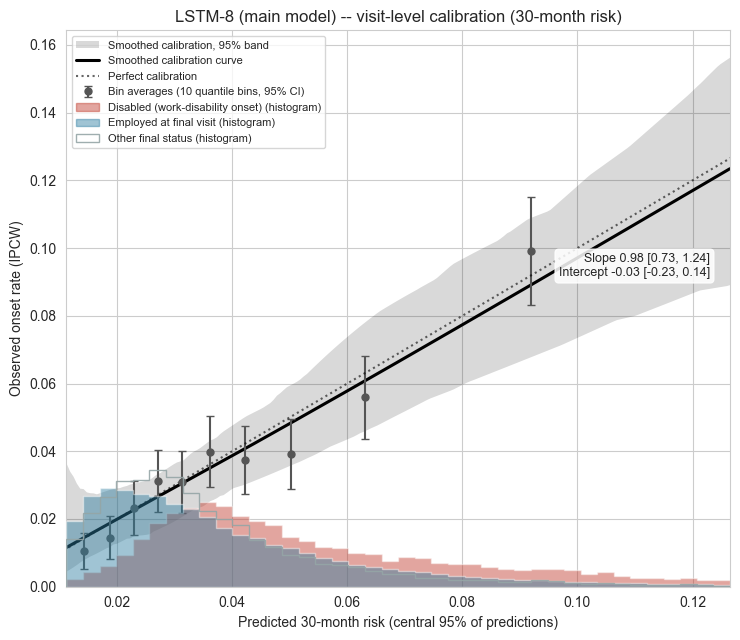


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Net benefit (R = 10),pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,
LSTM,5,-0.012 (0.001),0.583 (0.007),0.769 (0.003),0.693 (0.003),0.102 (0.004),39.287 (1.881),0.851 (0.041),0.112 (0.018),0.861 (0.047)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LSTM,5,0.171 (0.019),0.275 (0.023),0.367 (0.021),0.435 (0.017),0.541 (0.019),0.951 (0.002),0.901 (0.006),0.854 (0.006),0.806 (0.009),0.714 (0.012)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis R = 10):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LSTM,5,0.621 (0.022),0.622 (0.023),0.623 (0.023),0.629 (0.022),0.709 (0.016),0.608 (0.015),0.608 (0.016),0.607 (0.017),0.599 (0.021),0.474 (0.025),39.258 (1.826),39.287 (1.881),39.365 (1.950),40.205 (2.324),52.531 (2.658)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LSTM,5,0.713 (0.004),0.704 (0.003),0.688 (0.004),0.685 (0.003),0.685 (0.003),0.685 (0.003),0.683 (0.003),0.677 (0.004)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {'w8': 25}
Early stopping, outer-fold fits: median 21 epochs (range 13-44)


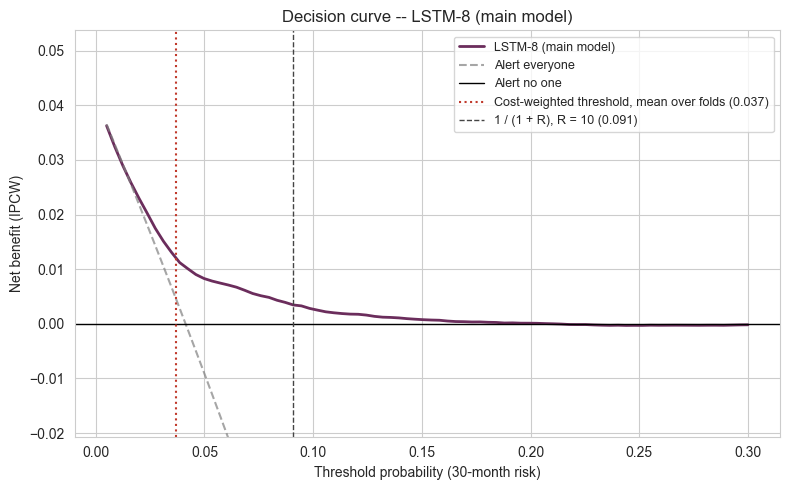

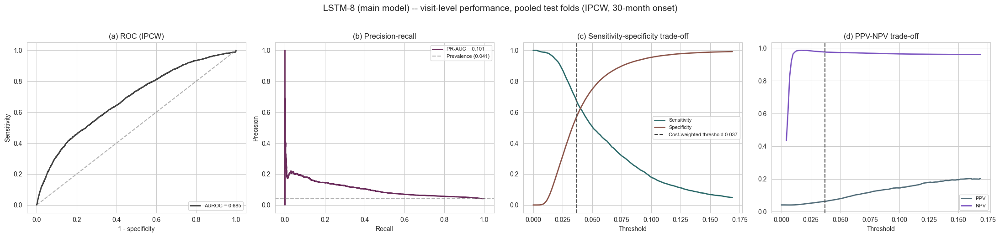

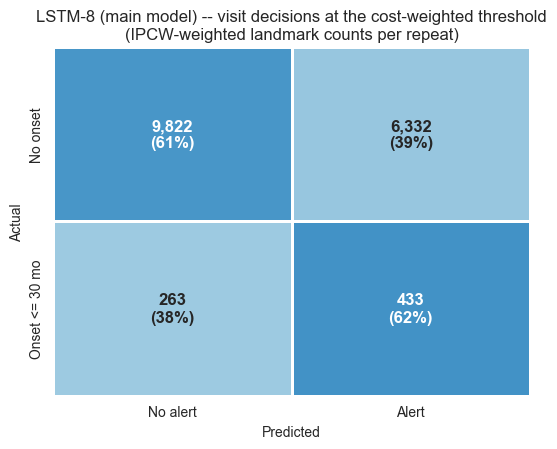

LSTM: final refit on all rows (config w8, 11 features) in 104s


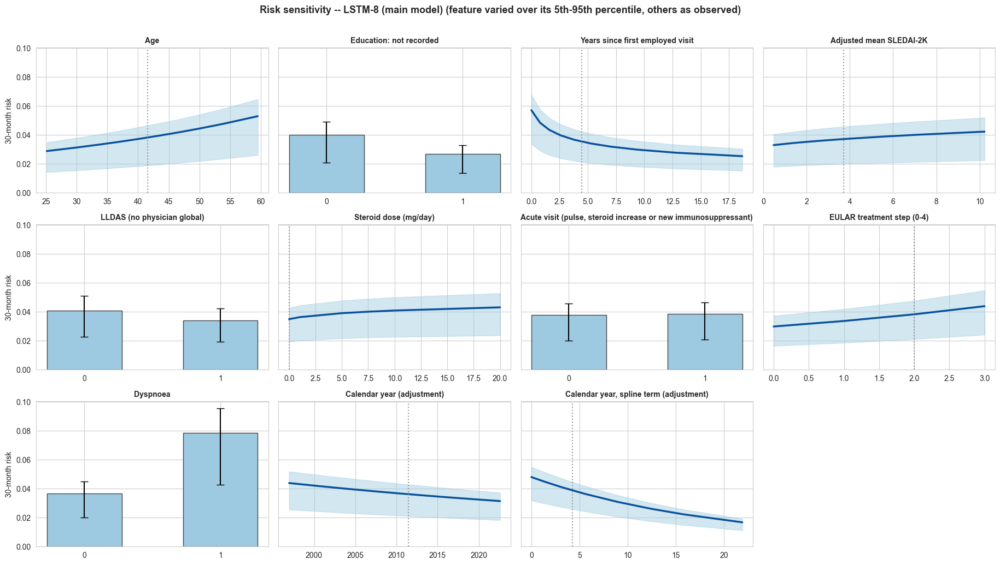


Risk-sensitivity summary -- LSTM-8 (main model) (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0366       0.0785                0.0419
                              Years since first employed visit      0.0572       0.0254                0.0318
                       Calendar year, spline term (adjustment)      0.0481       0.0168                0.0313
                                                           Age      0.0289       0.0530                0.0241
                                    EULAR treatment step (0-4)      0.0299       0.0439                0.0140
                                       Education: not recorded      0.0401       0.0268                0.0133
                                    Calendar year (adjustment)      0.0439       0.0315                0.0125
                                 

In [32]:
"""The main model (Section 6.1 / 11.7): LSTM-8 -- an LSTM over each landmark's last 8 visits, 16 units, a skip connection
from the current visit's variables to the hazard heads (warm-started from a logistic regression), four auxiliary
12-month heads (training only), next-visit pretraining, cause-specific hazard heads (+ calendar-year terms), early
stopping, 5-seed ensemble in the outer-fold fit."""
res_lstm = run_analysis("LSTM", "LSTM-8 (main model)")

## 11.9.1 LSTM-1 (reference: the main network on the current visit alone)

The same network as LSTM-8 -- skip connection, auxiliary heads, seeds, folds -- reading only the landmark visit. It is
the reference of H2 (Section 8.1).

Resuming from cv_state_model_revised_v16.pkl: 25 model-fold fits already done.
[LSTM1      ] repeat 1/5 fold 1/5 | AUROC 0.682 NB(R=10) -0.0144 | visit sens/spec 0.57/0.58 | patient sens/spec 0.83/0.41 (TN/FP 58/84) | cfg w1 | 11 feats | 106s
[LSTM1      ] repeat 1/5 fold 2/5 | AUROC 0.699 NB(R=10) -0.0133 | visit sens/spec 0.65/0.60 | patient sens/spec 0.74/0.49 (TN/FP 67/71) | cfg w1 | 11 feats | 106s
[LSTM1      ] repeat 1/5 fold 3/5 | AUROC 0.693 NB(R=10) -0.0052 | visit sens/spec 0.62/0.66 | patient sens/spec 0.75/0.56 (TN/FP 78/61) | cfg w1 | 11 feats | 105s
[LSTM1      ] repeat 1/5 fold 4/5 | AUROC 0.659 NB(R=10) -0.0106 | visit sens/spec 0.54/0.65 | patient sens/spec 0.73/0.56 (TN/FP 80/62) | cfg w1 | 11 feats | 109s
[LSTM1      ] repeat 1/5 fold 5/5 | AUROC 0.703 NB(R=10) -0.0167 | visit sens/spec 0.63/0.59 | patient sens/spec 0.78/0.44 (TN/FP 58/73) | cfg w1 | 11 feats | 117s
[LSTM1      ] repeat 2/5 fold 1/5 | AUROC 0.725 NB(R=10) -0.0049 | visit sens/spec 0.59/0.72 | patien

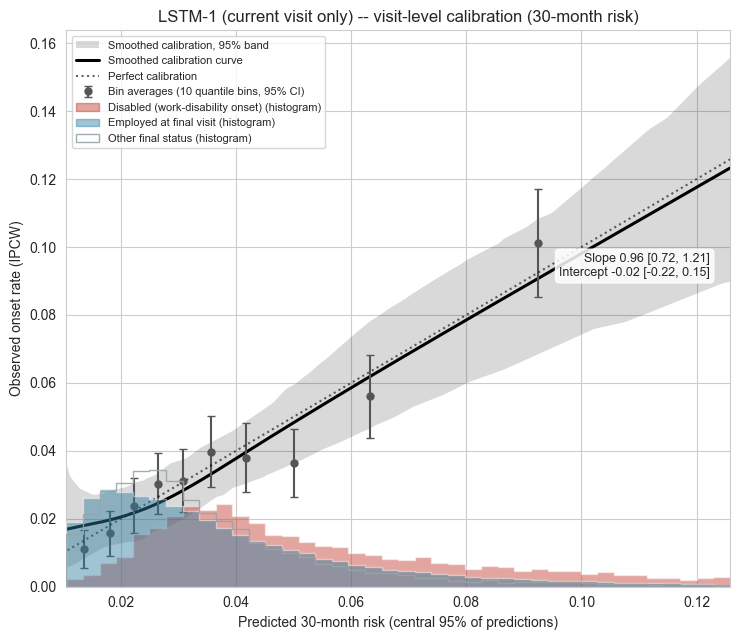


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Net benefit (R = 10),pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,
LSTM1,5,-0.011 (0.002),0.581 (0.004),0.767 (0.003),0.692 (0.003),0.101 (0.003),38.096 (1.385),0.825 (0.030),0.127 (0.017),0.841 (0.040)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LSTM1,5,0.172 (0.012),0.275 (0.017),0.362 (0.019),0.426 (0.015),0.533 (0.016),0.952 (0.002),0.902 (0.003),0.856 (0.004),0.812 (0.005),0.723 (0.007)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis R = 10):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LSTM1,5,0.612 (0.018),0.614 (0.018),0.614 (0.018),0.618 (0.019),0.693 (0.042),0.621 (0.015),0.620 (0.015),0.619 (0.015),0.615 (0.012),0.488 (0.061),38.024 (1.465),38.096 (1.385),38.194 (1.408),38.667 (1.176),51.139 (5.667)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LSTM1,5,0.709 (0.006),0.701 (0.004),0.686 (0.003),0.684 (0.003),0.684 (0.002),0.685 (0.002),0.682 (0.002),0.676 (0.002)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {'w1': 25}
Early stopping, outer-fold fits: median 24 epochs (range 16-57)


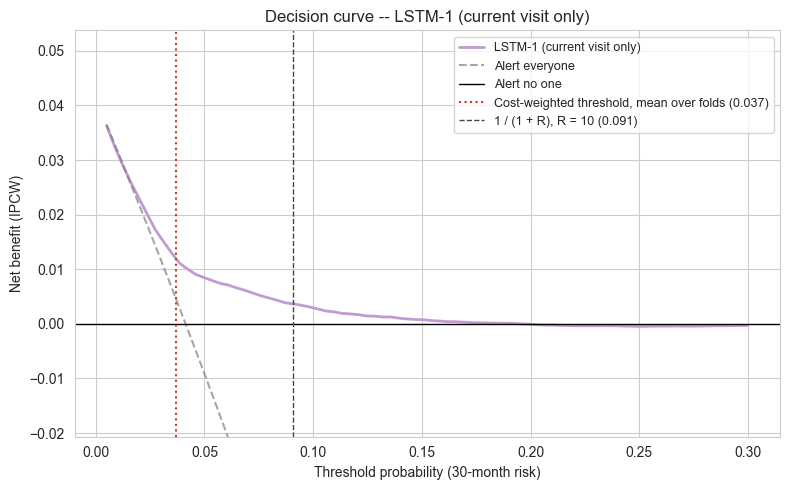

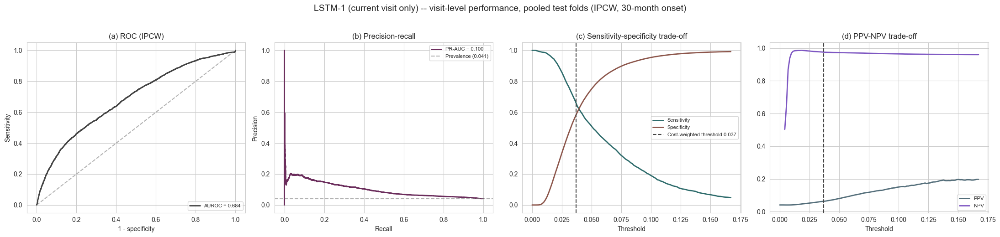

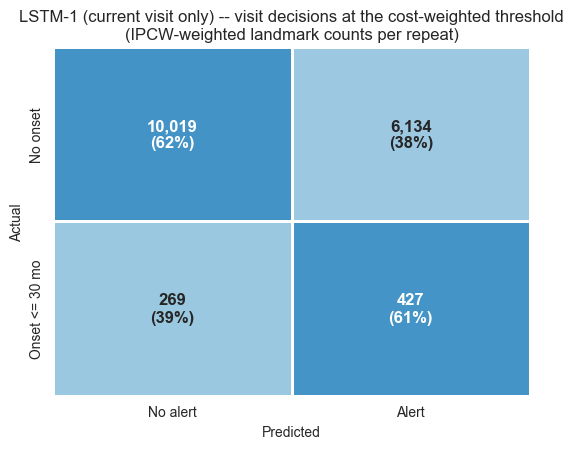

LSTM1: final refit on all rows (config w1, 11 features) in 85s


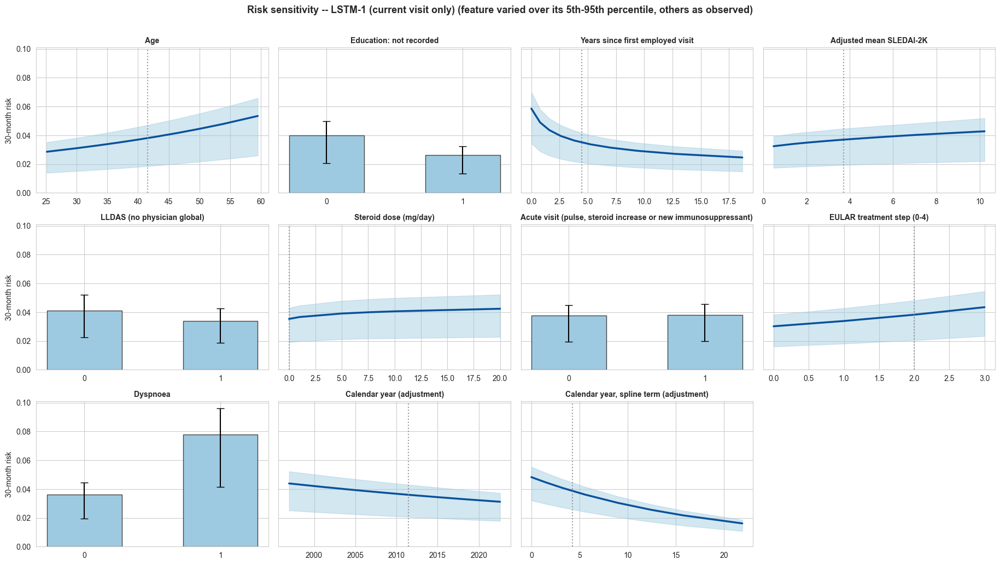


Risk-sensitivity summary -- LSTM-1 (current visit only) (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0363       0.0778                0.0415
                              Years since first employed visit      0.0586       0.0246                0.0340
                       Calendar year, spline term (adjustment)      0.0483       0.0161                0.0322
                                                           Age      0.0286       0.0534                0.0249
                                       Education: not recorded      0.0401       0.0261                0.0140
                                    EULAR treatment step (0-4)      0.0302       0.0435                0.0133
                                    Calendar year (adjustment)      0.0439       0.0312                0.0127
                         

In [33]:
"""LSTM-1: the main LSTM's recipe (Section 6.1) with a window of 1 visit (the current visit alone); the reference of
H2."""
res_lstm1 = run_analysis("LSTM1", "LSTM-1 (current visit only)")

## 11.9.2 What the history adds: LSTM-8 against LSTM-1, and the supplementary LSTM variants

LSTM-8 against LSTM-1 on identical folds (H2 of Section 8.1; the formal test with its hierarchy is in Section 11.15.1),
at every horizon from 6 to 48 months, with the supplementary variants (last 4 or 16 visits; no skip connection; no
auxiliary heads; one CV repeat each, paired with the first repeat of LSTM-1).

Resuming from cv_state_model_revised_v16.pkl: 50 model-fold fits already done.
[LSTM_w4    ] repeat 1/5 fold 1/5 | AUROC 0.687 NB(R=10) -0.0126 | visit sens/spec 0.57/0.60 | patient sens/spec 0.79/0.43 (TN/FP 61/81) | cfg w4 | 11 feats | 127s
[LSTM_w16   ] repeat 1/5 fold 1/5 | AUROC 0.685 NB(R=10) -0.0143 | visit sens/spec 0.60/0.57 | patient sens/spec 0.83/0.39 (TN/FP 56/86) | cfg w16 | 11 feats | 198s
[LSTM_noskip] repeat 1/5 fold 1/5 | AUROC 0.688 NB(R=10) -0.0232 | visit sens/spec 0.84/0.36 | patient sens/spec 0.93/0.25 (TN/FP 36/106) | cfg w8_noskip | 11 feats | 191s
[LSTM_noaux ] repeat 1/5 fold 1/5 | AUROC 0.690 NB(R=10) -0.0128 | visit sens/spec 0.54/0.61 | patient sens/spec 0.79/0.42 (TN/FP 60/82) | cfg w8_noaux | 11 feats | 126s
[LSTM_w4    ] repeat 1/5 fold 2/5 | AUROC 0.700 NB(R=10) -0.0133 | visit sens/spec 0.65/0.60 | patient sens/spec 0.78/0.47 (TN/FP 65/73) | cfg w4 | 11 feats | 125s
[LSTM_w16   ] repeat 1/5 fold 2/5 | AUROC 0.698 NB(R=10) -0.0128 | visit sens/spec 0.6

,CV repeats,AUROC 6 mo,AUROC 12 mo,AUROC 18 mo,AUROC 24 mo,AUROC 30 mo,AUROC 36 mo,AUROC 42 mo,AUROC 48 mo,Brier (30 mo),Visit sensitivity,Visit specificity,Alerts / 100 visits,Patient C-index,Patient sensitivity,Patient specificity
LSTM-8 (main),5,0.713,0.704,0.688,0.685,0.685,0.685,0.683,0.677,0.039,0.622,0.608,39.287,0.790,0.779,0.487
LSTM-1 (current visit),5,0.709,0.701,0.686,0.684,0.684,0.685,0.682,0.676,0.039,0.614,0.620,38.096,0.791,0.776,0.498
"LSTM, last 4 visits",1,0.710,0.704,0.688,0.686,0.686,0.687,0.685,0.680,0.039,0.603,0.606,39.541,0.792,0.766,0.483
"LSTM, last 16 visits",1,0.711,0.703,0.687,0.685,0.685,0.686,0.684,0.677,0.039,0.615,0.596,40.585,0.791,0.780,0.467
LSTM-8 without skip connection,1,0.703,0.701,0.689,0.686,0.688,0.689,0.687,0.682,0.039,0.704,0.522,48.632,0.791,0.816,0.421
LSTM-8 without auxiliary heads,1,0.712,0.703,0.687,0.685,0.685,0.686,0.683,0.678,0.039,0.571,0.658,34.407,0.793,0.745,0.527



Delta AUROC vs LSTM-1 (the same network on the current visit alone), by horizon (paired, same folds; 200 patient-bootstrap resamples):


Model,"LSTM, last 16 visits","LSTM, last 4 visits",LSTM-8 (main),LSTM-8 without auxiliary heads,LSTM-8 without skip connection
Horizon (mo),,,,,
6,0.005,0.004,0.004,0.006,-0.003
12,0.004,0.004,0.003,0.004,0.001
18,0.002,0.003,0.002,0.002,0.004
24,0.002,0.003,0.001,0.002,0.003
30,0.001,0.003,0.001,0.002,0.004
36,0.001,0.002,0.001,0.001,0.004
42,0.000,0.002,0.001,-0.000,0.003
48,-0.001,0.001,0.000,-0.001,0.004


,Paired repeats,Horizon (mo),Delta AUROC vs LSTM-1,95% CI,Share of resamples > 0
Model,,,,,
LSTM-8 (main),5,30,0.001,"[-0.002, +0.004]",0.735
"LSTM, last 4 visits",1,30,0.003,"[-0.001, +0.006]",0.935
"LSTM, last 16 visits",1,30,0.001,"[-0.002, +0.005]",0.775
LSTM-8 without skip connection,1,30,0.004,"[-0.014, +0.019]",0.685
LSTM-8 without auxiliary heads,1,30,0.002,"[-0.004, +0.007]",0.765


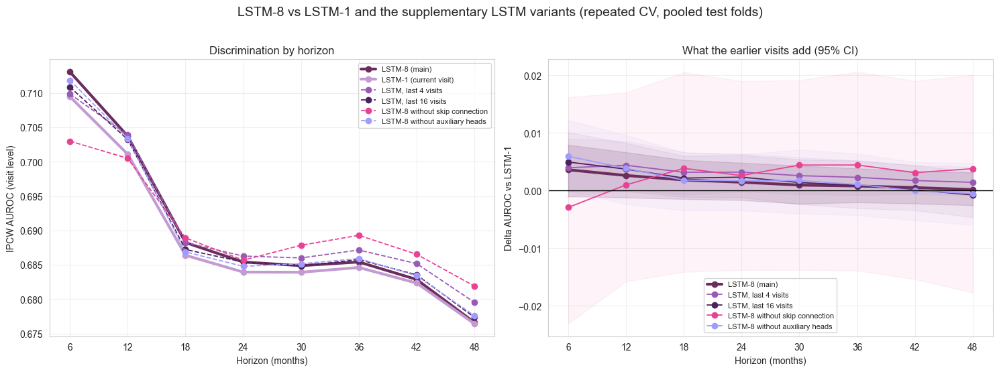

In [34]:
"""
What the history adds (Section 11.9.2): LSTM-8 and the supplementary LSTM variants against LSTM-1 (the same network on
the current visit alone), from the pooled test folds (no refitting for LSTM-8 / LSTM-1; the variants are fitted here,
MODEL_REPEATS repeat(s) each): visit AUROC at every horizon, 30-month Brier, sensitivity, specificity and alert rate,
30-month patient C-index, sensitivity and specificity, and Delta AUROC (model - LSTM-1) at every horizon with a
patient-cluster bootstrap CI (the same resamples in every repeat; pairs of repeats both models completed).
"""
cv_state = run_repeated_cv(models=SUPP_LSTM_MODELS)       # the supplementary variants (checkpointed, resumable)
H_ = len(EVAL_HORIZONS_MONTHS)
N_BOOT_WIN = 100 if SMOKE else 200
HISTORY_REF = "LSTM1"
HISTORY_MODELS = ["LSTM", "LSTM1"] + SUPP_LSTM_MODELS


def auc_prep(y, p):
    """Sort once; auc_w then gives the weighted AUROC for any weights (ties count 1/2; rows with weight 0 drop out)."""
    o = np.argsort(p, kind="mergesort")
    _, start = np.unique(p[o], return_index=True)
    return o, start, np.asarray(y)[o] == 1


def auc_w(prep, w):
    o, start, pos = prep
    ws = np.asarray(w, float)[o]
    wp, wn = np.add.reduceat(ws * pos, start), np.add.reduceat(ws * ~pos, start)
    den = wp.sum() * wn.sum()
    return float((wp * (np.cumsum(wn) - 0.5 * wn)).sum() / den) if den > 0 else np.nan


def patient_boot_counts(n_boot, seed=2026):
    """Patient-cluster bootstrap as multiplicities: (per landmark, per patient code) for each resample."""
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n_boot):
        cnt = np.bincount(rng.integers(0, len(PT_CODE), len(PT_CODE)), minlength=len(PT_CODE)).astype(float)
        out.append((cnt[LAND_CODE], cnt))
    return out


def model_repeats(m):
    """Pooled test folds of every completed repeat of model m: [(P (N, H), 30-month threshold (N,), thresholds per
    horizon (N, H)), ...] in repeat order."""
    out = []
    for r in range(CV_N_REPEATS):
        if sum(1 for (mm, rr, _) in cv_state["folds"] if mm == m and rr == r) < CV_N_SPLITS:
            continue
        pr = pooled_repeat(cv_state, m, r)
        out.append((pr["P"], pr["visit_thr"]["target"], pr["visit_thr_h"]))
    return out


def selected_repeats():
    """The main LSTM (LSTM-8) in the same format (Section 11.9.3)."""
    return model_repeats("LSTM")


def window_metrics(reps):
    """Mean over repeats of the test-fold metrics of one model."""
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    k = w > 0
    rows = []
    for P, thr, _ in reps:
        p = P[:, PRIMARY_COL]
        a = p >= thr
        tp, fp, fn, tn = w_confusion(y[k], a[k], w[k])
        f = patient_frame(ALL_ROWS, p, thr)
        pc = patient_counts(f)
        rows.append({**{f"AUROC {h} mo": w_auroc(IPCW[h][0], P[:, j], IPCW[h][1])
                        for j, h in enumerate(EVAL_HORIZONS_MONTHS)},
                     "Brier (30 mo)": float(np.average((p[k] - y[k]) ** 2, weights=w[k])),
                     "Visit sensitivity": tp / max(tp + fn, 1e-12), "Visit specificity": tn / max(tn + fp, 1e-12),
                     "Alerts / 100 visits": 100.0 * float(np.mean(a)),
                     "Patient C-index": w_auroc(f["y"].values, f["score"].values, np.ones(len(f))),
                     "Patient sensitivity": pc["TP"] / max(pc["TP"] + pc["FN"], 1),
                     "Patient specificity": pc["TN"] / max(pc["TN"] + pc["FP"], 1)})
    return pd.DataFrame(rows).mean()


def delta_auc_by_horizon(reps_a, reps_b, boots):
    """Delta AUROC (a - b) at every horizon, mean over paired repeats, with the bootstrap distribution."""
    n = min(len(reps_a), len(reps_b))
    d0, B = np.zeros(H_), np.zeros((len(boots), H_))
    for j, h in enumerate(EVAL_HORIZONS_MONTHS):
        y, w = IPCW[h]
        preps = [(auc_prep(y, A[0][:, j]), auc_prep(y, Bm[0][:, j])) for A, Bm in zip(reps_a[:n], reps_b[:n])]
        d0[j] = np.mean([auc_w(pa, w) - auc_w(pb, w) for pa, pb in preps])
        for i, (m_land, _) in enumerate(boots):
            ww = w * m_land
            B[i, j] = np.mean([auc_w(pa, ww) - auc_w(pb, ww) for pa, pb in preps])
    return d0, B


HIST_REPS = {m: model_repeats(m) for m in HISTORY_MODELS}
HIST_HAVE = [m for m in HISTORY_MODELS if HIST_REPS[m]]
if HISTORY_REF not in HIST_HAVE or "LSTM" not in HIST_HAVE:
    print("Run Sections 11.9 and 11.9.1 first.")
else:
    lab = lambda m: MODEL_LABELS.get(m, m)
    hist_table = pd.DataFrame({lab(m): window_metrics(HIST_REPS[m]) for m in HIST_HAVE}).T
    hist_table.insert(0, "CV repeats", [len(HIST_REPS[m]) for m in HIST_HAVE])
    print("LSTM-8, LSTM-1 and the supplementary LSTM variants -- pooled test folds, mean over the completed repeats:")
    display(hist_table.round(3))
    boots = patient_boot_counts(N_BOOT_WIN)
    DELTA_HIST, drows = {}, []
    for m in [x for x in HIST_HAVE if x != HISTORY_REF]:
        d0, B = delta_auc_by_horizon(HIST_REPS[m], HIST_REPS[HISTORY_REF], boots)
        lo, hi = np.nanpercentile(B, [2.5, 97.5], axis=0)
        DELTA_HIST[lab(m)] = (d0, lo, hi)
        for j, h in enumerate(EVAL_HORIZONS_MONTHS):
            drows.append({"Model": lab(m), "Paired repeats": min(len(HIST_REPS[m]), len(HIST_REPS[HISTORY_REF])),
                          "Horizon (mo)": h, "Delta AUROC vs LSTM-1": d0[j], "95% CI": f"[{lo[j]:+.3f}, {hi[j]:+.3f}]",
                          "Share of resamples > 0": float(np.mean(B[:, j] > 0))})
    delta_hist = pd.DataFrame(drows)
    print(f"\nDelta AUROC vs LSTM-1 (the same network on the current visit alone), by horizon (paired, same folds; "
          f"{N_BOOT_WIN} patient-bootstrap resamples):")
    display(delta_hist.pivot(index="Horizon (mo)", columns="Model", values="Delta AUROC vs LSTM-1").round(3))
    display(delta_hist[delta_hist["Horizon (mo)"] == PRIMARY_HORIZON_MONTHS].set_index("Model").round(3))
    hist_table.to_csv("lstm_history_comparison_revised_v16.csv")
    delta_hist.to_csv("lstm_history_delta_auroc_revised_v16.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))
    ax = axes[0]
    for m in HIST_HAVE:
        row = hist_table.loc[lab(m), [f"AUROC {h} mo" for h in EVAL_HORIZONS_MONTHS]]
        ax.plot(EVAL_HORIZONS_MONTHS, row.values, marker="o", color=CV_COLORS.get(m, "#444444"),
                lw=3 if m in ("LSTM", "LSTM1") else 1.3, ls="-" if m in ("LSTM", "LSTM1") else "--", label=lab(m))
    ax.set_xticks(EVAL_HORIZONS_MONTHS); ax.set_xlabel("Horizon (months)"); ax.set_ylabel("IPCW AUROC (visit level)")
    ax.set_title("Discrimination by horizon"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax = axes[1]
    for m in [x for x in HIST_HAVE if x != HISTORY_REF]:
        d0, lo, hi = DELTA_HIST[lab(m)]
        c_ = CV_COLORS.get(m, "#444444")
        ax.plot(EVAL_HORIZONS_MONTHS, d0, marker="o", color=c_, lw=3 if m == "LSTM" else 1.3, label=lab(m))
        ax.fill_between(EVAL_HORIZONS_MONTHS, lo, hi, color=c_, alpha=0.15 if m == "LSTM" else 0.06)
    ax.axhline(0, color="k", lw=1); ax.set_xticks(EVAL_HORIZONS_MONTHS); ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("Delta AUROC vs LSTM-1"); ax.set_title("What the earlier visits add (95% CI)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle("LSTM-8 vs LSTM-1 and the supplementary LSTM variants (repeated CV, pooled test folds)", y=1.02,
                 fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_lstm_history.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

## 11.9.3 LSTM-8 from 6 to 48 months: visit and patient level

Each horizon with its own calibrated risk and era-standardised alarm threshold, from the pooled test folds.


LSTM-8 -- VISIT LEVEL by horizon: value [95% patient-bootstrap CI], mean over 5 repeat(s)


,Onset rate (IPCW),AUROC,Brier,calibration slope,calibration intercept,sensitivity,specificity,PPV,NPV,alerts / 100 visits
Horizon (mo),,,,,,,,,,
6,0.008,"0.713 [0.668, 0.759]","0.008 [0.006, 0.009]","1.034 [0.820, 1.244]","-0.034 [-0.215, 0.145]","0.661 [0.575, 0.738]","0.623 [0.602, 0.643]","0.014 [0.011, 0.017]","0.996 [0.994, 0.997]","37.892 [35.909, 39.992]"
12,0.018,"0.704 [0.654, 0.754]","0.017 [0.015, 0.020]","0.982 [0.768, 1.191]","-0.018 [-0.173, 0.158]","0.639 [0.564, 0.725]","0.640 [0.619, 0.661]","0.031 [0.025, 0.037]","0.990 [0.986, 0.993]","36.471 [34.325, 38.547]"
18,0.026,"0.688 [0.644, 0.733]","0.025 [0.022, 0.030]","0.975 [0.748, 1.204]","-0.025 [-0.199, 0.144]","0.622 [0.550, 0.697]","0.616 [0.593, 0.640]","0.042 [0.034, 0.050]","0.984 [0.978, 0.988]","39.003 [36.728, 41.240]"
24,0.034,"0.685 [0.634, 0.735]","0.032 [0.028, 0.038]","0.982 [0.714, 1.201]","-0.029 [-0.197, 0.133]","0.621 [0.547, 0.694]","0.607 [0.584, 0.633]","0.053 [0.043, 0.063]","0.978 [0.971, 0.983]","40.107 [37.806, 42.455]"
30,0.041,"0.685 [0.630, 0.738]","0.039 [0.033, 0.045]","0.978 [0.690, 1.211]","-0.030 [-0.209, 0.137]","0.622 [0.546, 0.702]","0.608 [0.585, 0.635]","0.064 [0.053, 0.076]","0.974 [0.965, 0.980]","40.148 [37.693, 42.467]"
36,0.047,"0.685 [0.633, 0.735]","0.044 [0.038, 0.052]","0.990 [0.718, 1.226]","-0.034 [-0.217, 0.138]","0.627 [0.552, 0.704]","0.602 [0.577, 0.632]","0.073 [0.060, 0.086]","0.970 [0.960, 0.977]","40.889 [38.332, 43.417]"
42,0.054,"0.683 [0.632, 0.732]","0.050 [0.042, 0.059]","1.003 [0.714, 1.259]","-0.041 [-0.231, 0.137]","0.627 [0.551, 0.701]","0.589 [0.564, 0.619]","0.080 [0.066, 0.096]","0.965 [0.953, 0.974]","42.302 [39.397, 44.888]"
48,0.060,"0.677 [0.624, 0.728]","0.055 [0.047, 0.066]","0.997 [0.685, 1.279]","-0.040 [-0.240, 0.157]","0.622 [0.543, 0.698]","0.584 [0.558, 0.616]","0.088 [0.072, 0.106]","0.960 [0.946, 0.970]","42.854 [40.016, 45.567]"



LSTM-8 -- PATIENT LEVEL by horizon: value [95% patient-bootstrap CI], mean over 5 repeat(s)


,Evaluable (events / event-free),C-index,sensitivity,specificity,PPV,NPV,balanced accuracy
Horizon (mo),,,,,,,
6,110 / 847,"0.834 [0.799, 0.870]","0.669 [0.593, 0.751]","0.681 [0.655, 0.711]","0.216 [0.180, 0.253]","0.941 [0.924, 0.958]","0.675 [0.636, 0.717]"
12,132 / 806,"0.817 [0.780, 0.850]","0.673 [0.601, 0.747]","0.656 [0.629, 0.688]","0.244 [0.209, 0.285]","0.924 [0.899, 0.943]","0.664 [0.624, 0.700]"
18,137 / 769,"0.808 [0.772, 0.843]","0.715 [0.642, 0.782]","0.588 [0.561, 0.621]","0.237 [0.208, 0.279]","0.921 [0.893, 0.941]","0.652 [0.614, 0.687]"
24,138 / 724,"0.796 [0.754, 0.834]","0.745 [0.680, 0.806]","0.527 [0.498, 0.559]","0.231 [0.199, 0.267]","0.916 [0.887, 0.937]","0.636 [0.600, 0.669]"
30,141 / 692,"0.790 [0.746, 0.825]","0.779 [0.708, 0.833]","0.487 [0.456, 0.516]","0.236 [0.205, 0.273]","0.915 [0.884, 0.940]","0.633 [0.599, 0.668]"
36,143 / 668,"0.786 [0.743, 0.824]","0.783 [0.720, 0.840]","0.449 [0.417, 0.481]","0.233 [0.201, 0.270]","0.906 [0.871, 0.932]","0.616 [0.579, 0.647]"
42,144 / 641,"0.782 [0.737, 0.820]","0.796 [0.726, 0.853]","0.407 [0.377, 0.443]","0.232 [0.200, 0.269]","0.899 [0.857, 0.927]","0.602 [0.563, 0.636]"
48,145 / 609,"0.772 [0.723, 0.815]","0.803 [0.736, 0.859]","0.386 [0.351, 0.422]","0.237 [0.206, 0.274]","0.892 [0.847, 0.923]","0.594 [0.558, 0.629]"


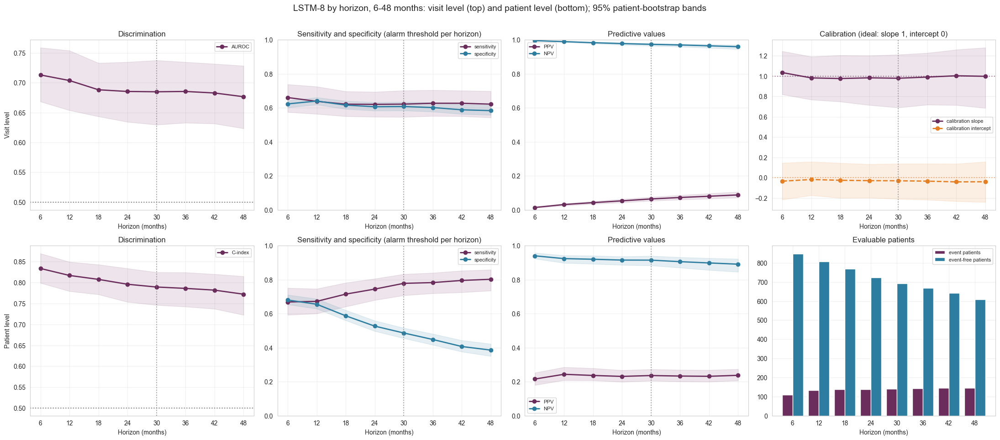

In [35]:
"""
LSTM-8 at every horizon (Section 11.9.2): visit- and patient-level metrics with each horizon's own
calibrated risk and era-standardised alarm threshold (visit_thr_h), from the pooled test folds; plots by horizon.
"""
HZ_BOOT = 100 if SMOKE else 200


def horizon_patient_window(hd):
    """Landmarks that decide a patient's outcome at horizon hd (days): Section 9.2 with hd in place of 30 months."""
    ev = land["event"].values == 1
    win_event = ev & (T_ALL <= hd)
    win_retired = (_stratum == STRATA[1]) & (_days_to_exit > 0) & (_days_to_exit <= hd)
    neg_other = np.isin(_stratum, [STRATA[0], STRATA[2]]) & (T_ALL > hd) & ~ev
    last = pd.Series(np.where(neg_other, _vdate.values, np.datetime64("NaT")), dtype="datetime64[ns]") \
        .groupby(PID_ALL).transform("max").values
    win_obs = neg_other & ((last - _vdate.values) / np.timedelta64(1, "D") <= hd)
    return np.where(_stratum == "Event", win_event, win_retired | win_obs)


PT_WIN_H = {h: horizon_patient_window(hd) for h, hd in zip(EVAL_HORIZONS_MONTHS, HORIZON_DAYS_GRID)}
assert np.array_equal(PT_WIN_H[PRIMARY_HORIZON_MONTHS], LAND_PT_WIN), "30-month windows must match Section 11.6"
PT_IS_EVENT = (PT_TRUTH["stratum"] == "Event").values.astype(int)


def horizon_pieces(P, thr_h, j):
    """Visit and patient arrays of one repeat at horizon column j (fixed across bootstrap resamples)."""
    h = EVAL_HORIZONS_MONTHS[j]
    y, w = IPCW[h]
    p = P[:, j]
    a = p >= thr_h[:, j]
    k = PT_WIN_H[h]
    d = pd.DataFrame({"code": LAND_CODE[k], "s": p[k], "a": a[k]}).groupby("code").agg(s=("s", "max"), a=("a", "max"))
    code_pt = d.index.values
    y_pt = PT_IS_EVENT[code_pt]
    return dict(y=y, w=w, p=p, a=a, prep=auc_prep(y, p), code_pt=code_pt, y_pt=y_pt, a_pt=d["a"].values.astype(bool),
                prep_pt=auc_prep(y_pt, d["s"].values))


def horizon_metrics(pc, m_land=None, m_pt=None):
    div = lambda a_, b_: a_ / b_ if b_ > 0 else np.nan
    w = pc["w"] if m_land is None else pc["w"] * m_land
    k = w > 0
    y, p, a = pc["y"][k], pc["p"][k], pc["a"][k]
    tp, fp, fn, tn = w_confusion(y, a, w[k])
    slope, icpt = fast_calibration(y, p, w[k])
    wp = np.ones(len(pc["y_pt"])) if m_pt is None else m_pt[pc["code_pt"]]
    yp, ap = pc["y_pt"], pc["a_pt"]
    TP, FP = wp[(yp == 1) & ap].sum(), wp[(yp == 0) & ap].sum()
    FN, TN = wp[(yp == 1) & ~ap].sum(), wp[(yp == 0) & ~ap].sum()
    return {"visit: AUROC": auc_w(pc["prep"], w), "visit: Brier": float(np.average((p - y) ** 2, weights=w[k])),
            "visit: calibration slope": slope, "visit: calibration intercept": icpt,
            "visit: sensitivity": div(tp, tp + fn), "visit: specificity": div(tn, tn + fp),
            "visit: PPV": div(tp, tp + fp), "visit: NPV": div(tn, tn + fn),
            "visit: alerts / 100 visits": 100.0 * div((a * w[k]).sum(), w[k].sum()),
            "patient: C-index": auc_w(pc["prep_pt"], wp), "patient: sensitivity": div(TP, TP + FN),
            "patient: specificity": div(TN, TN + FP), "patient: PPV": div(TP, TP + FP), "patient: NPV": div(TN, TN + FN),
            "patient: balanced accuracy": (div(TP, TP + FN) + div(TN, TN + FP)) / 2}


HZ_REPS = selected_repeats() if res_lstm is not None else []
if not HZ_REPS:
    print("Run Section 11.9 first.")
else:
    boots_h = patient_boot_counts(HZ_BOOT, seed=2027)
    rows, HZ_CI = [], {}
    for j, h in enumerate(EVAL_HORIZONS_MONTHS):
        pcs = [horizon_pieces(P, thr_h, j) for P, _, thr_h in HZ_REPS]
        est = pd.DataFrame([horizon_metrics(pc) for pc in pcs]).mean()
        B = pd.DataFrame([pd.DataFrame([horizon_metrics(pc, ml, mp) for pc in pcs]).mean() for ml, mp in boots_h])
        lo, hi = B.quantile(0.025), B.quantile(0.975)
        n_ev, n_neg = int((pcs[0]["y_pt"] == 1).sum()), int((pcs[0]["y_pt"] == 0).sum())
        yh, wh = IPCW[h]
        rows.append({"Horizon (mo)": h, "Onset rate (IPCW)": float(np.average(yh[wh > 0], weights=wh[wh > 0])),
                     "Event patients": n_ev, "Event-free patients": n_neg,
                     **{c: est[c] for c in est.index}, **{f"{c} lo": lo[c] for c in est.index},
                     **{f"{c} hi": hi[c] for c in est.index}})
    hz_df = pd.DataFrame(rows).set_index("Horizon (mo)")
    hz_df.to_csv("lstm_by_horizon_revised_v16.csv")
    mets = [c for c in est.index]
    fmt = lambda c: hz_df.apply(lambda r: f"{r[c]:.3f} [{r[c + ' lo']:.3f}, {r[c + ' hi']:.3f}]"
                                if np.isfinite(r[c]) else "n/a", axis=1)
    for level in ("visit", "patient"):
        t = pd.DataFrame({c.split(": ", 1)[1]: fmt(c) for c in mets if c.startswith(level)})
        if level == "visit":
            t.insert(0, "Onset rate (IPCW)", hz_df["Onset rate (IPCW)"].round(3))
        else:
            t.insert(0, "Evaluable (events / event-free)",
                     hz_df["Event patients"].astype(str) + " / " + hz_df["Event-free patients"].astype(str))
        print(f"\nLSTM-8 -- {level.upper()} LEVEL by horizon: value [95% patient-bootstrap CI], mean over "
              f"{len(HZ_REPS)} repeat(s)")
        display(t)

    def band(ax, c, color, label, ls="-"):
        ax.plot(EVAL_HORIZONS_MONTHS, hz_df[c], marker="o", color=color, ls=ls, lw=2, label=label)
        ax.fill_between(EVAL_HORIZONS_MONTHS, hz_df[c + " lo"], hz_df[c + " hi"], color=color, alpha=0.12)

    C1, C2, C3 = CV_COLORS["LSTM"], "#2c7da0", "#e67e22"
    fig, axes = plt.subplots(2, 4, figsize=(22, 9.5))
    for r_, level, disc in [(0, "visit", "visit: AUROC"), (1, "patient", "patient: C-index")]:
        ax = axes[r_, 0]
        band(ax, disc, C1, disc.split(": ")[1]); ax.axhline(0.5, color="gray", ls=":")
        ax.set_ylabel(f"{level.capitalize()} level"); ax.set_title("Discrimination")
        ax = axes[r_, 1]
        band(ax, f"{level}: sensitivity", C1, "sensitivity"); band(ax, f"{level}: specificity", C2, "specificity")
        ax.set_ylim(0, 1); ax.set_title("Sensitivity and specificity (alarm threshold per horizon)")
        ax = axes[r_, 2]
        band(ax, f"{level}: PPV", C1, "PPV"); band(ax, f"{level}: NPV", C2, "NPV")
        ax.set_ylim(0, 1); ax.set_title("Predictive values")
    ax = axes[0, 3]
    band(ax, "visit: calibration slope", C1, "calibration slope"); band(ax, "visit: calibration intercept", C3,
                                                                          "calibration intercept", ls="--")
    ax.axhline(1, color=C1, ls=":", alpha=0.6); ax.axhline(0, color=C3, ls=":", alpha=0.6)
    ax.set_title("Calibration (ideal: slope 1, intercept 0)")
    ax = axes[1, 3]
    x = np.arange(len(EVAL_HORIZONS_MONTHS))
    ax.bar(x - 0.2, hz_df["Event patients"], 0.4, color=C1, label="event patients")
    ax.bar(x + 0.2, hz_df["Event-free patients"], 0.4, color=C2, label="event-free patients")
    ax.set_xticks(x); ax.set_xticklabels(EVAL_HORIZONS_MONTHS); ax.set_title("Evaluable patients")
    for ax in axes.ravel()[:-1]:
        ax.set_xticks(EVAL_HORIZONS_MONTHS); ax.axvline(PRIMARY_HORIZON_MONTHS, color="gray", ls=":", alpha=0.7)
    for ax in axes.ravel():
        ax.set_xlabel("Horizon (months)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle("LSTM-8 by horizon, 6-48 months: visit level (top) and patient level (bottom); "
                 "95% patient-bootstrap bands", y=1.01, fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_lstm_by_horizon.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

## 11.10 Discrete-time competing-risk logistic regression

Resuming from cv_state_model_revised_v16.pkl: 70 model-fold fits already done.
[LogReg     ] repeat 1/5 fold 1/5 | AUROC 0.671 NB(R=10) -0.0128 | visit sens/spec 0.59/0.58 | patient sens/spec 0.83/0.42 (TN/FP 59/83) | cfg 0.3 | 11 feats | 69s
[LogReg     ] repeat 1/5 fold 2/5 | AUROC 0.683 NB(R=10) -0.0167 | visit sens/spec 0.63/0.57 | patient sens/spec 0.74/0.42 (TN/FP 58/80) | cfg 0.003 | 11 feats | 60s
[LogReg     ] repeat 1/5 fold 3/5 | AUROC 0.699 NB(R=10) -0.0078 | visit sens/spec 0.66/0.62 | patient sens/spec 0.79/0.46 (TN/FP 64/75) | cfg 0.001 | 11 feats | 43s
[LogReg     ] repeat 1/5 fold 4/5 | AUROC 0.651 NB(R=10) -0.0104 | visit sens/spec 0.50/0.67 | patient sens/spec 0.70/0.56 (TN/FP 79/63) | cfg 0.001 | 11 feats | 71s
[LogReg     ] repeat 1/5 fold 5/5 | AUROC 0.706 NB(R=10) -0.0134 | visit sens/spec 0.63/0.63 | patient sens/spec 0.78/0.50 (TN/FP 65/66) | cfg 0.003 | 11 feats | 1005s
[LogReg     ] repeat 2/5 fold 1/5 | AUROC 0.726 NB(R=10) -0.0103 | visit sens/spec 0.62/0.6

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


[LogReg     ] repeat 5/5 fold 2/5 | AUROC 0.658 NB(R=10) -0.0144 | visit sens/spec 0.56/0.59 | patient sens/spec 0.76/0.41 (TN/FP 55/79) | cfg 0.001 | 11 feats | 71s
[LogReg     ] repeat 5/5 fold 3/5 | AUROC 0.749 NB(R=10) -0.0088 | visit sens/spec 0.76/0.57 | patient sens/spec 0.89/0.45 (TN/FP 64/77) | cfg 0.001 | 11 feats | 71s
[LogReg     ] repeat 5/5 fold 4/5 | AUROC 0.687 NB(R=10) -0.0059 | visit sens/spec 0.63/0.65 | patient sens/spec 0.77/0.46 (TN/FP 61/73) | cfg 0.3 | 11 feats | 79s
[LogReg     ] repeat 5/5 fold 5/5 | AUROC 0.659 NB(R=10) -0.0139 | visit sens/spec 0.56/0.64 | patient sens/spec 0.67/0.49 (TN/FP 69/72) | cfg 0.01 | 11 feats | 67s
CV for ['LogReg']: 64.6 min this call; 95 model-fold fits in cv_state_model_revised_v16.pkl.
LogReg (discrete-time, competing risks) -- VISIT LEVEL (30-month work-disability onset)
  16,851 landmark visits of 1,059 patients; resolved at 30 months: 14,384 (642 with an onset within 30 months); IPCW-weighted
  alarm = calibrated 30-month ri

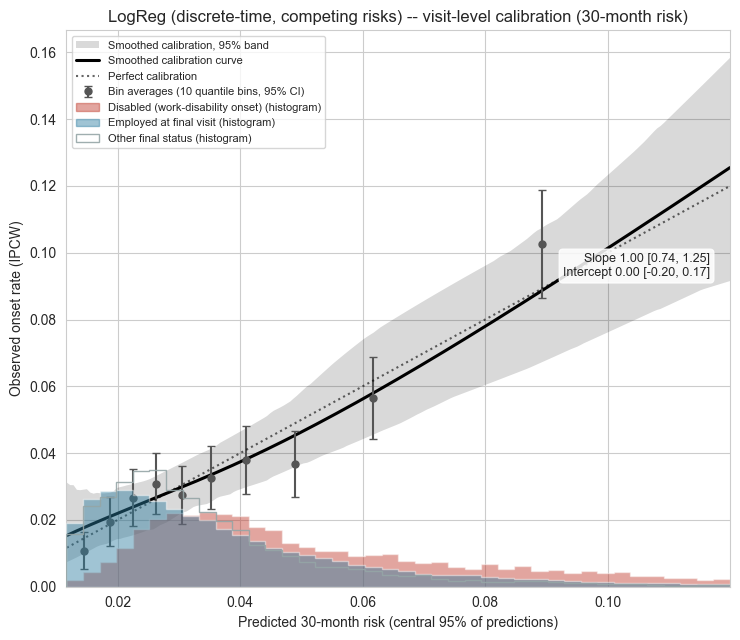


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Net benefit (R = 10),pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,
LogReg,5,-0.012 (0.000),0.570 (0.005),0.769 (0.003),0.688 (0.002),0.102 (0.002),39.202 (0.707),0.849 (0.015),0.105 (0.007),0.874 (0.029)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LogReg,5,0.156 (0.004),0.265 (0.006),0.359 (0.009),0.432 (0.012),0.534 (0.011),0.953 (0.002),0.902 (0.002),0.853 (0.003),0.806 (0.005),0.712 (0.002)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis R = 10):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LogReg,5,0.613 (0.015),0.613 (0.015),0.613 (0.015),0.617 (0.017),0.645 (0.021),0.612 (0.005),0.612 (0.006),0.610 (0.005),0.608 (0.007),0.548 (0.038),39.194 (0.706),39.202 (0.707),39.326 (0.707),39.594 (0.871),45.444 (3.750)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LogReg,5,0.714 (0.005),0.704 (0.004),0.687 (0.004),0.682 (0.003),0.680 (0.002),0.677 (0.001),0.671 (0.001),0.665 (0.001)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {0.001: 12, 0.003: 8, 0.3: 3, 0.01: 2}


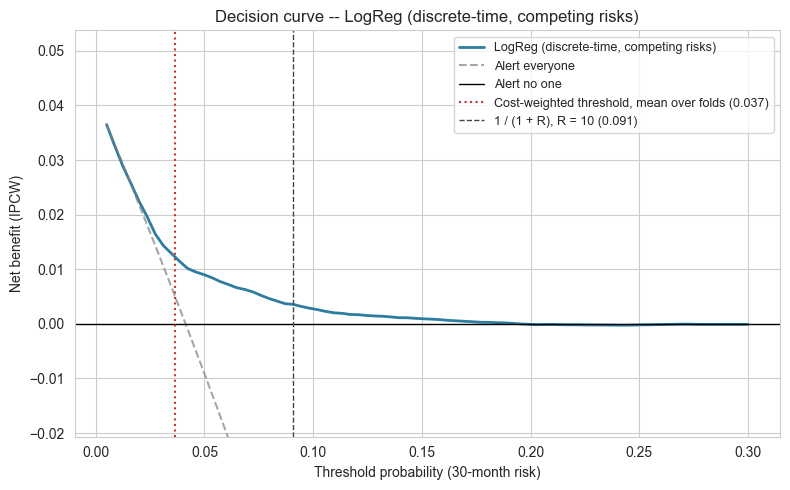

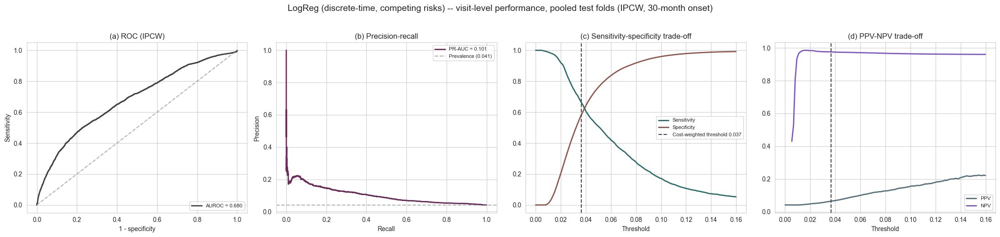

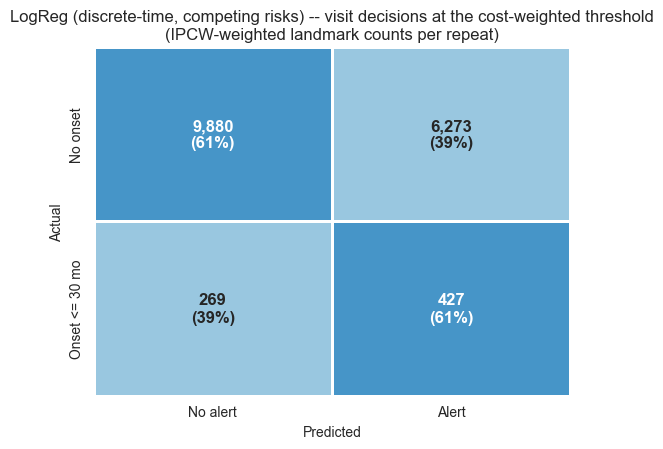

LogReg: final refit on all rows (config 0.001, 11 features) in 10s


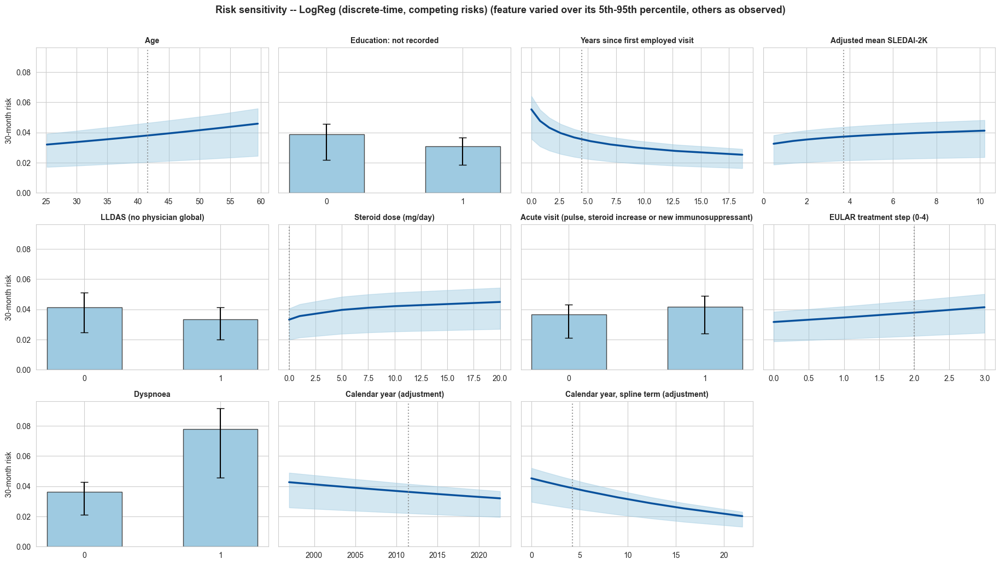


Risk-sensitivity summary -- LogReg (discrete-time, competing risks) (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0362       0.0777                0.0416
                              Years since first employed visit      0.0553       0.0252                0.0300
                       Calendar year, spline term (adjustment)      0.0452       0.0202                0.0250
                                                           Age      0.0320       0.0458                0.0138
                                         Steroid dose (mg/day)      0.0332       0.0449                0.0117
                                    Calendar year (adjustment)      0.0426       0.0320                0.0107
                                    EULAR treatment step (0-4)      0.0316       0.0414                0.0097
             

In [36]:
"""discrete-time competing-risk (pooled multinomial) logistic regression: cumulative incidence of work
disability with other exits and death competing. The fold's LASSO-selected variables (linear), the calendar-year terms; L2 penalty C tuned
inside each training fold on the cross-fitted cost-weighted net benefit."""
res_logreg = run_analysis("LogReg", "LogReg (discrete-time, competing risks)")

## 11.10.1 Nomogram

The readable form of the regression (Chen et al.'s nomogram model; Section 6.2): the variables selected on all data,
refitted without a penalty as an IPCW logistic regression of onset within 30 months, pooled over the imputations, with
the intercept temporally recalibrated to the last 8 calendar years.

Nomogram model: 11 terms (Age, Education: not recorded, Years since first employed visit, Adjusted mean SLEDAI-2K, LLDAS (no physician global), Steroid dose (mg/day), Acute visit (pulse, steroid increase or new immunosuppressant), EULAR treatment step (0-4), Dyspnoea, Calendar year (adjustment), Calendar year, spline term (adjustment)); 14,384 resolved landmarks, 5 imputations pooled. Temporal recalibration on the landmarks from 2016: intercept shift -0.191 (mean predicted risk there 0.057 -> observed 0.048).


,log-odds per SD,"SE (Rubin, cluster-robust)",OR per SD,OR 95% CI low,OR 95% CI high,p
(Intercept),-2.8525,0.1309,0.0577,0.0446,0.0746,0.0000
Age,0.3043,0.1093,1.3557,1.0943,1.6797,0.0054
Education: not recorded,-0.3447,0.1018,0.7085,0.5803,0.8649,0.0007
Years since first employed visit,-0.5496,0.1139,0.5772,0.4616,0.7216,0.0000
Adjusted mean SLEDAI-2K,0.1114,0.1007,1.1179,0.9177,1.3618,0.2684
LLDAS (no physician global),-0.1833,0.0932,0.8325,0.6935,0.9994,0.0493
Steroid dose (mg/day),0.1832,0.1182,1.2011,0.9526,1.5144,0.1212
"Acute visit (pulse, steroid increase or new immunosuppressant)",0.0558,0.0611,1.0574,0.9380,1.1919,0.3613
EULAR treatment step (0-4),0.1444,0.1266,1.1553,0.9013,1.4808,0.2544
Dyspnoea,0.2578,0.0583,1.2941,1.1544,1.4508,0.0000


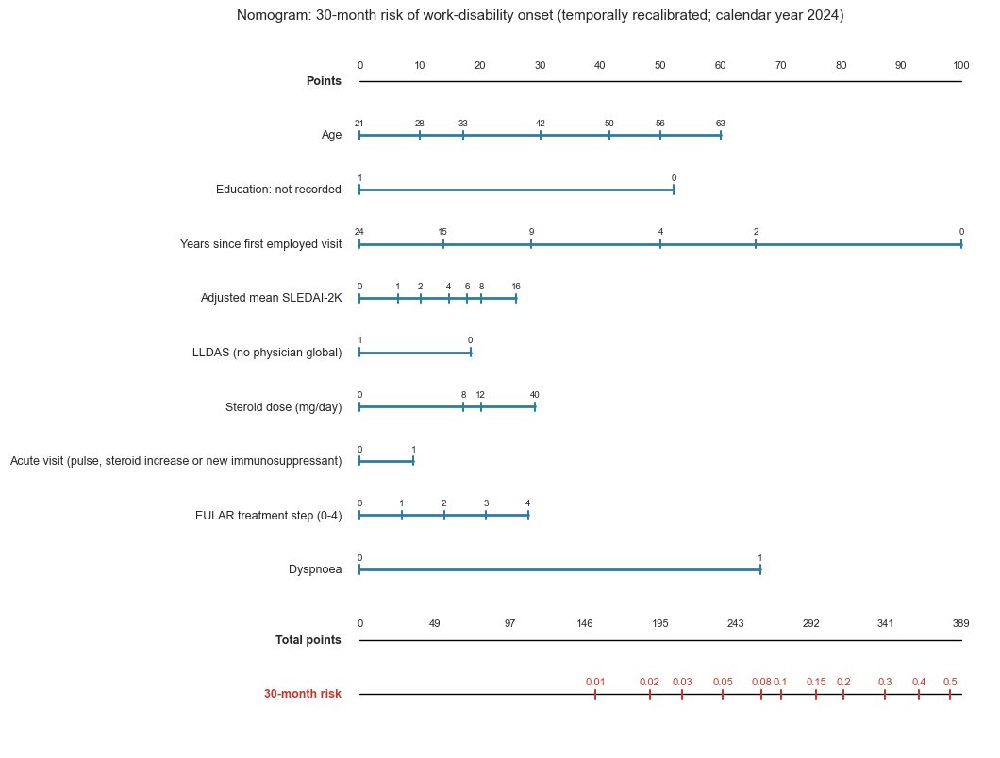

In [37]:
"""
The nomogram model (Section 6.2; Chen et al.'s logistic-regression nomogram): the 30-month risk of work-disability
onset as an IPCW logistic regression of 'onset within 30 months' (the competing-risk label of the LASSO) on the
variables the LASSO selected on all landmarks (SELECTION_ALL), refitted WITHOUT a penalty on each of the
M_IMPUTATIONS completed datasets and pooled with Rubin's rules (patient-clustered robust SEs). For the published model
the intercept is TEMPORALLY RECALIBRATED (Booth et al., Int J Epidemiol 2020): re-estimated on the landmarks of the last
TEMPORAL_RECAL_YEARS calendar years, with the calendar year held at the latest year in the data. Its cross-validated
performance is that of the LASSO-selected LogReg (Section 11.10), which is the same variables in a competing-risk
discrete-time form; the nomogram is the readable, by-hand version.
"""
import statsmodels.api as sm

NOMO_COLS = list(SELECTION_ALL["features"])
_rows = np.arange(len(land))
_prep_nomo = TabularPrep(NOMO_COLS)
_Xs_nomo = _prep_nomo.fit_transform(X_for(_rows, NOMO_COLS), PID_ALL[_rows])
_y_n, _w_n = IPCW[PRIMARY_HORIZON_MONTHS]
_w_n = _w_n * land["weight"].values
_k_n = _w_n > 0
_grp_n = pd.factorize(PID_ALL[_k_n])[0]
_fits = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for X in _Xs_nomo:
        _fits.append(sm.GLM(_y_n[_k_n], sm.add_constant(X[_k_n]), family=sm.families.Binomial(),
                            var_weights=_w_n[_k_n] / _w_n[_k_n].mean()).fit(cov_type="cluster",
                                                                             cov_kwds={"groups": _grp_n}))
_Q = np.array([f.params for f in _fits])
_U = np.array([np.diag(f.cov_params()) for f in _fits])
_m = len(_fits)
NOMO_BETA = _Q.mean(0)
_T = _U.mean(0) + (1 + 1 / _m) * _Q.var(0, ddof=1)
_se = np.sqrt(_T)
_names = ["(Intercept)"] + [DISPLAY_NAMES.get(c, c) for c in NOMO_COLS]
nomo_table = pd.DataFrame({"log-odds per SD": NOMO_BETA, "SE (Rubin, cluster-robust)": _se,
                           "OR per SD": np.exp(NOMO_BETA), "OR 95% CI low": np.exp(NOMO_BETA - 1.96 * _se),
                           "OR 95% CI high": np.exp(NOMO_BETA + 1.96 * _se),
                           "p": 2 * stats.norm.sf(np.abs(NOMO_BETA / _se))}, index=_names)
# temporal recalibration of the intercept, with the calendar year at the latest year
_lp_all = np.mean([sm.add_constant(X) @ NOMO_BETA for X in _Xs_nomo], axis=0)
_recent = (CAL_YEAR_ALL >= CAL_YEAR_ALL.max() - TEMPORAL_RECAL_YEARS) & _k_n
NOMO_SHIFT = brentq(lambda a: np.average(_expit(a + _lp_all[_recent]), weights=_w_n[_recent])
                    - np.average(_y_n[_recent], weights=_w_n[_recent]), -10, 10)
_year_terms = {c: _prep_nomo.transform_value(NOMO_COLS.index(c), float(land[c].max())) for c in ADJUST_COLS
               if c in NOMO_COLS}
NOMO_CONST = NOMO_BETA[0] + NOMO_SHIFT + sum(NOMO_BETA[1 + NOMO_COLS.index(c)] * z for c, z in _year_terms.items())
print(f"Nomogram model: {len(NOMO_COLS)} terms ({', '.join(_names[1:])}); {int(_k_n.sum()):,} resolved landmarks, "
      f"{_m} imputations pooled. Temporal recalibration on the landmarks from {CAL_YEAR_ALL.max() - TEMPORAL_RECAL_YEARS:.0f}: "
      f"intercept shift {NOMO_SHIFT:+.3f} (mean predicted risk there {np.average(_expit(_lp_all[_recent]), weights=_w_n[_recent]):.3f} "
      f"-> observed {np.average(_y_n[_recent], weights=_w_n[_recent]):.3f}).")
display(nomo_table.round(4))
nomo_table.to_csv("nomogram_model_coefficients_revised_v16.csv")


def draw_nomogram(save=None):
    """Points per variable (0 at the value with the lowest risk contribution; 100 = the widest range among the
    variables, 1st-99th percentile of the landmarks), total points, and the temporally recalibrated 30-month risk."""
    rows_ = []
    for j, c in enumerate(NOMO_COLS):
        if c in ADJUST_COLS:
            continue
        x = land[c].dropna().values.astype(float)
        binary = set(np.unique(x)) <= {0.0, 1.0}
        nd = 0 if np.ptp(np.percentile(x, [1, 99])) >= 10 else (1 if np.ptp(np.percentile(x, [1, 99])) >= 1 else 2)
        vals = np.array([0.0, 1.0]) if binary else np.unique(np.round(np.percentile(x, [1, 10, 25, 50, 75, 90, 99]), nd))
        contrib = np.array([NOMO_BETA[1 + j] * _prep_nomo.transform_value(j, v) for v in vals])
        rows_.append((c, vals, contrib))
    span = max(np.ptp(cb) for _, _, cb in rows_) or 1.0
    scale = 100.0 / span
    fig, ax = plt.subplots(figsize=(11, 0.55 * (len(rows_) + 4) + 1))
    y = len(rows_) + 2
    ax.plot([0, 100], [y, y], color="black", lw=1)
    for p_ in range(0, 101, 10):
        ax.text(p_, y + 0.25, f"{p_}", ha="center", fontsize=8)
    ax.text(-3, y, "Points", ha="right", va="center", fontsize=9, fontweight="bold")
    base = 0.0
    for c, vals, cb in rows_:
        y -= 1
        pts = (cb - cb.min()) * scale
        base += cb.min()
        ax.plot([pts.min(), pts.max()], [y, y], color="#2c7da0", lw=2)
        for v, p_ in zip(vals, pts):
            ax.plot([p_, p_], [y - 0.08, y + 0.08], color="#2c7da0")
            ax.text(p_, y + 0.18, f"{v:g}", ha="center", fontsize=7)
        ax.text(-3, y, DISPLAY_NAMES.get(c, c), ha="right", va="center", fontsize=9)
    max_total = sum(np.ptp(cb) for _, _, cb in rows_) * scale
    y -= 1.3
    tot_ticks = np.linspace(0, max_total, 9)
    ax.plot([0, 100], [y, y], color="black", lw=1)
    for t in tot_ticks:
        ax.text(t / max_total * 100, y + 0.25, f"{t:.0f}", ha="center", fontsize=8)
    ax.text(-3, y, "Total points", ha="right", va="center", fontsize=9, fontweight="bold")
    y -= 1.0
    ax.plot([0, 100], [y, y], color="black", lw=1)
    lp_of_points = lambda tp: NOMO_CONST + base + tp / scale
    for r_ in [0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]:
        tp = (_logit(r_) - NOMO_CONST - base) * scale
        if 0 <= tp <= max_total:
            ax.plot([tp / max_total * 100] * 2, [y - 0.08, y + 0.08], color="#c0392b")
            ax.text(tp / max_total * 100, y + 0.18, f"{r_:g}", ha="center", fontsize=8, color="#c0392b")
    ax.text(-3, y, "30-month risk", ha="right", va="center", fontsize=9, fontweight="bold", color="#c0392b")
    ax.set_xlim(-45, 105); ax.set_ylim(y - 1, len(rows_) + 3); ax.axis("off")
    ax.set_title(f"Nomogram: 30-month risk of work-disability onset (temporally recalibrated; calendar year "
                 f"{CAL_YEAR_ALL.max():.0f})", fontsize=11)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    return lp_of_points


nomogram_lp = draw_nomogram(save=f"{OUT_DIR}/revised_v16_nomogram.png")

## 11.11 Random survival forest

Resuming from cv_state_model_revised_v16.pkl: 95 model-fold fits already done.
[RSF        ] repeat 1/5 fold 1/5 | AUROC 0.671 NB(R=10) -0.0123 | visit sens/spec 0.63/0.57 | patient sens/spec 0.90/0.38 (TN/FP 54/88) | cfg None | 11 feats | 28s
[RSF        ] repeat 1/5 fold 2/5 | AUROC 0.730 NB(R=10) -0.0165 | visit sens/spec 0.64/0.57 | patient sens/spec 0.81/0.49 (TN/FP 68/70) | cfg None | 11 feats | 24s
[RSF        ] repeat 1/5 fold 3/5 | AUROC 0.693 NB(R=10) -0.0110 | visit sens/spec 0.57/0.62 | patient sens/spec 0.79/0.43 (TN/FP 60/79) | cfg None | 11 feats | 15s
[RSF        ] repeat 1/5 fold 4/5 | AUROC 0.649 NB(R=10) -0.0120 | visit sens/spec 0.51/0.65 | patient sens/spec 0.80/0.49 (TN/FP 70/72) | cfg None | 11 feats | 26s
[RSF        ] repeat 1/5 fold 5/5 | AUROC 0.689 NB(R=10) -0.0183 | visit sens/spec 0.66/0.57 | patient sens/spec 0.85/0.38 (TN/FP 50/81) | cfg None | 11 feats | 29s
[RSF        ] repeat 2/5 fold 1/5 | AUROC 0.702 NB(R=10) -0.0088 | visit sens/spec 0.58/0.68 | p

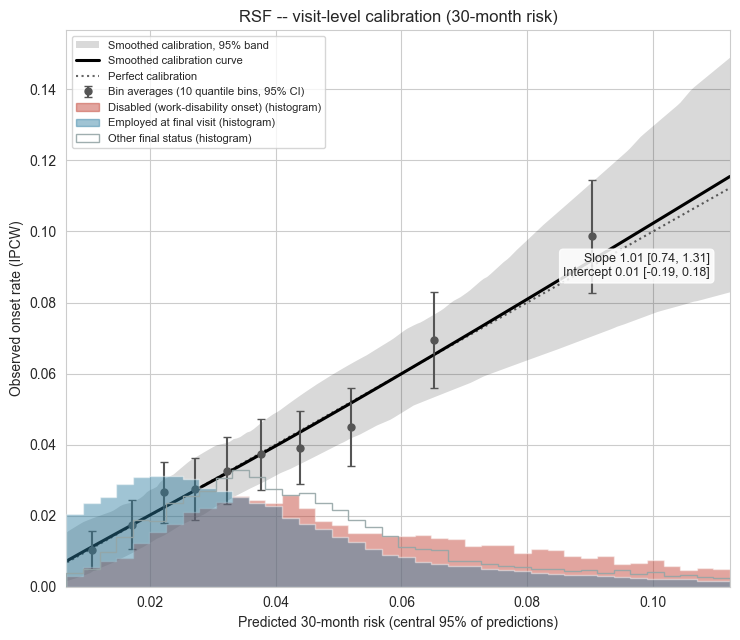


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Net benefit (R = 10),pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,
RSF,5,-0.012 (0.001),0.592 (0.001),0.755 (0.002),0.688 (0.003),0.084 (0.002),42.697 (1.196),0.925 (0.026),0.087 (0.008),0.887 (0.025)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
RSF,5,0.108 (0.010),0.201 (0.009),0.273 (0.015),0.339 (0.012),0.452 (0.012),0.956 (0.002),0.916 (0.005),0.874 (0.007),0.833 (0.009),0.743 (0.007)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis R = 10):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
RSF,5,0.603 (0.013),0.604 (0.014),0.616 (0.019),0.640 (0.029),0.818 (0.028),0.612 (0.010),0.610 (0.011),0.599 (0.019),0.577 (0.026),0.383 (0.021),42.541 (1.059),42.697 (1.196),43.830 (1.944),46.015 (2.522),65.017 (2.094)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
RSF,5,0.706 (0.007),0.701 (0.003),0.689 (0.003),0.683 (0.003),0.684 (0.003),0.683 (0.004),0.678 (0.004),0.672 (0.004)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {}


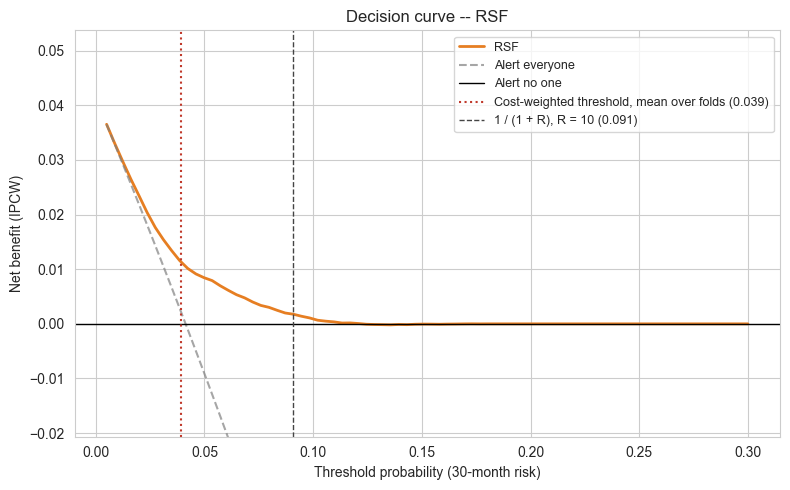

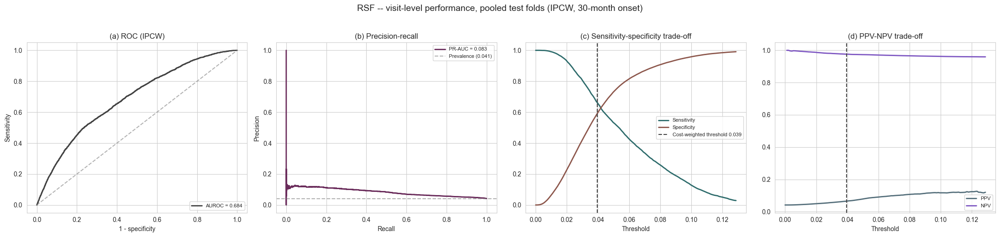

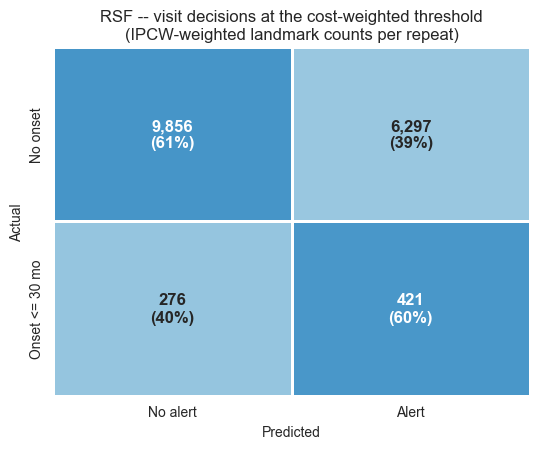

RSF: final refit on all rows (config None, 11 features) in 10s


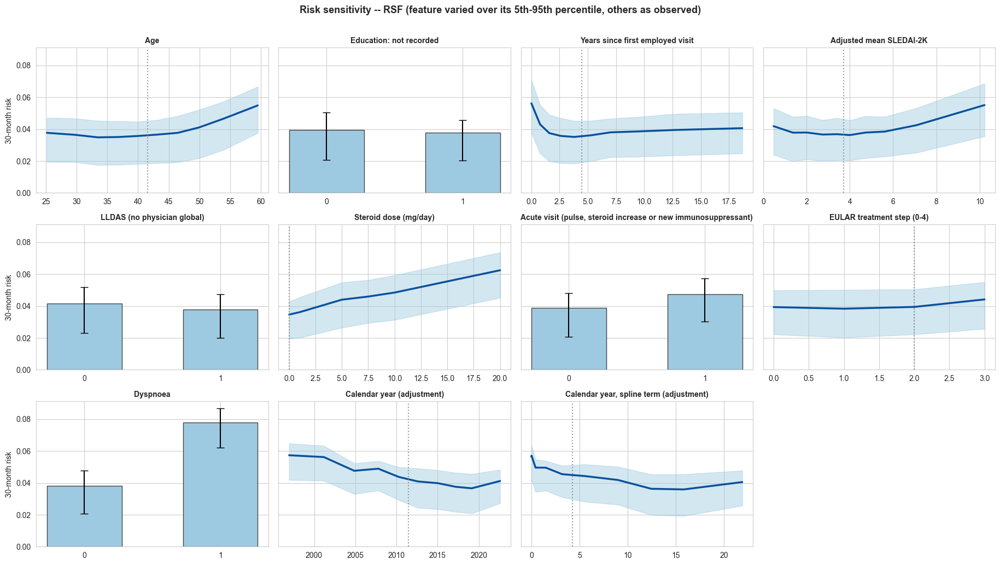


Risk-sensitivity summary -- RSF (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0381       0.0780                0.0398
                                         Steroid dose (mg/day)      0.0346       0.0624                0.0278
                       Calendar year, spline term (adjustment)      0.0564       0.0405                0.0212
                              Years since first employed visit      0.0562       0.0406                0.0211
                                    Calendar year (adjustment)      0.0573       0.0412                0.0207
                                                           Age      0.0377       0.0549                0.0200
                                       Adjusted mean SLEDAI-2K      0.0419       0.0551                0.0188
Acute visit (pulse, steroid increase or new immun

In [38]:
"""random survival forest on the cause-specific (other exits and deaths censored), 48-month-capped
target (monthly time bins, patient-weighted subsampling). One fixed configuration."""
res_rsf = run_analysis("RSF", "RSF")

## 11.12 Cause-specific Cox proportional hazards

Resuming from cv_state_model_revised_v16.pkl: 120 model-fold fits already done.
[CoxPH      ] repeat 1/5 fold 1/5 | AUROC 0.686 NB(R=10) -0.0138 | visit sens/spec 0.64/0.55 | patient sens/spec 0.79/0.37 (TN/FP 52/90) | cfg 0.1 | 11 feats | 41s
[CoxPH      ] repeat 1/5 fold 2/5 | AUROC 0.652 NB(R=10) -0.0200 | visit sens/spec 0.56/0.56 | patient sens/spec 0.67/0.41 (TN/FP 56/82) | cfg 1.0 | 11 feats | 34s
[CoxPH      ] repeat 1/5 fold 3/5 | AUROC 0.704 NB(R=10) -0.0075 | visit sens/spec 0.66/0.62 | patient sens/spec 0.75/0.48 (TN/FP 67/72) | cfg 1.0 | 11 feats | 23s
[CoxPH      ] repeat 1/5 fold 4/5 | AUROC 0.659 NB(R=10) -0.0125 | visit sens/spec 0.50/0.65 | patient sens/spec 0.70/0.46 (TN/FP 65/77) | cfg 0.1 | 11 feats | 37s
[CoxPH      ] repeat 1/5 fold 5/5 | AUROC 0.697 NB(R=10) -0.0128 | visit sens/spec 0.62/0.64 | patient sens/spec 0.78/0.45 (TN/FP 59/72) | cfg 0.1 | 11 feats | 42s
[CoxPH      ] repeat 2/5 fold 1/5 | AUROC 0.707 NB(R=10) -0.0118 | visit sens/spec 0.62/0.63 | patie

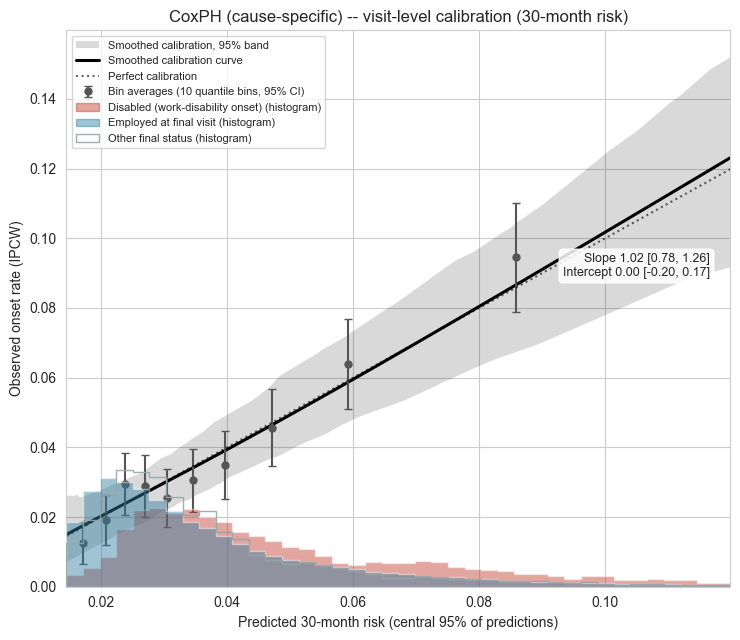


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Net benefit (R = 10),pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,
CoxPH,5,-0.013 (0.000),0.567 (0.002),0.761 (0.003),0.685 (0.002),0.098 (0.001),40.470 (0.239),0.876 (0.005),0.167 (0.008),0.880 (0.009)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
CoxPH,5,0.144 (0.007),0.241 (0.009),0.339 (0.006),0.398 (0.009),0.521 (0.009),0.956 (0.001),0.907 (0.002),0.859 (0.003),0.808 (0.005),0.707 (0.004)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis R = 10):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
CoxPH,5,0.599 (0.004),0.599 (0.004),0.599 (0.003),0.602 (0.002),0.670 (0.039),0.604 (0.002),0.603 (0.002),0.601 (0.003),0.597 (0.007),0.474 (0.061),40.423 (0.266),40.470 (0.239),40.668 (0.296),41.143 (0.650),53.257 (6.192)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
CoxPH,5,0.711 (0.005),0.702 (0.004),0.684 (0.003),0.678 (0.002),0.678 (0.002),0.674 (0.001),0.668 (0.001),0.662 (0.001)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {1.0: 15, 0.1: 9, 10.0: 1}


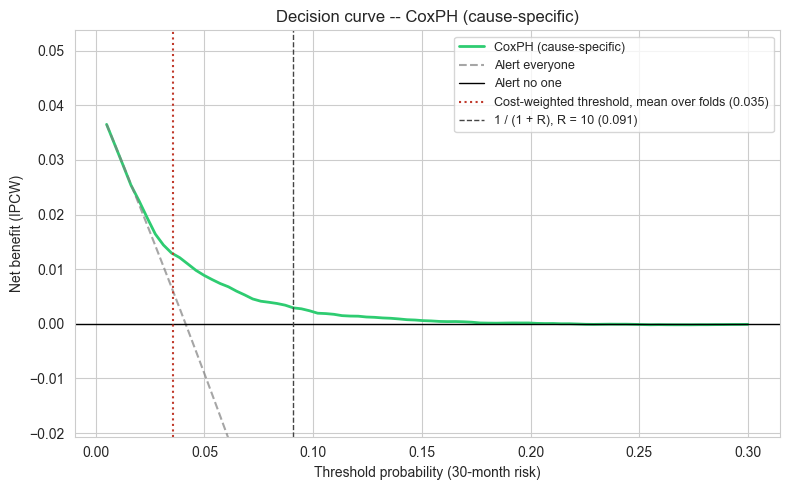

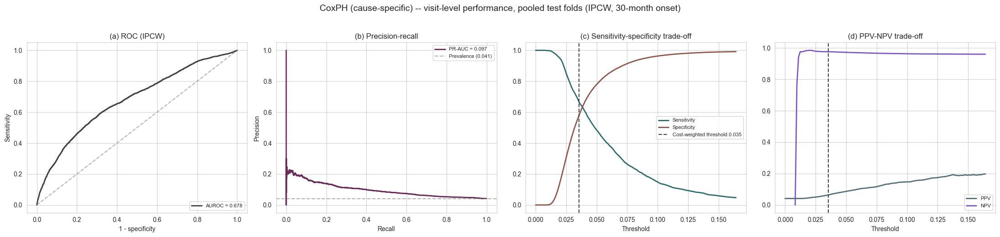

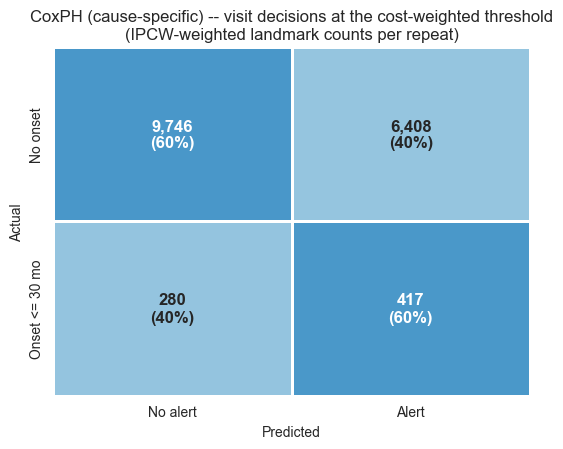

CoxPH: final refit on all rows (config 1.0, 11 features) in 28s


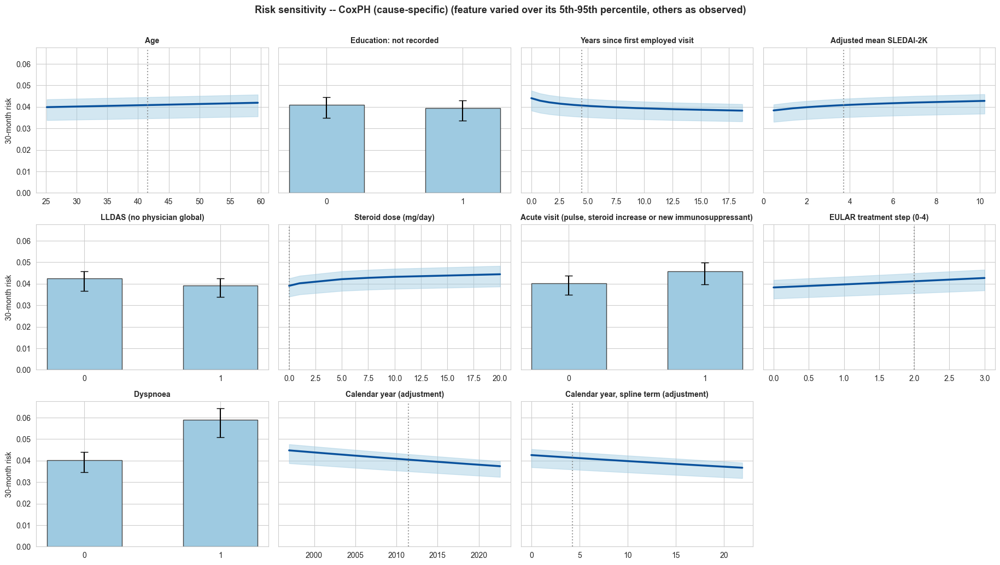


Risk-sensitivity summary -- CoxPH (cause-specific) (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0403       0.0590                0.0187
                                    Calendar year (adjustment)      0.0448       0.0374                0.0074
                       Calendar year, spline term (adjustment)      0.0426       0.0367                0.0059
                              Years since first employed visit      0.0440       0.0383                0.0058
Acute visit (pulse, steroid increase or new immunosuppressant)      0.0402       0.0458                0.0056
                                         Steroid dose (mg/day)      0.0391       0.0444                0.0054
                                       Adjusted mean SLEDAI-2K      0.0384       0.0428                0.0044
                              

,coef,exp(coef),se (pooled),p
"Calendar year, spline term (adjustment)",-0.046,0.955,0.006,0.000
LLDAS (no physician global),-0.036,0.964,0.006,0.000
Calendar year (adjustment),-0.051,0.950,0.008,0.000
Steroid dose (mg/day),0.046,1.047,0.008,0.000
Years since first employed visit,-0.039,0.962,0.007,0.000
"Acute visit (pulse, steroid increase or new immunosuppressant)",0.038,1.039,0.008,0.000
EULAR treatment step (0-4),0.035,1.035,0.008,0.000
Dyspnoea,0.069,1.071,0.017,0.000
Adjusted mean SLEDAI-2K,0.031,1.031,0.010,0.002
Age,0.014,1.015,0.009,0.093


In [39]:
"""cause-specific Cox proportional hazards (other exits and deaths censored), follow-up capped at 48 months;
ridge penalizer tuned inside each training fold."""
res_cox = run_analysis("CoxPH", "CoxPH (cause-specific)")
if res_cox is not None:
    print("\nCox hazard ratios, final refit on all rows, pooled over the imputations with Rubin's rules "
          "(standardised features; for description only):")
    display(pooled_cox_summary(res_cox["final"]["fitted"])
            .rename(index=lambda c: DISPLAY_NAMES.get(c, c)).sort_values("p").round(3))

## 11.13 GRU

Resuming from cv_state_model_revised_v16.pkl: 145 model-fold fits already done.
[GRU        ] repeat 1/5 fold 1/5 | AUROC 0.697 NB(R=10) -0.0185 | visit sens/spec 0.76/0.44 | patient sens/spec 0.86/0.30 (TN/FP 42/100) | cfg h32_pretrain | 11 feats | 85s
[GRU        ] repeat 1/5 fold 2/5 | AUROC 0.709 NB(R=10) -0.0152 | visit sens/spec 0.66/0.57 | patient sens/spec 0.78/0.49 (TN/FP 68/70) | cfg h32_pretrain | 11 feats | 93s
[GRU        ] repeat 1/5 fold 3/5 | AUROC 0.695 NB(R=10) -0.0103 | visit sens/spec 0.63/0.60 | patient sens/spec 0.79/0.51 (TN/FP 71/68) | cfg h32_pretrain | 11 feats | 87s
[GRU        ] repeat 1/5 fold 4/5 | AUROC 0.656 NB(R=10) -0.0112 | visit sens/spec 0.46/0.68 | patient sens/spec 0.63/0.56 (TN/FP 80/62) | cfg h32_pretrain | 11 feats | 93s
[GRU        ] repeat 1/5 fold 5/5 | AUROC 0.725 NB(R=10) -0.0116 | visit sens/spec 0.64/0.64 | patient sens/spec 0.81/0.51 (TN/FP 67/64) | cfg h32_pretrain | 11 feats | 85s
[GRU        ] repeat 2/5 fold 1/5 | AUROC 0.735 NB(R=1

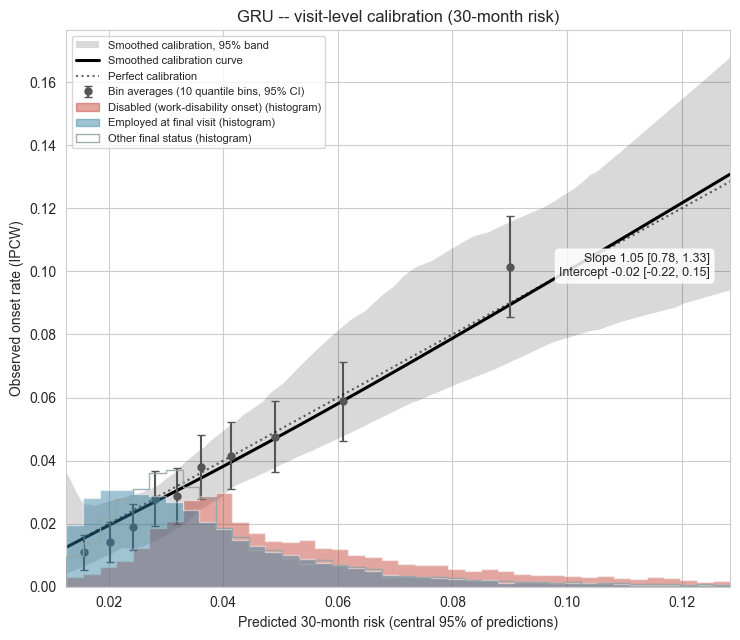


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Net benefit (R = 10),pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,
GRU,5,-0.012 (0.002),0.589 (0.010),0.765 (0.004),0.700 (0.004),0.103 (0.004),40.737 (3.751),0.882 (0.081),0.135 (0.032),0.865 (0.094)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
GRU,5,0.147 (0.012),0.247 (0.012),0.332 (0.007),0.411 (0.029),0.547 (0.034),0.955 (0.005),0.911 (0.007),0.866 (0.012),0.818 (0.017),0.715 (0.026)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis R = 10):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
GRU,5,0.647 (0.033),0.647 (0.033),0.648 (0.033),0.659 (0.034),0.742 (0.025),0.598 (0.036),0.597 (0.036),0.597 (0.036),0.583 (0.049),0.462 (0.059),40.637 (3.778),40.737 (3.751),40.776 (3.745),42.235 (5.183),54.152 (5.514)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
GRU,5,0.711 (0.004),0.709 (0.003),0.694 (0.003),0.691 (0.003),0.692 (0.004),0.693 (0.004),0.691 (0.004),0.686 (0.004)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {'h32_pretrain': 25}
Early stopping, outer-fold fits: median 21 epochs (range 12-38)


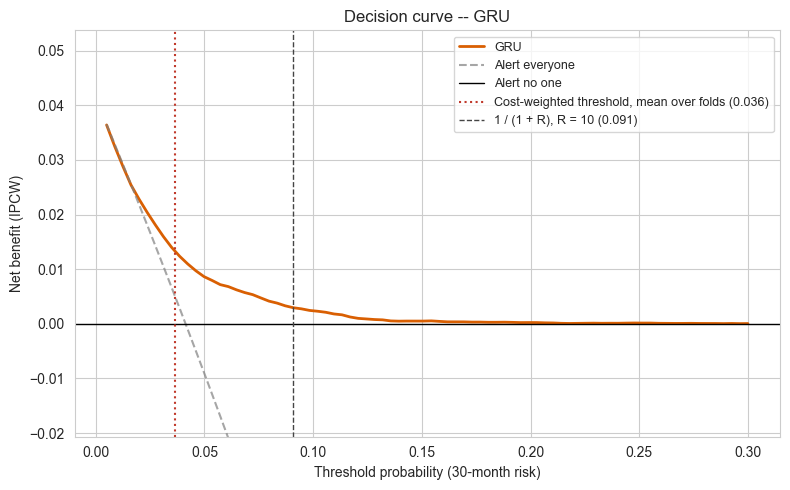

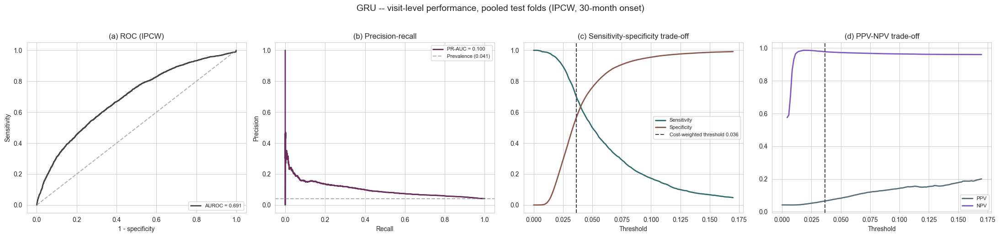

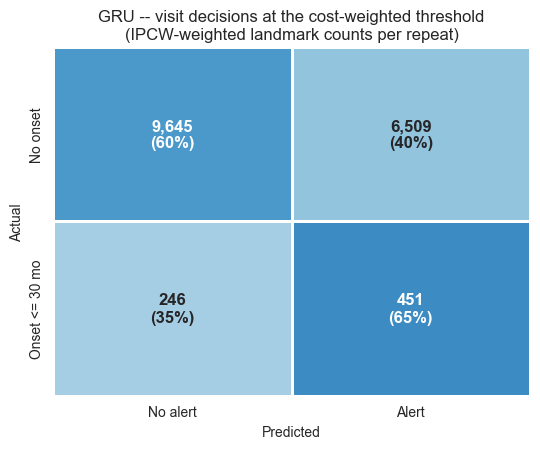

GRU: final refit on all rows (config h32_pretrain, 11 features) in 71s


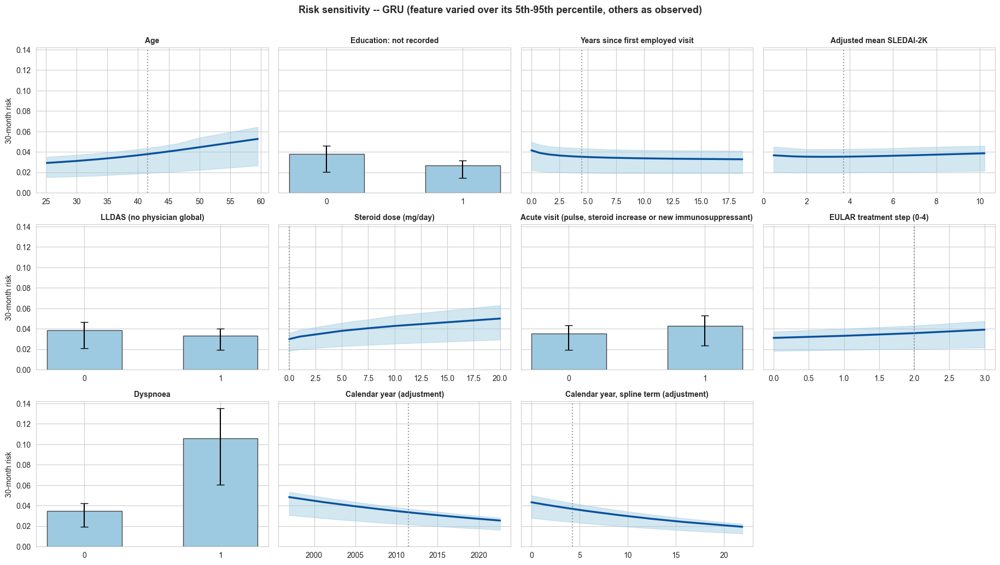


Risk-sensitivity summary -- GRU (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0349       0.1056                0.0707
                       Calendar year, spline term (adjustment)      0.0433       0.0194                0.0240
                                                           Age      0.0292       0.0527                0.0235
                                    Calendar year (adjustment)      0.0484       0.0255                0.0229
                                         Steroid dose (mg/day)      0.0299       0.0500                0.0201
                                       Education: not recorded      0.0383       0.0268                0.0114
                              Years since first employed visit      0.0416       0.0328                0.0088
                                    EULAR treatme

In [40]:
"""GRU (the main model's recipe -- inputs, pretraining, hazard heads (+ calendar year), early stopping, 5 seeds --
with a GRU cell, over the whole history)."""
res_gru = run_analysis("GRU", "GRU")

## 11.14 Causal Transformer

Resuming from cv_state_model_revised_v16.pkl: 170 model-fold fits already done.
[Transformer] repeat 1/5 fold 1/5 | AUROC 0.672 NB(R=10) -0.0106 | visit sens/spec 0.67/0.57 | patient sens/spec 0.79/0.42 (TN/FP 59/83) | cfg d32_pretrain | 11 feats | 116s
[Transformer] repeat 1/5 fold 2/5 | AUROC 0.702 NB(R=10) -0.0084 | visit sens/spec 0.47/0.72 | patient sens/spec 0.59/0.68 (TN/FP 94/44) | cfg d32_pretrain | 11 feats | 127s
[Transformer] repeat 1/5 fold 3/5 | AUROC 0.692 NB(R=10) -0.0016 | visit sens/spec 0.57/0.72 | patient sens/spec 0.75/0.61 (TN/FP 85/54) | cfg d32_pretrain | 11 feats | 133s
[Transformer] repeat 1/5 fold 4/5 | AUROC 0.651 NB(R=10) -0.0106 | visit sens/spec 0.41/0.71 | patient sens/spec 0.63/0.67 (TN/FP 95/47) | cfg d32_pretrain | 11 feats | 121s
[Transformer] repeat 1/5 fold 5/5 | AUROC 0.720 NB(R=10) -0.0073 | visit sens/spec 0.61/0.70 | patient sens/spec 0.70/0.53 (TN/FP 69/62) | cfg d32_pretrain | 11 feats | 108s
[Transformer] repeat 2/5 fold 1/5 | AUROC 0.727 NB

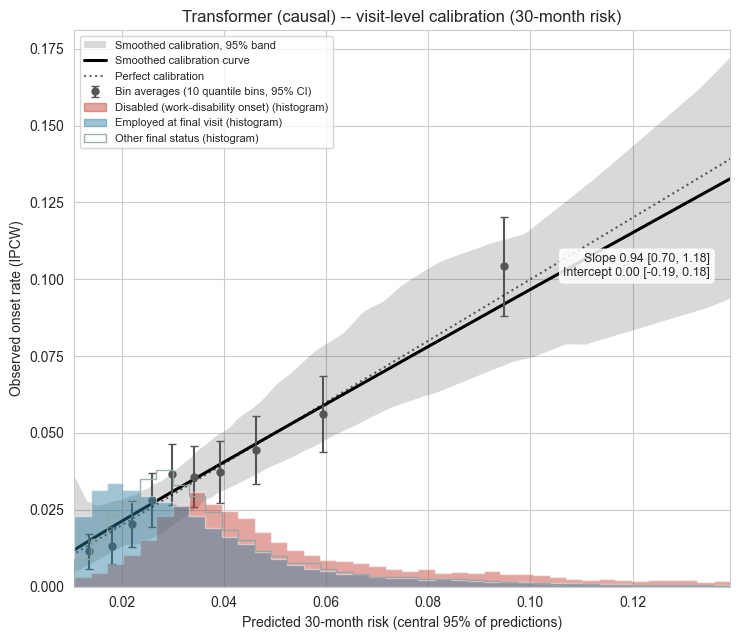


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Net benefit (R = 10),pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,
Transformer,5,-0.007 (0.003),0.584 (0.008),0.767 (0.004),0.695 (0.002),0.100 (0.003),33.890 (4.410),0.734 (0.096),0.215 (0.031),0.724 (0.105)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
Transformer,5,0.164 (0.021),0.260 (0.028),0.335 (0.031),0.398 (0.022),0.505 (0.030),0.945 (0.006),0.902 (0.007),0.866 (0.008),0.832 (0.010),0.765 (0.022)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis R = 10):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
Transformer,5,0.594 (0.042),0.594 (0.043),0.599 (0.040),0.610 (0.035),0.703 (0.049),0.668 (0.041),0.667 (0.041),0.665 (0.041),0.646 (0.046),0.502 (0.077),33.839 (4.412),33.890 (4.410),34.155 (4.374),36.054 (4.739),50.204 (7.645)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
Transformer,5,0.714 (0.007),0.705 (0.005),0.691 (0.003),0.688 (0.002),0.686 (0.002),0.686 (0.002),0.683 (0.002),0.675 (0.002)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {'d32_pretrain': 25}
Early stopping, outer-fold fits: median 29 epochs (range 15-60)


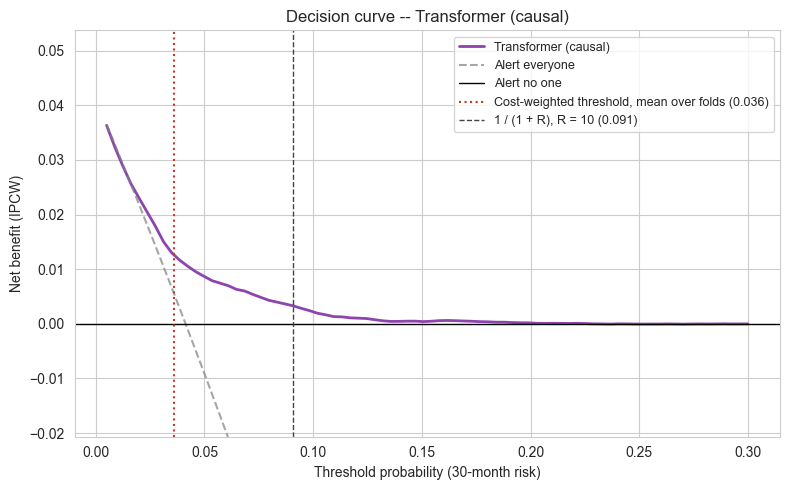

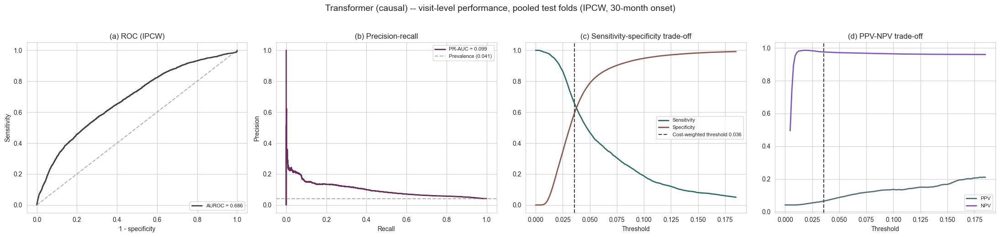

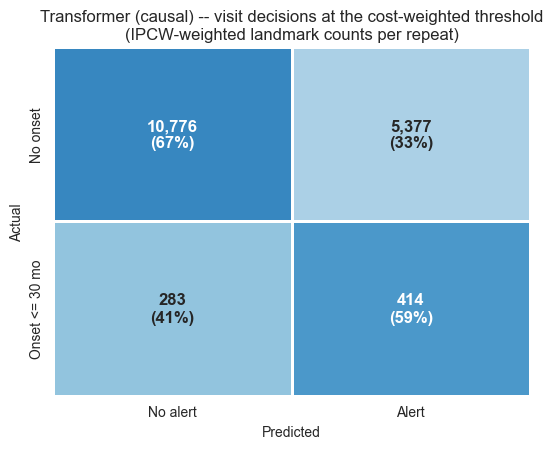

Transformer: final refit on all rows (config d32_pretrain, 11 features) in 70s


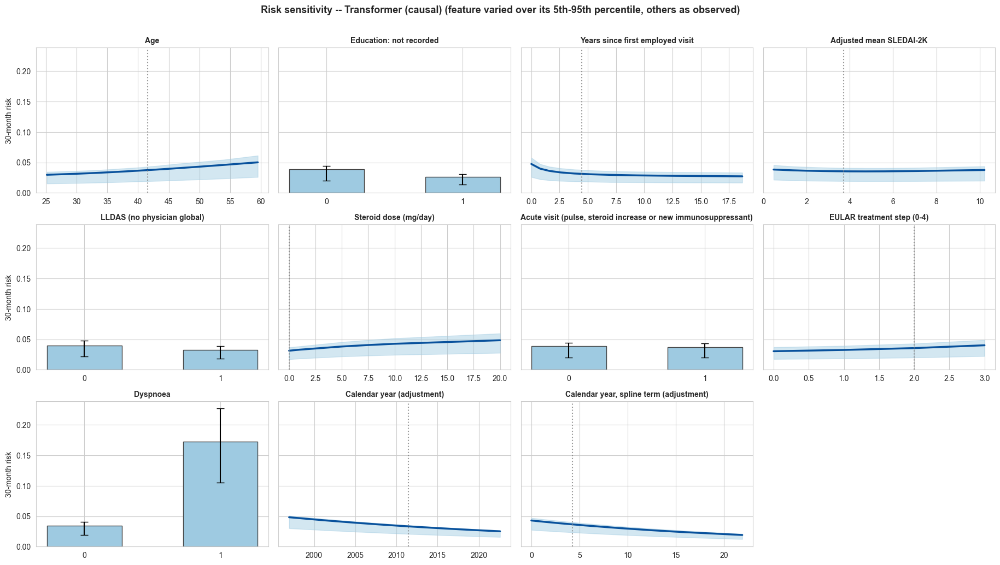


Risk-sensitivity summary -- Transformer (causal) (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0341       0.1721                0.1381
                       Calendar year, spline term (adjustment)      0.0429       0.0191                0.0238
                                    Calendar year (adjustment)      0.0482       0.0251                0.0231
                                                           Age      0.0297       0.0502                0.0204
                              Years since first employed visit      0.0475       0.0272                0.0203
                                         Steroid dose (mg/day)      0.0313       0.0485                0.0172
                                       Education: not recorded      0.0384       0.0259                0.0125
                                

In [41]:
"""causal Transformer (the main model's recipe with a 1-layer causal Transformer encoder over the whole history; elapsed time
since the first visit as an extra input)."""
res_transformer = run_analysis("Transformer", "Transformer (causal)")

## 11.14.1 XGBoost

Two gradient-boosted discrete-time hazards (work disability; other exit or death) on the person-interval rows of the
fold's selected variables, combined into the cumulative incidence of work disability (Section 6.2). Replaces revised
v14's equal-weight average.

Resuming from cv_state_model_revised_v16.pkl: 195 model-fold fits already done.
[XGBoost    ] repeat 1/5 fold 1/5 | AUROC 0.679 NB(R=10) -0.0109 | visit sens/spec 0.64/0.58 | patient sens/spec 0.86/0.44 (TN/FP 62/80) | cfg d2 | 11 feats | 16s
[XGBoost    ] repeat 1/5 fold 2/5 | AUROC 0.690 NB(R=10) -0.0233 | visit sens/spec 0.69/0.47 | patient sens/spec 0.89/0.38 (TN/FP 52/86) | cfg d3 | 11 feats | 19s
[XGBoost    ] repeat 1/5 fold 3/5 | AUROC 0.668 NB(R=10) -0.0123 | visit sens/spec 0.65/0.58 | patient sens/spec 0.75/0.40 (TN/FP 56/83) | cfg d3 | 11 feats | 10s
[XGBoost    ] repeat 1/5 fold 4/5 | AUROC 0.644 NB(R=10) -0.0151 | visit sens/spec 0.54/0.60 | patient sens/spec 0.80/0.44 (TN/FP 63/79) | cfg d2 | 11 feats | 9s
[XGBoost    ] repeat 1/5 fold 5/5 | AUROC 0.718 NB(R=10) -0.0168 | visit sens/spec 0.67/0.58 | patient sens/spec 0.85/0.40 (TN/FP 53/78) | cfg d2 | 11 feats | 9s
[XGBoost    ] repeat 2/5 fold 1/5 | AUROC 0.680 NB(R=10) -0.0144 | visit sens/spec 0.55/0.63 | patient sens

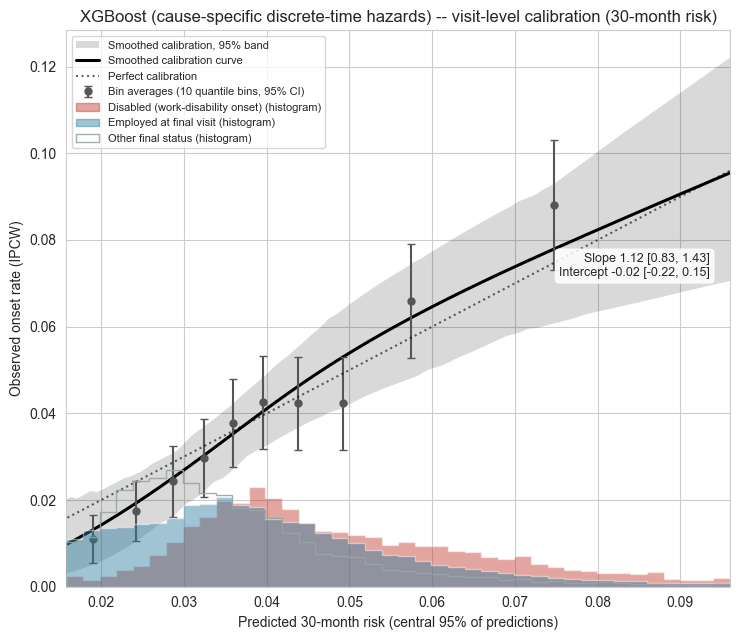


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Net benefit (R = 10),pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,
XGBoost,5,-0.016 (0.001),0.583 (0.009),0.730 (0.005),0.671 (0.006),0.076 (0.003),46.031 (0.478),0.997 (0.010),0.089 (0.012),1.043 (0.016)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
XGBoost,5,0.098 (0.008),0.190 (0.004),0.271 (0.012),0.352 (0.019),0.479 (0.024),0.958 (0.002),0.911 (0.004),0.861 (0.003),0.810 (0.002),0.702 (0.008)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis R = 10):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
XGBoost,5,0.626 (0.015),0.627 (0.014),0.628 (0.014),0.647 (0.024),0.826 (0.059),0.561 (0.004),0.561 (0.004),0.559 (0.003),0.540 (0.023),0.312 (0.085),45.978 (0.465),46.031 (0.478),46.237 (0.505),48.175 (2.329),70.701 (8.216)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
XGBoost,5,0.681 (0.007),0.672 (0.004),0.660 (0.005),0.660 (0.006),0.663 (0.006),0.664 (0.006),0.663 (0.006),0.658 (0.007)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {'d2': 17, 'd3': 8}


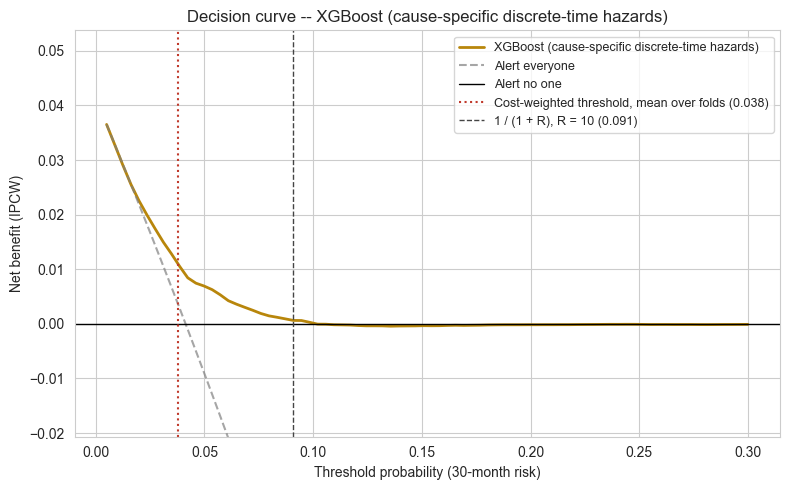

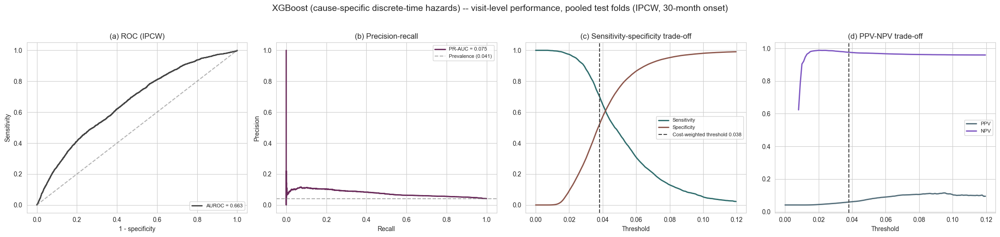

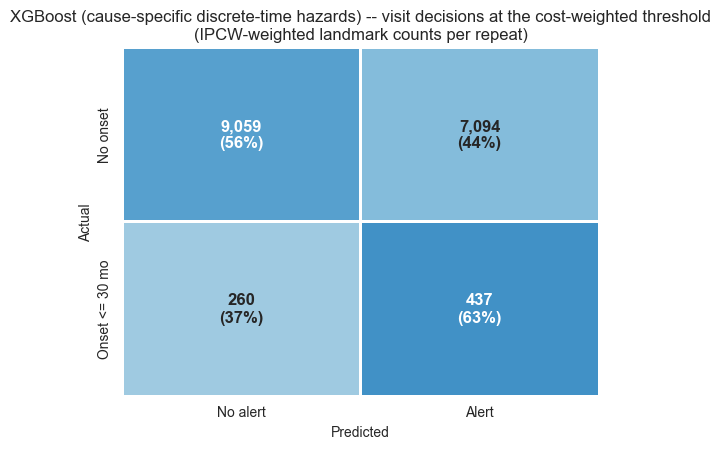

XGBoost: final refit on all rows (config d2, 11 features) in 3s


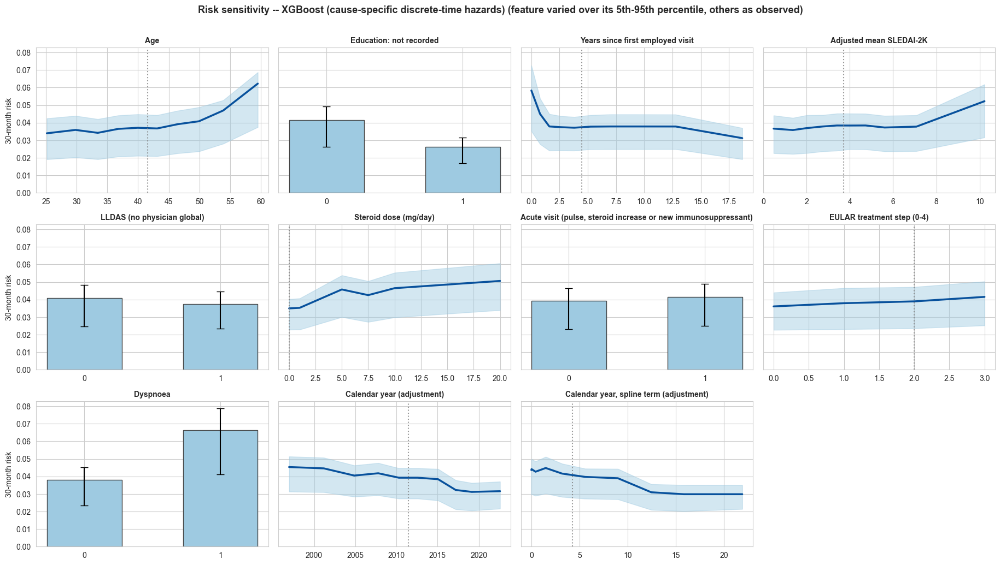


Risk-sensitivity summary -- XGBoost (cause-specific discrete-time hazards) (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0381       0.0664                0.0283
                                                           Age      0.0339       0.0623                0.0283
                              Years since first employed visit      0.0583       0.0312                0.0272
                                       Adjusted mean SLEDAI-2K      0.0366       0.0522                0.0165
                                         Steroid dose (mg/day)      0.0350       0.0506                0.0157
                                       Education: not recorded      0.0414       0.0262                0.0152
                       Calendar year, spline term (adjustment)      0.0436       0.0299                0.0149
      

In [42]:
"""XGBoost (Section 6.2): cause-specific discrete-time hazards on the fold's LASSO-selected variables (as recorded),
tree depth tuned inside each training fold on the cross-fitted cost-weighted net benefit."""
res_xgb = run_analysis("XGBoost", "XGBoost (cause-specific discrete-time hazards)")

## 11.14.2 Stacking ensemble

The seven members' cross-fitted 30-month logits combined by a non-negative IPCW logistic meta-learner in every training
fold (Section 6.3); then the meta-weights, and the supplementary stacks (Chen et al.'s MLP meta-learner; the tabular
members only) on the same folds.

Resuming from cv_state_model_revised_v16.pkl: 220 model-fold fits already done.
[Stack      ] repeat 1/5 fold 1/5 | AUROC 0.687 NB(R=10) -0.0110 | visit sens/spec 0.67/0.56 | patient sens/spec 0.79/0.42 (TN/FP 59/83) | cfg stack (logistic meta-learner) | 11 feats | 1s
[Stack      ] repeat 1/5 fold 2/5 | AUROC 0.703 NB(R=10) -0.0100 | visit sens/spec 0.60/0.65 | patient sens/spec 0.74/0.55 (TN/FP 76/62) | cfg stack (logistic meta-learner) | 11 feats | 0s
[Stack      ] repeat 1/5 fold 3/5 | AUROC 0.704 NB(R=10) -0.0058 | visit sens/spec 0.61/0.66 | patient sens/spec 0.75/0.50 (TN/FP 69/70) | cfg stack (logistic meta-learner) | 11 feats | 0s
[Stack      ] repeat 1/5 fold 4/5 | AUROC 0.661 NB(R=10) -0.0109 | visit sens/spec 0.50/0.66 | patient sens/spec 0.77/0.57 (TN/FP 81/61) | cfg stack (logistic meta-learner) | 11 feats | 0s
[Stack      ] repeat 1/5 fold 5/5 | AUROC 0.704 NB(R=10) -0.0132 | visit sens/spec 0.63/0.63 | patient sens/spec 0.78/0.47 (TN/FP 61/70) | cfg stack (logistic meta-

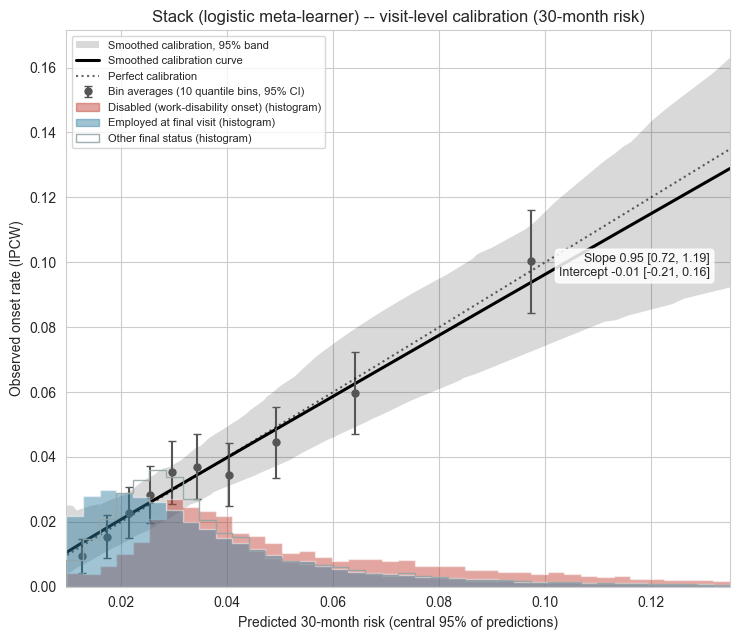


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Net benefit (R = 10),pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,
Stack,5,-0.010 (0.001),0.590 (0.004),0.771 (0.003),0.698 (0.003),0.100 (0.001),38.018 (1.765),0.823 (0.038),0.148 (0.015),0.812 (0.043)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
Stack,5,0.160 (0.013),0.256 (0.014),0.336 (0.017),0.413 (0.016),0.530 (0.021),0.951 (0.003),0.903 (0.003),0.857 (0.002),0.814 (0.003),0.725 (0.007)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis R = 10):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
Stack,5,0.621 (0.018),0.621 (0.018),0.622 (0.017),0.624 (0.020),0.683 (0.041),0.632 (0.016),0.632 (0.017),0.631 (0.017),0.625 (0.022),0.539 (0.055),37.981 (1.721),38.018 (1.765),38.175 (1.829),38.756 (2.394),47.557 (5.857)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
Stack,5,0.720 (0.004),0.710 (0.002),0.695 (0.002),0.691 (0.002),0.690 (0.003),0.689 (0.002),0.685 (0.002),0.679 (0.002)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {'stack (logistic meta-learner)': 25}


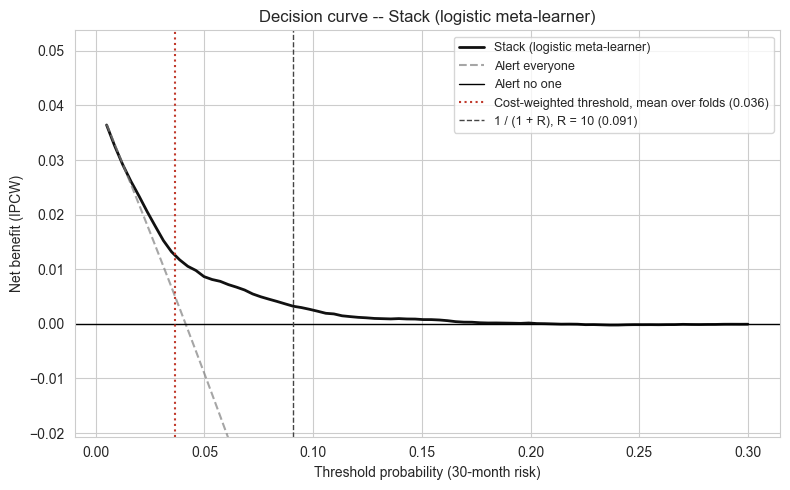

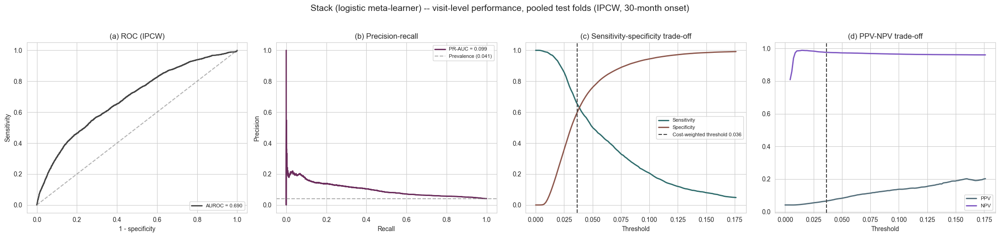

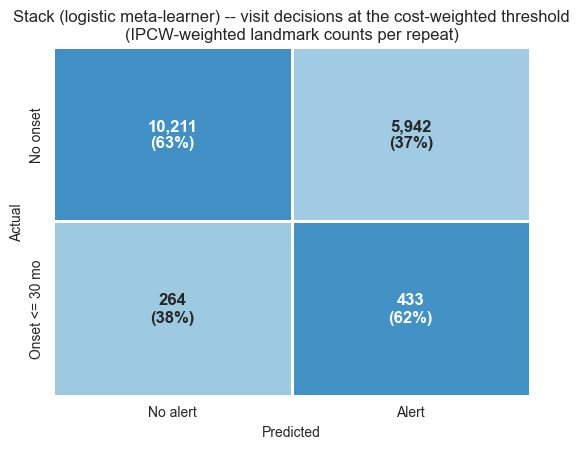

Meta-learner weights over the folds (non-negative; on the members' 30-month logits):


,Mean,Min,Max,Share of folds > 0
LSTM-8 (main),0.203,0.000,0.662,0.76
LogReg,0.220,0.000,0.402,0.96
RSF,0.338,0.025,0.890,1.00
CoxPH,0.264,0.000,0.516,0.96
GRU,0.118,0.000,0.315,0.68
Transformer,0.223,0.000,0.713,0.84
XGBoost,0.027,0.000,0.254,0.32


Ridge penalty chosen per fold: {0.001: 16, 0.01: 9}
Resuming from cv_state_model_revised_v16.pkl: 245 model-fold fits already done.
[StackMLP   ] repeat 1/5 fold 1/5 | AUROC 0.684 NB(R=10) -0.0105 | visit sens/spec 0.67/0.57 | patient sens/spec 0.83/0.41 (TN/FP 58/84) | cfg stack (mlp meta-learner) | 11 feats | 1s
[StackTab   ] repeat 1/5 fold 1/5 | AUROC 0.684 NB(R=10) -0.0128 | visit sens/spec 0.63/0.57 | patient sens/spec 0.79/0.39 (TN/FP 55/87) | cfg stack (logistic meta-learner) | 11 feats | 0s
[StackMLP   ] repeat 1/5 fold 2/5 | AUROC 0.706 NB(R=10) -0.0081 | visit sens/spec 0.62/0.66 | patient sens/spec 0.74/0.55 (TN/FP 76/62) | cfg stack (mlp meta-learner) | 11 feats | 1s
[StackTab   ] repeat 1/5 fold 2/5 | AUROC 0.696 NB(R=10) -0.0158 | visit sens/spec 0.64/0.57 | patient sens/spec 0.78/0.49 (TN/FP 68/70) | cfg stack (logistic meta-learner) | 11 feats | 0s
[StackMLP   ] repeat 1/5 fold 3/5 | AUROC 0.704 NB(R=10) -0.0053 | visit sens/spec 0.62/0.66 | patient sens/spec 0.79/0.54

,auroc,auroc_pt_weighted,brier,cal_slope,net_benefit,uno_c
model,,,,,,
Stack (logistic meta-learner),0.6901,0.7708,0.0386,0.9519,-0.0096,0.6976
Stack (MLP meta-learner),0.6892,0.7677,0.0387,0.9281,-0.0095,0.6965
Stack (tabular members only),0.6874,0.7681,0.0387,0.9973,-0.0109,0.6942


In [43]:
"""The stacking ensemble (Section 6.3): formed per fold from the members' stored fold results (seconds; the member
sections must have run). Then the meta-weights over the folds and the supplementary stacks."""
res_stack = run_analysis("Stack", "Stack (logistic meta-learner)")
if res_stack is not None:
    _W = pd.DataFrame([v["weights"] for k, v in cv_state["folds"].items() if k[0] == "Stack" and v.get("weights")])
    print("Meta-learner weights over the folds (non-negative; on the members' 30-month logits):")
    display(pd.DataFrame({"Mean": _W.mean(), "Min": _W.min(), "Max": _W.max(), "Share of folds > 0": (_W > 0).mean()},
                         ).rename(index=lambda m: MODEL_LABELS.get(m, m)).round(3))
    print("Ridge penalty chosen per fold:",
          pd.Series([v["ridge"] for k, v in cv_state["folds"].items() if k[0] == "Stack"]).value_counts().to_dict())
cv_state = run_repeated_cv(models=SUPP_STACK_MODELS)
_res_s, _ = collect_results(cv_state, ["Stack"] + SUPP_STACK_MODELS)
if not _res_s.empty:
    print("\nThe stacks compared (pooled test folds; mean over repeats):")
    display(_res_s.groupby("model")[["auroc", "auroc_pt_weighted", "brier", "cal_slope", "net_benefit", "uno_c"]]
            .mean().rename(index=lambda m: MODEL_LABELS.get(m, m)).round(4))

## 11.15 Visit-level summary — all models

Every metric of the per-model visit tables, value [95 % patient-bootstrap CI], with LaTeX rows for the manuscript.

In [44]:
"""
Visit-level summary for all models: every metric of the per-model tables, value [95% patient-bootstrap CI], one row per
model, with LaTeX rows for the manuscript. The per-repeat metrics go to cv_model_revised_v16_pooled_metrics_by_repeat.csv.
"""
MODEL_RESULTS = {m: r for m, r in [("LSTM", res_lstm), ("LSTM1", res_lstm1), ("LogReg", res_logreg),
                                   ("RSF", res_rsf), ("CoxPH", res_cox),
                                   ("GRU", res_gru), ("Transformer", res_transformer),
                                   ("XGBoost", res_xgb), ("Stack", res_stack)]
                 if r is not None}
res_all = pd.concat([r["res_df"] for r in MODEL_RESULTS.values()], ignore_index=True)
preds_all = {k: v for r in MODEL_RESULTS.values() for k, v in r["preds"].items()}
res_all.to_csv("cv_model_revised_v16_pooled_metrics_by_repeat.csv", index=False)


def wide_table(key):
    """One row per model: 'value [CI low, CI high]' for every metric of table `key`."""
    cell = lambda row: (f"{row['Value']:.3f} [{row['CI low']:.3f}, {row['CI high']:.3f}]"
                        if np.isfinite(row["Value"]) else "n/a")
    return pd.DataFrame({m: {row["Metric"]: cell(row) for _, row in r[key].iterrows()}
                         for m, r in MODEL_RESULTS.items()}).T


def latex_table_rows(key):
    return [f"{m:<11} & " + " & ".join(f"{row['Value']:.3f} ({row['CI low']:.3f}--{row['CI high']:.3f})"
                                       if np.isfinite(row["Value"]) else "n/a"
                                       for _, row in r[key].iterrows()) + " \\\\"
            for m, r in MODEL_RESULTS.items()]


visit_summary = wide_table("visit_table")
print("VISIT LEVEL -- all models: value [95% patient-cluster bootstrap CI]; mean over CV repeats of the pooled test "
      "folds; 30-month onset, IPCW; alarms at each fold's visit threshold")
display(visit_summary)
print("\nLaTeX rows (" + " & ".join(visit_summary.columns) + "):")
print("\n".join(latex_table_rows("visit_table")))

VISIT LEVEL -- all models: value [95% patient-cluster bootstrap CI]; mean over CV repeats of the pooled test folds; 30-month onset, IPCW; alarms at each fold's visit threshold


,Concordance Index,Brier Score,Calibration Slope,Calibration Intercept,Observed / Expected,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy
LSTM,"0.685 [0.634, 0.734]","0.039 [0.032, 0.045]","0.978 [0.730, 1.241]","-0.030 [-0.228, 0.141]","0.973 [0.808, 1.141]","0.622 [0.540, 0.699]","0.608 [0.582, 0.632]","0.064 [0.050, 0.078]","0.974 [0.966, 0.980]","0.615 [0.575, 0.653]"
LSTM1,"0.684 [0.632, 0.732]","0.039 [0.032, 0.045]","0.959 [0.715, 1.213]","-0.018 [-0.218, 0.153]","0.983 [0.816, 1.153]","0.614 [0.531, 0.690]","0.620 [0.594, 0.644]","0.065 [0.051, 0.080]","0.974 [0.967, 0.980]","0.617 [0.575, 0.656]"
LogReg,"0.680 [0.628, 0.731]","0.039 [0.032, 0.045]","0.998 [0.738, 1.254]","0.001 [-0.197, 0.167]","1.001 [0.831, 1.168]","0.613 [0.531, 0.691]","0.612 [0.586, 0.636]","0.064 [0.050, 0.078]","0.973 [0.966, 0.980]","0.612 [0.570, 0.654]"
RSF,"0.684 [0.634, 0.732]","0.039 [0.032, 0.045]","1.012 [0.743, 1.307]","0.006 [-0.194, 0.181]","1.005 [0.833, 1.184]","0.604 [0.531, 0.676]","0.610 [0.586, 0.633]","0.063 [0.050, 0.076]","0.973 [0.966, 0.980]","0.607 [0.570, 0.645]"
CoxPH,"0.678 [0.627, 0.727]","0.039 [0.032, 0.045]","1.024 [0.782, 1.262]","0.004 [-0.195, 0.172]","1.004 [0.832, 1.173]","0.599 [0.516, 0.679]","0.603 [0.575, 0.628]","0.061 [0.047, 0.075]","0.972 [0.964, 0.979]","0.601 [0.558, 0.643]"
GRU,"0.692 [0.641, 0.742]","0.039 [0.032, 0.045]","1.050 [0.777, 1.326]","-0.024 [-0.223, 0.151]","0.978 [0.811, 1.151]","0.647 [0.565, 0.722]","0.597 [0.566, 0.625]","0.065 [0.051, 0.079]","0.975 [0.968, 0.982]","0.622 [0.580, 0.660]"
Transformer,"0.686 [0.634, 0.735]","0.039 [0.032, 0.045]","0.943 [0.698, 1.183]","0.004 [-0.192, 0.178]","1.004 [0.835, 1.180]","0.594 [0.515, 0.672]","0.667 [0.641, 0.690]","0.072 [0.056, 0.088]","0.974 [0.967, 0.981]","0.630 [0.591, 0.670]"
XGBoost,"0.663 [0.618, 0.711]","0.039 [0.033, 0.046]","1.121 [0.834, 1.426]","-0.015 [-0.215, 0.153]","0.985 [0.815, 1.156]","0.627 [0.557, 0.692]","0.561 [0.534, 0.585]","0.058 [0.046, 0.071]","0.972 [0.965, 0.979]","0.594 [0.556, 0.629]"
Stack,"0.690 [0.640, 0.738]","0.039 [0.032, 0.045]","0.951 [0.718, 1.194]","-0.012 [-0.211, 0.159]","0.989 [0.821, 1.158]","0.621 [0.545, 0.697]","0.632 [0.605, 0.657]","0.068 [0.054, 0.083]","0.975 [0.968, 0.981]","0.627 [0.589, 0.666]"



LaTeX rows (Concordance Index & Brier Score & Calibration Slope & Calibration Intercept & Observed / Expected & Sensitivity & Specificity & PPV & NPV & Balanced Accuracy):
LSTM        & 0.685 (0.634--0.734) & 0.039 (0.032--0.045) & 0.978 (0.730--1.241) & -0.030 (-0.228--0.141) & 0.973 (0.808--1.141) & 0.622 (0.540--0.699) & 0.608 (0.582--0.632) & 0.064 (0.050--0.078) & 0.974 (0.966--0.980) & 0.615 (0.575--0.653) \\
LSTM1       & 0.684 (0.632--0.732) & 0.039 (0.032--0.045) & 0.959 (0.715--1.213) & -0.018 (-0.218--0.153) & 0.983 (0.816--1.153) & 0.614 (0.531--0.690) & 0.620 (0.594--0.644) & 0.065 (0.051--0.080) & 0.974 (0.967--0.980) & 0.617 (0.575--0.656) \\
LogReg      & 0.680 (0.628--0.731) & 0.039 (0.032--0.045) & 0.998 (0.738--1.254) & 0.001 (-0.197--0.167) & 1.001 (0.831--1.168) & 0.613 (0.531--0.691) & 0.612 (0.586--0.636) & 0.064 (0.050--0.078) & 0.973 (0.966--0.980) & 0.612 (0.570--0.654) \\
RSF         & 0.684 (0.634--0.732) & 0.039 (0.032--0.045) & 1.012 (0.743--1.307) & 0.00

## 11.15.1 Pre-specified hypotheses (H1a → H1b → H2) and the secondary estimands

The tests of Section 8.1 from the pooled test folds (no refitting; the Baseline is fitted here on the same folds if it
has not run yet), then every model's era-stratified AUROC, the implied cost ratio of its alarm threshold and the
patient-level net benefit of its deployed alarm rule against flagging every patient.

In [45]:
"""
Pre-specified hypothesis tests (Section 8.1; the analysis plan's Section 8): fixed-sequence H1a -> H1b -> H3 -> H2, each at
two-sided alpha = 0.05, and the secondary estimands, from the pooled test folds of the main CV (no refitting):
  H1a  AUROC(LSTM) - AUROC(Baseline) > 0, pooled AND era-stratified (competing-risk IPCW, 30 months)
  H1b  AUROC(LSTM) - AUROC(LogReg) > NONINFERIORITY_MARGIN
  H3   AUROC(Stack) - AUROC(LogReg) > 0
  H2   AUROC(LSTM) - AUROC(LSTM1) > 0
  H2b  within-patient rising risk: case-minus-placebo concordance (risk-set placebo), LSTM - LSTM1
  H2c  AUROC of the 12-month change in predicted log-odds, LSTM - LSTM1
  H2f  GRU - LogReg, Transformer - LogReg
Every Delta is paired (same folds, averaged over the CV repeats both models completed) with a 95% patient-cluster
bootstrap CI (HYP_BOOT resamples of patients with all their landmarks; the same resamples for every comparison).
"""
cv_state = run_repeated_cv(models=["Baseline"])           # identical folds, same checkpoint (resumable)
HYP_BOOT = 200 if SMOKE else 1000
HYP_MODELS = [m for m in CV_MODELS + SUPP_STACK_MODELS + ["Baseline"] if any(k[0] == m for k in cv_state["folds"])]
Y30, W30 = IPCW[PRIMARY_HORIZON_MONTHS]
ERA_OF_LAND = np.digitize(CAL_YEAR_ALL, [b[1] for b in ERA_BANDS[:-1]])
N_ERAS = len(ERA_BANDS)


def oof_P30(model):
    """Pooled out-of-fold calibrated 30-month risks: {repeat: vector} for every completed repeat."""
    out = {}
    for (m, r, k), v in cv_state["folds"].items():
        if m == model:
            out.setdefault(r, np.full(len(land), np.nan))[v["te"]] = v["P"][:, PRIMARY_COL]
    return {r: p for r, p in out.items() if not np.isnan(p).any()}


P30 = {m: d for m in HYP_MODELS if (d := oof_P30(m))}   # models with >= 1 complete repeat
_PREP_H = {}


def _auc_of(key, score, w, era_strat):
    """IPCW AUROC of `score` (pooled, or era-stratified = case-control pairs from the same era only)."""
    if not era_strat:
        if key not in _PREP_H:
            _PREP_H[key] = auc_prep(Y30, score)
        return auc_w(_PREP_H[key], w)
    num = den = 0.0
    for e in range(N_ERAS):
        k = ERA_OF_LAND == e
        if (key, e) not in _PREP_H:
            _PREP_H[(key, e)] = auc_prep(Y30[k], score[k])
        ww = w[k]
        n1, n0 = (ww * (Y30[k] == 1)).sum(), (ww * (Y30[k] == 0)).sum()
        a = auc_w(_PREP_H[(key, e)], ww)
        if np.isfinite(a) and n1 > 0 and n0 > 0:
            num, den = num + a * n1 * n0, den + n1 * n0
    return num / den if den > 0 else np.nan


_rng_h = np.random.default_rng(2031)
HYP_MULT = [np.bincount(_rng_h.integers(0, len(PT_CODE), len(PT_CODE)), minlength=len(PT_CODE)).astype(float)[LAND_CODE]
            for _ in range(HYP_BOOT)]


def model_auc(m, era_strat=False, scores=None, w=None, tag=""):
    """Mean over repeats of one model's AUROC, with its bootstrap distribution."""
    scores = scores or P30[m]
    w = W30 if w is None else w
    f = lambda mult: np.mean([_auc_of((m, r, tag), scores[r], w * mult, era_strat) for r in sorted(scores)])
    return f(1.0), np.array([f(mult) for mult in HYP_MULT])


def paired_delta(a, b, era_strat=False, scores_a=None, scores_b=None, w=None, tag=""):
    """Delta AUROC (a - b), mean over the repeats both completed; 95% bootstrap CI; share of resamples > 0."""
    sa, sb = scores_a or P30.get(a, {}), scores_b or P30.get(b, {})
    reps = sorted(set(sa) & set(sb))
    if not reps:
        return None
    w = W30 if w is None else w
    f = lambda mult: np.mean([_auc_of((a, r, tag), sa[r], w * mult, era_strat)
                              - _auc_of((b, r, tag), sb[r], w * mult, era_strat) for r in reps])
    est, B = f(1.0), np.array([f(mult) for mult in HYP_MULT])
    lo, hi = np.nanpercentile(B, [2.5, 97.5])
    return {"Delta": est, "CI low": lo, "CI high": hi, "Share of resamples > 0": float(np.nanmean(B > 0)),
            "Repeats": len(reps)}


# ------------------------------------------------------------------------------------------------ H1a, H1b, H2
hyp = {"H1a: LSTM-8 - Baseline (pooled)": (paired_delta("LSTM", "Baseline"), 0.0),
       "H1a: LSTM-8 - Baseline (era-stratified)": (paired_delta("LSTM", "Baseline", era_strat=True), 0.0),
       "H1b: LSTM-8 - LogReg (non-inferiority)": (paired_delta("LSTM", "LogReg"), NONINFERIORITY_MARGIN),
       "H3: Stack - LogReg": (paired_delta("Stack", "LogReg"), 0.0),
       "H2: LSTM-8 - LSTM-1": (paired_delta("LSTM", "LSTM1"), 0.0)}
rows = []
for name, (d, bound) in hyp.items():
    met = d is not None and d["CI low"] > bound
    rows.append({"Hypothesis": name, **(d or {}), "Success if lower bound >": bound, "Criterion met": met})
hyp_df = pd.DataFrame(rows).set_index("Hypothesis")
h1a = bool(hyp_df.loc[[i for i in hyp_df.index if i.startswith("H1a")], "Criterion met"].all())
h1b = bool(hyp_df.loc["H1b: LSTM-8 - LogReg (non-inferiority)", "Criterion met"])
h3 = bool(hyp_df.loc["H3: Stack - LogReg", "Criterion met"])
h2 = bool(hyp_df.loc["H2: LSTM-8 - LSTM-1", "Criterion met"])
claims = {"H1a": h1a, "H1b": h1a and h1b, "H3": h1a and h1b and h3, "H2": h1a and h1b and h3 and h2}
hyp_df["Claimed (fixed sequence)"] = [claims[i.split(":")[0]] for i in hyp_df.index]
print(f"PRE-SPECIFIED HYPOTHESES -- competing-risk IPCW AUROC at {PRIMARY_HORIZON_MONTHS} months, paired Delta with a "
      f"95% patient-cluster bootstrap CI ({HYP_BOOT} resamples); fixed-sequence testing H1a -> H1b -> H3 -> H2:")
display(hyp_df.round(4))
for h, v in claims.items():
    print(f"  {h}: {'CLAIMED' if v else 'not claimed'}")

# ------------------------------------------------------------------------------------------------ secondary
sec = {}
for a, b, lab_ in [("GRU", "LogReg", "H2f: GRU - LogReg"),
                   ("Transformer", "LogReg", "H2f: Transformer - LogReg"),
                   ("XGBoost", "LogReg", "XGBoost - LogReg"), ("StackMLP", "Stack", "Stack (MLP) - Stack"),
                   ("StackTab", "Stack", "Stack (tabular members) - Stack"),
                   ("Stack", "LogReg", "Stack - LogReg (era-stratified)"),
                   ("LSTM", "LogReg", "LSTM-8 - LogReg (era-stratified)"), ("LSTM", "LSTM1", "LSTM-8 - LSTM-1 (era-stratified)")]:
    d = paired_delta(a, b, era_strat="era-stratified" in lab_)
    if d is not None:
        sec[lab_] = d
_members_done = [m for m in STACK_MEMBERS if m in P30]
if "Stack" in P30 and _members_done:
    _best = max(_members_done, key=lambda m: model_auc(m)[0])
    d = paired_delta("Stack", _best)
    if d is not None:
        sec[f"Stack - its best single member ({MODEL_LABELS.get(_best, _best)}, chosen on these folds)"] = d

# H2c: the 12-month change in predicted log-odds (vs the landmark 9-15 months earlier, nearest to 12 months)
def _prior_12m():
    out = np.full(len(land), -1)
    d = pd.to_datetime(land["visit_date"]).values
    for _, idx in land.groupby("pid").indices.items():
        t = d[idx]
        for j in range(len(idx)):
            dt = (t[j] - t[:j]) / np.timedelta64(1, "D")
            c = np.flatnonzero((dt >= 270) & (dt <= 460))
            if len(c):
                out[idx[j]] = idx[c[np.argmin(np.abs(dt[c] - 365))]]
    return out


PRIOR_12M = _prior_12m()
HAS_PRIOR = PRIOR_12M >= 0
change = lambda m: {r: np.where(HAS_PRIOR, _logit(p) - _logit(p[np.maximum(PRIOR_12M, 0)]), 0.0) for r, p in P30[m].items()}
if "LSTM" in P30 and "LSTM1" in P30:
    ch8, ch1 = change("LSTM"), change("LSTM1")
    d = paired_delta("LSTM", "LSTM1", scores_a=ch8, scores_b=ch1, w=W30 * HAS_PRIOR, tag="change")
    a8 = model_auc("LSTM", scores=ch8, w=W30 * HAS_PRIOR, tag="change")[0]
    a1 = model_auc("LSTM1", scores=ch1, w=W30 * HAS_PRIOR, tag="change")[0]
    sec["H2c: change-in-risk AUROC, LSTM-8 - LSTM-1"] = {**d, "AUROC a": a8, "AUROC b": a1}


# H2b: within-patient case-minus-placebo concordance (risk-set placebo)
def placebo_pairs(seed=2026, k_ctrl=5):
    lm = land.assign(onset_y=land["YRS_SINCE_INDEX"] + land["time_days"] / 365.25)
    by = {p: g for p, g in lm.groupby("pid")}
    ctrl_pids = lm.loc[lm["pt_event"] == 0, "pid"].unique()
    ctrl_fu = {q: float(by[q]["onset_y"].max()) for q in ctrl_pids}
    ctrl_y0 = {q: float((by[q]["CAL_YEAR"] - by[q]["YRS_SINCE_INDEX"]).min()) for q in ctrl_pids}
    edges, hy = [b[1] for b in ERA_BANDS[:-1]], HORIZON_DAYS / 365.25
    rng = np.random.default_rng(seed)
    cases, ctrls = [], []
    for p in lm.loc[lm["event"] == 1, "pid"].unique():
        g = by[p]
        near, far = g.index[g["time_days"] <= HORIZON_DAYS].values, g.index[g["time_days"] > HORIZON_DAYS].values
        if not len(near) or not len(far):
            continue
        T = float(g["onset_y"].iloc[0])
        e_case = np.digitize(float((g["CAL_YEAR"] + g["time_days"] / 365.25).iloc[0]), edges)
        cases.append((near, far))
        elig = []
        for q in ctrl_pids:
            if ctrl_fu[q] < T + hy or np.digitize(ctrl_y0[q] + T, edges) != e_case:
                continue
            gq = by[q]
            nq = gq.index[(gq["YRS_SINCE_INDEX"] > T - hy) & (gq["YRS_SINCE_INDEX"] <= T)].values
            fq = gq.index[gq["YRS_SINCE_INDEX"] <= T - hy].values
            if len(nq) and len(fq):
                elig.append((nq, fq))
        for i in (rng.choice(len(elig), min(k_ctrl, len(elig)), replace=False) if elig else []):
            ctrls.append(elig[i])
    return cases, ctrls


PL_CASES, PL_CTRLS = placebo_pairs()


def _conc(p, pairs):
    return np.array([(p[a][:, None] > p[b][None, :]).mean() + 0.5 * (p[a][:, None] == p[b][None, :]).mean()
                     for a, b in pairs])


def did_components(m):
    """Per case and per control concordance, averaged over the model's repeats."""
    reps = sorted(P30[m])
    return (np.mean([_conc(P30[m][r], PL_CASES) for r in reps], axis=0),
            np.mean([_conc(P30[m][r], PL_CTRLS) for r in reps], axis=0))


_rng_d = np.random.default_rng(2032)
_bi_c = [_rng_d.integers(0, len(PL_CASES), len(PL_CASES)) for _ in range(HYP_BOOT)]
_bi_k = [_rng_d.integers(0, len(PL_CTRLS), len(PL_CTRLS)) for _ in range(HYP_BOOT)]
did_rows, DID = [], {}
for m in [x for x in ["LSTM", "LSTM1", "LogReg", "LogRegH", "CoxPH", "RSF", "GRU", "Transformer", "XGBoost", "Stack"]
          if x in P30]:
    cs, cc = did_components(m)
    DID[m] = (cs, cc)
    B = np.array([cs[i].mean() - cc[j].mean() for i, j in zip(_bi_c, _bi_k)])
    did_rows.append({"Model": MODEL_LABELS.get(m, m), "Cases: P(near > far)": cs.mean(),
                     "Placebo: P(near > far)": cc.mean(), "Case - placebo": cs.mean() - cc.mean(),
                     "CI low": np.percentile(B, 2.5), "CI high": np.percentile(B, 97.5)})
did_df = pd.DataFrame(did_rows).set_index("Model")
if "LSTM" in DID and "LSTM1" in DID:
    (c8, k8), (c1, k1) = DID["LSTM"], DID["LSTM1"]
    B = np.array([(c8[i].mean() - k8[j].mean()) - (c1[i].mean() - k1[j].mean()) for i, j in zip(_bi_c, _bi_k)])
    est = (c8.mean() - k8.mean()) - (c1.mean() - k1.mean())
    sec["H2b: within-patient case - placebo concordance, LSTM-8 - LSTM-1"] = {
        "Delta": est, "CI low": np.percentile(B, 2.5), "CI high": np.percentile(B, 97.5),
        "Share of resamples > 0": float(np.mean(B > 0)), "Repeats": len(P30["LSTM"])}
sec_df = pd.DataFrame(sec).T
print("\nSECONDARY ESTIMANDS (descriptive; 95% CIs, no success criterion):")
display(sec_df.round(4))
print(f"\nH2b detail -- within-patient concordance P(risk at a visit <= 30 months before onset > risk at an earlier visit), "
      f"{len(PL_CASES)} event patients vs {len(PL_CTRLS)} risk-set placebo controls (pseudo-onset at the case's years "
      f"since the first employed visit, same calendar era):")
display(did_df.round(4))

# ------------------------------------------------------------------------------------------------ all models
eu_rows = []
pi = COHORT_EVENT_SHARE
t_R = 1.0 / (1.0 + COST_FN_TO_FP)
for m in [x for x in CV_MODELS if x in P30 and x in MODEL_RESULTS]:
    a_p, B_p = model_auc(m)
    a_e, B_e = model_auc(m, era_strat=True)
    preds = MODEL_RESULTS[m]["preds"]
    thr = np.concatenate([pr["visit_thr"]["target"] for (mm, _), pr in preds.items() if mm == m])
    thr = thr[np.isfinite(thr) & (thr > 0)]
    R_impl = (1 - thr) / thr
    res_df = MODEL_RESULTS[m]["res_df"]
    pt = MODEL_RESULTS[m]["patient_table"]
    sens, spec = pt.loc["sensitivity", "Value"], pt.loc["specificity", "Value"]
    nb_rule = sens * pi - (1 - spec) * (1 - pi) * t_R / (1 - t_R)
    prev = float(np.average(Y30[W30 > 0], weights=W30[W30 > 0]))
    eu_rows.append({"Model": MODEL_LABELS.get(m, m),
                    "AUROC pooled": f"{a_p:.3f} [{np.percentile(B_p, 2.5):.3f}, {np.percentile(B_p, 97.5):.3f}]",
                    "AUROC era-stratified": f"{a_e:.3f} [{np.percentile(B_e, 2.5):.3f}, {np.percentile(B_e, 97.5):.3f}]",
                    **{f"AUROC {lab_e}": np.mean([_auc_of((m, r, ""), P30[m][r], W30 * (ERA_OF_LAND == e), False)
                                                  for r in sorted(P30[m])])
                       for e, (_, _, lab_e) in enumerate(ERA_BANDS)},
                    "Implied cost ratio R, median [IQR]": f"{np.median(R_impl):.0f} [{np.percentile(R_impl, 25):.0f}, "
                                                           f"{np.percentile(R_impl, 75):.0f}]",
                    "Visit NB at R = 10": float(res_df["net_benefit"].mean()),
                    "Visit NB, flag every visit": prev - (1 - prev) * t_R / (1 - t_R),
                    "Patient NB of the alarm rule": nb_rule,
                    "Patient NB, flag every patient": pi - (1 - pi) * t_R / (1 - t_R),
                    "Fewer unnecessary flags / 100 patients vs flagging all": 100 * (nb_rule - (pi - (1 - pi) * t_R / (1 - t_R))) / (t_R / (1 - t_R))})
eu_df = pd.DataFrame(eu_rows).set_index("Model")
print(f"\nALL MODELS -- discrimination pooled and within calendar era (the era-stratified AUROC counts only case-control "
      f"pairs from the same era), the implied cost ratio of the alarm threshold R = (1 - t) / t, and net benefit at "
      f"R = {COST_FN_TO_FP:g} (patient level: the deployed alarm rule at the cohort's event share, {pi:.1%}):")
display(eu_df.round(4))
hyp_df.to_csv("hypothesis_tests_revised_v16.csv")
sec_df.to_csv("secondary_estimands_revised_v16.csv")
did_df.to_csv("within_patient_did_revised_v16.csv")
eu_df.to_csv("era_stratified_auroc_and_utility_revised_v16.csv")

Resuming from cv_state_model_revised_v16.pkl: 295 model-fold fits already done.
[Baseline   ] repeat 1/5 fold 1/5 | AUROC 0.622 NB(R=10) -0.0199 | visit sens/spec 0.48/0.56 | patient sens/spec 0.45/0.61 (TN/FP 87/55) | cfg None | 11 feats | 27s
[Baseline   ] repeat 1/5 fold 2/5 | AUROC 0.714 NB(R=10) -0.0208 | visit sens/spec 0.72/0.49 | patient sens/spec 0.70/0.51 (TN/FP 70/68) | cfg None | 11 feats | 19s
[Baseline   ] repeat 1/5 fold 3/5 | AUROC 0.652 NB(R=10) -0.0176 | visit sens/spec 0.81/0.44 | patient sens/spec 0.79/0.46 (TN/FP 64/75) | cfg None | 11 feats | 23s
[Baseline   ] repeat 1/5 fold 4/5 | AUROC 0.631 NB(R=10) -0.0246 | visit sens/spec 0.44/0.55 | patient sens/spec 0.43/0.58 (TN/FP 83/59) | cfg None | 11 feats | 23s
[Baseline   ] repeat 1/5 fold 5/5 | AUROC 0.606 NB(R=10) -0.0184 | visit sens/spec 0.58/0.60 | patient sens/spec 0.59/0.66 (TN/FP 86/45) | cfg None | 11 feats | 29s
[Baseline   ] repeat 2/5 fold 1/5 | AUROC 0.718 NB(R=10) -0.0148 | visit sens/spec 0.65/0.59 | 

,Delta,CI low,CI high,Share of resamples > 0,Repeats,Success if lower bound >,Criterion met,Claimed (fixed sequence)
Hypothesis,,,,,,,,
H1a: LSTM-8 - Baseline (pooled),0.0460,0.0054,0.0884,0.986,5,0.00,True,False
H1a: LSTM-8 - Baseline (era-stratified),0.0550,-0.0091,0.1193,0.951,5,0.00,False,False
H1b: LSTM-8 - LogReg (non-inferiority),0.0050,-0.0018,0.0124,0.915,5,-0.02,True,False
H3: Stack - LogReg,0.0103,-0.0006,0.0214,0.965,5,0.00,False,False
H2: LSTM-8 - LSTM-1,0.0010,-0.0019,0.0040,0.718,5,0.00,False,False


  H1a: not claimed
  H1b: not claimed
  H3: not claimed
  H2: not claimed

SECONDARY ESTIMANDS (descriptive; 95% CIs, no success criterion):


,Delta,CI low,CI high,Share of resamples > 0,Repeats,AUROC a,AUROC b
H2f: GRU - LogReg,0.0119,-0.0042,0.0299,0.915,5.0,NaN,NaN
H2f: Transformer - LogReg,0.0062,-0.0092,0.0213,0.790,5.0,NaN,NaN
XGBoost - LogReg,-0.0164,-0.0401,0.0079,0.089,5.0,NaN,NaN
Stack (MLP) - Stack,-0.0009,-0.0029,0.0011,0.199,5.0,NaN,NaN
Stack (tabular members) - Stack,-0.0027,-0.0064,0.0010,0.086,5.0,NaN,NaN
Stack - LogReg (era-stratified),0.0168,0.0016,0.0327,0.985,5.0,NaN,NaN
LSTM-8 - LogReg (era-stratified),0.0083,-0.0009,0.0180,0.954,5.0,NaN,NaN
LSTM-8 - LSTM-1 (era-stratified),0.0015,-0.0025,0.0059,0.764,5.0,NaN,NaN
"Stack - its best single member (GRU, chosen on these folds)",-0.0017,-0.0116,0.0085,0.386,5.0,NaN,NaN
"H2c: change-in-risk AUROC, LSTM-8 - LSTM-1",0.0008,-0.0046,0.0059,0.612,5.0,0.538,0.5372



H2b detail -- within-patient concordance P(risk at a visit <= 30 months before onset > risk at an earlier visit), 76 event patients vs 339 risk-set placebo controls (pseudo-onset at the case's years since the first employed visit, same calendar era):


,Cases: P(near > far),Placebo: P(near > far),Case - placebo,CI low,CI high
Model,,,,,
LSTM-8 (main),0.2002,0.1145,0.0857,0.0304,0.1443
LSTM-1 (current visit),0.2020,0.1222,0.0798,0.0236,0.1393
LogReg,0.2197,0.1372,0.0825,0.0262,0.1393
CoxPH,0.2770,0.1790,0.0980,0.0362,0.1623
RSF,0.3247,0.2634,0.0613,-0.0027,0.1356
GRU,0.2293,0.1211,0.1082,0.0474,0.1700
Transformer,0.1813,0.1116,0.0697,0.0132,0.1258
XGBoost,0.3431,0.2828,0.0602,0.0027,0.1270
Stack (logistic meta-learner),0.2344,0.1506,0.0839,0.0288,0.1429



ALL MODELS -- discrimination pooled and within calendar era (the era-stratified AUROC counts only case-control pairs from the same era), the implied cost ratio of the alarm threshold R = (1 - t) / t, and net benefit at R = 10 (patient level: the deployed alarm rule at the cohort's event share, 14.2%):


,AUROC pooled,AUROC era-stratified,AUROC < 2000,AUROC 2000-05,AUROC 2006-11,AUROC >= 2012,"Implied cost ratio R, median [IQR]",Visit NB at R = 10,"Visit NB, flag every visit",Patient NB of the alarm rule,"Patient NB, flag every patient",Fewer unnecessary flags / 100 patients vs flagging all
Model,,,,,,,,,,,,
LSTM-8 (main),"0.685 [0.635, 0.733]","0.643 [0.590, 0.698]",0.7282,0.6540,0.5903,0.6566,"27 [20, 40]",-0.0119,-0.0545,0.0662,0.0558,10.4344
LSTM-1 (current visit),"0.684 [0.633, 0.734]","0.642 [0.590, 0.697]",0.7275,0.6553,0.5916,0.6517,"26 [19, 40]",-0.0110,-0.0545,0.0668,0.0558,10.9753
LogReg,"0.680 [0.629, 0.729]","0.635 [0.581, 0.690]",0.7365,0.6617,0.5725,0.6449,"27 [20, 40]",-0.0119,-0.0545,0.0624,0.0558,6.5745
RSF,"0.684 [0.636, 0.730]","0.647 [0.602, 0.692]",0.7160,0.6533,0.5954,0.6660,"28 [20, 35]",-0.0124,-0.0545,0.0674,0.0558,11.6266
CoxPH,"0.678 [0.627, 0.725]","0.634 [0.582, 0.686]",0.7346,0.6580,0.5768,0.6417,"29 [22, 38]",-0.0133,-0.0545,0.0569,0.0558,1.0503
GRU,"0.692 [0.640, 0.739]","0.654 [0.600, 0.707]",0.7406,0.6380,0.6266,0.6597,"28 [20, 40]",-0.0119,-0.0545,0.0663,0.0558,10.4543
Transformer,"0.686 [0.636, 0.733]","0.650 [0.597, 0.702]",0.7295,0.6474,0.6220,0.6514,"28 [20, 44]",-0.0074,-0.0545,0.0664,0.0558,10.5891
XGBoost,"0.663 [0.617, 0.709]","0.624 [0.577, 0.669]",0.7062,0.6270,0.5700,0.6414,"25 [20, 33]",-0.0162,-0.0545,0.0639,0.0558,8.1266
Stack (logistic meta-learner),"0.690 [0.640, 0.738]","0.652 [0.602, 0.703]",0.7386,0.6606,0.5971,0.6666,"29 [20, 42]",-0.0096,-0.0545,0.0677,0.0558,11.8855


## 11.15.2 LASSO selection: bootstrap stability

How often each candidate was selected: on all data, and in the 200 patient bootstraps of the all-data selection
(penalty fixed). The selection is made once, so it does not vary across the CV folds. A variable selected in most
bootstraps is a stable part of the model; one selected rarely was one of several interchangeable candidates.

In [46]:
"""LASSO selection stability (Section 5.3): all data and the patient bootstraps (the selection is not refitted per fold)."""
if SEL_BOOT_FREQ is not None:
    _cols = [c for c in PENALISED_COLS if SELECTION_ALL["freq"][c] > 0 or SEL_BOOT_FREQ[c] >= 0.05]
    sel_stab = pd.DataFrame({"Group": [FEATURE_GROUP_OF.get(c, "") for c in _cols],
                             "Selected on all data": [bool(SELECTION_ALL["freq"][c]) for c in _cols],
                             "All-data coefficient (per SD, penalised)": [SELECTION_ALL["coef"][c] for c in _cols],
                             "Bootstrap frequency": [SEL_BOOT_FREQ[c] for c in _cols]},
                            index=[DISPLAY_NAMES.get(c, c) for c in _cols])
    display(sel_stab.sort_values("Bootstrap frequency", ascending=False).round(3))
    print(f"All data: {SELECTION_ALL['n_selected']} selected (binding: {SELECTION_ALL['binding']}); every CV fold uses "
          f"this set.")
    sel_stab.to_csv("lasso_selection_stability_revised_v16.csv")
else:
    print("No bootstrap stability in this run (sensitivity variant).")

,Group,Selected on all data,"All-data coefficient (per SD, penalised)",Bootstrap frequency
Dyspnoea,Symptoms,True,0.146,0.925
Years since first employed visit,Demographics,True,-0.098,0.705
"Acute visit (pulse, steroid increase or new immunosuppressant)",Treatment,True,0.062,0.700
Steroid dose (mg/day),Treatment,True,0.102,0.685
Education: not recorded,Demographics,True,-0.032,0.670
EULAR treatment step (0-4),Treatment,True,0.058,0.575
SLEDAI-2K: CNS,Severity scores,False,0.000,0.415
Proteinuria (SLEDAI-2K item),Laboratory,False,0.000,0.360
Adjusted mean SLEDAI-2K,Severity scores,True,0.011,0.335
"Acute-care events, last 12 mo",Care and work,False,0.000,0.335


All data: 8 selected (binding: cap); every CV fold uses this set.


## 11.16 Visit-level calibration — all models

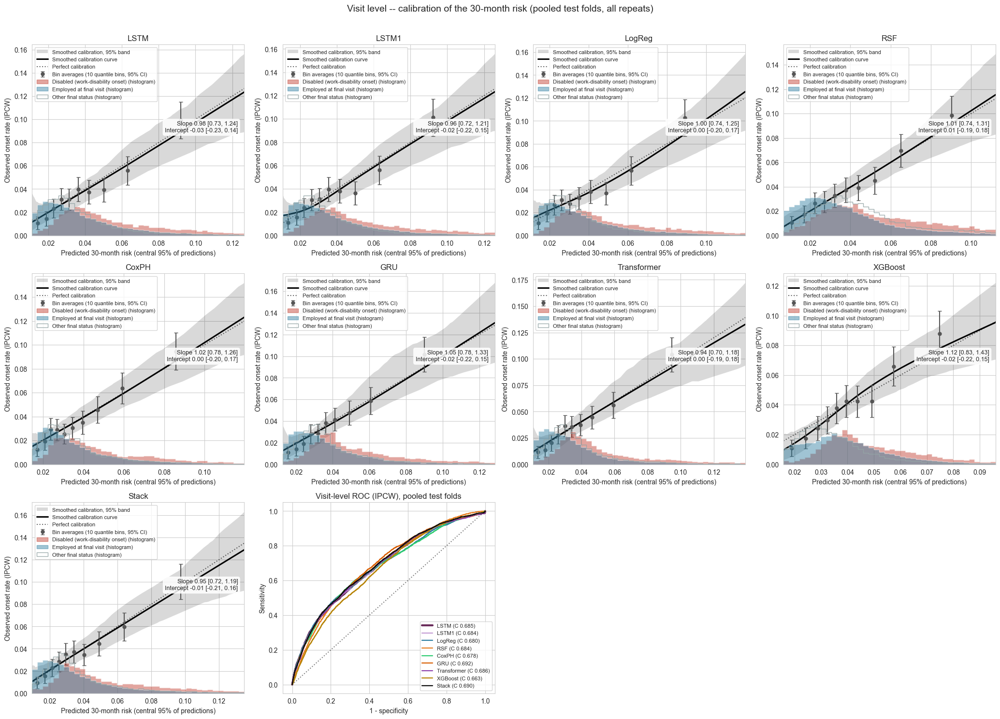

In [47]:
"""Visit-level calibration of every model (one panel each: IPCW deciles of the pooled out-of-fold 30-month risk, all
repeats stacked, with the slope and intercept of its table) and the IPCW ROC curves of all models."""
_ms = list(MODEL_RESULTS)
_ncols = 4
_nrows = int(np.ceil((len(_ms) + 1) / _ncols))
fig, axes = plt.subplots(_nrows, _ncols, figsize=(5.2 * _ncols, 4.9 * _nrows))
axes = axes.ravel()
for ax, m in zip(axes, _ms):
    plot_calibration(ax, m, MODEL_RESULTS[m]["preds"], "visit", MODEL_RESULTS[m]["visit_table"], title=m)
ax = axes[len(_ms)]
for m, r in MODEL_RESULTS.items():
    p, y, w = r["p"], r["y"], r["w"]
    k = w > 0
    fpr, tpr, _ = roc_curve(y[k], p[k], sample_weight=w[k])
    ax.plot(fpr, tpr, color=CV_COLORS[m], lw=3 if m == "LSTM" else 1.6,
            label=f"{m} (C {r['visit_table'].loc['c_index', 'Value']:.3f})")
ax.plot([0, 1], [0, 1], "k:", alpha=0.5)
ax.set_xlabel("1 - specificity"); ax.set_ylabel("Sensitivity")
ax.set_title("Visit-level ROC (IPCW), pooled test folds"); ax.legend(fontsize=8, loc="lower right")
for ax in axes[len(_ms) + 1:]:
    ax.set_visible(False)
plt.suptitle("Visit level -- calibration of the 30-month risk (pooled test folds, all repeats)", y=1.01, fontsize=14)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_calibration_visit_all.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()


## 11.16.1 Full model specification and model availability

TRIPOD+AI item 22: the competing-risk LogReg written out in full (coefficients, baseline hazards,
preprocessing constants and recalibration), and every final all-data refit saved to `final_models_revised_v16/`.

In [48]:
"""
Full model specification and model availability (TRIPOD+AI items 22 and 18).

The competing-risk LogReg is written out in full: for every design term, its log-odds of each cause (work disability,
other exit, death) against 'no event' in a 3-month interval, from the final all-data refit; the interval terms are
the baseline hazards. The coefficients are the averages over the M_IMPUTATIONS per-imputation fits (Rubin's point estimates; they share
one spline basis). With the preprocessing constants (signed log1p, mean, SD, clipping at +-5 SD) anyone can
compute the 30-month cumulative incidence by hand, for a patient with complete data (missing values need the saved
imputation models; the notebook's own predictions average the per-imputation risks, which differs very slightly): per interval k, softmax over the four classes, then
CIF(30 mo) = sum_k S(k-1) h_1(k). The raw risk is then recalibrated (Section 7) with the intercept and slope below.
The Cox model's hazard ratios are in Section 11.12. Tree ensembles and neural networks cannot be written as an
equation, so every final refit is saved (tabular models pickled; sequence models as PyTorch state dicts + their
configuration and scaler).
"""
FINAL_MODEL_DIR = "final_models_revised_v16"
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)


def logreg_specification(fr):
    prep = fr["prep"]
    m = fr["fitted"].models[0]                                  # names and the shared spline basis
    kept = [c for i, c in enumerate(m.cols) if i not in m.spl_idx]
    spl_names = list(m.spl.get_feature_names_out([m.cols[i] for i in m.spl_idx])) if m.spl is not None else []
    names = ([DISPLAY_NAMES.get(c, c) for c in kept] + spl_names
             + [f"Interval {k * INTERVAL_MONTHS}-{(k + 1) * INTERVAL_MONTHS} mo (baseline)" for k in range(N_INTERVALS)])
    coef = np.zeros((N_CLASSES, len(names)))
    icpt = np.zeros(N_CLASSES)
    for mk in fr["fitted"].models:                              # Rubin's point estimate: the mean over imputations
        coef[mk.m.classes_.astype(int)] += mk.m.coef_ / len(fr["fitted"].models)
        icpt[mk.m.classes_.astype(int)] += mk.m.intercept_ / len(fr["fitted"].models)
    tab = pd.DataFrame({CAUSE_NAMES[c]: coef[c] - coef[0] for c in range(1, N_CLASSES)}, index=names)
    tab.loc["(Intercept)"] = [icpt[c] - icpt[0] for c in range(1, N_CLASSES)]
    tab.index.name = "Design term (standardised scale)"
    pre = pd.DataFrame({"Signed log1p": [j in prep.log_idx for j in range(len(prep.cols))],
                        "Mean": prep.sc.mean_, "SD": prep.sc.scale_},
                       index=[DISPLAY_NAMES.get(c, c) for c in prep.cols])
    pre.index.name = "Variable (in model order)"
    return tab, pre


if res_logreg is not None and "final" in res_logreg:
    logreg_coef, logreg_prep = logreg_specification(res_logreg["final"])
    cal = res_logreg["final"]["cal"]
    print("Competing-risk LogReg, final all-data refit: log-odds vs 'no event' per 3-month interval "
          "(standardised predictors)")
    display(logreg_coef.round(4))
    print("Preprocessing constants (fitted on all landmarks), in the order of the model's columns:")
    display(logreg_prep.round(4))
    print(f"30-month recalibration: calibrated risk = expit({cal.a:.4f} + {cal.b:.4f} * (logit(raw) - ({cal.mu:.4f})) "
          f"/ {cal.sd:.4f})")
    logreg_coef.to_csv(f"{FINAL_MODEL_DIR}/logreg_coefficients_model_revised_v16.csv")
    logreg_prep.to_csv(f"{FINAL_MODEL_DIR}/logreg_preprocessing_model_revised_v16.csv")

for m, r in MODEL_RESULTS.items():
    fr = r.get("final")
    if fr is None:
        continue
    if m in SEQ_FITTERS:
        torch.save({"state_dicts": [net.state_dict() for net in fr["fitted"]],
                    "config": seq_cfg(m, max(set(v["best"] for k, v in cv_state["folds"].items() if k[0] == m),
                                             key=[v["best"] for k, v in cv_state["folds"].items() if k[0] == m].count)),
                    "inputs": fr["prep"].cols, "scaler": fr["ctx"]["seq_prep"], "calibrator": fr["cal"]},
                   f"{FINAL_MODEL_DIR}/{m}_final_model_revised_v16.pt")
    else:
        with open(f"{FINAL_MODEL_DIR}/{m}_final_model_revised_v16.pkl", "wb") as f:
            pickle.dump({"model": fr["fitted"], "preprocessing": fr["prep"], "calibrator": fr["cal"],
                         "features": fr["ctx"]["features"]}, f)
print(f"\nFinal refits saved in {FINAL_MODEL_DIR}/: {sorted(os.listdir(FINAL_MODEL_DIR))}")
print("Code and model availability: the analysis code (this notebook and its build scripts) and the trained models "
      "will be available at [repository link to be added].")

Competing-risk LogReg, final all-data refit: log-odds vs 'no event' per 3-month interval (standardised predictors)


,work disability,other exit,death
Design term (standardised scale),,,
Age,0.1452,-0.1432,0.0006
Education: not recorded,-0.0369,0.7083,0.2238
Years since first employed visit,-0.3322,-0.2591,-0.1971
Adjusted mean SLEDAI-2K,0.0960,-0.0243,0.0239
LLDAS (no physician global),-0.1479,-0.0408,-0.0629
Steroid dose (mg/day),0.1637,0.0827,0.0821
"Acute visit (pulse, steroid increase or new immunosuppressant)",0.0530,-0.0381,0.0050
EULAR treatment step (0-4),0.1263,-0.0148,0.0372
Dyspnoea,0.2046,0.0360,0.0802


Preprocessing constants (fitted on all landmarks), in the order of the model's columns:


,Signed log1p,Mean,SD
Variable (in model order),,,
Age,False,41.7698,10.6294
Education: not recorded,False,0.1240,0.3296
Years since first employed visit,True,1.6334,0.8834
Adjusted mean SLEDAI-2K,True,1.4940,0.6062
LLDAS (no physician global),False,0.5471,0.4978
Steroid dose (mg/day),True,0.9869,1.1670
"Acute visit (pulse, steroid increase or new immunosuppressant)",False,0.1085,0.3111
EULAR treatment step (0-4),False,1.7376,1.0298
Dyspnoea,False,0.0286,0.1667


30-month recalibration: calibrated risk = expit(-3.4159 + 0.6728 * (logit(raw) - (-2.8210)) / 0.9237)

Final refits saved in final_models_revised_v16/: ['CoxPH_final_model_revised_v16.pkl', 'GRU_final_model_revised_v16.pt', 'LSTM1_final_model_revised_v16.pt', 'LSTM_final_model_revised_v16.pt', 'LogReg_final_model_revised_v16.pkl', 'RSF_final_model_revised_v16.pkl', 'Transformer_final_model_revised_v16.pt', 'XGBoost_final_model_revised_v16.pkl', 'logreg_coefficients_model_revised_v16.csv', 'logreg_preprocessing_model_revised_v16.csv']
Code and model availability: the analysis code (this notebook and its build scripts) and the trained models will be available at [repository link to be added].


## 11.17 Visit-level performance by horizon (6–48 months) — all models

Discrimination and calibration at every horizon from the same cross-validation (the hazard head gives all horizons
from one fit). These are validated, out-of-fold numbers. The selected LSTM's visit- and patient-level metrics by
horizon, with bootstrap CIs and alarm thresholds per horizon, are in Section 11.9.2.

LSTM -- performance by horizon, pooled test folds (mean (SD) over repeats)


,Onset rate (IPCW),AUROC,Brier,Cal. slope,Cal. intercept
Horizon (mo),,,,,
6,0.008004,0.713 (0.004),0.008 (0.000),0.992 (0.055),-0.034 (0.021)
12,0.017732,0.704 (0.003),0.017 (0.000),0.968 (0.043),-0.018 (0.026)
18,0.026491,0.688 (0.004),0.025 (0.000),0.976 (0.049),-0.025 (0.025)
24,0.034212,0.685 (0.003),0.032 (0.000),0.985 (0.045),-0.029 (0.022)
30,0.041334,0.685 (0.003),0.039 (0.000),0.980 (0.046),-0.030 (0.019)
36,0.047370,0.685 (0.003),0.044 (0.000),0.990 (0.049),-0.034 (0.020)
42,0.053922,0.683 (0.003),0.050 (0.000),1.003 (0.049),-0.041 (0.017)
48,0.060484,0.677 (0.004),0.055 (0.000),0.998 (0.051),-0.040 (0.018)


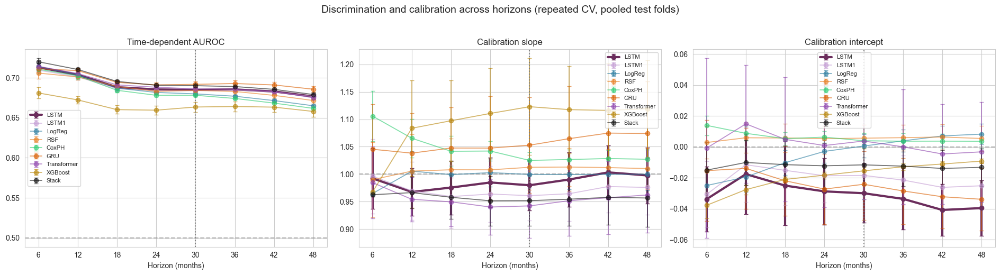

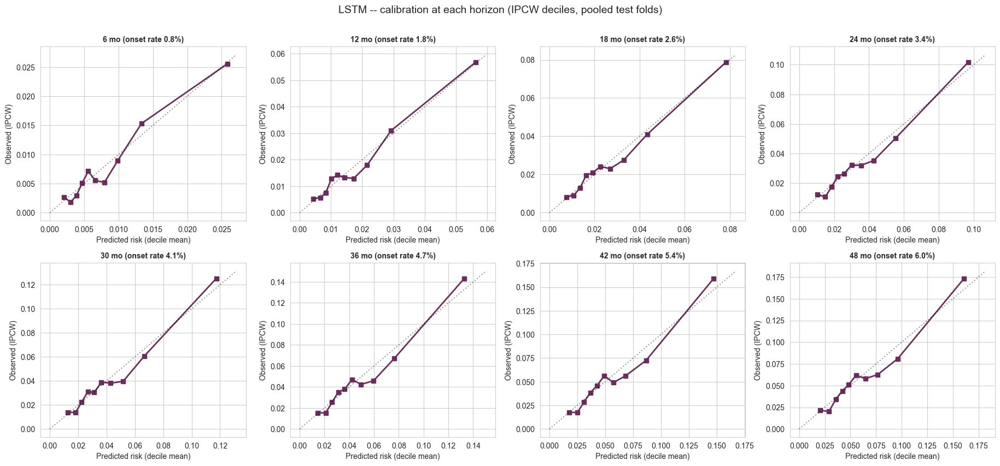

In [49]:
"""
LSTM multi-horizon performance (6-48 months) -- from the SAME repeated CV.

The discrete-time hazard head gives the risk of onset by every horizon from one fit, and each horizon has its own
recalibration learned inside the training folds. So
these are validated, out-of-fold numbers: time-dependent IPCW AUROC, Brier score, calibration slope and intercept per
horizon, mean (SD) over repeats, and a reliability plot per horizon.
"""
HZ_MODEL = "LSTM" if res_lstm is not None else next(iter(MODEL_RESULTS))
d = MODEL_RESULTS[HZ_MODEL]["res_df"]
rows = []
for h in EVAL_HORIZONS_MONTHS:
    yh, wh = IPCW[h]
    rows.append({"Horizon (mo)": h, "Onset rate (IPCW)": float(np.average(yh[wh > 0], weights=wh[wh > 0])),
                 **{lab: _fmt(d[f"{c}_{h}"]) for c, lab in [("td_auroc", "AUROC"), ("brier", "Brier"),
                                                            ("cal_slope", "Cal. slope"),
                                                            ("cal_intercept", "Cal. intercept")]}})
horizon_df = pd.DataFrame(rows).set_index("Horizon (mo)")
print(f"{HZ_MODEL} -- performance by horizon, pooled test folds (mean (SD) over repeats)")
display(horizon_df)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (c, lab, ideal) in zip(axes, [("td_auroc", "Time-dependent AUROC", 0.5), ("cal_slope", "Calibration slope", 1.0),
                                      ("cal_intercept", "Calibration intercept", 0.0)]):
    for m, r in MODEL_RESULTS.items():
        dd = r["res_df"]
        mu = [dd[f"{c}_{h}"].mean() for h in EVAL_HORIZONS_MONTHS]
        sd = [dd[f"{c}_{h}"].std() if len(dd) > 1 else 0 for h in EVAL_HORIZONS_MONTHS]
        ax.errorbar(EVAL_HORIZONS_MONTHS, mu, yerr=sd, color=CV_COLORS[m], marker="o", capsize=3,
                    lw=3 if m == HZ_MODEL else 1.3, alpha=1 if m == HZ_MODEL else 0.6, label=m)
    ax.axhline(ideal, color="gray", ls="--", alpha=0.6)
    ax.axvline(PRIMARY_HORIZON_MONTHS, color="gray", ls=":")
    ax.set_xticks(EVAL_HORIZONS_MONTHS); ax.set_xlabel("Horizon (months)"); ax.set_title(lab)
    ax.legend(fontsize=8)
plt.suptitle("Discrimination and calibration across horizons (repeated CV, pooled test folds)", y=1.03, fontsize=14)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_horizons.png", dpi=150, bbox_inches="tight"); plt.show(); plt.close()

ncols = 4
nrows = int(np.ceil(len(EVAL_HORIZONS_MONTHS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.2 * nrows))
for ax, (j, h) in zip(axes.ravel(), enumerate(EVAL_HORIZONS_MONTHS)):
    p, y, w, _, _ = stacked(HZ_MODEL, MODEL_RESULTS[HZ_MODEL]["preds"], col=j, horizon=h)
    k = w > 0
    b = pd.qcut(p[k], 10, labels=False, duplicates="drop")
    cd = pd.DataFrame({"pw": p[k] * w[k], "yw": y[k] * w[k], "w": w[k], "b": b}).groupby("b").sum()
    hi = float(max((cd["pw"] / cd["w"]).max(), (cd["yw"] / cd["w"]).max())) * 1.05
    ax.plot(cd["pw"] / cd["w"], cd["yw"] / cd["w"], "s-", color=CV_COLORS[HZ_MODEL], lw=2)
    ax.plot([0, hi], [0, hi], "k:", alpha=0.4)
    ax.set_title(f"{h} mo (onset rate {np.average(y[k], weights=w[k]):.1%})", fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted risk (decile mean)"); ax.set_ylabel("Observed (IPCW)")
for ax in axes.ravel()[len(EVAL_HORIZONS_MONTHS):]:
    ax.set_visible(False)
plt.suptitle(f"{HZ_MODEL} -- calibration at each horizon (IPCW deciles, pooled test folds)", y=1.01, fontsize=14)
plt.tight_layout(); plt.show(); plt.close()

## 11.17.1 Cause-specific survival evaluation and the signal test (LSTM vs baseline)

Work disability as the event, other exits censored (the sequence models' estimand), follow-up truncated at 48 months.
In every outer fold `scikit-survival` takes the censoring distribution from the **training** fold and scores the
test fold: time-dependent AUROC at 12, 24 and 30 months, Uno's C truncated at 30 months, and the IPCW Brier score and
integrated Brier score for the models whose raw output is a cause-specific probability. The raw (uncalibrated)
30-month risk is compared with the Kaplan–Meier observed risk by decile.

**Signal test.** A baseline without the sequence (a linear discrete-time hazard on age, time since diagnosis, education,
race and calendar year) is run on the same folds. ΔAUROC(t) = LSTM − baseline, with a 95 % patient-cluster bootstrap CI and a paired
permutation null: within each patient, the two models' predictions are swapped at random, which is the null of no
difference between the models.

Resuming from cv_state_model_revised_v16.pkl: 320 model-fold fits already done.
CV for ['Baseline']: 0.0 min this call; 320 model-fold fits in cv_state_model_revised_v16.pkl.
Cause-specific survival metrics of the RAW risks (work disability; other exits censored; sksurv, censoring distribution from each training fold), mean (SD) over repeats:


,Repeats,AUROC 12 mo,AUROC 24 mo,AUROC 30 mo,Uno C (30 mo),Brier 12 mo,Brier 24 mo,Brier 30 mo,Integrated Brier (6-48 mo)
Model,,,,,,,,,
Baseline,5,0.632 (0.004),0.642 (0.003),0.643 (0.003),0.655 (0.003),0.023 (0.000),0.041 (0.000),0.049 (0.000),0.043 (0.000)
LSTM,5,0.706 (0.004),0.688 (0.005),0.687 (0.005),0.694 (0.005),0.021 (0.000),0.039 (0.000),0.046 (0.000),0.041 (0.000)
LSTM1,5,0.703 (0.004),0.686 (0.005),0.686 (0.004),0.693 (0.004),0.022 (0.000),0.040 (0.000),0.047 (0.000),0.042 (0.000)
LogReg,5,0.706 (0.003),0.685 (0.002),0.683 (0.003),0.689 (0.003),n/a,n/a,n/a,n/a
RSF,5,0.706 (0.003),0.691 (0.004),0.693 (0.004),0.691 (0.004),n/a,n/a,n/a,n/a
CoxPH,5,0.706 (0.001),0.682 (0.002),0.681 (0.002),0.686 (0.002),0.019 (0.000),0.036 (0.000),0.044 (0.000),0.039 (0.000)
GRU,5,0.712 (0.004),0.696 (0.003),0.696 (0.004),0.702 (0.004),0.021 (0.000),0.039 (0.000),0.047 (0.000),0.041 (0.000)
Transformer,5,0.709 (0.004),0.694 (0.002),0.692 (0.002),0.698 (0.002),0.021 (0.000),0.038 (0.000),0.045 (0.000),0.040 (0.000)
XGBoost,5,0.677 (0.007),0.665 (0.008),0.668 (0.008),0.675 (0.008),n/a,n/a,n/a,n/a


Check: weighted-form LSTM AUROC(t) vs sksurv cumulative_dynamic_auc, fold means: 12 mo 0.7056 vs 0.7056, 24 mo 0.6882 vs 0.6882, 30 mo 0.6874 vs 0.6874

SIGNAL TEST -- LSTM vs Baseline (age_at_record, EDU_HIGHER, EDU_MISSING, CAL_YEAR, CAL_YEAR_NL), identical folds, 5 repeat(s); 1000 bootstrap resamples, 1000 permutations:


,AUROC Baseline,AUROC LSTM,Delta AUROC (LSTM - Baseline),95% CI (patient bootstrap),"Permutation null, 95% range",p (paired permutation)
Horizon (mo),,,,,,
12,0.6321,0.7056,0.0735,"[0.030, 0.117]","[-0.047, 0.049]",0.0050
24,0.6423,0.6882,0.0459,"[0.004, 0.089]","[-0.043, 0.045]",0.0400
30,0.6430,0.6874,0.0444,"[0.005, 0.089]","[-0.044, 0.046]",0.0509


Covariate-adjusted IPCW (censoring or competing exit modelled on the variables, fitted on each training fold): 12 mo: LSTM 0.711, Baseline 0.647, Delta +0.065, 24 mo: LSTM 0.697, Baseline 0.660, Delta +0.037, 30 mo: LSTM 0.697, Baseline 0.660, Delta +0.037


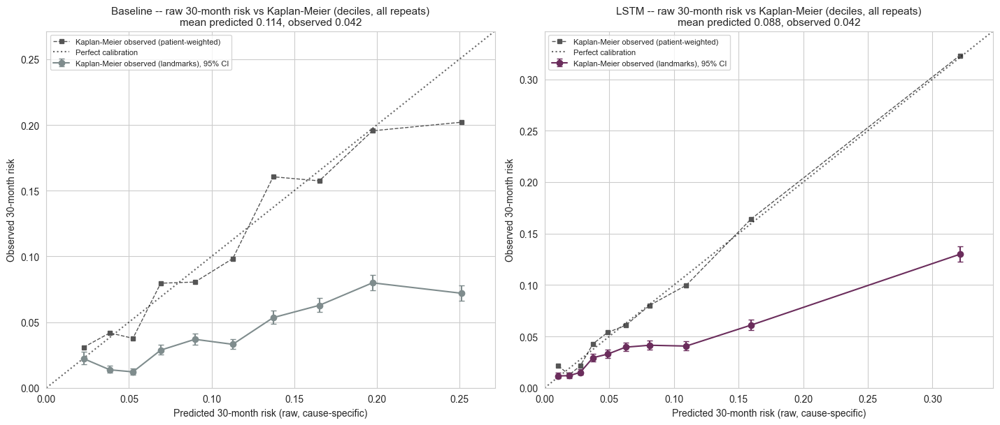

In [50]:
"""
Cause-specific survival evaluation of the RAW risks, and the paired signal test (LSTM vs Baseline).

Per outer fold (training fold -> censoring distribution; test fold -> metrics), with sksurv:
  cumulative_dynamic_auc   time-dependent AUROC at SURV_EVAL_TIMES_MONTHS
  concordance_index_ipcw   Uno's C truncated at 30 months
  brier_score, integrated_brier_score   at SURV_EVAL_TIMES_MONTHS and over 6-48 months (CS_PROB_MODELS only)
Fold metrics are averaged within a repeat; the table gives mean (SD) over repeats. The RSF's raw output is a score and
the LogReg's a cumulative incidence, so they get discrimination only.
Delta AUROC(t): the same IPCW AUROC in weighted form (cases 1 / G(T), controls followed past t; G = Kaplan-Meier of
the training fold, as in sksurv), so a patient-cluster bootstrap is a reweighting. Permutation null: within-fold
percentile ranks of the two models, swapped per patient with probability 1/2.
"""
from sksurv.metrics import cumulative_dynamic_auc, concordance_index_ipcw, brier_score, integrated_brier_score
from scipy.stats import rankdata

cv_state = run_repeated_cv(models=["Baseline"])          # identical folds, same checkpoint as the other models
SURV_CAP_DAYS = MAX_HORIZON_DAYS + 1
SURV_T_DAYS = [round(h * MONTH_DAYS) for h in SURV_EVAL_TIMES_MONTHS]
SURV_T_COLS = [EVAL_HORIZONS_MONTHS.index(h) for h in SURV_EVAL_TIMES_MONTHS]
CS_PROB_MODELS = ["Baseline", "CoxPH", "GRU", "LSTM", "LSTM1", "Transformer"]      # raw output = 1 - S_1(t)
SURV_MODELS = ["Baseline"] + [m for m in CV_MODELS if any(k[0] == m for k in cv_state["folds"])]


def surv_y(idx, event=None):
    """sksurv (event, time) array for rows idx: `event` (default work disability; anything else censored), follow-up
    truncated at 48 months."""
    event = E_ALL if event is None else event
    t = T_ALL[idx]
    e = (event[idx] == 1) & (t <= MAX_HORIZON_DAYS)
    return np.array(list(zip(e, np.minimum(t, SURV_CAP_DAYS))), dtype=[("event", bool), ("time", float)])


def fold_surv_metrics(f, raw, prob, event=None):
    ytr, yte = surv_y(f["tr"], event), surv_y(f["te"], event)
    auc, _ = cumulative_dynamic_auc(ytr, yte, raw[:, SURV_T_COLS], SURV_T_DAYS)
    out = {f"AUROC {h} mo": a for h, a in zip(SURV_EVAL_TIMES_MONTHS, auc)}
    out[f"Uno C ({PRIMARY_HORIZON_MONTHS} mo)"] = concordance_index_ipcw(ytr, yte, raw[:, PRIMARY_COL],
                                                                           tau=HORIZON_DAYS)[0]
    if prob:
        S = np.clip(1.0 - raw, 0.0, 1.0)
        bs = brier_score(ytr, yte, S[:, SURV_T_COLS], SURV_T_DAYS)[1]
        out.update({f"Brier {h} mo": v for h, v in zip(SURV_EVAL_TIMES_MONTHS, bs)})
        out["Integrated Brier (6-48 mo)"] = integrated_brier_score(ytr, yte, S, HORIZON_DAYS_GRID)
    return out


def model_folds(m):
    return {(r, k): v for (mm, r, k), v in cv_state["folds"].items() if mm == m}


def summarise_models(df, models, cols):
    rows = []
    for m in models:
        d = df[df["model"] == m]
        if len(d):
            rows.append({"Model": m, "Repeats": len(d), **{c: _fmt(d[c]) for c in cols}})
    return pd.DataFrame(rows).set_index("Model")


surv_folds = pd.DataFrame([{"model": m, "repeat": r, "fold": k, **fold_surv_metrics(f, f["raw"], m in CS_PROB_MODELS)}
                           for m in SURV_MODELS for (r, k), f in sorted(model_folds(m).items())])
surv_rep = surv_folds.groupby(["model", "repeat"]).mean(numeric_only=True).drop(columns="fold").reset_index()
surv_cols = [c for c in surv_rep.columns if c not in ("model", "repeat")]
surv_table = summarise_models(surv_rep, SURV_MODELS, surv_cols)
print("Cause-specific survival metrics of the RAW risks (work disability; other exits censored; sksurv, censoring "
      "distribution from each training fold), mean (SD) over repeats:")
display(surv_table)
surv_rep.to_csv("survival_metrics_by_repeat_model_revised_v16.csv", index=False)


# ------------------------------------------------------------------------------------------------ paired signal test
def _fold_entries(m_a="LSTM", m_b="Baseline"):
    """Per fold of both models: test rows, the two models' AUROC-at-t arrays (labels, weights) and scores."""
    fa, fb = model_folds(m_a), model_folds(m_b)
    out = []
    for key in sorted(set(fa) & set(fb)):
        a, b = fa[key], fb[key]
        assert np.array_equal(a["te"], b["te"]), "the two models must share their folds"
        tr, te = a["tr"], a["te"]
        G = CensoringKM(np.minimum(T_ALL[tr], SURV_CAP_DAYS), surv_y(tr)["event"].astype(int))
        cm = CensoringModel(censor_causes=(0, 2, 3)).fit(tr) if CENSORING_IPCW_ON else None
        T = np.minimum(T_ALL[te], SURV_CAP_DAYS)
        e = surv_y(te)["event"]
        lab = []
        for t_d, col in zip(SURV_T_DAYS, SURV_T_COLS):
            case, ctrl = e & (T <= t_d), T > t_d
            w = np.zeros(len(te))
            w[case] = 1.0 / np.maximum(G.at(T[case]), IPCW_MIN_G)
            w[ctrl] = 1.0
            wc = None
            if cm is not None:                                             # covariate-adjusted censoring weights
                wc = np.zeros(len(te))
                wc[case] = 1.0 / np.maximum(cm.G_at_days(te[case], T[case], before=True), IPCW_MIN_G)
                wc[ctrl] = 1.0 / np.maximum(cm.G_at_days(te[ctrl], t_d), IPCW_MIN_G)
            lab.append((case.astype(int), w, wc, col))
        out.append({"key": key, "tr": tr, "te": te, "code": LAND_CODE[te], "lab": lab, "pa": a["raw"], "pb": b["raw"],
                    "ra": rankdata(a["raw"][:, PRIMARY_COL]), "rb": rankdata(b["raw"][:, PRIMARY_COL])})
    return out


def delta_auc(entries, cnt=None, flip=None, covariate=False):
    """(AUROC_a, AUROC_b) at each time, mean over the folds of a repeat, then over repeats. cnt: patient bootstrap
    multiplicities; flip: per-patient swap of the two models (on percentile ranks)."""
    res = {}
    for f in entries:
        m = 1.0 if cnt is None else cnt[f["code"]]
        vals = []
        for y, w, wc, col in f["lab"]:
            ww = (wc if covariate else w) * m
            sa, sb = f["pa"][:, col], f["pb"][:, col]
            if flip is not None:
                sa, sb = rankdata(sa), rankdata(sb)
                s = flip[f["code"]]
                sa, sb = np.where(s, sb, sa), np.where(s, sa, sb)
            vals.append((w_auroc(y, sa, ww), w_auroc(y, sb, ww)))
        res.setdefault(f["key"][0], []).append(vals)
    per_rep = np.array([np.nanmean(v, axis=0) for v in res.values()])     # (repeats, times, 2)
    return np.nanmean(per_rep, axis=0)


if all(model_folds(m) for m in ("LSTM", "Baseline")):
    entries = _fold_entries()
    obs = delta_auc(entries)
    sk = np.nanmean([cumulative_dynamic_auc(surv_y(f["tr"]), surv_y(f["te"]), f["pa"][:, SURV_T_COLS], SURV_T_DAYS)[0]
                     for f in entries], axis=0)
    print(f"Check: weighted-form LSTM AUROC(t) vs sksurv cumulative_dynamic_auc, fold means: "
          + ", ".join(f"{h} mo {a:.4f} vs {s:.4f}" for h, a, s in zip(SURV_EVAL_TIMES_MONTHS, obs[:, 0], sk)))
    n_pt = len(PT_CODE)
    rng = np.random.RandomState(SEED)
    boots = np.array([delta_auc(entries, cnt=np.bincount(rng.randint(0, n_pt, n_pt), minlength=n_pt).astype(float))
                      for _ in range(BOOT_N)])
    d_obs = obs[:, 0] - obs[:, 1]
    d_boot = boots[:, :, 0] - boots[:, :, 1]
    rng = np.random.RandomState(SEED + 1)
    perms = np.array([(lambda r: r[:, 0] - r[:, 1])(delta_auc(entries, flip=rng.rand(n_pt) < 0.5))
                      for _ in range(PERM_N)])
    p_perm = (1 + (np.abs(perms) >= np.abs(d_obs)[None, :] - 1e-12).sum(0)) / (1 + PERM_N)
    signal = pd.DataFrame({
        "Horizon (mo)": SURV_EVAL_TIMES_MONTHS, "AUROC Baseline": obs[:, 1], "AUROC LSTM": obs[:, 0],
        "Delta AUROC (LSTM - Baseline)": d_obs,
        "95% CI (patient bootstrap)": [f"[{lo:.3f}, {hi:.3f}]" for lo, hi in
                                       zip(np.nanpercentile(d_boot, 2.5, 0), np.nanpercentile(d_boot, 97.5, 0))],
        "Permutation null, 95% range": [f"[{lo:.3f}, {hi:.3f}]" for lo, hi in
                                        zip(np.percentile(perms, 2.5, 0), np.percentile(perms, 97.5, 0))],
        "p (paired permutation)": p_perm}).set_index("Horizon (mo)")
    print(f"\nSIGNAL TEST -- LSTM vs Baseline ({', '.join(BASELINE_COLS)}), identical folds, "
          f"{len({f['key'][0] for f in entries})} repeat(s); {BOOT_N} bootstrap resamples, "
          f"{PERM_N} permutations:")
    display(signal.round(4))
    if CENSORING_IPCW_ON:
        cov = delta_auc(entries, covariate=True)
        print("Covariate-adjusted IPCW (censoring or competing exit modelled on the variables, fitted on "
              "each training fold): " + ", ".join(f"{h} mo: LSTM {a:.3f}, Baseline {b:.3f}, Delta {a - b:+.3f}"
                                                for h, (a, b) in zip(SURV_EVAL_TIMES_MONTHS, cov)))
else:
    print("Signal test skipped: the LSTM or the Baseline has no completed folds.")


# ------------------------------------------------------------------------------------------------ calibration vs KM
def km_risk(t, e, w=None, at=HORIZON_DAYS):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kmf = KaplanMeierFitter().fit(t, e, weights=w)
    s = float(kmf.survival_function_at_times(at).iloc[0])
    lo, hi = kmf.confidence_interval_survival_function_.asof(at).values
    return 1 - s, 1 - hi, 1 - lo


cal_models = [m for m in ["Baseline", "LSTM"] if model_folds(m)]
fig, axes = plt.subplots(1, len(cal_models), figsize=(7.2 * len(cal_models), 6.2), squeeze=False)
for ax, m in zip(axes[0], cal_models):
    fs = model_folds(m)
    p = np.concatenate([f["raw"][:, PRIMARY_COL] for f in fs.values()])
    rows = np.concatenate([f["te"] for f in fs.values()])
    t, e = np.minimum(T_ALL[rows], SURV_CAP_DAYS), surv_y(rows)["event"].astype(int)
    wpt = land["pt_weight"].values[rows]
    q = pd.qcut(p, 10, labels=False, duplicates="drop")
    pts = []
    for g in range(int(q.max()) + 1):
        k = q == g
        obs_, lo, hi = km_risk(t[k], e[k])
        pts.append((p[k].mean(), obs_, lo, hi, km_risk(t[k], e[k], wpt[k])[0]))
    pts = np.array(pts)
    ax.errorbar(pts[:, 0], pts[:, 1], yerr=[pts[:, 1] - pts[:, 2], pts[:, 3] - pts[:, 1]], fmt="o-",
                color=CV_COLORS[m], capsize=3, label="Kaplan-Meier observed (landmarks), 95% CI")
    ax.plot(pts[:, 0], pts[:, 4], "s--", color="#555555", ms=4, lw=1, label="Kaplan-Meier observed (patient-weighted)")
    hi_ = float(np.nanmax(pts[:, [0, 3]])) * 1.08
    ax.plot([0, hi_], [0, hi_], "k:", alpha=0.6, label="Perfect calibration")
    o_all = km_risk(t, e)[0]
    ax.set_title(f"{m} -- raw 30-month risk vs Kaplan-Meier (deciles, all repeats)\n"
                 f"mean predicted {p.mean():.3f}, observed {o_all:.3f}", fontsize=11)
    ax.set_xlabel("Predicted 30-month risk (raw, cause-specific)"); ax.set_ylabel("Observed 30-month risk")
    ax.set_xlim(0, hi_); ax.set_ylim(0, hi_); ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_calibration_km_raw.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

## 11.17.2 Two-cause heads: work disability specifically, or leaving work for any reason?

The LSTM's second head estimates the cause-specific risk of an other exit; with the first it gives the risk of leaving
work for any reason. Each of the three risks is scored against each outcome (work disability, other exit, any exit from
work) with Uno's C and the time-dependent AUROC at 30 months, as in Section 11.17.1. A specific signal shows as the
disability head ranking work disability better than it ranks other exits. The any-exit row and column are the
composite-outcome sensitivity analysis.

In [51]:
"""
Two-cause heads -- work disability specifically vs leaving work for any reason (composite outcome), from the LSTM's
out-of-fold predictions (ctx["aux"] of every outer fold). Uno's C at 30 months and cumulative/dynamic AUROC at 30 months,
sksurv, censoring distribution from the training fold; the outcome's competing events are censored.
"""
lstm_folds = model_folds("LSTM") if "LSTM" in CV_MODELS else {}
if lstm_folds and all(f.get("aux") for f in lstm_folds.values()):
    OUTCOMES = {"Work disability": E_ALL, "Other exit": (C_ALL >= 2).astype(int),
                "Any exit from work (composite)": (C_ALL >= 1).astype(int)}
    RISKS = {"Disability head": lambda f: f["raw"], "Exit head": lambda f: f["aux"]["exit_raw"],
             "Any exit (both heads)": lambda f: f["aux"]["composite_raw"]}
    rows = []
    for (r, k), f in sorted(lstm_folds.items()):
        for rn, get in RISKS.items():
            raw = get(f)
            for on, ev in OUTCOMES.items():
                ytr, yte = surv_y(f["tr"], ev), surv_y(f["te"], ev)
                rows.append({"repeat": r, "fold": k, "risk": rn, "outcome": on,
                             "C": concordance_index_ipcw(ytr, yte, raw[:, PRIMARY_COL], tau=HORIZON_DAYS)[0],
                             "AUROC": cumulative_dynamic_auc(ytr, yte, raw[:, [PRIMARY_COL]], [HORIZON_DAYS])[0][0]})
    two = pd.DataFrame(rows).groupby(["risk", "outcome", "repeat"])[["C", "AUROC"]].mean().reset_index()
    for metric in ["C", "AUROC"]:
        tab = two.groupby(["risk", "outcome"])[metric].agg(_fmt).unstack("outcome")
        tab = tab.reindex(index=list(RISKS), columns=list(OUTCOMES))
        print(f"LSTM two-cause heads -- {'Uno C' if metric == 'C' else 'time-dependent AUROC'} at "
              f"{PRIMARY_HORIZON_MONTHS} months, rows = risk, columns = outcome, mean (SD) over repeats:")
        display(tab)
    m_ = two.groupby(["risk", "outcome"])["C"].mean()
    print(f"Disability head: C {m_[('Disability head', 'Work disability')]:.3f} for work disability vs "
          f"{m_[('Disability head', 'Other exit')]:.3f} for other exits; exit head: "
          f"{m_[('Exit head', 'Other exit')]:.3f} for other exits vs {m_[('Exit head', 'Work disability')]:.3f} for "
          f"work disability.")
else:
    print("Two-cause analysis skipped: the LSTM was run without the exit head (SEQ_CONFIG['exit_head']) or has no "
          "completed folds.")

LSTM two-cause heads -- Uno C at 30 months, rows = risk, columns = outcome, mean (SD) over repeats:


outcome,Work disability,Other exit,Any exit from work (composite)
risk,,,
Disability head,0.694 (0.005),0.534 (0.003),0.605 (0.002)
Exit head,0.587 (0.004),0.799 (0.006),0.705 (0.005)
Any exit (both heads),0.652 (0.003),0.774 (0.004),0.720 (0.003)


LSTM two-cause heads -- time-dependent AUROC at 30 months, rows = risk, columns = outcome, mean (SD) over repeats:


outcome,Work disability,Other exit,Any exit from work (composite)
risk,,,
Disability head,0.687 (0.005),0.522 (0.003),0.595 (0.003)
Exit head,0.582 (0.005),0.799 (0.006),0.702 (0.005)
Any exit (both heads),0.649 (0.003),0.775 (0.004),0.719 (0.003)


Disability head: C 0.694 for work disability vs 0.534 for other exits; exit head: 0.799 for other exits vs 0.587 for work disability.


## 11.18 Alarms by calendar era: era-standardised vs absolute threshold

Section 9.1. For every model, from the pooled test folds (no refitting), per calendar era of the landmark visit: the
onset rate, the mean predicted risk and observed / expected ratio, the within-era AUROC, and the alarm rate,
sensitivity and specificity with the **era-standardised** threshold (the alarms of every other table) and with the
**single absolute threshold** of revised_v11 (learned on the same training folds). With the absolute threshold the alarm
rate follows the era's onset rate; with the era-standardised threshold it should be similar across eras, with
sensitivity and specificity closer to those of the whole cohort.

Alarms by calendar era of the landmark visit, 30-month label (IPCW), mean over CV repeats. Alarms in every other table: era-standardised.


Landmarks  Onset rate  Mean risk    O/E  AUROC in era  \
Model       Era                                                              
LSTM        < 2000      1931.0       0.064      0.070  0.921         0.728   
            2000-05     2618.0       0.054      0.058  0.932         0.654   
            2006-11     3795.0       0.047      0.044  1.080         0.590   
            >= 2012     6040.0       0.025      0.026  0.943         0.657   
LSTM1       < 2000      1931.0       0.064      0.070  0.923         0.728   
            2000-05     2618.0       0.054      0.058  0.932         0.655   
            2006-11     3795.0       0.047      0.043  1.090         0.592   
            >= 2012     6040.0       0.025      0.025  0.973         0.652   
LogReg      < 2000      1931.0       0.064      0.066  0.977         0.736   
            2000-05     2618.0       0.054      0.055  0.976         0.662   
            2006-11     3795.0       0.047      0.042  1.118         0.572   
            >= 2012     6040.0       0.025      0.027  0.925         0.645   
RSF         < 2000      1931.0       0.064      0.063  1.017         0.716   
            2000-05     2618.0       0.054      0.056  0.961         0.653   
            2006-11     3795.0       0.047      0.043  1.109         0.595   
            >= 2012     6040.0       0.025      0.027  0.934         0.666   
CoxPH       < 2000      1931.0       0.064      0.063  1.022         0.735   
            2000-05     2618.0       0.054      0.054  1.004         0.658   
            2006-11     3795.0       0.047      0.041  1.162         0.577   
            >= 2012     6040.0       0.025      0.029  0.852         0.642   
GRU         < 2000      1931.0       0.064      0.070  0.917         0.741   
            2000-05     2618.0       0.054      0.058  0.937         0.638   
            2006-11     3795.0       0.047      0.042  1.114         0.627   
            >= 2012     6040.0       0.025      0.027  0.935         0.660   
Transformer < 2000      1931.0       0.064      0.072  0.900         0.730   
            2000-05     2618.0       0.054      0.057  0.947         0.647   
            2006-11     3795.0       0.047      0.041  1.142         0.622   
            >= 2012     6040.0       0.025      0.024  1.014         0.651   
XGBoost     < 2000      1931.0       0.064      0.055  1.165         0.706   
            2000-05     2618.0       0.054      0.052  1.049         0.627   
            2006-11     3795.0       0.047      0.044  1.063         0.570   
            >= 2012     6040.0       0.025      0.032  0.775         0.641   
Stack       < 2000      1931.0       0.064      0.071  0.910         0.739   
            2000-05     2618.0       0.054      0.059  0.924         0.661   
            2006-11     3795.0       0.047      0.042  1.118         0.597   
            >= 2012     6040.0       0.025      0.025  0.992         0.667   

                     Alarm rate (era-standardised)  \
Model       Era                                      
LSTM        < 2000                           0.490   
            2000-05                          0.450   
            2006-11                          0.411   
            >= 2012                          0.346   
LSTM1       < 2000                           0.486   
            2000-05                          0.443   
            2006-11                          0.398   
            >= 2012                          0.331   
LogReg      < 2000                           0.425   
            2000-05                          0.420   
            2006-11                          0.411   
            >= 2012                          0.371   
RSF         < 2000                           0.359   
            2000-05                          0.450   
            2006-11                          0.486   
            >= 2012                          0.334   
CoxPH       < 2000                           0.419   
            2000-05           

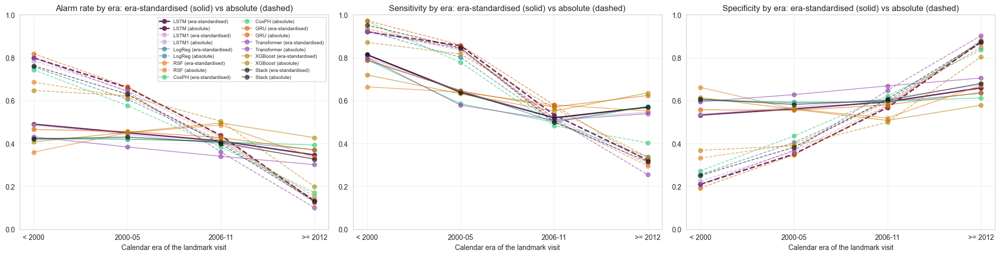

In [52]:
"""
Alarms by calendar era (Section 11.18), from the pooled test folds of every model: onset rate, mean risk, O/E,
within-era AUROC, and the alarm rate / sensitivity / specificity under the era-standardised and the absolute threshold,
IPCW-weighted (30-month label), mean over CV repeats.
"""
ERA_LABELS = [lab for *_, lab in ERA_BANDS]
ERA_OF_LAND = pd.cut(CAL_YEAR_ALL, [a for a, _, _ in ERA_BANDS] + [ERA_BANDS[-1][1]], right=False,
                     labels=ERA_LABELS).astype(str)
RULES = [("era-standardised", "target"), ("absolute", "absolute")]


def era_rows(model):
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    out = []
    for (m, r), pr in preds_all.items():
        if m != model:
            continue
        p = pr["P"][:, PRIMARY_COL]
        for lab in ERA_LABELS:
            k = (ERA_OF_LAND == lab) & (w > 0)
            yy, ww, pp = y[k], w[k], p[k]
            row = {"Model": model, "Era": lab, "repeat": r, "Landmarks": int(k.sum()),
                   "Onset rate": float(np.average(yy, weights=ww)), "Mean risk": float(np.average(pp, weights=ww)),
                   "O/E": float((ww * yy).sum() / (ww * pp).sum()), "AUROC in era": w_auroc(yy, pp, ww)}
            for rule, key in RULES:
                tp, fp, fn, tn = w_confusion(yy, (p >= pr["visit_thr"][key])[k], ww)
                row[f"Alarm rate ({rule})"] = (tp + fp) / max(tp + fp + fn + tn, 1e-12)
                row[f"Sensitivity ({rule})"] = tp / max(tp + fn, 1e-12)
                row[f"Specificity ({rule})"] = tn / max(tn + fp, 1e-12)
            out.append(row)
    return out


era_df = pd.DataFrame([row for m in MODEL_RESULTS for row in era_rows(m)])
if era_df.empty:
    print("Run the model sections first.")
else:
    era_tab = era_df.drop(columns="repeat").groupby(["Model", "Era"], sort=False).mean()
    era_tab.to_csv("alarms_by_era_revised_v16.csv")
    print(f"Alarms by calendar era of the landmark visit, {PRIMARY_HORIZON_MONTHS}-month label (IPCW), mean over CV "
          f"repeats. Alarms in every other table: {'era-standardised' if ERA_STANDARDISED_ALARMS else 'absolute'}.")
    display(era_tab.round(3))
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.2))
    xs = np.arange(len(ERA_LABELS))
    for ax, what in zip(axes, ["Alarm rate", "Sensitivity", "Specificity"]):
        for m in MODEL_RESULTS:
            d = era_tab.loc[m]
            for rule, _ in RULES:
                ax.plot(xs, d.loc[ERA_LABELS, f"{what} ({rule})"].values, marker="o", color=CV_COLORS.get(m),
                        ls="-" if rule == "era-standardised" else "--", lw=2 if m == "LSTM" else 1.2,
                        alpha=1 if m == "LSTM" else 0.6, label=f"{m} ({rule})")
        ax.set_xticks(xs); ax.set_xticklabels(ERA_LABELS); ax.set_xlabel("Calendar era of the landmark visit")
        ax.set_ylim(0, 1); ax.set_title(f"{what} by era: era-standardised (solid) vs absolute (dashed)"); ax.grid(alpha=0.3)
    axes[0].legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_alarms_by_era.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

## 11.18.1 Static vs longitudinal models by horizon and by history length

The static models (LogReg, Cox, RSF) see the current visit; the longitudinal models (LSTM, GRU, Transformer) read the
same variables over the patient's history. From the **same pooled out-of-fold risks** as the main tables:

1. **By horizon.** The IPCW AUROC of every model at 6, 12, …, 48 months, each horizon scored against its own
   competing-risk label (onset by that horizon; an earlier other exit is a resolved negative).
2. **By history length.** The 30-month AUROC in strata of the number of the patient's clinic visits before the
   landmark (about quintiles: 0–3, 4–9, 10–17, 18–30, ≥ 31).

ΔAUROC = sequence model − LogReg, paired on identical folds, averaged over the CV repeats; the 95 % CI comes from a
patient-cluster bootstrap (the same resample in every repeat). If the history carried information beyond the current
visit, ΔAUROC should be positive, especially at short horizons (a change heralding onset) and for patients with a long
history.

IPCW AUROC by horizon (competing-risk label 'onset by h'), mean over CV repeats:


,Type,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
LogReg,static,0.714,0.704,0.687,0.682,0.680,0.677,0.671,0.665
CoxPH,static,0.711,0.702,0.684,0.678,0.678,0.674,0.668,0.662
RSF,static,0.706,0.701,0.689,0.683,0.684,0.683,0.678,0.672
LSTM1,static,0.709,0.701,0.686,0.684,0.684,0.685,0.682,0.676
LSTM,longitudinal,0.713,0.704,0.688,0.685,0.685,0.685,0.683,0.677
GRU,longitudinal,0.711,0.709,0.694,0.691,0.692,0.693,0.691,0.686
Transformer,longitudinal,0.714,0.705,0.691,0.688,0.686,0.686,0.683,0.675



Delta AUROC vs LogReg by horizon (paired; 500 patient-bootstrap resamples):


Model,CoxPH,GRU,LSTM,LSTM1,RSF,Transformer
Horizon (mo),,,,,,
6,-0.003,-0.002,-0.001,-0.004,-0.008,0.001
12,-0.001,0.005,0.000,-0.003,-0.003,0.002
18,-0.003,0.007,0.001,-0.001,0.002,0.004
24,-0.004,0.009,0.004,0.002,0.001,0.007
30,-0.002,0.012,0.005,0.004,0.004,0.006
36,-0.003,0.016,0.008,0.008,0.006,0.009
42,-0.003,0.020,0.011,0.011,0.007,0.011
48,-0.003,0.021,0.012,0.011,0.007,0.010


Delta AUROC            95% CI  \
Model       Horizon (mo)                                  
LSTM        6                  -0.001  [-0.009, +0.009]   
            12                  0.000  [-0.007, +0.008]   
            18                  0.001  [-0.005, +0.008]   
            24                  0.004  [-0.003, +0.011]   
            30                  0.005  [-0.002, +0.013]   
            36                  0.008  [-0.001, +0.017]   
            42                  0.011  [+0.001, +0.022]   
            48                  0.012  [+0.001, +0.023]   
GRU         6                  -0.002  [-0.019, +0.015]   
            12                  0.005  [-0.011, +0.020]   
            18                  0.007  [-0.010, +0.024]   
            24                  0.009  [-0.009, +0.028]   
            30                  0.012  [-0.007, +0.030]   
            36                  0.016  [-0.004, +0.036]   
            42                  0.020  [-0.002, +0.041]   
            48                  0.021  [-0.001, +0.042]   
Transformer 6                   0.001  [-0.019, +0.019]   
            12                  0.002  [-0.014, +0.017]   
            18                  0.004  [-0.010, +0.019]   
            24                  0.007  [-0.008, +0.020]   
            30                  0.006  [-0.008, +0.021]   
            36                  0.009  [-0.007, +0.025]   
            42                  0.011  [-0.006, +0.029]   
            48                  0.010  [-0.008, +0.029]   

                          Share of resamples > 0  
Model       Horizon (mo)                          
LSTM        6                              0.422  
            12                             0.478  
            18                             0.640  
            24                             0.848  
            30                             0.904  
            36                             0.960  
            42                             0.982  
            48                             0.980  
GRU         6                              0.382  
            12                             0.736  
            18                             0.824  
            24                             0.864  
            30                             0.904  
            36                             0.932  
            42                             0.954  
            48                             0.958  
Transformer 6                              0.486  
            12                             0.564  
            18                             0.690  
            24                             0.794  
            30                             0.782  
            36                             0.848  
            42                             0.888  
            48                             0.854


30-month IPCW AUROC by the number of clinic visits before the landmark:


,Landmarks,Patients,Event patients,LogReg,CoxPH,RSF,LSTM1,LSTM,GRU,Transformer
Prior visits,,,,,,,,,,
0-3,2910,865,64,0.714,0.705,0.674,0.704,0.704,0.693,0.699
4-9,3536,741,39,0.717,0.700,0.682,0.719,0.723,0.727,0.722
10-17,3557,574,42,0.680,0.687,0.693,0.680,0.683,0.686,0.681
18-30,3660,413,38,0.676,0.672,0.686,0.682,0.677,0.678,0.682
>=31,3188,215,15,0.664,0.631,0.634,0.683,0.681,0.675,0.654


Delta AUROC vs LogReg at 30 months by history length:


Delta AUROC            95% CI  \
Model       Prior visits                                  
LSTM        0-3                -0.011  [-0.021, -0.002]   
            4-9                 0.006  [-0.007, +0.018]   
            10-17               0.003  [-0.013, +0.019]   
            18-30               0.001  [-0.013, +0.017]   
            >=31                0.017  [-0.012, +0.045]   
GRU         0-3                -0.021  [-0.042, +0.001]   
            4-9                 0.010  [-0.025, +0.044]   
            10-17               0.005  [-0.028, +0.042]   
            18-30               0.003  [-0.028, +0.027]   
            >=31                0.011  [-0.048, +0.063]   
Transformer 0-3                -0.015  [-0.032, +0.003]   
            4-9                 0.005  [-0.025, +0.031]   
            10-17               0.001  [-0.029, +0.034]   
            18-30               0.007  [-0.021, +0.032]   
            >=31               -0.010  [-0.078, +0.056]   

                          Share of resamples > 0  
Model       Prior visits                          
LSTM        0-3                            0.008  
            4-9                            0.804  
            10-17                          0.638  
            18-30                          0.592  
            >=31                           0.884  
GRU         0-3                            0.032  
            4-9                            0.714  
            10-17                          0.618  
            18-30                          0.578  
            >=31                           0.672  
Transformer 0-3                            0.060  
            4-9                            0.608  
            10-17                          0.530  
            18-30                          0.714  
            >=31                           0.392

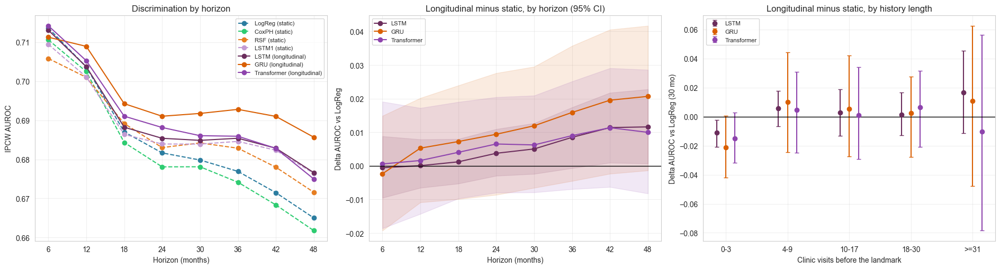

In [53]:
"""
Static vs longitudinal models, from the main CV state (no refitting): IPCW AUROC by horizon (6-48 mo) and by the number
of prior clinic visits (30 mo), with paired Delta AUROC (sequence model - LogReg) and patient-cluster bootstrap CIs.
"""
STATIC_MODELS = [m for m in ["LogReg", "CoxPH", "RSF", "LSTM1"] if m in CV_MODELS]
LONGITUDINAL_MODELS = [m for m in ["LSTM", "LogRegH", "GRU", "Transformer"] if m in CV_MODELS]
DELTA_REFERENCE = "LogReg"
N_BOOT_DELTA = 100 if SMOKE else 500
HISTORY_BINS = [0, 4, 10, 18, 31, np.inf]
HISTORY_LABELS = ["0-3", "4-9", "10-17", "18-30", ">=31"]


def fast_w_auc(y, p, w):
    """IPCW AUROC by the weighted Mann-Whitney statistic (ties count 1/2); equals roc_auc_score with weights."""
    k = w > 0
    y, p, w = y[k], p[k], w[k]
    if len(y) == 0 or y.min() == y.max():
        return np.nan
    o = np.argsort(p, kind="mergesort")
    p, y, w = p[o], y[o], w[o]
    _, start = np.unique(p, return_index=True)
    wp, wn = np.add.reduceat(w * (y == 1), start), np.add.reduceat(w * (y == 0), start)
    below = np.cumsum(wn) - wn
    return float((wp * (below + 0.5 * wn)).sum() / (wp.sum() * wn.sum()))


def oof_risks(model):
    """Pooled out-of-fold calibrated risks, one (n_landmarks, n_horizons) matrix per completed repeat."""
    out = {}
    for (m, r, k), v in cv_state["folds"].items():
        if m == model:
            out.setdefault(r, np.full((len(land), len(EVAL_HORIZONS_MONTHS)), np.nan))[v["te"]] = v["P"]
    return [out[r] for r in sorted(out) if not np.isnan(out[r][:, 0]).any()]


SL_MODELS = [m for m in STATIC_MODELS + LONGITUDINAL_MODELS if oof_risks(m)]
OOF = {m: oof_risks(m) for m in SL_MODELS}
N_PRIOR_VISITS = LAND_POS                                            # clinic visits before the landmark visit
HIST_STRATUM = pd.cut(N_PRIOR_VISITS, HISTORY_BINS, right=False, labels=HISTORY_LABELS).astype(str)
_rows_of = pd.Series(np.arange(len(land))).groupby(PID_ALL).apply(np.asarray)
_rng = np.random.default_rng(2026)
BOOT_ROWS = [np.concatenate(_rows_of.loc[_rng.choice(_rows_of.index.values, len(_rows_of))].values)
             for _ in range(N_BOOT_DELTA)]


def auc_mean(model, j, idx):
    y, w = IPCW[EVAL_HORIZONS_MONTHS[j]]
    return float(np.mean([fast_w_auc(y[idx], P[idx, j], w[idx]) for P in OOF[model]]))


def delta_ci(model, j, idx_of_boot, base_idx):
    """Delta AUROC (model - reference) at horizon column j on rows base_idx; CI over the bootstrap resamples."""
    y, w = IPCW[EVAL_HORIZONS_MONTHS[j]]
    n_rep = min(len(OOF[model]), len(OOF[DELTA_REFERENCE]))
    pairs = list(zip(OOF[model][:n_rep], OOF[DELTA_REFERENCE][:n_rep]))
    def d(idx):
        return np.mean([fast_w_auc(y[idx], A[idx, j], w[idx]) - fast_w_auc(y[idx], B[idx, j], w[idx]) for A, B in pairs])
    boots = np.array([d(idx_of_boot(b)) for b in BOOT_ROWS])
    lo, hi = np.nanpercentile(boots, [2.5, 97.5])
    return d(base_idx), lo, hi, float(np.nanmean(boots > 0))


if len(SL_MODELS) < 2 or DELTA_REFERENCE not in SL_MODELS:
    print("Static vs longitudinal comparison skipped: run the model sections first.")
else:
    ALL_ROWS = np.arange(len(land))
    # ---- 1. by horizon
    tab_h = pd.DataFrame({f"{h} mo": [auc_mean(m, j, ALL_ROWS) for m in SL_MODELS]
                          for j, h in enumerate(EVAL_HORIZONS_MONTHS)}, index=SL_MODELS)
    tab_h.insert(0, "Type", ["static" if m in STATIC_MODELS else "longitudinal" for m in SL_MODELS])
    print("IPCW AUROC by horizon (competing-risk label 'onset by h'), mean over CV repeats:")
    display(tab_h.round(3))
    drows, DELTA_H = [], {}
    for m in [x for x in LONGITUDINAL_MODELS + STATIC_MODELS if x in SL_MODELS and x != DELTA_REFERENCE]:
        for j, h in enumerate(EVAL_HORIZONS_MONTHS):
            d0, lo, hi, share = delta_ci(m, j, lambda b: b, ALL_ROWS)
            DELTA_H[(m, h)] = (d0, lo, hi)
            drows.append({"Model": m, "Horizon (mo)": h, "Delta AUROC": d0, "95% CI": f"[{lo:+.3f}, {hi:+.3f}]",
                          "Share of resamples > 0": share})
    delta_h = pd.DataFrame(drows)
    print(f"\nDelta AUROC vs {DELTA_REFERENCE} by horizon (paired; {N_BOOT_DELTA} patient-bootstrap resamples):")
    display(delta_h.pivot(index="Horizon (mo)", columns="Model", values="Delta AUROC").round(3))
    display(delta_h[delta_h["Model"].isin(LONGITUDINAL_MODELS)].set_index(["Model", "Horizon (mo)"]).round(3))

    # ---- 2. by history length (30 months)
    j30 = PRIMARY_COL
    hrows = []
    for lab in HISTORY_LABELS:
        idx = np.flatnonzero(HIST_STRATUM == lab)
        y, w = IPCW[PRIMARY_HORIZON_MONTHS]
        r = {"Prior visits": lab, "Landmarks": len(idx), "Patients": len(np.unique(PID_ALL[idx])),
             "Event patients": len(np.unique(PID_ALL[idx][(y[idx] == 1) & (w[idx] > 0)]))}
        r.update({m: auc_mean(m, j30, idx) for m in SL_MODELS})
        hrows.append(r)
    tab_hist = pd.DataFrame(hrows).set_index("Prior visits")
    print(f"\n{PRIMARY_HORIZON_MONTHS}-month IPCW AUROC by the number of clinic visits before the landmark:")
    display(tab_hist.round(3))
    hd, DELTA_HIST = [], {}
    in_stratum = {lab: HIST_STRATUM == lab for lab in HISTORY_LABELS}
    for m in [x for x in LONGITUDINAL_MODELS if x in SL_MODELS]:
        for lab in HISTORY_LABELS:
            mask = in_stratum[lab]
            d0, lo, hi, share = delta_ci(m, j30, lambda b, mask=mask: b[mask[b]], np.flatnonzero(mask))
            DELTA_HIST[(m, lab)] = (d0, lo, hi)
            hd.append({"Model": m, "Prior visits": lab, "Delta AUROC": d0, "95% CI": f"[{lo:+.3f}, {hi:+.3f}]",
                       "Share of resamples > 0": share})
    delta_hist = pd.DataFrame(hd)
    print(f"Delta AUROC vs {DELTA_REFERENCE} at {PRIMARY_HORIZON_MONTHS} months by history length:")
    display(delta_hist.set_index(["Model", "Prior visits"]).round(3))

    pd.concat([tab_h.assign(table="AUROC by horizon"), delta_h.assign(table="Delta by horizon"),
               tab_hist.reset_index().assign(table="AUROC by history"), delta_hist.assign(table="Delta by history")],
              ignore_index=False).to_csv("static_vs_longitudinal_revised_v16.csv")

    # ---- plots
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
    ax = axes[0]
    for m in SL_MODELS:
        ax.plot(EVAL_HORIZONS_MONTHS, tab_h.loc[m, [f"{h} mo" for h in EVAL_HORIZONS_MONTHS]].values, marker="o",
                ls="-" if m in LONGITUDINAL_MODELS else "--", color=CV_COLORS.get(m), label=f"{m} ({tab_h.loc[m, 'Type']})")
    ax.set_xlabel("Horizon (months)"); ax.set_ylabel("IPCW AUROC"); ax.set_xticks(EVAL_HORIZONS_MONTHS)
    ax.set_title("Discrimination by horizon"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax = axes[1]
    for m in [x for x in LONGITUDINAL_MODELS if x in SL_MODELS]:
        d = np.array([DELTA_H[(m, h)] for h in EVAL_HORIZONS_MONTHS])
        ax.plot(EVAL_HORIZONS_MONTHS, d[:, 0], marker="o", color=CV_COLORS.get(m), label=m)
        ax.fill_between(EVAL_HORIZONS_MONTHS, d[:, 1], d[:, 2], color=CV_COLORS.get(m), alpha=0.12)
    ax.axhline(0, color="k", lw=1); ax.set_xticks(EVAL_HORIZONS_MONTHS)
    ax.set_xlabel("Horizon (months)"); ax.set_ylabel(f"Delta AUROC vs {DELTA_REFERENCE}")
    ax.set_title("Longitudinal minus static, by horizon (95% CI)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax = axes[2]
    xs = np.arange(len(HISTORY_LABELS))
    for i_m, m in enumerate([x for x in LONGITUDINAL_MODELS if x in SL_MODELS]):
        d = np.array([DELTA_HIST[(m, lab)] for lab in HISTORY_LABELS])
        off = (i_m - 1) * 0.15
        ax.errorbar(xs + off, d[:, 0], yerr=[d[:, 0] - d[:, 1], d[:, 2] - d[:, 0]], fmt="o", capsize=3,
                    color=CV_COLORS.get(m), label=m)
    ax.axhline(0, color="k", lw=1); ax.set_xticks(xs); ax.set_xticklabels(HISTORY_LABELS)
    ax.set_xlabel("Clinic visits before the landmark"); ax.set_ylabel(f"Delta AUROC vs {DELTA_REFERENCE} ({PRIMARY_HORIZON_MONTHS} mo)")
    ax.set_title("Longitudinal minus static, by history length"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_static_vs_longitudinal.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

## 11.18.2 Is there signal in the trajectory? (engineered change variables)

A longitudinal model can only beat a static one if the course of the disease says something the current visit does
not. This screen asks that directly with hand-built trajectory variables: each is **added on its own to the
current-visit variables** in a simple logistic model of onset within 30 months (IPCW × $1/n_i$ weights, signed log1p,
median imputation and standardisation inside the training fold, the main CV folds), and the change in the
**out-of-fold IPCW AUROC** is reported (mean and range over the CV repeats). A nonlinear check (gradient boosting,
current-visit variables with and without all trajectory variables) follows.

**Descriptive only:** no model in this notebook uses these variables. Candidates cover disease activity (time-averaged
SLEDAI-2K, 12-month mean / peak / slope, change since the previous visit, flares), damage accrual, treatment course
(steroid change, time on steroids, mean dose since entry, acute visits and acute-care events over 1–2 years),
visit pattern (visit rate, gap relative to the patient's usual gap), symptom course (share of visits with each
symptom over 12 months and since entry, new onset, persistence, symptom burden and its change), laboratory and
weight change, and employment history (sick leave).

In [54]:
"""
Trajectory-signal screen: engineered change / trajectory variables added one at a time to the current-visit set, in a
simple IPCW-weighted logistic model of onset within 30 months, on the main CV folds. Descriptive; no model uses them.
"""
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

TRAJ_C = 0.05                                    # L2 strength of the screening model (fixed; not tuned)


def _roll(s, win, how):
    t = pd.DataFrame({"PTNO": visits["PTNO"].values, "ASSDT": visits["ASSDT"].values, "x": np.asarray(s, float)})
    r = t.set_index("ASSDT").groupby("PTNO", sort=False)["x"].rolling(win, min_periods=1)
    return pd.Series(getattr(r, how)().values, index=visits.index)


def build_trajectory_candidates(v):
    prev = lambda s: s.groupby(v["PTNO"]).shift(1)
    T = {}
    T["Adjusted mean SLEDAI-2K (since entry)"] = v["SLEDAI_AMS"]
    T["SLEDAI-2K change since previous visit"] = v["SLEDAI2_I"] - prev(v["SLEDAI2_I"])
    T["SLEDAI-2K slope, 12 mo"] = v["SLEDAI_SLOPE_1Y"]
    T["SLEDAI-2K peak, 12 mo"] = v["SLEDAI_MAX_1Y"]
    T["SLEDAI-2K mean, 12 mo"] = _roll(v["SLEDAI2_I"], "365D", "mean")
    T["SLEDAI-2K minus its 12-mo mean"] = v["SLEDAI2_I"] - T["SLEDAI-2K mean, 12 mo"]
    T["SLEDAI-2K flares, 12 mo"] = v["FLARES_1Y"]
    T["SDI accrual, 12 mo"] = v["score_n"] - _roll(v["score_n"], "365D", "min")
    T["SDI accrual, 24 mo"] = v["SDI_ACCRUAL_2Y"]
    T["Steroid change since previous visit"] = v["STEROID_DELTA"]
    T["Steroid change, 12 mo"] = v["STEROID_CHANGE_1Y"]
    T["Share of visits on steroids, 12 mo"] = v["PROP_ON_STEROID_1Y"]
    T["Mean steroid dose, 12 mo"] = _roll(v["STERAVER_0"], "365D", "mean")
    T["Mean steroid dose since entry"] = v["STEROID_MEAN_SINCE_ENTRY"]
    T["Acute-care events, 12 mo"] = v["ACUTE_CARE_1Y"]
    T["Acute visits, 24 mo"] = _roll(v["ACUTE_VISIT"], "730D", "sum")
    T["Clinic-visit rate, 12 mo"] = v["VISIT_RATE_1Y"]
    usual_gap = v["DAYS_SINCE_LAST_VISIT"].groupby(v["PTNO"]).transform(lambda s: s.expanding().median().shift(1))
    T["Visit gap / patient's usual gap"] = (v["DAYS_SINCE_LAST_VISIT"] / usual_gap).clip(0, 5)
    sym = {"FATIGUE": "Fatigue", "FIBROMYALGIA": "Fibromyalgia", "ARTHRALGIA": "Arthralgia", "DYSPNOEA": "Dyspnoea"}
    for c, nm in sym.items():
        x = v[c].fillna(0.0)
        T[f"{nm}: share of visits, 12 mo"] = _roll(x, "365D", "mean")
        T[f"{nm}: share of visits since entry"] = x.groupby(v["PTNO"]).transform(lambda s: s.expanding().mean())
        T[f"{nm}: new in the last 12 mo"] = _roll(((v[c] == 1) & (prev(v[c]) == 0)).astype(float), "365D", "max")
        T[f"{nm}: present at this and the previous visit"] = ((v[c] == 1) & (prev(v[c]) == 1)).astype(float)
    count = v[list(sym)].fillna(0.0).sum(1)
    T["Symptom burden, 12-mo mean count"] = _roll(count, "365D", "mean")
    T["Symptom count minus its 12-mo mean"] = count - T["Symptom burden, 12-mo mean count"]
    for c, nm in [("C3", "C3"), ("LOG_ESR", "ESR (log)"), ("LOG_SCR", "Creatinine (log)")]:
        T[f"{nm} minus its 12-mo mean"] = v[c] - _roll(v[c], "365D", "mean")
    wt = pd.to_numeric(v["WEIGHT"], errors="coerce").groupby(v["PTNO"]).ffill()
    T["Weight minus its 12-mo mean"] = wt - _roll(wt, "365D", "mean")
    T["Sick-leave episodes, 24 mo"] = v["SICK_EPISODES_2Y"]
    T["Prior sick-leave visits"] = v["PRIOR_SICK_LEAVE_VISITS"]
    T["Years since last sick leave"] = v["YRS_SINCE_SICK_LEAVE"]
    return pd.DataFrame(T)


TRAJ = build_trajectory_candidates(visits).iloc[land["visit_row"].values].reset_index(drop=True)
BASE_X = land[SELECTION_ALL["features"]].reset_index(drop=True).astype(float)   # the all-data LASSO selection
_y30, _w30 = IPCW[PRIMARY_HORIZON_MONTHS]
_fitw = _w30 * land["weight"].values
_res = _w30 > 0
_folds = [(r, tr, te) for r, k, tr, te in cv_make_folds()]
_n_rep = max(r for r, _, _ in _folds) + 1


def _prep(A, tr):
    A = np.sign(A) * np.log1p(np.abs(A))
    med = np.nanmedian(A[tr], 0)
    A = np.where(np.isnan(A), np.where(np.isnan(med), 0.0, med), A)
    mu, sd = A[tr].mean(0), A[tr].std(0) + 1e-9
    return np.clip((A - mu) / sd, -CLIP_Z, CLIP_Z)


def screen_auc(extra=(), learner="lr"):
    A = np.column_stack([BASE_X.values] + [TRAJ[c].values[:, None] for c in extra]).astype(float)
    P = np.full((_n_rep, len(land)), np.nan)
    for r, tr, te in _folds:
        k = tr[_res[tr]]
        if learner == "lr":
            Z = _prep(A, tr)
            m = LogisticRegression(C=TRAJ_C, max_iter=2000).fit(Z[k], _y30[k], sample_weight=_fitw[k] / _fitw[k].mean())
            P[r, te] = m.decision_function(Z[te])
        else:
            m = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.03, max_iter=300, min_samples_leaf=100,
                                               l2_regularization=1.0, random_state=r)
            m.fit(A[k], _y30[k], sample_weight=_fitw[k] / _fitw[k].mean())
            P[r, te] = m.predict_proba(A[te])[:, 1]
    return np.array([roc_auc_score(_y30[_res], P[r, _res], sample_weight=_w30[_res]) for r in range(_n_rep)])


_base = screen_auc()
print(f"Current-visit variables only ({BASE_X.shape[1]} columns, logistic screen): out-of-fold IPCW AUROC "
      f"{_base.mean():.3f} (repeats {', '.join(f'{a:.3f}' for a in _base)})")
_rows = []
for c in TRAJ.columns:
    d = screen_auc([c]) - _base
    _rows.append({"Trajectory variable": c, "Delta AUROC": d.mean(), "min over repeats": d.min(),
                  "max over repeats": d.max(), "missing at landmarks": TRAJ[c].isna().mean()})
traj_screen = pd.DataFrame(_rows).sort_values("Delta AUROC", ascending=False).set_index("Trajectory variable")
print("\nEach trajectory variable added on its own to the current-visit set (Delta = out-of-fold IPCW AUROC gain):")
display(traj_screen.round(4))
_all = screen_auc(list(TRAJ.columns)) - _base
print(f"All {TRAJ.shape[1]} trajectory variables together (logistic): Delta AUROC {_all.mean():+.4f} "
      f"(range {_all.min():+.4f} to {_all.max():+.4f})")
_gb0, _gb1 = screen_auc(learner="gb"), screen_auc(list(TRAJ.columns), learner="gb")
print(f"Gradient boosting (nonlinear check): current visit {_gb0.mean():.3f}; + all trajectory variables "
      f"{_gb1.mean():.3f} (Delta {np.mean(_gb1 - _gb0):+.4f})")
traj_screen.to_csv("trajectory_screen_revised_v16.csv")

Current-visit variables only (11 columns, logistic screen): out-of-fold IPCW AUROC 0.668 (repeats 0.667, 0.673, 0.668, 0.667, 0.667)

Each trajectory variable added on its own to the current-visit set (Delta = out-of-fold IPCW AUROC gain):


,Delta AUROC,min over repeats,max over repeats,missing at landmarks
Trajectory variable,,,,
"Symptom burden, 12-mo mean count",0.0236,0.0214,0.0248,0.0000
"Arthralgia: share of visits, 12 mo",0.0167,0.0149,0.0185,0.0000
Arthralgia: share of visits since entry,0.0142,0.0113,0.0155,0.0000
"Fibromyalgia: share of visits, 12 mo",0.0113,0.0091,0.0124,0.0000
Fibromyalgia: present at this and the previous visit,0.0080,0.0055,0.0093,0.0000
Fibromyalgia: new in the last 12 mo,0.0077,0.0048,0.0103,0.0000
Arthralgia: present at this and the previous visit,0.0074,0.0061,0.0088,0.0000
Dyspnoea: share of visits since entry,0.0062,0.0054,0.0068,0.0000
Fibromyalgia: share of visits since entry,0.0059,0.0043,0.0072,0.0000


All 43 trajectory variables together (logistic): Delta AUROC +0.0162 (range +0.0078 to +0.0232)
Gradient boosting (nonlinear check): current visit 0.673; + all trajectory variables 0.699 (Delta +0.0268)


## 11.19 SHAP explanations (LSTM and XGBoost)

SHAP attributions of the calibrated 30-month risk from the final all-data refits: the LSTM's to its current-visit
inputs, presented as a short constant employed trajectory; XGBoost's to the variables as recorded. The stack is
explained by its weights (Section 11.14.2) and the regression by its nomogram (Section 11.10.1).

Computing SHAP values for the LSTM (200 landmarks, 100 background)...


ExactExplainer explainer: 201it [00:55,  3.21it/s]                         


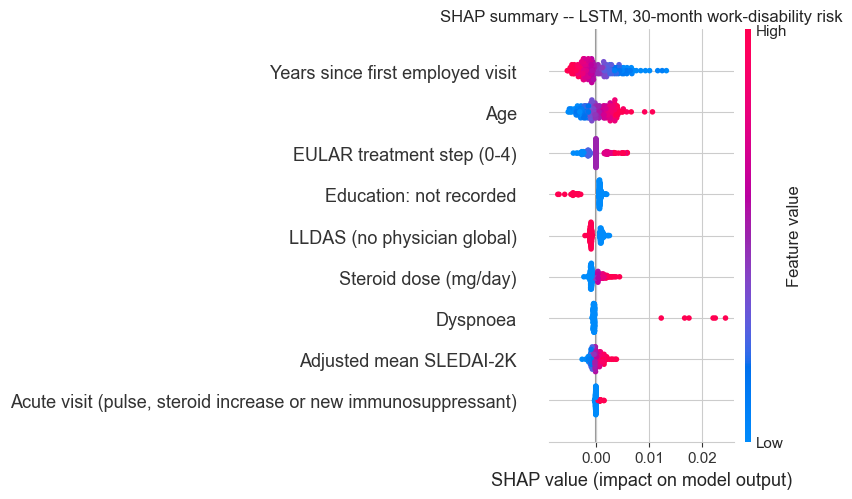

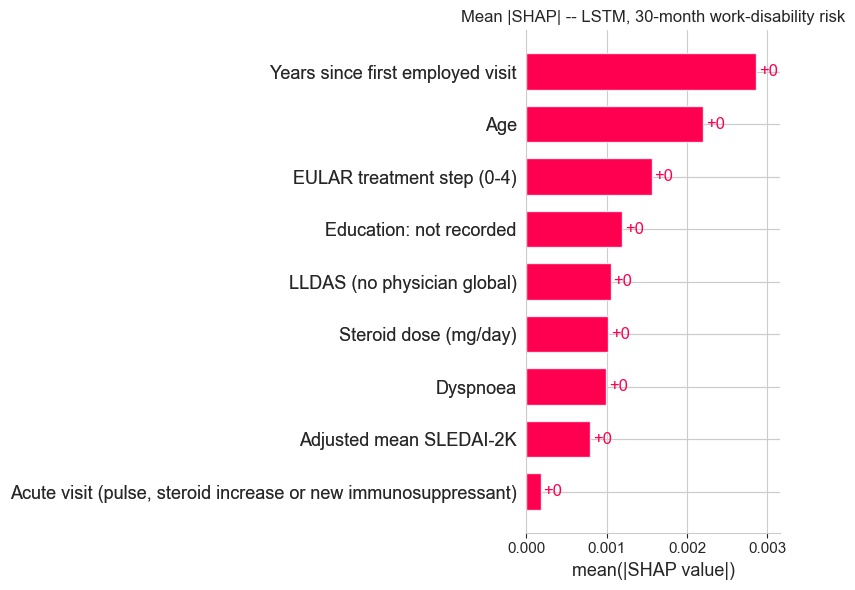

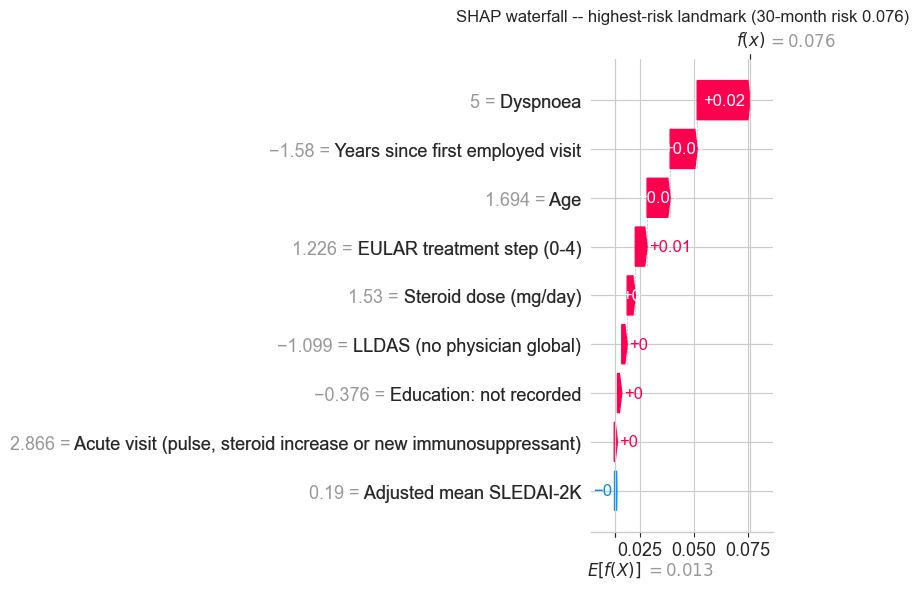

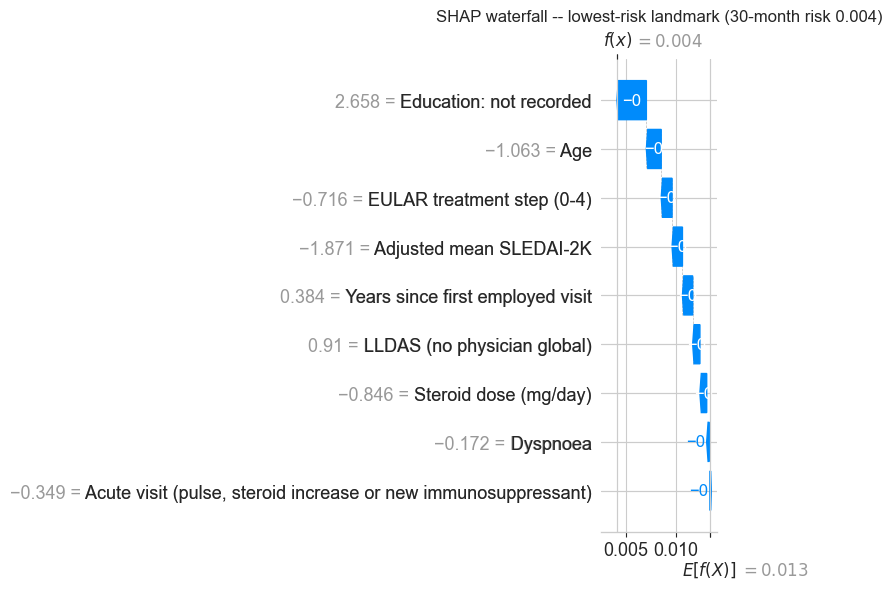

                                                       Feature  Mean |SHAP|
                              Years since first employed visit       0.0029
                                                           Age       0.0022
                                    EULAR treatment step (0-4)       0.0016
                                       Education: not recorded       0.0012
                                   LLDAS (no physician global)       0.0011
                                         Steroid dose (mg/day)       0.0010
                                                      Dyspnoea       0.0010
                                       Adjusted mean SLEDAI-2K       0.0008
Acute visit (pulse, steroid increase or new immunosuppressant)       0.0002
Computing SHAP values for XGBoost (300 landmarks, 200 background)...


ExactExplainer explainer: 301it [02:20,  1.99it/s]                         


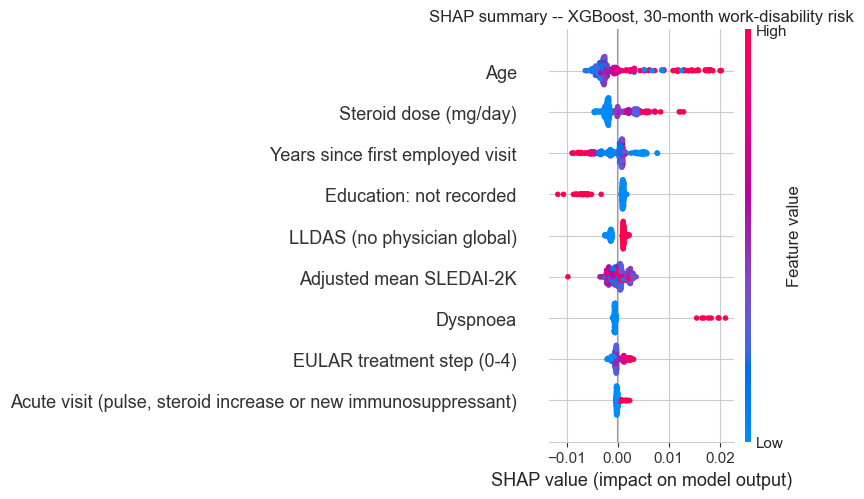

                                                       Feature  Mean |SHAP|
                                                           Age       0.0041
                                         Steroid dose (mg/day)       0.0025
                              Years since first employed visit       0.0020
                                       Education: not recorded       0.0017
                                   LLDAS (no physician global)       0.0013
                                       Adjusted mean SLEDAI-2K       0.0013
                                                      Dyspnoea       0.0010
                                    EULAR treatment step (0-4)       0.0008
Acute visit (pulse, steroid increase or new immunosuppressant)       0.0002


In [55]:
"""SHAP explanations for the LSTM (final all-data refit).

The LSTM reads a visit history, so SHAP attributes the 30-month risk to the CURRENT visit presented as a short,
constant trajectory: the visit's encoder features are repeated over SHAP_SEQ_LEN employed visits (the history window
chosen most often, at most 4) at the cohort's median visit gap, and the risk is read at the last one. The features are the encoder's inputs; the gap and the employment
state are held fixed. This is a 'constant recent trajectory'
simplification; the risk-sensitivity curves show each feature's effect with the real histories held as observed. Values are
on the calibrated 30-month risk scale. The calendar year (an adjustment term, head only) is held at the latest
year in the extract, the year a new patient is scored at, and is not attributed. Background and explained landmarks use the first imputation's features
(every seed of the ensemble -- each trained on its own imputation -- is applied to them).
"""
import shap

SHAP_MODEL = "LSTM" if res_lstm is not None else next(m for m in ["GRU", "Transformer"] if m in MODEL_RESULTS)
_chosen = [v["best"] for k, v in cv_state["folds"].items() if k[0] == SHAP_MODEL]
_mv = seq_cfg(SHAP_MODEL, max(set(_chosen), key=_chosen.count))["max_visits"] if _chosen else None
SHAP_SEQ_LEN = min(4, _mv or 4)
fr = MODEL_RESULTS[SHAP_MODEL]["final"]
data = fr["prep"]
cols = data.cols                                                # the model columns
shap_idx = [j for j, c in enumerate(cols) if c not in ADJUST_COLS]    # attributed: the variables
adj_fixed = {cols.index(c): fr["ctx"]["seq_prep"].transform_value(cols.index(c), float(land[c].max()))
             for c in ADJUST_COLS if c in cols}                        # calendar year held at the latest year
feature_names = [DISPLAY_NAMES.get(cols[j], cols[j]) for j in shap_idx]
gap_log = float(np.median(V_GAP[V_GAP > 0]))
employed = torch.tensor([1.0, 0.0, 0.0, 0.0])


def shap_predict(Z):
    Zs = np.asarray(Z, np.float32)
    n, L = len(Zs), SHAP_SEQ_LEN
    Z = np.zeros((n, len(cols)), np.float32)
    Z[:, shap_idx] = Zs
    for j, v in adj_fixed.items():
        Z[:, j] = v
    gap = torch.full((n, L), gap_log); gap[:, 0] = 0.0
    b = dict(x=torch.from_numpy(np.repeat(Z[:, None, :], L, axis=1)), gap=gap,
             state=employed.expand(n, L, -1).contiguous(),
             elapsed=torch.cumsum(torch.expm1(gap), dim=1) / 10.0, lengths=torch.full((n,), L, dtype=torch.long))
    Hz = 0.0
    with torch.no_grad():
        for net in fr["fitted"]:
            Hz = Hz + torch.sigmoid(net(b))[:, -1].numpy() / len(fr["fitted"])
    return fr["cal"].transform(hazard_risk(Hz)[:, PRIMARY_COL])


rng = np.random.RandomState(SEED)
Z_all = data.VX[land["visit_row"].values][:, shap_idx]            # scaled variables of every landmark
background = Z_all[rng.choice(len(Z_all), 50 if SMOKE else 100, replace=False)]
explain = Z_all[rng.choice(len(Z_all), 40 if SMOKE else 200, replace=False)]
print(f"Computing SHAP values for the {SHAP_MODEL} ({len(explain)} landmarks, {len(background)} background)...")
explainer = shap.Explainer(shap_predict, shap.maskers.Independent(background, max_samples=len(background)),
                           feature_names=feature_names)
shap_values = explainer(explain)

plt.figure()
shap.plots.beeswarm(shap_values, show=False, max_display=len(feature_names))
plt.title(f"SHAP summary -- {SHAP_MODEL}, 30-month work-disability risk")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_shap_summary.png", dpi=150, bbox_inches="tight"); plt.show(); plt.close()
plt.figure()
shap.plots.bar(shap_values, show=False, max_display=len(feature_names))
plt.title(f"Mean |SHAP| -- {SHAP_MODEL}, 30-month work-disability risk")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_shap_bar.png", dpi=150, bbox_inches="tight"); plt.show(); plt.close()
preds_ = shap_predict(explain)
for label, i in [("highest-risk", int(np.argmax(preds_))), ("lowest-risk", int(np.argmin(preds_)))]:
    plt.figure()
    shap.plots.waterfall(shap_values[i], show=False)
    plt.title(f"SHAP waterfall -- {label} landmark (30-month risk {preds_[i]:.3f})")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_shap_waterfall_{label.replace('-', '_')}.png", dpi=150,
                                    bbox_inches="tight"); plt.show(); plt.close()
shap_imp = pd.DataFrame({"Feature": feature_names, "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)}) \
    .sort_values("Mean |SHAP|", ascending=False)
print(shap_imp.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


# ---- XGBoost: SHAP of the calibrated 30-month risk on the variables as recorded (final all-data refit)
if "XGBoost" in MODEL_RESULTS and MODEL_RESULTS["XGBoost"].get("final") is not None:
    frx = MODEL_RESULTS["XGBoost"]["final"]
    xcols = list(frx["ctx"]["features"])
    xj = [j for j, c in enumerate(xcols) if c not in ADJUST_COLS]
    x_year = {j: float(land[c].max()) for j, c in enumerate(xcols) if c in ADJUST_COLS}   # the latest year

    def xgb_shap_predict(Z):
        X = np.zeros((len(Z), len(xcols)))
        X[:, xj] = np.asarray(Z, float)
        for j, v in x_year.items():
            X[:, j] = v
        return frx["cal"].transform(frx["fitted"].predict_risk([X])[:, PRIMARY_COL])

    XR = X_for(np.arange(len(land)), xcols)[:, :len(xcols)][:, xj]
    rng_x = np.random.RandomState(SEED + 1)
    bg = XR[rng_x.choice(len(XR), 50 if SMOKE else 200, replace=False)]
    ex = XR[rng_x.choice(len(XR), 40 if SMOKE else 300, replace=False)]
    print(f"Computing SHAP values for XGBoost ({len(ex)} landmarks, {len(bg)} background)...")
    sv_xgb = shap.Explainer(xgb_shap_predict, shap.maskers.Independent(bg, max_samples=len(bg)),
                            feature_names=[DISPLAY_NAMES.get(xcols[j], xcols[j]) for j in xj])(ex)
    plt.figure()
    shap.plots.beeswarm(sv_xgb, show=False, max_display=len(xj))
    plt.title("SHAP summary -- XGBoost, 30-month work-disability risk")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_shap_summary_xgboost.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    shap_imp_xgb = pd.DataFrame({"Feature": sv_xgb.feature_names, "Mean |SHAP|": np.abs(sv_xgb.values).mean(axis=0)}) \
        .sort_values("Mean |SHAP|", ascending=False)
    print(shap_imp_xgb.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

---
# Part B — Patient-level results

## 11.20 Patient-level results per model

Each model's out-of-fold visit alarms (Part A, the visit threshold of each training fold) are **accumulated over each
patient's 30-month window** (Section 9.2). For each model: the table for all evaluable patients, one table per final
status (employed at the last visit; retired / homemaker at ≥ 60; other), the results by age band, and the patient-level
calibration plot.

LSTM-8 (main model) -- PATIENT LEVEL, all evaluable patients
  141 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 109.8, FN 31.2, TN 336.8, FP 355.2; flagged event patients were first flagged a median 19.3 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7882     | [0.748, 0.832]  Discrim

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,59,309,"0.792 [0.730, 0.850]","0.780 [0.680, 0.879]","0.447 [0.399, 0.503]"
40-49,30,162,"0.852 [0.766, 0.919]","0.853 [0.710, 0.966]","0.521 [0.448, 0.587]"
50-59,44,152,"0.759 [0.670, 0.838]","0.705 [0.568, 0.820]","0.534 [0.458, 0.605]"
>= 60,8,69,"0.752 [0.515, 0.933]","0.900 [0.733, 1.000]","0.478 [0.373, 0.580]"


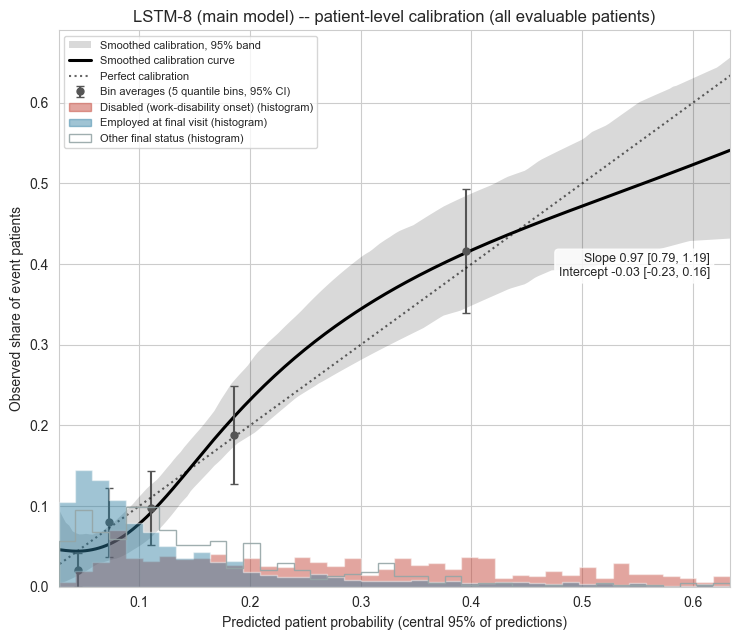

LSTM-1 (current visit only) -- PATIENT LEVEL, all evaluable patients
  141 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 109.4, FN 31.6, TN 344.4, FP 347.6; flagged event patients were first flagged a median 19.3 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7892     | [0.749, 0.833] 

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,59,309,"0.789 [0.729, 0.848]","0.769 [0.662, 0.873]","0.445 [0.398, 0.498]"
40-49,30,162,"0.854 [0.766, 0.923]","0.860 [0.718, 0.967]","0.533 [0.461, 0.600]"
50-59,44,152,"0.765 [0.678, 0.842]","0.705 [0.569, 0.817]","0.558 [0.483, 0.630]"
>= 60,8,69,"0.757 [0.517, 0.937]","0.900 [0.680, 1.000]","0.519 [0.412, 0.624]"


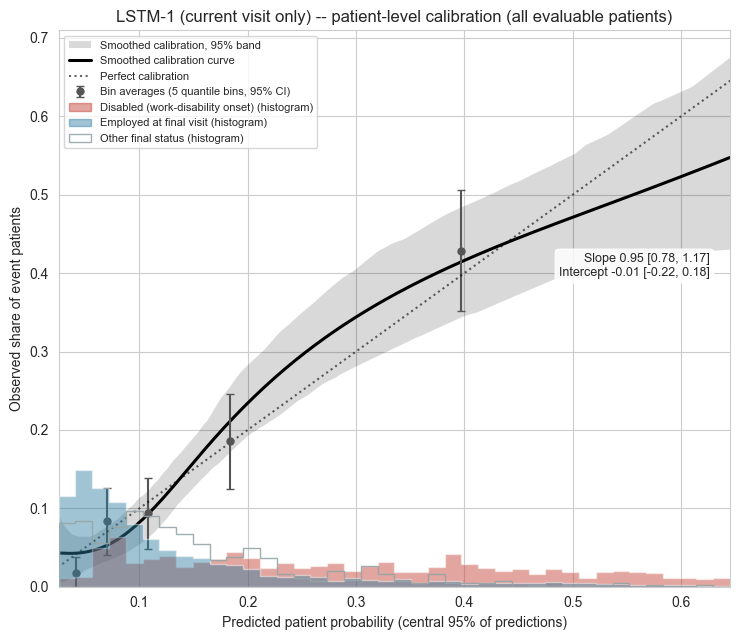

LogReg (discrete-time, competing risks) -- PATIENT LEVEL, all evaluable patients
  141 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 108.6, FN 32.4, TN 315.4, FP 376.6; flagged event patients were first flagged a median 19.3 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7806     | [0.

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,59,309,"0.779 [0.718, 0.838]","0.776 [0.685, 0.875]","0.384 [0.334, 0.438]"
40-49,30,162,"0.851 [0.758, 0.923]","0.867 [0.724, 0.970]","0.452 [0.373, 0.518]"
50-59,44,152,"0.751 [0.658, 0.831]","0.682 [0.544, 0.800]","0.545 [0.471, 0.617]"
>= 60,8,69,"0.761 [0.518, 0.939]","0.850 [0.599, 1.000]","0.588 [0.492, 0.688]"


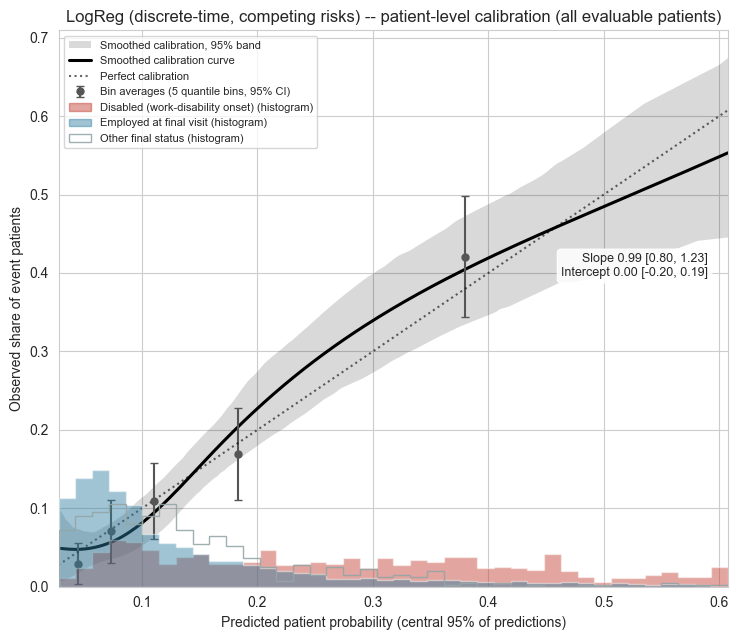

RSF -- PATIENT LEVEL, all evaluable patients
  141 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 116.0, FN 25.0, TN 296.2, FP 395.8; flagged event patients were first flagged a median 17.1 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7721     | [0.730, 0.813]  Discrimination
Brier Sc

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,59,309,"0.775 [0.712, 0.832]","0.803 [0.710, 0.894]","0.469 [0.422, 0.526]"
40-49,30,162,"0.835 [0.745, 0.906]","0.800 [0.663, 0.919]","0.564 [0.488, 0.634]"
50-59,44,152,"0.735 [0.651, 0.815]","0.832 [0.742, 0.908]","0.333 [0.268, 0.396]"
>= 60,8,69,"0.725 [0.519, 0.938]","1.000 [1.000, 1.000]","0.133 [0.068, 0.200]"


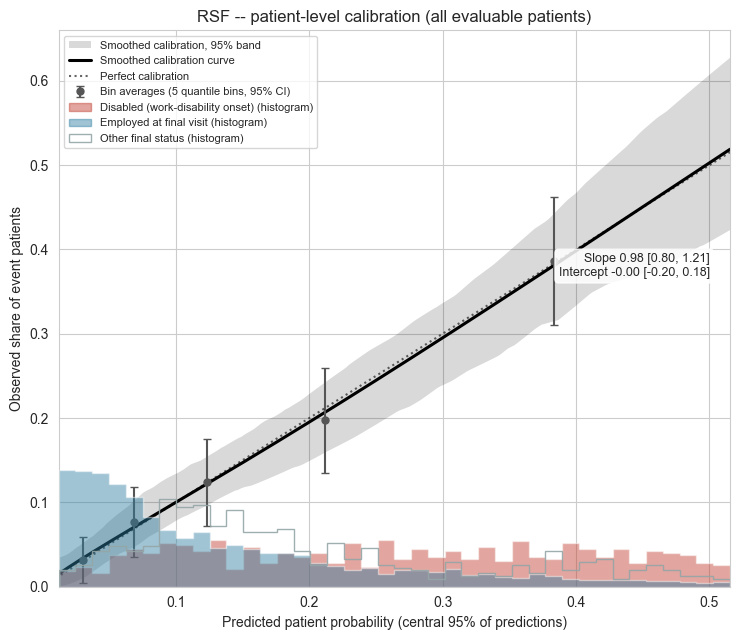

CoxPH (cause-specific) -- PATIENT LEVEL, all evaluable patients
  141 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 105.2, FN 35.8, TN 298.4, FP 393.6; flagged event patients were first flagged a median 19.1 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7609     | [0.713, 0.807]  Disc

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,59,309,"0.765 [0.701, 0.825]","0.783 [0.685, 0.879]","0.340 [0.292, 0.393]"
40-49,30,162,"0.829 [0.731, 0.909]","0.833 [0.680, 0.963]","0.448 [0.374, 0.521]"
50-59,44,152,"0.727 [0.631, 0.812]","0.618 [0.470, 0.746]","0.533 [0.459, 0.603]"
>= 60,8,69,"0.779 [0.534, 0.955]","0.850 [0.599, 1.000]","0.577 [0.470, 0.685]"


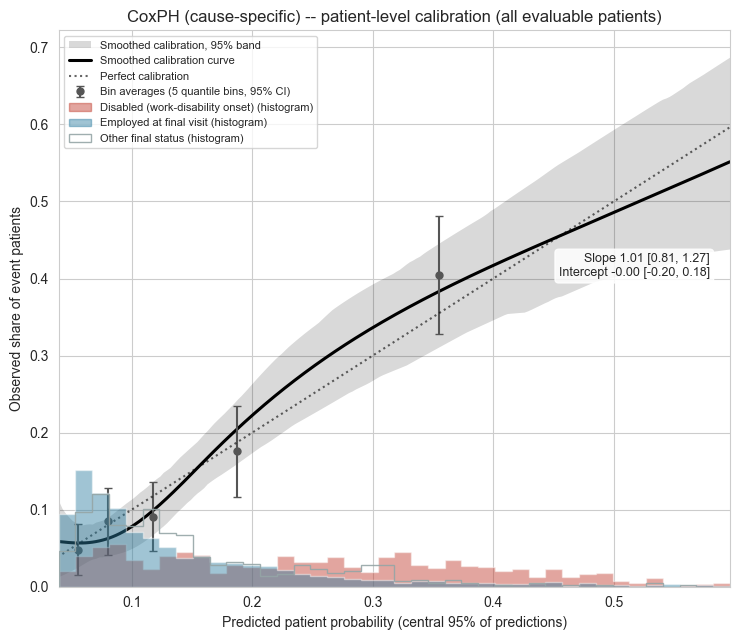

GRU -- PATIENT LEVEL, all evaluable patients
  141 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 109.4, FN 31.6, TN 340.2, FP 351.8; flagged event patients were first flagged a median 19.8 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7898     | [0.749, 0.832]  Discrimination
Brier Sc

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,59,309,"0.797 [0.734, 0.855]","0.803 [0.708, 0.890]","0.496 [0.449, 0.551]"
40-49,30,162,"0.858 [0.779, 0.923]","0.813 [0.664, 0.937]","0.540 [0.468, 0.606]"
50-59,44,152,"0.753 [0.663, 0.831]","0.691 [0.558, 0.804]","0.472 [0.403, 0.541]"
>= 60,8,69,"0.714 [0.472, 0.927]","0.900 [0.750, 1.000]","0.403 [0.307, 0.504]"


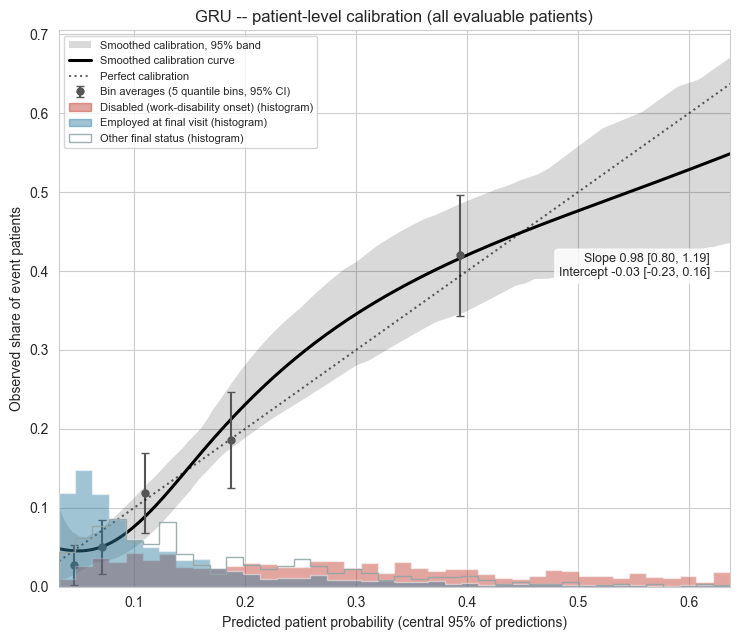

Transformer (causal) -- PATIENT LEVEL, all evaluable patients
  141 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 104.2, FN 36.8, TN 383.4, FP 308.6; flagged event patients were first flagged a median 19.3 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7890     | [0.749, 0.829]  Discri

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,59,309,"0.786 [0.724, 0.842]","0.753 [0.652, 0.844]","0.516 [0.468, 0.571]"
40-49,30,162,"0.856 [0.776, 0.919]","0.800 [0.652, 0.925]","0.622 [0.551, 0.683]"
50-59,44,152,"0.772 [0.687, 0.847]","0.645 [0.510, 0.766]","0.571 [0.499, 0.636]"
>= 60,8,69,"0.716 [0.482, 0.928]","0.925 [0.760, 1.000]","0.528 [0.423, 0.627]"


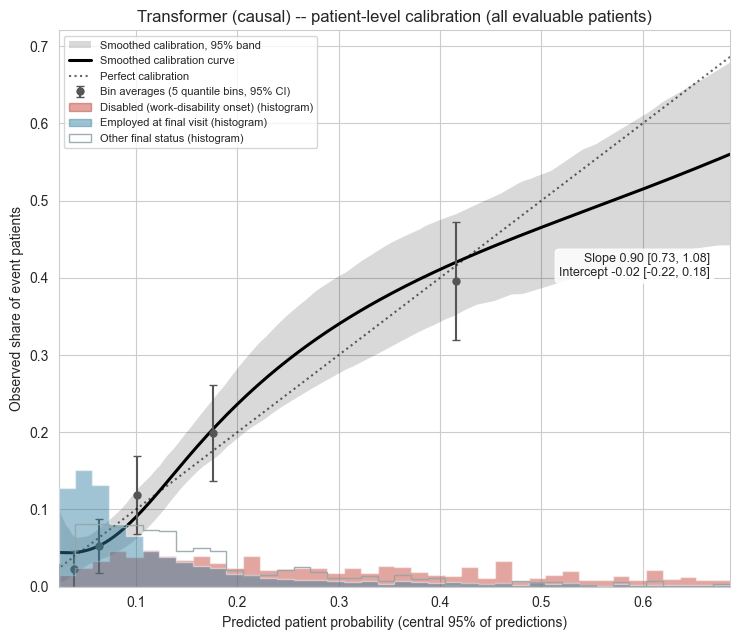

XGBoost (cause-specific discrete-time hazards) -- PATIENT LEVEL, all evaluable patients
  141 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 113.8, FN 27.2, TN 285.8, FP 406.2; flagged event patients were first flagged a median 19.8 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7704   

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,59,309,"0.755 [0.699, 0.812]","0.797 [0.711, 0.881]","0.423 [0.380, 0.474]"
40-49,30,162,"0.866 [0.786, 0.926]","0.853 [0.717, 0.963]","0.540 [0.475, 0.601]"
50-59,44,152,"0.736 [0.652, 0.804]","0.777 [0.675, 0.874]","0.317 [0.252, 0.379]"
>= 60,8,69,"0.693 [0.504, 0.877]","0.875 [0.571, 1.000]","0.281 [0.194, 0.371]"


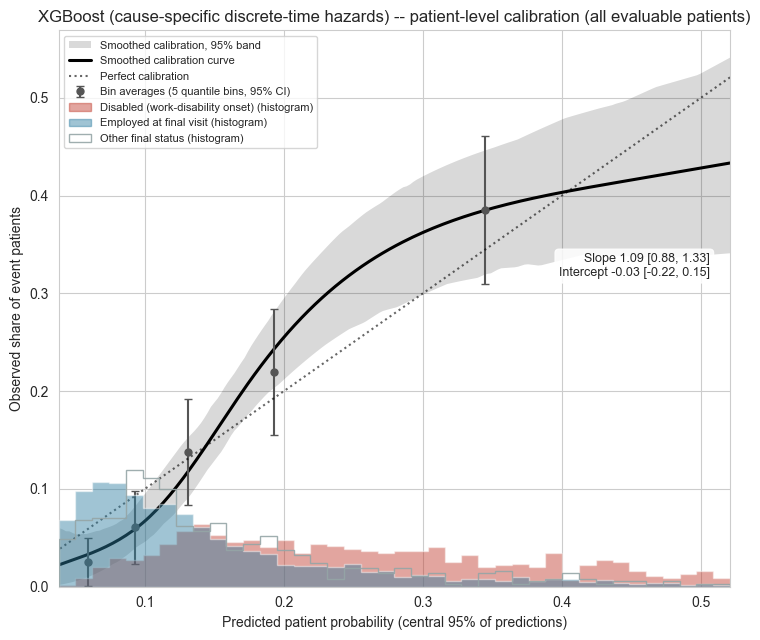

Stack (logistic meta-learner) -- PATIENT LEVEL, all evaluable patients
  141 event patients (TP / FN: an alarm in the 30 months before onset) vs 692 event-free patients (TN / FP: no alarm / an alarm in their 30-month window): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 110.8, FN 30.2, TN 340.4, FP 351.6; flagged event patients were first flagged a median 19.3 months before onset
  patient probability = highest visit risk in the window, recalibrated on the training patients in each fold; alarms use the visit threshold (no patient-level threshold)
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Concordance Index              | 0.7881     | [0.746, 0.830

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,59,309,"0.788 [0.724, 0.845]","0.803 [0.709, 0.900]","0.460 [0.413, 0.518]"
40-49,30,162,"0.853 [0.765, 0.922]","0.840 [0.696, 0.959]","0.538 [0.463, 0.610]"
50-59,44,152,"0.760 [0.672, 0.837]","0.700 [0.561, 0.820]","0.534 [0.456, 0.603]"
>= 60,8,69,"0.741 [0.506, 0.937]","0.925 [0.760, 1.000]","0.432 [0.330, 0.536]"


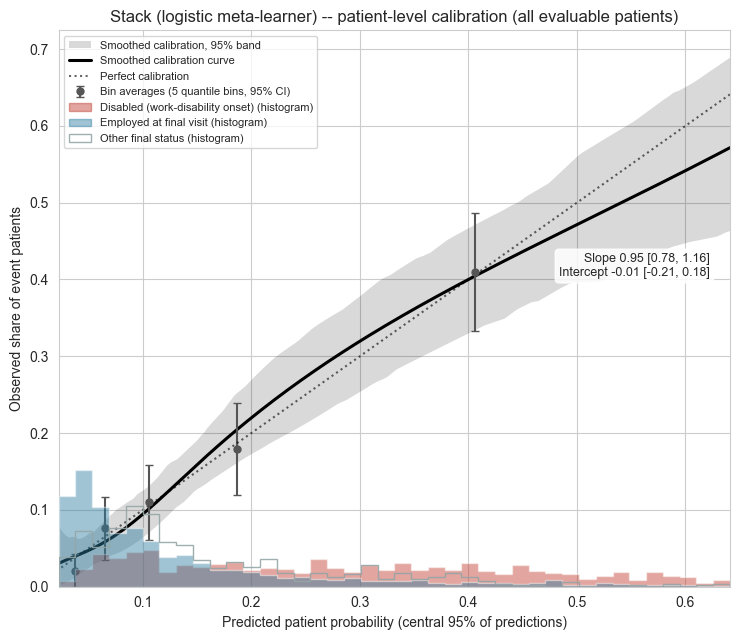

In [56]:
"""Patient-level results of every model, in the order of the model sections (visit risks accumulated per patient)."""
for m, r in MODEL_RESULTS.items():
    report_patient_level(r)


## 11.21 Patient-level summary — all models

Every metric of the per-model patient tables, value [95 % patient-bootstrap CI]: all evaluable patients, each final
status, specificity by age band, LaTeX rows, and all tables of both levels in `metric_tables_model_revised_v16.csv`.

In [57]:
"""
Patient-level summary for all models (visit alarms accumulated per patient; Section 11.6): value [95% patient-bootstrap
CI] for all evaluable patients, then per final-status stratum, specificity by age band, LaTeX rows, and every table of
both levels in metric_tables_model_revised_v16.csv.
"""
_f0 = next(iter(next(iter(MODEL_RESULTS.values()))["preds"].values()))["pt"]
patient_summary = wide_table("patient_table")
print(f"PATIENT LEVEL -- all models, all evaluable patients ({int(_f0.y.sum())} event vs {int((_f0.y == 0).sum())} "
      f"event-free): value [95% patient bootstrap CI], mean over CV repeats")
display(patient_summary)
for _st in STRATA:
    print(f"\nPATIENT LEVEL -- event patients vs event-free '{_st}' "
          f"({int(((_f0.y == 0) & (_f0.stratum == _st)).sum())} patients):")
    display(pd.DataFrame({m: {row["Metric"]: (f"{row['Value']:.3f} [{row['CI low']:.3f}, {row['CI high']:.3f}]"
                                              if np.isfinite(row["Value"]) else "n/a")
                               for _, row in r["stratum_tables"][_st].drop(index=STRATUM_DROP, errors="ignore").iterrows()}
                          for m, r in MODEL_RESULTS.items()}).T)
print("\nSpecificity by age at the end of the window (event-free patients in the band):")
display(pd.DataFrame({m: age_band_table(r)["Specificity"] for m, r in MODEL_RESULTS.items()}).T)
print("\nLaTeX rows, patient level, all evaluable patients (" + " & ".join(patient_summary.columns) + "):")
print("\n".join(latex_table_rows("patient_table")))
metric_tables_long = pd.concat(
    [r["visit_table"].assign(model=m, level="visit") for m, r in MODEL_RESULTS.items()]
    + [r["patient_table"].assign(model=m, level="patient: all evaluable") for m, r in MODEL_RESULTS.items()]
    + [r["stratum_tables"][st].assign(model=m, level=f"patient: {st}") for m, r in MODEL_RESULTS.items()
       for st in STRATA]
    + [r["age_tables"][lab].assign(model=m, level=f"patient: age {lab}") for m, r in MODEL_RESULTS.items()
       for _, _, lab in AGE_BANDS])
metric_tables_long.to_csv("metric_tables_model_revised_v16.csv")

print("\nAlert burden over the whole follow-up (alarms at each fold's visit threshold; mean (SD) over repeats). "
      "'Stayed employed' = no onset or other exit after any landmark and employed at the last recorded status; "
      "'never alerted' = no alarm at any of their landmarks:")
display(pd.DataFrame({m: alert_burden_summary(m, r["preds"]) for m, r in MODEL_RESULTS.items()}).T)

PATIENT LEVEL -- all models, all evaluable patients (141 event vs 692 event-free): value [95% patient bootstrap CI], mean over CV repeats


,Concordance Index,Brier Score,Calibration Slope,Calibration Intercept,Observed / Expected,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy,PPV (cohort prevalence),NPV (cohort prevalence)
LSTM,"0.788 [0.748, 0.832]","0.117 [0.104, 0.132]","0.966 [0.786, 1.189]","-0.028 [-0.228, 0.163]","0.981 [0.854, 1.114]","0.779 [0.710, 0.843]","0.487 [0.454, 0.524]","0.236 [0.201, 0.276]","0.915 [0.887, 0.942]","0.633 [0.597, 0.671]","0.200 [0.184, 0.219]","0.930 [0.911, 0.950]"
LSTM1,"0.789 [0.749, 0.833]","0.117 [0.104, 0.131]","0.951 [0.775, 1.172]","-0.015 [-0.217, 0.177]","0.990 [0.861, 1.123]","0.776 [0.706, 0.840]","0.498 [0.465, 0.535]","0.240 [0.204, 0.280]","0.916 [0.889, 0.943]","0.637 [0.601, 0.676]","0.203 [0.186, 0.223]","0.931 [0.911, 0.951]"
LogReg,"0.781 [0.737, 0.825]","0.117 [0.104, 0.132]","0.986 [0.799, 1.234]","0.002 [-0.198, 0.194]","1.001 [0.870, 1.139]","0.770 [0.699, 0.836]","0.456 [0.424, 0.493]","0.224 [0.188, 0.260]","0.907 [0.875, 0.935]","0.613 [0.574, 0.651]","0.189 [0.173, 0.207]","0.923 [0.902, 0.944]"
RSF,"0.772 [0.730, 0.813]","0.120 [0.107, 0.134]","0.984 [0.796, 1.212]","-0.003 [-0.201, 0.184]","0.998 [0.863, 1.137]","0.823 [0.769, 0.872]","0.428 [0.396, 0.460]","0.227 [0.191, 0.262]","0.922 [0.895, 0.946]","0.625 [0.594, 0.657]","0.192 [0.179, 0.206]","0.936 [0.917, 0.954]"
CoxPH,"0.761 [0.713, 0.807]","0.121 [0.107, 0.135]","1.014 [0.810, 1.269]","-0.002 [-0.197, 0.182]","0.999 [0.869, 1.138]","0.746 [0.675, 0.815]","0.431 [0.396, 0.470]","0.211 [0.175, 0.246]","0.893 [0.860, 0.924]","0.589 [0.552, 0.628]","0.178 [0.162, 0.195]","0.911 [0.889, 0.934]"
GRU,"0.790 [0.749, 0.832]","0.117 [0.104, 0.131]","0.982 [0.801, 1.193]","-0.029 [-0.230, 0.161]","0.981 [0.853, 1.114]","0.776 [0.711, 0.837]","0.492 [0.459, 0.525]","0.238 [0.201, 0.276]","0.915 [0.888, 0.941]","0.634 [0.597, 0.670]","0.202 [0.185, 0.219]","0.930 [0.910, 0.949]"
Transformer,"0.789 [0.749, 0.829]","0.117 [0.103, 0.132]","0.897 [0.735, 1.076]","-0.015 [-0.225, 0.185]","0.990 [0.862, 1.126]","0.739 [0.669, 0.805]","0.554 [0.523, 0.586]","0.254 [0.214, 0.296]","0.912 [0.887, 0.937]","0.647 [0.608, 0.683]","0.216 [0.196, 0.236]","0.928 [0.910, 0.946]"
XGBoost,"0.770 [0.731, 0.809]","0.124 [0.110, 0.139]","1.088 [0.880, 1.328]","-0.027 [-0.218, 0.146]","0.981 [0.850, 1.112]","0.807 [0.745, 0.860]","0.413 [0.382, 0.442]","0.219 [0.186, 0.252]","0.913 [0.883, 0.940]","0.610 [0.578, 0.641]","0.185 [0.172, 0.198]","0.929 [0.908, 0.948]"
Stack,"0.788 [0.746, 0.830]","0.117 [0.104, 0.131]","0.948 [0.777, 1.155]","-0.013 [-0.214, 0.184]","0.992 [0.865, 1.130]","0.786 [0.720, 0.850]","0.492 [0.459, 0.528]","0.240 [0.201, 0.279]","0.918 [0.891, 0.944]","0.639 [0.600, 0.676]","0.203 [0.186, 0.222]","0.933 [0.912, 0.952]"



PATIENT LEVEL -- event patients vs event-free 'Employed at final visit' (597 patients):


,Concordance Index,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy,PPV (cohort prevalence),NPV (cohort prevalence)
LSTM,"0.797 [0.751, 0.838]","0.779 [0.707, 0.841]","0.455 [0.418, 0.492]","0.252 [0.211, 0.293]","0.897 [0.861, 0.929]","0.617 [0.575, 0.654]","0.191 [0.173, 0.209]","0.926 [0.902, 0.946]"
LSTM1,"0.797 [0.751, 0.838]","0.776 [0.705, 0.839]","0.463 [0.424, 0.502]","0.254 [0.212, 0.296]","0.897 [0.862, 0.929]","0.619 [0.579, 0.657]","0.193 [0.175, 0.211]","0.926 [0.903, 0.946]"
LogReg,"0.786 [0.735, 0.827]","0.770 [0.699, 0.835]","0.414 [0.376, 0.452]","0.237 [0.197, 0.276]","0.884 [0.846, 0.918]","0.592 [0.550, 0.631]","0.178 [0.161, 0.195]","0.916 [0.889, 0.939]"
RSF,"0.791 [0.746, 0.830]","0.823 [0.761, 0.879]","0.428 [0.394, 0.465]","0.254 [0.212, 0.292]","0.911 [0.880, 0.941]","0.626 [0.591, 0.660]","0.192 [0.178, 0.207]","0.936 [0.915, 0.957]"
CoxPH,"0.767 [0.716, 0.813]","0.746 [0.668, 0.813]","0.403 [0.364, 0.441]","0.228 [0.189, 0.267]","0.870 [0.832, 0.908]","0.574 [0.533, 0.615]","0.171 [0.154, 0.187]","0.906 [0.879, 0.929]"
GRU,"0.805 [0.760, 0.844]","0.776 [0.706, 0.836]","0.474 [0.438, 0.508]","0.259 [0.217, 0.299]","0.899 [0.868, 0.931]","0.625 [0.586, 0.660]","0.196 [0.178, 0.214]","0.927 [0.905, 0.946]"
Transformer,"0.802 [0.758, 0.840]","0.739 [0.662, 0.803]","0.530 [0.494, 0.568]","0.272 [0.227, 0.315]","0.895 [0.864, 0.924]","0.634 [0.594, 0.672]","0.207 [0.187, 0.227]","0.925 [0.904, 0.942]"
XGBoost,"0.772 [0.728, 0.810]","0.807 [0.748, 0.863]","0.365 [0.333, 0.398]","0.231 [0.195, 0.266]","0.889 [0.854, 0.925]","0.586 [0.553, 0.618]","0.173 [0.161, 0.186]","0.920 [0.897, 0.942]"
Stack,"0.800 [0.754, 0.840]","0.786 [0.713, 0.850]","0.469 [0.432, 0.507]","0.259 [0.217, 0.302]","0.903 [0.868, 0.933]","0.628 [0.586, 0.665]","0.196 [0.178, 0.215]","0.930 [0.907, 0.950]"



PATIENT LEVEL -- event patients vs event-free 'Retired / homemaker >= 60' (17 patients):


...

,Concordance Index,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy,PPV (cohort prevalence),NPV (cohort prevalence)
LSTM,"0.742 [0.674, 0.808]","0.779 [0.715, 0.840]","0.710 [0.623, 0.789]","0.829 [0.772, 0.887]","0.640 [0.540, 0.727]","0.744 [0.690, 0.796]","0.308 [0.251, 0.386]","0.951 [0.935, 0.965]"
LSTM1,"0.748 [0.681, 0.813]","0.776 [0.708, 0.836]","0.741 [0.653, 0.825]","0.844 [0.785, 0.902]","0.647 [0.552, 0.734]","0.758 [0.702, 0.812]","0.331 [0.266, 0.427]","0.952 [0.937, 0.966]"
LogReg,"0.748 [0.678, 0.810]","0.770 [0.704, 0.832]","0.728 [0.644, 0.808]","0.838 [0.775, 0.895]","0.636 [0.537, 0.724]","0.749 [0.695, 0.800]","0.327 [0.267, 0.415]","0.950 [0.935, 0.964]"
RSF,"0.659 [0.579, 0.734]","0.823 [0.769, 0.874]","0.459 [0.362, 0.562]","0.733 [0.660, 0.801]","0.589 [0.479, 0.698]","0.641 [0.584, 0.700]","0.201 [0.173, 0.240]","0.940 [0.916, 0.958]"
CoxPH,"0.712 [0.637, 0.779]","0.746 [0.682, 0.812]","0.597 [0.497, 0.699]","0.770 [0.698, 0.840]","0.566 [0.461, 0.669]","0.672 [0.613, 0.733]","0.234 [0.196, 0.294]","0.934 [0.913, 0.952]"
GRU,"0.698 [0.626, 0.766]","0.776 [0.713, 0.834]","0.603 [0.513, 0.694]","0.779 [0.714, 0.841]","0.598 [0.490, 0.691]","0.689 [0.631, 0.743]","0.244 [0.204, 0.297]","0.942 [0.924, 0.958]"
Transformer,"0.704 [0.633, 0.769]","0.739 [0.679, 0.800]","0.703 [0.610, 0.794]","0.818 [0.749, 0.882]","0.599 [0.506, 0.687]","0.721 [0.659, 0.779]","0.291 [0.234, 0.378]","0.942 [0.925, 0.957]"
XGBoost,"0.763 [0.699, 0.823]","0.807 [0.754, 0.862]","0.718 [0.635, 0.800]","0.838 [0.780, 0.892]","0.674 [0.584, 0.765]","0.763 [0.711, 0.812]","0.322 [0.267, 0.405]","0.957 [0.944, 0.970]"
Stack,"0.718 [0.645, 0.783]","0.786 [0.723, 0.848]","0.649 [0.551, 0.740]","0.802 [0.739, 0.865]","0.626 [0.524, 0.719]","0.717 [0.658, 0.774]","0.271 [0.222, 0.341]","0.948 [0.930, 0.963]"



Specificity by age at the end of the window (event-free patients in the band):


Age at end of window,< 40,40-49,50-59,>= 60
LSTM,"0.447 [0.399, 0.503]","0.521 [0.448, 0.587]","0.534 [0.458, 0.605]","0.478 [0.373, 0.580]"
LSTM1,"0.445 [0.398, 0.498]","0.533 [0.461, 0.600]","0.558 [0.483, 0.630]","0.519 [0.412, 0.624]"
LogReg,"0.384 [0.334, 0.438]","0.452 [0.373, 0.518]","0.545 [0.471, 0.617]","0.588 [0.492, 0.688]"
RSF,"0.469 [0.422, 0.526]","0.564 [0.488, 0.634]","0.333 [0.268, 0.396]","0.133 [0.068, 0.200]"
CoxPH,"0.340 [0.292, 0.393]","0.448 [0.374, 0.521]","0.533 [0.459, 0.603]","0.577 [0.470, 0.685]"
GRU,"0.496 [0.449, 0.551]","0.540 [0.468, 0.606]","0.472 [0.403, 0.541]","0.403 [0.307, 0.504]"
Transformer,"0.516 [0.468, 0.571]","0.622 [0.551, 0.683]","0.571 [0.499, 0.636]","0.528 [0.423, 0.627]"
XGBoost,"0.423 [0.380, 0.474]","0.540 [0.475, 0.601]","0.317 [0.252, 0.379]","0.281 [0.194, 0.371]"
Stack,"0.460 [0.413, 0.518]","0.538 [0.463, 0.610]","0.534 [0.456, 0.603]","0.432 [0.330, 0.536]"



LaTeX rows, patient level, all evaluable patients (Concordance Index & Brier Score & Calibration Slope & Calibration Intercept & Observed / Expected & Sensitivity & Specificity & PPV & NPV & Balanced Accuracy & PPV (cohort prevalence) & NPV (cohort prevalence)):
LSTM        & 0.788 (0.748--0.832) & 0.117 (0.104--0.132) & 0.966 (0.786--1.189) & -0.028 (-0.228--0.163) & 0.981 (0.854--1.114) & 0.779 (0.710--0.843) & 0.487 (0.454--0.524) & 0.236 (0.201--0.276) & 0.915 (0.887--0.942) & 0.633 (0.597--0.671) & 0.200 (0.184--0.219) & 0.930 (0.911--0.950) \\
LSTM1       & 0.789 (0.749--0.833) & 0.117 (0.104--0.131) & 0.951 (0.775--1.172) & -0.015 (-0.217--0.177) & 0.990 (0.861--1.123) & 0.776 (0.706--0.840) & 0.498 (0.465--0.535) & 0.240 (0.204--0.280) & 0.916 (0.889--0.943) & 0.637 (0.601--0.676) & 0.203 (0.186--0.223) & 0.931 (0.911--0.951) \\
LogReg      & 0.781 (0.737--0.825) & 0.117 (0.104--0.132) & 0.986 (0.799--1.234) & 0.002 (-0.198--0.194) & 1.001 (0.870--1.139) & 0.770 (0.699--0.836)

,Alerts / 100 landmark visits,Alerts / patient-year,Stayed employed: patients,"Stayed employed: follow-up, median yrs",Stayed employed: never alerted (share),Stayed employed: alerts / patient-year
LSTM,39.3 (1.9),0.85 (0.04),704,5.9,0.112 (0.018),0.86 (0.05)
LSTM1,38.1 (1.4),0.83 (0.03),704,5.9,0.127 (0.017),0.84 (0.04)
LogReg,39.2 (0.7),0.85 (0.02),704,5.9,0.105 (0.007),0.87 (0.03)
RSF,42.7 (1.2),0.92 (0.03),704,5.9,0.087 (0.008),0.89 (0.02)
CoxPH,40.5 (0.2),0.88 (0.01),704,5.9,0.167 (0.008),0.88 (0.01)
GRU,40.7 (3.8),0.88 (0.08),704,5.9,0.135 (0.032),0.86 (0.09)
Transformer,33.9 (4.4),0.73 (0.10),704,5.9,0.215 (0.031),0.72 (0.11)
XGBoost,46.0 (0.5),1.00 (0.01),704,5.9,0.089 (0.012),1.04 (0.02)
Stack,38.0 (1.8),0.82 (0.04),704,5.9,0.148 (0.015),0.81 (0.04)


## 11.22 Patient-level calibration and decision curve — all models

Smoothed calibration of the patient probability for every model, the patient-level ROC curves, and the patient-level
decision curve (net benefit of flagging patients above a probability threshold, against flagging everyone or no one).

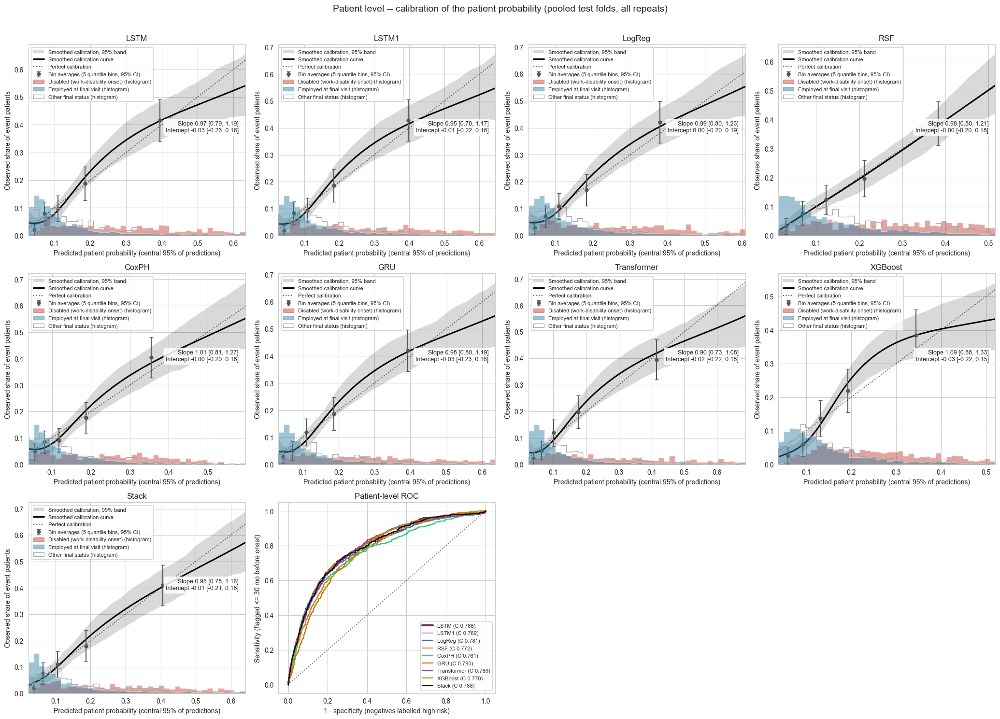

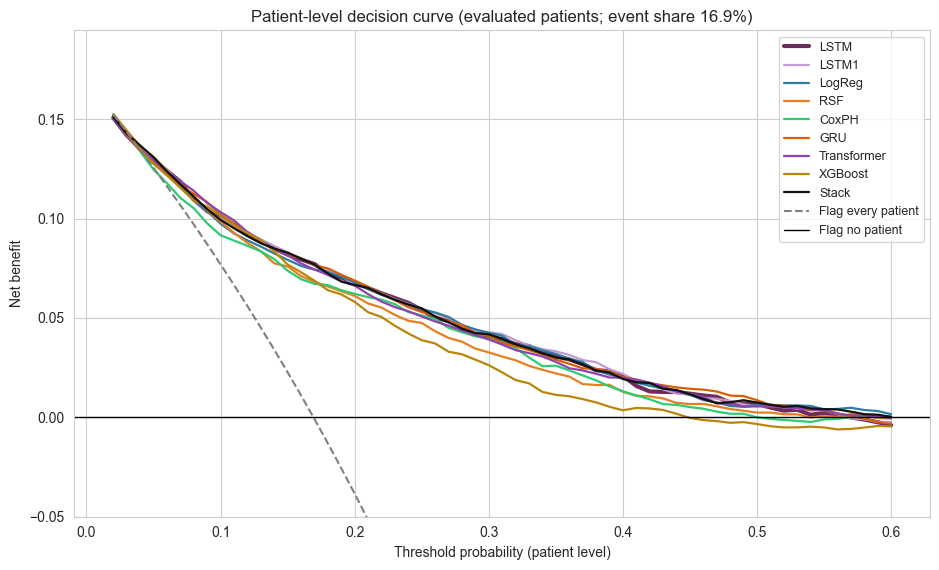

In [58]:
"""Patient-level calibration of every model (quintiles of the recalibrated patient probability, all repeats stacked,
with the slope and intercept of its table) and the patient-level ROC curves of all models."""
fig, axes = plt.subplots(_nrows, _ncols, figsize=(5.2 * _ncols, 4.9 * _nrows))
axes = axes.ravel()
for ax, m in zip(axes, _ms):
    plot_calibration(ax, m, MODEL_RESULTS[m]["preds"], "patient", MODEL_RESULTS[m]["patient_table"], title=m)
ax = axes[len(_ms)]
for m, r in MODEL_RESULTS.items():
    arrs = level_arrays(m, r["preds"], "patient")
    y, p = np.concatenate([a[0] for a in arrs]), np.concatenate([a[1] for a in arrs])
    fpr, tpr, _ = roc_curve(y, p)
    ax.plot(fpr, tpr, color=CV_COLORS[m], lw=3 if m == "LSTM" else 1.6,
            label=f"{m} (C {r['patient_table'].loc['c_index', 'Value']:.3f})")
ax.plot([0, 1], [0, 1], "k:", alpha=0.5)
ax.set_xlabel("1 - specificity (negatives labelled high risk)"); ax.set_ylabel("Sensitivity (flagged <= 30 mo before onset)")
ax.set_title("Patient-level ROC"); ax.legend(fontsize=8, loc="lower right")
for ax in axes[len(_ms) + 1:]:
    ax.set_visible(False)
plt.suptitle("Patient level -- calibration of the patient probability (pooled test folds, all repeats)", y=1.01,
             fontsize=14)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_calibration_patient_all.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# patient-level decision curve (TRIPOD+AI items 12e and 15, clinical usefulness): net benefit of flagging patients whose patient
# probability is >= a threshold, mean over CV repeats, against flagging everyone or no one
fig, ax = plt.subplots(figsize=(9.5, 5.8))
_pts = np.linspace(0.02, 0.6, 59)
for m, r in MODEL_RESULTS.items():
    _arrs = level_arrays(m, r["preds"], "patient")
    _nb = np.mean([ipcw_net_benefit(y, p, w, _pts)[0] for y, p, w, _, _ in _arrs], axis=0)
    ax.plot(_pts, _nb, color=CV_COLORS[m], lw=3 if m == "LSTM" else 1.6, label=m)
_y0, _p0, _w0 = _arrs[0][:3]
ax.plot(_pts, ipcw_net_benefit(_y0, _p0, _w0, _pts)[1], color="gray", ls="--", label="Flag every patient")
ax.axhline(0, color="black", lw=1, label="Flag no patient")
_prev = float(_y0.mean())
ax.set_ylim(-0.05, _prev * 1.15)
ax.set_xlabel("Threshold probability (patient level)"); ax.set_ylabel("Net benefit")
ax.set_title(f"Patient-level decision curve (evaluated patients; event share {_prev:.1%})")
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_decision_curve_patient.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

## 11.23 Performance by subgroup (fairness)

TRIPOD+AI item 14: every model's C-index, calibration-in-the-large, sensitivity and specificity by sex, race and age band, at
the visit and the patient level, from the same pooled out-of-fold predictions as the main tables.

In [59]:
"""
Performance by subgroup (TRIPOD+AI item 14, fairness): sex, race and age band, at the visit and the patient level, for
every model. Same pooled out-of-fold predictions and thresholds as the main tables; each subgroup is simply a subset
of the evaluated visits / patients (for patients: all event and event-free patients in that subgroup). 95% CIs from
SUBGROUP_BOOT patient-cluster bootstrap resamples. Calibration-in-the-large (intercept) shows whether a subgroup's risk
is systematically over- (negative) or under-estimated (positive). Small subgroups have wide intervals.
"""
SUBGROUP_BOOT = 50 if SMOKE else 200
SUBGROUPS = [("sex", v) for v in ["Female", "Male"]] + \
            [("race", v) for v in ["White", "Black", "Asian (Chinese, Filipino)", "Other / not recorded"]] + \
            [("age", lab) for _, _, lab in AGE_BANDS]
SUBGROUP_METRICS = ["c_index", "cal_intercept", "sensitivity", "specificity"]


def _cell(t, k):
    v = t.loc[k]
    return f"{v['Value']:.3f} [{v['CI low']:.3f}, {v['CI high']:.3f}]" if np.isfinite(v["Value"]) else "n/a"


def subgroup_table(level):
    rows = []
    for attr, val in SUBGROUPS:
        for m, r in MODEL_RESULTS.items():
            arrs = level_arrays(m, r["preds"], level, sub=(attr, val))
            n_pos, n_neg = int(arrs[0][0].sum()), int((arrs[0][0] == 0).sum())
            if n_pos == 0 or n_neg == 0:
                continue
            t = metric_table(m, r["preds"], level, n_boot=SUBGROUP_BOOT, arrs=arrs)
            rows.append({"Attribute": attr, "Subgroup": val, "Model": m,
                         ("Onsets <= 30 mo / resolved visits" if level == "visit" else "Event / event-free patients"):
                             f"{n_pos} / {n_pos + n_neg}" if level == "visit" else f"{n_pos} / {n_neg}",
                         **{t.loc[k, "Metric"]: _cell(t, k) for k in SUBGROUP_METRICS}})
    return pd.DataFrame(rows).set_index(["Attribute", "Subgroup", "Model"])


t0 = time.time()
fairness_visit = subgroup_table("visit")
print("VISIT LEVEL by subgroup (30-month onset, IPCW; value [95% CI]):")
display(fairness_visit)
fairness_patient = subgroup_table("patient")
print("\nPATIENT LEVEL by subgroup (30-month windows; value [95% CI]):")
display(fairness_patient)
pd.concat({"visit": fairness_visit, "patient": fairness_patient}).to_csv("subgroup_performance_model_revised_v16.csv")
print(f"({time.time() - t0:.0f}s)")

VISIT LEVEL by subgroup (30-month onset, IPCW; value [95% CI]):


Onsets <= 30 mo / resolved visits  \
Attribute Subgroup                  Model                                           
sex       Female                    LSTM                              588 / 12886   
                                    LSTM1                             588 / 12886   
                                    LogReg                            588 / 12886   
                                    RSF                               588 / 12886   
                                    CoxPH                             588 / 12886   
                                    GRU                               588 / 12886   
                                    Transformer                       588 / 12886   
                                    XGBoost                           588 / 12886   
                                    Stack                             588 / 12886   
          Male                      LSTM                                54 / 1498   
                                    LSTM1                               54 / 1498   
                                    LogReg                              54 / 1498   
                                    RSF                                 54 / 1498   
                                    CoxPH                               54 / 1498   
                                    GRU                                 54 / 1498   
                                    Transformer                         54 / 1498   
                                    XGBoost                             54 / 1498   
                                    Stack                               54 / 1498   
race      White                     LSTM                               404 / 9050   
                                    LSTM1                              404 / 9050   
                                    LogReg                             404 / 9050   
                                    RSF                                404 / 9050   
                                    CoxPH                              404 / 9050   
                                    GRU                                404 / 9050   
                                    Transformer                        404 / 9050   
                                    XGBoost                            404 / 9050   
                                    Stack                              404 / 9050   
          Black                     LSTM                               140 / 2098   
                                    LSTM1                              140 / 2098   
                                    LogReg                             140 / 2098   
                                    RSF                                140 / 2098   
                                    CoxPH                              140 / 2098   
                                    GRU                                140 / 2098   
                                    Transformer                        140 / 2098   
                                    XGBoost                            140 / 2098   
                                    Stack                              140 / 2098   
          Asian (Chinese, Filipino) LSTM                                85 / 2271   
                                    LSTM1                               85 / 2271   
                                    LogReg                              85 / 2271   
                                    RSF                                 85 / 2271   
                                    CoxPH                               85 / 2271   
                                    GRU                                 85 / 2271   
                                    Transformer                         85 / 2271   
                                    XGBoost                             85 / 2271   
                                    Stack                               85 / 2271   
          Other / not recorded      LSTM             


PATIENT LEVEL by subgroup (30-month windows; value [95% CI]):


Event / event-free patients  \
Attribute Subgroup                  Model                                     
sex       Female                    LSTM                          130 / 614   
                                    LSTM1                         130 / 614   
                                    LogReg                        130 / 614   
                                    RSF                           130 / 614   
                                    CoxPH                         130 / 614   
                                    GRU                           130 / 614   
                                    Transformer                   130 / 614   
                                    XGBoost                       130 / 614   
                                    Stack                         130 / 614   
          Male                      LSTM                            11 / 78   
                                    LSTM1                           11 / 78   
                                    LogReg                          11 / 78   
                                    RSF                             11 / 78   
                                    CoxPH                           11 / 78   
                                    GRU                             11 / 78   
                                    Transformer                     11 / 78   
                                    XGBoost                         11 / 78   
                                    Stack                           11 / 78   
race      White                     LSTM                           90 / 407   
                                    LSTM1                          90 / 407   
                                    LogReg                         90 / 407   
                                    RSF                            90 / 407   
                                    CoxPH                          90 / 407   
                                    GRU                            90 / 407   
                                    Transformer                    90 / 407   
                                    XGBoost                        90 / 407   
                                    Stack                          90 / 407   
          Black                     LSTM                            29 / 91   
                                    LSTM1                           29 / 91   
                                    LogReg                          29 / 91   
                                    RSF                             29 / 91   
                                    CoxPH                           29 / 91   
                                    GRU                             29 / 91   
                                    Transformer                     29 / 91   
                                    XGBoost                         29 / 91   
                                    Stack                           29 / 91   
          Asian (Chinese, Filipino) LSTM                           16 / 112   
                                    LSTM1                          16 / 112   
                                    LogReg                         16 / 112   
                                    RSF                            16 / 112   
                                    CoxPH                          16 / 112   
                                    GRU                            16 / 112   
                                    Transformer                    16 / 112   
                                    XGBoost                        16 / 112   
                                    Stack                          16 / 112   
          Other / not recorded      LSTM                             6 / 82   
                                    LSTM1                            6 / 82   
                                    LogReg                           6 / 82   
                                    RSF                              6 / 82   
                   

(503s)


## 11.24 Temporal validation (additional sensitivity analysis)

Does a model developed on earlier years transport to later years? Every model is refitted **once** on the landmarks
before 1 January 2012 (their follow-up censored at that date, so only what was known then is used) and validated on
the landmarks from 2012 on. This is **in addition to** the repeated cross-validation, which remains the primary
analysis; nothing above is replaced. Onsets become rarer in later calendar years, so this also shows how the models
cope with a shift in the outcome rate. The calendar-year adjustment is clipped to the development years, so the
validation period is scored at the rate of the last development year: this checks whether the adjusted models
transport without extrapolating the trend. Alarms use the era-standardised threshold with $f$ clipped to the
development years, so the whole validation period is thresholded at the last development year's risk level.

[temporal] LSTM: fitted on 8,832 development landmarks in 93s
[temporal] LSTM1: fitted on 8,832 development landmarks in 66s
[temporal] LogReg: fitted on 8,832 development landmarks in 46s
[temporal] RSF: fitted on 8,832 development landmarks in 14s
[temporal] CoxPH: fitted on 8,832 development landmarks in 24s
[temporal] GRU: fitted on 8,832 development landmarks in 78s
[temporal] Transformer: fitted on 8,832 development landmarks in 77s
[temporal] XGBoost: fitted on 8,832 development landmarks in 11s
[temporal] Stack: fitted on 8,832 development landmarks in 0s
Temporal validation: development = landmarks before 2012-01-01 (8,832 landmarks, 660 patients; outcomes censored at the cutoff); validation = landmarks from 2012-01-01 (8,019 landmarks, 727 patients).

VISIT LEVEL, validation period (163 resolved landmarks with an onset within 30 months): value [95% CI]


,Concordance Index,Brier Score,Calibration Slope,Calibration Intercept,Observed / Expected,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy
LSTM,"0.636 [0.547, 0.742]","0.023 [0.016, 0.030]","1.246 [0.596, 2.024]","-0.530 [-0.919, -0.216]","0.600 [0.410, 0.813]","0.631 [0.484, 0.779]","0.597 [0.566, 0.631]","0.036 [0.023, 0.051]","0.985 [0.978, 0.993]","0.614 [0.544, 0.688]"
LSTM1,"0.632 [0.548, 0.733]","0.023 [0.016, 0.030]","1.245 [0.594, 2.007]","-0.530 [-0.920, -0.216]","0.600 [0.410, 0.812]","0.656 [0.530, 0.785]","0.568 [0.538, 0.603]","0.035 [0.022, 0.049]","0.986 [0.978, 0.993]","0.612 [0.553, 0.681]"
LogReg,"0.624 [0.537, 0.726]","0.023 [0.016, 0.031]","1.147 [0.523, 1.822]","-0.620 [-1.009, -0.306]","0.551 [0.377, 0.746]","0.633 [0.494, 0.782]","0.553 [0.524, 0.589]","0.033 [0.020, 0.046]","0.984 [0.976, 0.993]","0.593 [0.524, 0.670]"
RSF,"0.654 [0.568, 0.745]","0.023 [0.017, 0.031]","1.408 [0.655, 2.299]","-0.736 [-1.118, -0.423]","0.493 [0.339, 0.668]","0.550 [0.407, 0.696]","0.661 [0.628, 0.693]","0.037 [0.023, 0.054]","0.984 [0.976, 0.991]","0.605 [0.536, 0.683]"
CoxPH,"0.625 [0.537, 0.726]","0.023 [0.016, 0.031]","1.311 [0.610, 2.085]","-0.624 [-1.014, -0.312]","0.548 [0.374, 0.742]","0.633 [0.494, 0.782]","0.530 [0.499, 0.564]","0.031 [0.019, 0.044]","0.984 [0.975, 0.992]","0.581 [0.512, 0.659]"
GRU,"0.634 [0.536, 0.762]","0.023 [0.016, 0.030]","1.502 [0.693, 2.530]","-0.401 [-0.788, -0.092]","0.679 [0.465, 0.915]","0.553 [0.401, 0.724]","0.667 [0.629, 0.705]","0.038 [0.022, 0.057]","0.984 [0.977, 0.992]","0.610 [0.538, 0.702]"
Transformer,"0.642 [0.559, 0.746]","0.023 [0.016, 0.030]","1.334 [0.499, 2.174]","-0.335 [-0.728, -0.025]","0.723 [0.492, 0.976]","0.599 [0.455, 0.760]","0.630 [0.593, 0.673]","0.037 [0.023, 0.053]","0.985 [0.977, 0.993]","0.614 [0.544, 0.702]"
XGBoost,"0.602 [0.520, 0.703]","0.023 [0.016, 0.031]","1.875 [0.434, 3.418]","-0.629 [-1.013, -0.314]","0.545 [0.374, 0.739]","0.526 [0.399, 0.657]","0.668 [0.635, 0.701]","0.036 [0.023, 0.053]","0.983 [0.976, 0.991]","0.597 [0.537, 0.672]"
Stack,"0.628 [0.538, 0.731]","0.023 [0.016, 0.030]","1.209 [0.567, 1.930]","-0.592 [-0.980, -0.278]","0.566 [0.387, 0.766]","0.609 [0.463, 0.755]","0.604 [0.572, 0.639]","0.035 [0.023, 0.051]","0.985 [0.977, 0.992]","0.606 [0.538, 0.682]"



PATIENT LEVEL, validation period (43 event vs 517 event-free patients with a 30-month window in it; calibration not reported, see above): value [95% CI]


,Concordance Index,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy
LSTM,"0.639 [0.541, 0.732]","0.791 [0.667, 0.903]","0.342 [0.299, 0.385]","0.091 [0.062, 0.120]","0.952 [0.919, 0.979]","0.567 [0.501, 0.628]"
LSTM1,"0.629 [0.540, 0.721]","0.814 [0.696, 0.928]","0.311 [0.268, 0.353]","0.090 [0.061, 0.120]","0.953 [0.917, 0.982]","0.563 [0.496, 0.624]"
LogReg,"0.624 [0.531, 0.718]","0.767 [0.638, 0.890]","0.315 [0.271, 0.354]","0.085 [0.058, 0.116]","0.942 [0.906, 0.973]","0.541 [0.476, 0.604]"
RSF,"0.633 [0.539, 0.727]","0.721 [0.574, 0.853]","0.453 [0.409, 0.502]","0.099 [0.064, 0.135]","0.951 [0.923, 0.975]","0.587 [0.514, 0.657]"
CoxPH,"0.624 [0.531, 0.717]","0.767 [0.638, 0.890]","0.304 [0.261, 0.342]","0.084 [0.057, 0.115]","0.940 [0.903, 0.972]","0.536 [0.470, 0.598]"
GRU,"0.653 [0.559, 0.750]","0.674 [0.525, 0.811]","0.528 [0.486, 0.573]","0.106 [0.069, 0.147]","0.951 [0.924, 0.974]","0.601 [0.523, 0.672]"
Transformer,"0.655 [0.558, 0.747]","0.698 [0.558, 0.831]","0.470 [0.425, 0.513]","0.099 [0.065, 0.135]","0.949 [0.921, 0.975]","0.584 [0.505, 0.656]"
XGBoost,"0.601 [0.508, 0.698]","0.698 [0.562, 0.829]","0.497 [0.451, 0.541]","0.103 [0.070, 0.138]","0.952 [0.928, 0.975]","0.597 [0.527, 0.663]"
Stack,"0.626 [0.530, 0.718]","0.767 [0.638, 0.890]","0.373 [0.330, 0.415]","0.092 [0.063, 0.126]","0.951 [0.921, 0.977]","0.570 [0.504, 0.632]"



TEMPORAL RECALIBRATION (Booth et al. 2020): the validation-period calibration of every model as fitted and with its intercepts re-estimated on the last development years (discrimination is unchanged):


,"Intercept shift (logit, from the last 8 development years)",O/E,"O/E, temporally recalibrated",Calibration intercept,"Calibration intercept, temporally recalibrated"
Model,,,,,
LSTM-8 (main),0.025,0.600,0.586,-0.530,-0.555
LSTM-1 (current visit),0.027,0.600,0.584,-0.530,-0.558
LogReg,-0.018,0.551,0.561,-0.620,-0.602
RSF,0.017,0.493,0.485,-0.736,-0.752
CoxPH,-0.012,0.548,0.554,-0.624,-0.612
GRU,-0.002,0.679,0.680,-0.401,-0.398
Transformer,0.018,0.723,0.711,-0.335,-0.353
XGBoost,-0.057,0.545,0.575,-0.629,-0.572
Stack (logistic meta-learner),-0.005,0.566,0.569,-0.592,-0.587


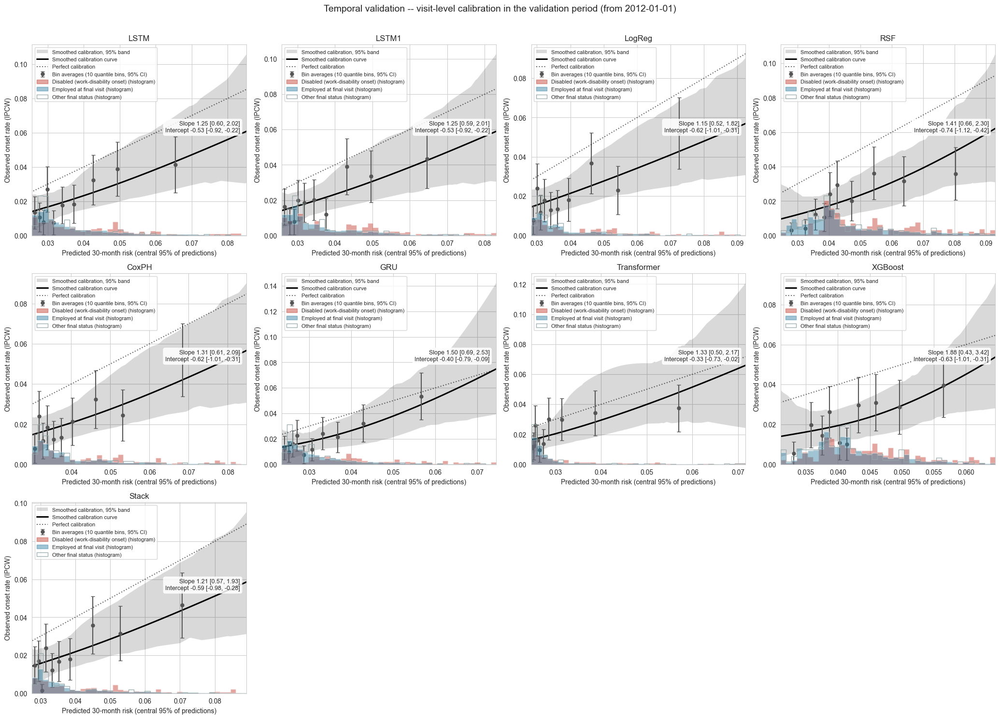

In [60]:
"""
Temporal validation -- an ADDITIONAL sensitivity analysis; it replaces nothing above.

Question: does a model developed on earlier years transport to later years? Every model is refitted once:
  development : landmarks before TEMPORAL_CUTOFF, with their follow-up administratively CENSORED at the cutoff (only
                what was known at that date is used: an onset after the cutoff is not an event for training)
  validation  : landmarks on or after the cutoff, with their real follow-up
The fitting recipe is the main one (Section 8): cross-fitting inside the development set for tuning, recalibration and
the visit threshold; then the development-set model scores the validation landmarks. A patient can contribute landmarks to both periods (a temporal split, not a patient split); the sequence
models' label-free pretraining uses the covariate histories of development-period patients.

Reported per model: the visit-level table on the validation period (IPCW from the validation landmarks), a patient-level
table on the validation period's 30-month windows (discrimination and decisions; patient-probability calibration is not
reported because the patient recalibration would need development-period patient outcomes that extend past the
cutoff), and the visit-level calibration curves. Checkpointed in TEMPORAL_PATH.
"""
RUN_TEMPORAL_VALIDATION = True
TEMPORAL_CUTOFF = pd.Timestamp("2012-01-01")
TEMPORAL_PATH = "temporal_validation_revised_v16_smoke.pkl" if SMOKE else "temporal_validation_revised_v16.pkl"
TEMPORAL_BOOT = 100 if SMOKE else 500


def _temporal_split():
    d = land["visit_date"].values
    return np.flatnonzero(d < np.datetime64(TEMPORAL_CUTOFF)), np.flatnonzero(d >= np.datetime64(TEMPORAL_CUTOFF))


def temporal_recalibration_shift(res, tr):
    """Temporal recalibration (Booth et al., Int J Epidemiol 2020): per horizon, the logit shift that matches the mean
    calibrated OOF risk to the observed IPCW risk on the development landmarks of the last TEMPORAL_RECAL_YEARS before
    the cutoff (slope kept). Called while the development outcomes are censored at the cutoff."""
    recent = CAL_YEAR_ALL[tr] >= TEMPORAL_CUTOFF.year - TEMPORAL_RECAL_YEARS
    G = CensoringKM(T_ALL[tr], C_ALL[tr])
    out = []
    for j, hd in enumerate(HORIZON_DAYS_GRID):
        y, w = ipcw_label_weight(T_ALL[tr], C_ALL[tr], hd, G)
        k = recent & (w > 0)
        lp = _logit(np.clip(res["oof_P"][k, j], 1e-6, 1 - 1e-6))
        try:
            out.append(brentq(lambda a: np.average(_expit(a + lp), weights=w[k]) - np.average(y[k], weights=w[k]),
                              -10, 10))
        except ValueError:
            out.append(0.0)
    return np.array(out)


def run_temporal_validation(models=None):
    """Fits every model once on the development period (outcomes censored at the cutoff) and scores the validation
    period. The outcome arrays are swapped for the development rows during fitting and always restored."""
    global T_ALL, C_ALL, E_ALL, Y_CR, M_CR, S_CS, E_CS
    models = list(models or CV_MODELS)
    state = {}
    if os.path.exists(TEMPORAL_PATH):
        with open(TEMPORAL_PATH, "rb") as f:
            state = pickle.load(f)
    tr, te = _temporal_split()
    days_to_cut = (TEMPORAL_CUTOFF - land["visit_date"]).dt.days.values.astype(float)
    in_tr = np.zeros(len(land), bool); in_tr[tr] = True
    past_cut = in_tr & (T_ALL > days_to_cut)
    saved = (T_ALL, C_ALL, E_ALL, Y_CR, M_CR, S_CS, E_CS, land["pt_event"].values.copy())
    new_pids = set(PID_ALL[te]) - set(PID_ALL[tr])                     # patients first seen after the cutoff
    try:
        T_ALL = np.where(past_cut, days_to_cut, saved[0])
        C_ALL = np.where(past_cut, 0, saved[1])
        E_ALL = (C_ALL == 1).astype(int)
        Y_CR, M_CR = discrete_time_targets(T_ALL, C_ALL)
        S_CS, E_CS = cs_targets(T_ALL, LEFT_ALL, C_ALL)
        land["pt_event"] = pd.Series(np.where(in_tr, E_ALL, 0)).groupby(PID_ALL).transform("max").values
        if "__selection__" not in state:                                # the LASSO on the development period
            state["__selection__"] = lasso_select(tr, CV_SEED + 777)
        sel_tv = state["__selection__"]
        for m in models:
            if m in state:
                continue
            t0 = time.time()
            if m in STACK_SPECS:                                         # formed from the members (Section 6.3)
                mem, meta = STACK_SPECS[m]
                if any(x not in state for x in mem):
                    continue
                res = stack_fold([state[x] for x in mem], mem, tr, te, meta, CV_SEED + 777)
            else:
                res = run_fold(m, tr, te, CV_SEED + 777, model_features(m, sel_tv["features"]), sel_tv["freq"],
                               exclude_pids=new_pids)
            res["trecal_shift"] = temporal_recalibration_shift(res, tr)
            state[m] = res
            with open(TEMPORAL_PATH, "wb") as f:
                pickle.dump(state, f)
            print(f"[temporal] {m}: fitted on {len(tr):,} development landmarks in {time.time() - t0:.0f}s")
    finally:
        T_ALL, C_ALL, E_ALL, Y_CR, M_CR, S_CS, E_CS = saved[:7]
        land["pt_event"] = saved[7]
    return state, tr, te


def temporal_arrays(res, te):
    """(visit arrays, patient arrays) of the validation period, in the format of level_arrays."""
    G = CensoringKM(T_ALL[te], C_ALL[te])
    y, w = ipcw_label_weight(T_ALL[te], C_ALL[te], HORIZON_DAYS, G)
    p = res["P"][:, PRIMARY_COL]
    k = w > 0
    visit = [(y[k], p[k], w[k], (p >= res["visit_thr"]["target"])[k], LAND_CODE[te][k])]
    f = patient_frame(te, p, res["visit_thr"]["target"])
    patient = [(f["y"].values, f["score"].values, np.ones(len(f)), f["flag"].values == 1, PT_CODE.get_indexer(f.index))]
    return visit, patient


if RUN_TEMPORAL_VALIDATION:
    temporal_state, tv_tr, tv_te = run_temporal_validation()
    print(f"Temporal validation: development = landmarks before {TEMPORAL_CUTOFF.date()} ({len(tv_tr):,} landmarks, "
          f"{len(set(PID_ALL[tv_tr]))} patients; outcomes censored at the cutoff); validation = landmarks from "
          f"{TEMPORAL_CUTOFF.date()} ({len(tv_te):,} landmarks, {len(set(PID_ALL[tv_te]))} patients).")
    tv_visit, tv_patient, tv_arrs = {}, {}, {}
    for m in [x for x in CV_MODELS if x in temporal_state]:
        va, pa = temporal_arrays(temporal_state[m], tv_te)
        tv_arrs[m] = va
        tv_visit[m] = metric_table(m, None, "visit", n_boot=TEMPORAL_BOOT, arrs=va)
        tv_patient[m] = metric_table(m, None, "patient", n_boot=TEMPORAL_BOOT, arrs=pa)
        tv_patient[m].loc[["brier", "cal_slope", "cal_intercept", "oe_ratio", "ppv_cohort", "npv_cohort"], ["Value", "CI low",
                                                                                               "CI high"]] = np.nan
    n_pos = int(tv_arrs[next(iter(tv_arrs))][0][0].sum())
    print(f"\nVISIT LEVEL, validation period ({n_pos} resolved landmarks with an onset within 30 months): "
          f"value [95% CI]")
    display(pd.DataFrame({m: {r["Metric"]: (f"{r['Value']:.3f} [{r['CI low']:.3f}, {r['CI high']:.3f}]"
                                            if np.isfinite(r["Value"]) else "n/a") for _, r in t.iterrows()}
                          for m, t in tv_visit.items()}).T)
    _pa = temporal_arrays(temporal_state[next(iter(tv_visit))], tv_te)[1][0]
    print(f"\nPATIENT LEVEL, validation period ({int(_pa[0].sum())} event vs {int((_pa[0] == 0).sum())} event-free "
          f"patients with a 30-month window in it; calibration not reported, see above): value [95% CI]")
    display(pd.DataFrame({m: {r["Metric"]: (f"{r['Value']:.3f} [{r['CI low']:.3f}, {r['CI high']:.3f}]"
                                            if np.isfinite(r["Value"]) else "n/a")
                              for k, r in t.iterrows() if k not in ("brier", "cal_slope", "cal_intercept", "oe_ratio",
                                                                     "ppv_cohort", "npv_cohort")}
                          for m, t in tv_patient.items()}).T)
    _trc = []
    for m in [x for x in CV_MODELS if x in temporal_state]:
        a_ = float(temporal_state[m]["trecal_shift"][PRIMARY_COL])
        y_, p_, w_ = tv_arrs[m][0][:3]
        p2_ = _expit(_logit(np.clip(p_, 1e-6, 1 - 1e-6)) + a_)
        _trc.append({"Model": MODEL_LABELS.get(m, m), "Intercept shift (logit, from the last "
                     f"{TEMPORAL_RECAL_YEARS} development years)": a_,
                     "O/E": np.sum(w_ * y_) / np.sum(w_ * p_), "O/E, temporally recalibrated": np.sum(w_ * y_) / np.sum(w_ * p2_),
                     "Calibration intercept": fast_calibration(y_, p_, w_)[1],
                     "Calibration intercept, temporally recalibrated": fast_calibration(y_, p2_, w_)[1]})
    print("\nTEMPORAL RECALIBRATION (Booth et al. 2020): the validation-period calibration of every model as fitted and "
          "with its intercepts re-estimated on the last development years (discrimination is unchanged):")
    display(pd.DataFrame(_trc).set_index("Model").round(3))
    pd.concat({m: t for m, t in tv_visit.items()}).to_csv("temporal_validation_visit_model_revised_v16.csv")
    pd.concat({m: t for m, t in tv_patient.items()}).to_csv("temporal_validation_patient_model_revised_v16.csv")
    _ms = list(tv_arrs)
    fig, axes = plt.subplots(int(np.ceil(len(_ms) / 4)), 4, figsize=(20.8, 4.9 * int(np.ceil(len(_ms) / 4))))
    axes = np.atleast_1d(axes).ravel()
    for ax, m in zip(axes, _ms):
        plot_calibration(ax, m, None, "visit", tv_visit[m], arrs=tv_arrs[m], key=("temporal", m), title=m)
    for ax in axes[len(_ms):]:
        ax.set_visible(False)
    plt.suptitle(f"Temporal validation -- visit-level calibration in the validation period (from "
                 f"{TEMPORAL_CUTOFF.date()})", y=1.01, fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v16_temporal_calibration.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
else:
    print("Temporal validation skipped (set RUN_TEMPORAL_VALIDATION = True).")

Correctly flagged (TP) patients already alarmed at their FIRST landmark of the 30-month window: 87.1% (pooled over repeats). For them the lead time reflects the window and the visit spacing rather than a rise in risk (risk stratification, not early warning).
LSTM -- lead time: TP = first alarm per patient, FP = every false-alarm visit (pooled over 5 CV repeat(s); CI: 1000 patient-cluster bootstrap resamples)


,Unit,N per repeat,Patients per repeat,Median lead (mo),95% CI,IQR (mo),Per-repeat medians
Prediction,,,,,,,
Correct (TP patients): first alarm -> onset,patients,109.8,109.8,19.3,"[15.3, 22.1]",8.9-27.3,19.3-19.6
Incorrect (FP visits): alarmed visit -> end of window,visits,1164.2,355.2,42.2,"[41.1, 43.1]",33.5-50.9,41.9-42.4



LSTM -- alert burden for correctly flagged (TP) patients, 30-month window


,Mean over repeats,Min,Max
Alarmed visits per TP patient (median),3.00,3.00,3.00
Alarmed visits per TP patient (mean),3.65,3.57,3.72
Visits in window per TP patient (median),4.00,4.00,4.00
"Share of window visits alarmed, TP (median)",1.00,1.00,1.00
"Alarms after the first, TP (median)",2.00,2.00,2.00
All alarms (TP + FP patients) per TP patient,14.24,13.54,15.08
Flagged patients per TP patient (1 / PPV),4.23,4.09,4.34


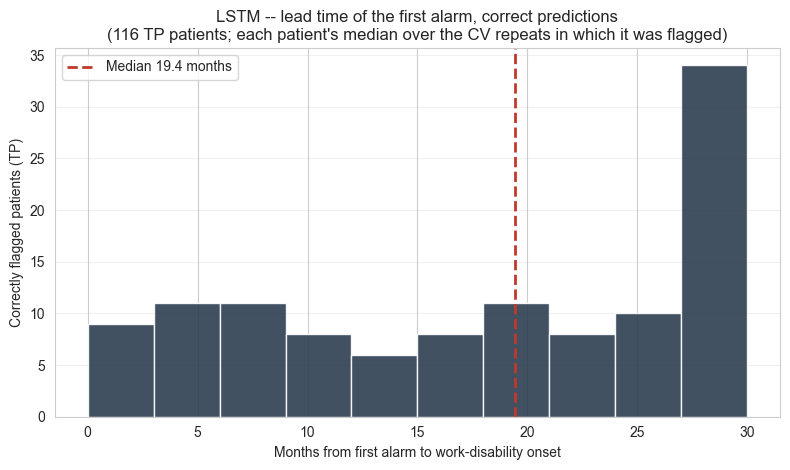


Risk sensitivity computed on 400 landmarks of 300 patients (mean observed 30-month risk 0.038).


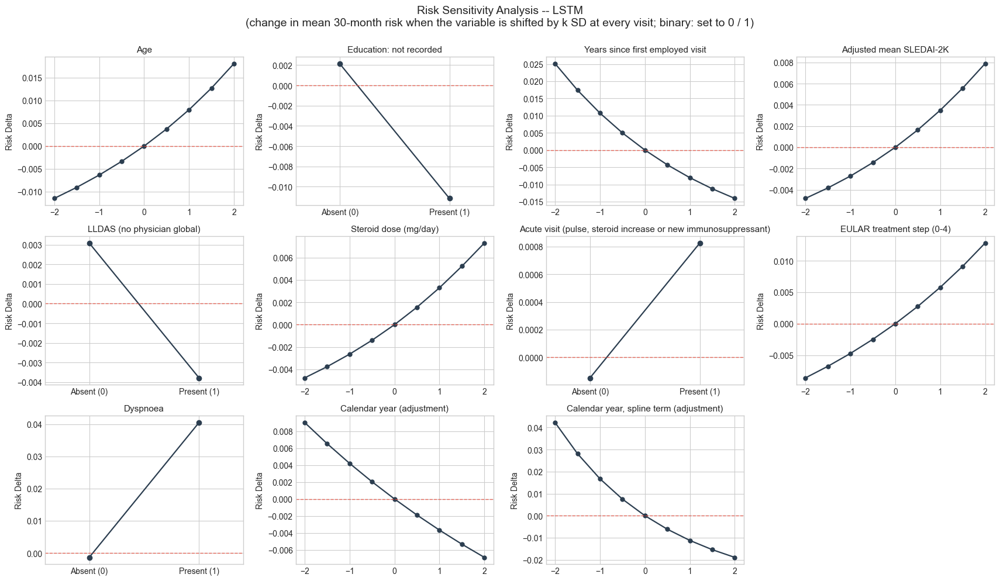

                                                      Variable  Binary  Delta @ low (-2 SD / 0)  Delta @ high (+2 SD / 1)  Swing (max-min)
                       Calendar year, spline term (adjustment)   False                  +0.0423                   -0.0189          +0.0612
                                                      Dyspnoea    True                  -0.0014                   +0.0406          +0.0419
                              Years since first employed visit   False                  +0.0252                   -0.0141          +0.0392
                                                           Age   False                  -0.0115                   +0.0181          +0.0296
                                    EULAR treatment step (0-4)   False                  -0.0086                   +0.0128          +0.0214
                                    Calendar year (adjustment)   False                  +0.0090                   -0.0069          +0.0159
                           

In [61]:
"""LSTM only -- alarm lead time, alert burden, and SD-shift risk-sensitivity plots.

FP  (incorrect, VISIT level: every alarmed window visit of an event-free patient is one false positive): months from
      that visit to the end of the patient's window -- the retirement exit (retired / homemaker >= 60) or 30 months
      after the latest window landmark (the end of the fully observed follow-up). CI is still clustered on patient.
"""
import copy
import os

assert res_lstm is not None and "final" in res_lstm, "Run the LSTM section (11.9) first."
LT_MODEL = "LSTM"
LT_DIR = f"{OUT_DIR}/revised_v16_lstm_leadtime"
os.makedirs(LT_DIR, exist_ok=True)

# ------------------------------------------------------------------------------------------------ window ends
_ldate = pd.to_datetime(land["visit_date"].values)
_last_win = pd.Series(_ldate[LAND_PT_WIN]).groupby(PID_ALL[LAND_PT_WIN]).max()
_is_ret = PT_TRUTH["stratum"].reindex(_last_win.index).eq(STRATA[1])
WIN_END_NEG = pd.to_datetime(PT_TRUTH["exit_date"]).reindex(_last_win.index) \
    .where(_is_ret, _last_win + pd.Timedelta(days=HORIZON_DAYS))


def lstm_alarm_frame(pr):
    """Patient frame (one row per evaluable patient: outcome TP/FP/FN/TN, alarms, visits in window, lead) and the
    visit-level FP leads (one value per alarmed window visit of an event-free patient, index = pid) for one repeat."""
    p, thr = pr["P"][:, PRIMARY_COL], pr["visit_thr"]["target"]
    k = LAND_PT_WIN & ~np.isnan(p)
    d = pd.DataFrame({"pid": PID_ALL[k], "date": _ldate[k], "t": T_ALL[k], "a": p[k] >= thr[k]})
    g, ga = d.groupby("pid", sort=False), d[d["a"]].groupby("pid")
    f = pd.DataFrame({"n_win": g.size(), "n_alarm": g["a"].sum().astype(int)})
    first_alarm = ga["date"].min().reindex(f.index)
    lead_event = ga["t"].max().reindex(f.index).values / MONTH_DAYS
    lead_neg = (WIN_END_NEG.reindex(f.index) - first_alarm).dt.days.values / MONTH_DAYS
    f["y"] = PT_Y.loc[f.index].values
    f["alarm_first_visit"] = d.sort_values("date").groupby("pid", sort=False)["a"].first().reindex(f.index).values
    flag = f["n_alarm"].values > 0
    ev = f["y"].values == 1
    f["outcome"] = np.select([ev & flag, ~ev & flag, ev & ~flag], ["TP", "FP", "FN"], "TN")
    f["lead_mo"] = np.where(ev, lead_event, lead_neg)
    # visit-level FP: each alarmed window visit of an event-free patient -> months to that patient's window end
    fpv = d[d["a"].values & (PT_Y.reindex(d["pid"]).values == 0)]
    fp_lead = (WIN_END_NEG.reindex(fpv["pid"]).values - fpv["date"].values) / np.timedelta64(1, "D") / MONTH_DAYS
    return f, pd.Series(fp_lead, index=fpv["pid"].values, name="lead_mo")



_lt_preds = {r: pr for (m, r), pr in res_lstm["preds"].items() if m == LT_MODEL}
_lt_out = {r: lstm_alarm_frame(pr) for r, pr in sorted(_lt_preds.items())}
LT_FRAMES = {r: o[0] for r, o in _lt_out.items()}                  # patient level (TP, burden, histogram)
LT_FP_VISITS = {r: o[1] for r, o in _lt_out.items()}               # visit level (FP lead time)
_pool = pd.concat([f.assign(repeat=r) for r, f in LT_FRAMES.items()])
_tp = _pool[_pool["outcome"] == "TP"]
print(f"Correctly flagged (TP) patients already alarmed at their FIRST landmark of the 30-month window: "
      f"{_tp['alarm_first_visit'].mean():.1%} (pooled over repeats). For them the lead time reflects the window and the "
      f"visit spacing rather than a rise in risk (risk stratification, not early warning).")


def _boot_median_ci(s, n=BOOT_N, seed=SEED):
    """95% patient-cluster bootstrap CI of the median of `s` (index = pid, pooled over repeats)."""
    arrs = list(s.groupby(level=0).apply(np.asarray).values)
    rng = np.random.RandomState(seed)
    meds = [np.median(np.concatenate([arrs[i] for i in rng.randint(len(arrs), size=len(arrs))])) for _ in range(n)]
    return np.percentile(meds, [2.5, 97.5])


# ------------------------------------------------------------------------------------------------ lead-time table
rows = []
_lead_src = {"TP": ({r: f.loc[f["outcome"] == "TP", "lead_mo"] for r, f in LT_FRAMES.items()}, "patients"),
             "FP": (LT_FP_VISITS, "visits")}
for oc, label in [("TP", "Correct (TP patients): first alarm -> onset"),
                  ("FP", "Incorrect (FP visits): alarmed visit -> end of window")]:
    per, unit = _lead_src[oc]
    per = {r: s.dropna() for r, s in per.items()}
    s = pd.concat(per.values())
    per_rep = [v.median() for v in per.values() if len(v)]
    lo, hi = _boot_median_ci(s)
    rows.append({"Prediction": label, "Unit": unit,
                 "N per repeat": np.mean([len(v) for v in per.values()]),
                 "Patients per repeat": np.mean([v.index.nunique() for v in per.values()]),
                 "Median lead (mo)": s.median(), "95% CI": f"[{lo:.1f}, {hi:.1f}]",
                 "IQR (mo)": f"{s.quantile(.25):.1f}-{s.quantile(.75):.1f}",
                 "Per-repeat medians": f"{np.min(per_rep):.1f}-{np.max(per_rep):.1f}"})
lead_table = pd.DataFrame(rows).set_index("Prediction")
print(f"{LT_MODEL} -- lead time: TP = first alarm per patient, FP = every false-alarm visit "
      f"(pooled over {len(LT_FRAMES)} CV repeat(s); CI: {BOOT_N} patient-cluster bootstrap resamples)")
display(lead_table.round(1))


# ------------------------------------------------------------------------------------------------ alert burden (TP)
burden = []
for r, f in LT_FRAMES.items():
    tp = f[f["outcome"] == "TP"]
    burden.append({"Alarmed visits per TP patient (median)": tp["n_alarm"].median(),
                   "Alarmed visits per TP patient (mean)": tp["n_alarm"].mean(),
                   "Visits in window per TP patient (median)": tp["n_win"].median(),
                   "Share of window visits alarmed, TP (median)": (tp["n_alarm"] / tp["n_win"]).median(),
                   "Alarms after the first, TP (median)": (tp["n_alarm"] - 1).median(),
                   "All alarms (TP + FP patients) per TP patient": f["n_alarm"].sum() / max(len(tp), 1),
                   "Flagged patients per TP patient (1 / PPV)": f["n_alarm"].gt(0).sum() / max(len(tp), 1)})
burden = pd.DataFrame(burden)
burden_table = pd.DataFrame({"Mean over repeats": burden.mean(), "Min": burden.min(), "Max": burden.max()})
print(f"\n{LT_MODEL} -- alert burden for correctly flagged (TP) patients, 30-month window")
display(burden_table.round(2))
lead_table.to_csv(f"{LT_DIR}/lead_time.csv"); burden_table.to_csv(f"{LT_DIR}/alert_burden.csv")

# ------------------------------------------------------------------------------------------------ histogram
tp_lead = _pool.loc[_pool["outcome"] == "TP"].groupby(level=0)["lead_mo"].median()   # per patient, over repeats
med = tp_lead.median()
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(tp_lead, bins=np.arange(0, HORIZON_DAYS / MONTH_DAYS + 3, 3), color="#2c3e50", edgecolor="white", alpha=0.9)
ax.axvline(med, color="#c0392b", ls="--", lw=2, label=f"Median {med:.1f} months")
ax.set_xlabel("Months from first alarm to work-disability onset")
ax.set_ylabel("Correctly flagged patients (TP)")
ax.set_title(f"{LT_MODEL} -- lead time of the first alarm, correct predictions\n"
             f"({len(tp_lead)} TP patients; each patient's median over the CV repeats in which it was flagged)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(f"{LT_DIR}/lead_time_hist_TP.png", dpi=150, bbox_inches="tight"); plt.show(); plt.close()

# ------------------------------------------------------------------------------------------------ risk sensitivity
fr = res_lstm["final"]
data0 = fr["prep"]
SENS_COLS = list(data0.cols)
SD_GRID = np.arange(-2, 2.01, 0.5)
_rng = np.random.RandomState(SEED)
SENS_ROWS = np.sort(_rng.choice(len(land), size=min(150 if SMOKE else 400, len(land)), replace=False))
SENS_VROWS = np.concatenate([PATIENT_ROWS[p] for p in pd.unique(PID_ALL[SENS_ROWS])])


def _lstm_risk(data):
    return fr["cal"].transform(hazard_risk(predict_hazards_seq(fr["fitted"], data, SENS_ROWS))[:, PRIMARY_COL])


def _modified(j, shift=None, value=None):
    """Copy of the encoder data with column j shifted by `shift` SD, or set to `value` (model scale), at every visit
    of the sampled patients, in every imputation."""
    d = copy.copy(data0)
    d.VXs = [V.copy() for V in data0.VXs]
    for V in d.VXs:
        V[SENS_VROWS, j] = value if value is not None else np.clip(V[SENS_VROWS, j] + shift, -CLIP_Z, CLIP_Z)
    d.VX = d.VXs[0]
    return d


base_risk = _lstm_risk(data0)
LSTM_SENS = {}
for j, col in enumerate(SENS_COLS):
    binary = col in land and land[col].dropna().nunique() <= 2
    if binary:
        xs = np.array([0.0, 1.0])
        risks = [_lstm_risk(_modified(j, value=fr["ctx"]["seq_prep"].transform_value(j, v))) for v in xs]
    else:
        xs = SD_GRID
        risks = [base_risk if s == 0 else _lstm_risk(_modified(j, shift=s)) for s in xs]
    LSTM_SENS[col] = {"x": xs, "delta": np.array([np.mean(r - base_risk) for r in risks]), "binary": binary}
print(f"\nRisk sensitivity computed on {len(SENS_ROWS)} landmarks of {len(pd.unique(PID_ALL[SENS_ROWS]))} patients "
      f"(mean observed 30-month risk {base_risk.mean():.3f}).")


def _sens_panel(ax, col, c):
    if c["binary"]:
        ax.plot([0, 1], c["delta"], "o-", color="#2c3e50", lw=1.6, ms=6)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Absent (0)", "Present (1)"]); ax.set_xlim(-0.4, 1.4)
    else:
        ax.plot(c["x"], c["delta"], "o-", color="#2c3e50", lw=1.6, ms=5)
        ax.set_xticks([-2, -1, 0, 1, 2])
    ax.axhline(0, color="#e74c3c", ls="--", lw=1, alpha=0.8)
    ax.set_title(DISPLAY_NAMES.get(col, col), fontsize=11)
    ax.set_ylabel("Risk Delta")


ncols = 4
nrows = int(np.ceil(len(SENS_COLS) / ncols))
with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.3 * ncols, 3.3 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, SENS_COLS):
        _sens_panel(ax, col, LSTM_SENS[col])
    for ax in axes[len(SENS_COLS):]:
        ax.set_visible(False)
    fig.suptitle(f"Risk Sensitivity Analysis -- {LT_MODEL}\n(change in mean 30-month risk when the variable is shifted "
                 f"by k SD at every visit; binary: set to 0 / 1)", fontsize=14, y=1.0)
    plt.tight_layout(); plt.savefig(f"{LT_DIR}/risk_sensitivity_grid.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    for col in SENS_COLS:                                          # one file per variable
        fig, ax = plt.subplots(figsize=(4.6, 3.6))
        _sens_panel(ax, col, LSTM_SENS[col])
        ax.set_xlabel("Value" if LSTM_SENS[col]["binary"] else "Shift (SD)")
        plt.tight_layout(); plt.savefig(f"{LT_DIR}/risk_sensitivity_{col}.png", dpi=150, bbox_inches="tight")
        plt.close()

sens_summary = pd.DataFrame([{"Variable": DISPLAY_NAMES.get(col, col), "Binary": c["binary"],
                              "Delta @ low (-2 SD / 0)": c["delta"][0], "Delta @ high (+2 SD / 1)": c["delta"][-1],
                              "Swing (max-min)": np.ptp(c["delta"])} for col, c in LSTM_SENS.items()]) \
    .sort_values("Swing (max-min)", ascending=False)
sens_summary.to_csv(f"{LT_DIR}/risk_sensitivity_summary.csv", index=False)
print(sens_summary.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))
print(f"Per-variable plots saved in {LT_DIR}/")

## 11.25 Pre-specified sensitivity analyses

Section 3.1. **Evaluated on the main fits** (no refitting): the horizon (12, 24, 36 and 48 months; each horizon has
its own recalibration, and the alarm threshold, learned at 30 months, is not used) and complete-case evaluation
(landmarks resolved at 30 months, unit weights, instead of IPCW). **Refitted:** every analysis that changes the
outcome, the landmarks or the handling of death. Each runs in its own Python process that executes this notebook's
configuration, data, censoring, variable, patient-level, sequence-model and cross-validation cells with
`SLE_VARIANT` set, so the outcome and landmarks are rebuilt from the raw extract; the competing-risk LogReg and the
LSTM (`SENS_MODELS`) are cross-validated with `SENS_REPEATS` repeat(s) of the same 5-fold scheme. Each analysis is
checkpointed (`sensitivity_<analysis>_revised_v16.pkl`; its log in `sensitivity_<analysis>_revised_v16.log`), so an
interrupted run resumes. The processes read this notebook **from disk**: save it before running the cell. The main
analysis is shown on its first CV repeat so that it is comparable with the refitted analyses.

In [ ]:
"""
Pre-specified sensitivity analyses (Section 3.1): evaluation-only (horizon, complete case) on the main fits; refitted
analyses in separate processes (SLE_VARIANT), checkpointed per analysis; one summary table.
"""
import subprocess, sys, json as _json

RUN_SENSITIVITY_REFITS = True
SENS_NOTEBOOK = "SLE_30Month_WorkDisability_Model_revised_v16.ipynb"
SENS_RUN = ["grid_6mo"] if SMOKE else list(SENSITIVITY_VARIANTS)
SENS_HORIZONS = [12, 24, 36, 48]
SENS_CELL_MARKERS = ["Configuration and shared utilities.", "Visit-level variables, competing-risk outcomes",
                     "Censoring diagnostic and the censoring model", "Variables: candidate pool, pre-filter and LASSO selection",
                     "Patient-level evaluation: visit alarms accumulated", "Sequence models: the main LSTM",
                     "Repeated cross-validation, part 1/4", "Repeated cross-validation, part 2/4",
                     "Repeated cross-validation, part 3/4", "Repeated cross-validation, part 4/4"]
_SENS_DRIVER = r"""
import json, sys, warnings
import matplotlib
matplotlib.use("Agg")
warnings.filterwarnings("ignore")
nb = json.load(open(sys.argv[1]))
g = {"__name__": "__sensitivity__"}
for mk in json.loads(sys.argv[2]):
    cells = [c for c in nb["cells"] if c["cell_type"] == "code" and "".join(c["source"]).lstrip(chr(34) + chr(10) + " ").startswith(mk)]
    assert len(cells) == 1, (mk, len(cells))
    exec(compile("".join(cells[0]["source"]), mk, "exec"), g)
exec(sys.argv[3], g)
"""
_SENS_SUMMARISE = r"""
import pickle
cv_state = run_repeated_cv(models=SENS_MODELS)
res_df, preds = collect_results(cv_state, SENS_MODELS)
yy, ww = IPCW[PRIMARY_HORIZON_MONTHS]
out = {"variant": SLE_VARIANT, "landmarks": len(land), "patients": int(land["pid"].nunique()),
       "event_patients": int(land.loc[land["cause"] == 1, "pid"].nunique()),
       "onsets_30mo_resolved": int((yy[ww > 0] == 1).sum()), "models": {}}
for m in SENS_MODELS:
    out["models"][m] = {"visit": metric_table(m, preds, "visit", n_boot=SENS_BOOT),
                        "patient": metric_table(m, preds, "patient", n_boot=SENS_BOOT),
                        "burden": res_df.loc[res_df["model"] == m, ["alerts_per_py", "never_alerted_stayed"]].mean().to_dict()}
with open(SENS_RESULT_PATH, "wb") as f:
    pickle.dump(out, f)
print("sensitivity analysis done:", SLE_VARIANT)
"""


def run_sensitivity_variant(key):
    path = f"sensitivity_{key}_revised_v16{'_smoke' if SMOKE else ''}.pkl"
    if os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
    if not RUN_SENSITIVITY_REFITS:
        return None
    log = path.replace(".pkl", ".log")
    t0 = time.time()
    print(f"[sensitivity] {key}: {SENSITIVITY_VARIANTS[key][0]} -- running (log: {log})", flush=True)
    env = {**os.environ, "SLE_VARIANT": key, "MPLBACKEND": "Agg"}
    with open(log, "w") as lf:
        rc = subprocess.run([sys.executable, "-c", _SENS_DRIVER, SENS_NOTEBOOK, _json.dumps(SENS_CELL_MARKERS),
                             _SENS_SUMMARISE], env=env, stdout=lf, stderr=subprocess.STDOUT).returncode
    if rc != 0 or not os.path.exists(path):
        print(f"[sensitivity] {key} FAILED (exit {rc}); last lines of {log}:")
        print("".join(open(log).readlines()[-25:]))
        return None
    print(f"[sensitivity] {key}: done in {(time.time() - t0) / 60:.1f} min", flush=True)
    with open(path, "rb") as f:
        return pickle.load(f)


def _cell(t, k, nd=3):
    if t is None or k not in t.index or not np.isfinite(t.loc[k, "Value"]):
        return "n/a"
    return f"{t.loc[k, 'Value']:.{nd}f} [{t.loc[k, 'CI low']:.{nd}f}, {t.loc[k, 'CI high']:.{nd}f}]"


def _row(label, how, counts, tables):
    r = {"Analysis": label, "Run": how, **counts}
    for m, (vt, pt, burden) in tables.items():
        r.update({f"{m}: C (visit)": _cell(vt, "c_index"), f"{m}: O/E": _cell(vt, "oe_ratio", 2),
                  f"{m}: cal. slope": _cell(vt, "cal_slope", 2), f"{m}: sens (visit)": _cell(vt, "sensitivity"),
                  f"{m}: spec (visit)": _cell(vt, "specificity"), f"{m}: C (patient)": _cell(pt, "c_index"),
                  f"{m}: sens (patient)": _cell(pt, "sensitivity"), f"{m}: spec (patient)": _cell(pt, "specificity"),
                  f"{m}: alerts / pt-yr": f"{burden.get('alerts_per_py', np.nan):.2f}",
                  f"{m}: stayed employed, never alerted": f"{burden.get('never_alerted_stayed', np.nan):.3f}"})
    return r


_sens_models = [m for m in SENS_MODELS if m in MODEL_RESULTS]
_main_preds = {m: {k: v for k, v in MODEL_RESULTS[m]["preds"].items() if k[1] == 0} for m in _sens_models}
_y30, _w30 = IPCW[PRIMARY_HORIZON_MONTHS]
_main_counts = {"Landmarks": len(land), "Patients": int(land["pid"].nunique()),
                "Event patients": int(land.loc[land["cause"] == 1, "pid"].nunique()),
                "Onsets <= 30 mo (resolved landmarks)": int((_y30[_w30 > 0] == 1).sum())}
SENS_ROWS = [_row("Main analysis (CV repeat 1)", "main", _main_counts,
                  {m: (metric_table(m, _main_preds[m], "visit", n_boot=SENS_BOOT),
                       metric_table(m, _main_preds[m], "patient", n_boot=SENS_BOOT),
                       pd.DataFrame([alert_burden(pr) for pr in _main_preds[m].values()]).mean().to_dict())
                   for m in _sens_models})]


def _eval_arrs(m, horizon=None, complete_case=False):
    """Visit-level arrays of the main fits (repeat 1) at another horizon, or with complete-case weights."""
    out = []
    for (_, r), pr in _main_preds[m].items():
        h = horizon or PRIMARY_HORIZON_MONTHS
        j = EVAL_HORIZONS_MONTHS.index(h)
        y, w = IPCW[h]
        if complete_case:
            w = (w > 0).astype(float)
        k = w > 0
        p = pr["P"][:, j]
        alert = (p >= pr["visit_thr"]["target"]) if h == PRIMARY_HORIZON_MONTHS else np.zeros(len(p), bool)   # threshold: 30 mo only
        out.append((y[k], p[k], w[k], alert[k], LAND_CODE[k]))
    return out


for h in SENS_HORIZONS:
    yh, wh = IPCW[h]
    tabs = {}
    for m in _sens_models:
        vt = metric_table(m, None, "visit", n_boot=SENS_BOOT, arrs=_eval_arrs(m, horizon=h))
        vt.loc[["sensitivity", "specificity", "ppv", "npv", "bal_acc"], ["Value", "CI low", "CI high"]] = np.nan
        tabs[m] = (vt, None, {})
    SENS_ROWS.append(_row(f"Horizon {h} months", "main fits", {**_main_counts, "Onsets <= 30 mo (resolved landmarks)":
                                                             f"{int((yh[wh > 0] == 1).sum())} (by {h} mo)"}, tabs))
SENS_ROWS.append(_row("Complete-case evaluation (no IPCW)", "main fits", _main_counts,
                      {m: (metric_table(m, None, "visit", n_boot=SENS_BOOT, arrs=_eval_arrs(m, complete_case=True)),
                           None, {}) for m in _sens_models}))

for key in SENS_RUN:
    res_ = run_sensitivity_variant(key)
    if res_ is None:
        continue
    SENS_ROWS.append(_row(SENSITIVITY_VARIANTS[key][0], "refitted",
                          {"Landmarks": res_["landmarks"], "Patients": res_["patients"],
                           "Event patients": res_["event_patients"],
                           "Onsets <= 30 mo (resolved landmarks)": res_["onsets_30mo_resolved"]},
                          {m: (d["visit"], d["patient"], d["burden"]) for m, d in res_["models"].items()}))

sens_table = pd.DataFrame(SENS_ROWS).set_index("Analysis")
sens_table.to_csv("sensitivity_analyses_revised_v16.csv")
print("Pre-specified sensitivity analyses -- value [95% patient-bootstrap CI]; refitted analyses: "
      f"{SENS_REPEATS} CV repeat(s); main analysis shown on its first repeat")
_count_cols = ["Run", "Landmarks", "Patients", "Event patients", "Onsets <= 30 mo (resolved landmarks)"]
display(sens_table[_count_cols])
for m in _sens_models:
    print(f"\n{m}:")
    display(sens_table[[c for c in sens_table.columns if c.startswith(f"{m}: ")]]
            .rename(columns=lambda c: c.split(": ", 1)[1]))

[sensitivity] sick_any: Sick-leave threshold: any duration -- running (log: sensitivity_sick_any_revised_v16.log)
[sensitivity] sick_any: done in 33.1 min
[sensitivity] sick_3mo: Sick-leave threshold: 3 months -- running (log: sensitivity_sick_3mo_revised_v16.log)
[sensitivity] sick_3mo: done in 31.5 min
[sensitivity] sick_12mo: Sick-leave threshold: 12 months -- running (log: sensitivity_sick_12mo_revised_v16.log)
[sensitivity] sick_12mo: done in 30.4 min
[sensitivity] recording_visit: Onset dated at the recording visit -- running (log: sensitivity_recording_visit_revised_v16.log)
[sensitivity] recording_visit: done in 29.1 min
[sensitivity] early_retirement: Early retirement (< 60) counted as an onset -- running (log: sensitivity_early_retirement_revised_v16.log)
[sensitivity] early_retirement: done in 258.2 min
[sensitivity] unemployment: Unemployment counted as an onset -- running (log: sensitivity_unemployment_revised_v16.log)
[sensitivity] unemployment: done in 118.2 min
[sensiti